  📂 TON-1

🔢 Shakl: 2007 rows × 4 columns
📋 Kolonkalar: ['depth_mm', 'age_calBP', 'Sr/Ca', 'S/Ca']

⚠️  Missing Values:
   depth_mm            : ✅ yo'q
   age_calBP           : ✅ yo'q
   Sr/Ca               : ✅ yo'q
   S/Ca                : ✅ yo'q

🔁 Dublikat qatorlar: 0

🕰️  Vaqt qatori (age_calBP):
   Min age    :    8,104.0 cal yr BP
   Max age    :  133,832.0 cal yr BP
   O'rtacha qadam:    62.7 yil
   Min qadam  :     0.0 yil
   Max qadam  : 42698.0 yil
   Std qadam  :  1109.4 yil

   ⚠️  Katta bo'shliqlar (>188 yil):
      Age ~36,956 BP → 22523 yillik uzilish
      Age ~45,281 BP → 7676 yillik uzilish
      Age ~49,729 BP → 3512 yillik uzilish
      Age ~56,394 BP → 2571 yillik uzilish
      Age ~101,663 BP → 42698 yillik uzilish
      Age ~113,206 BP → 5727 yillik uzilish
      Age ~122,942 BP → 5785 yillik uzilish

📊 Outlier tekshiruvi (IQR usuli):
   Sr/Ca               :  16 ta outlier (< 0.0005 yoki > 0.0022)
   S/Ca                :  99 ta outlier (< -0.0000 yoki > 0.0012)

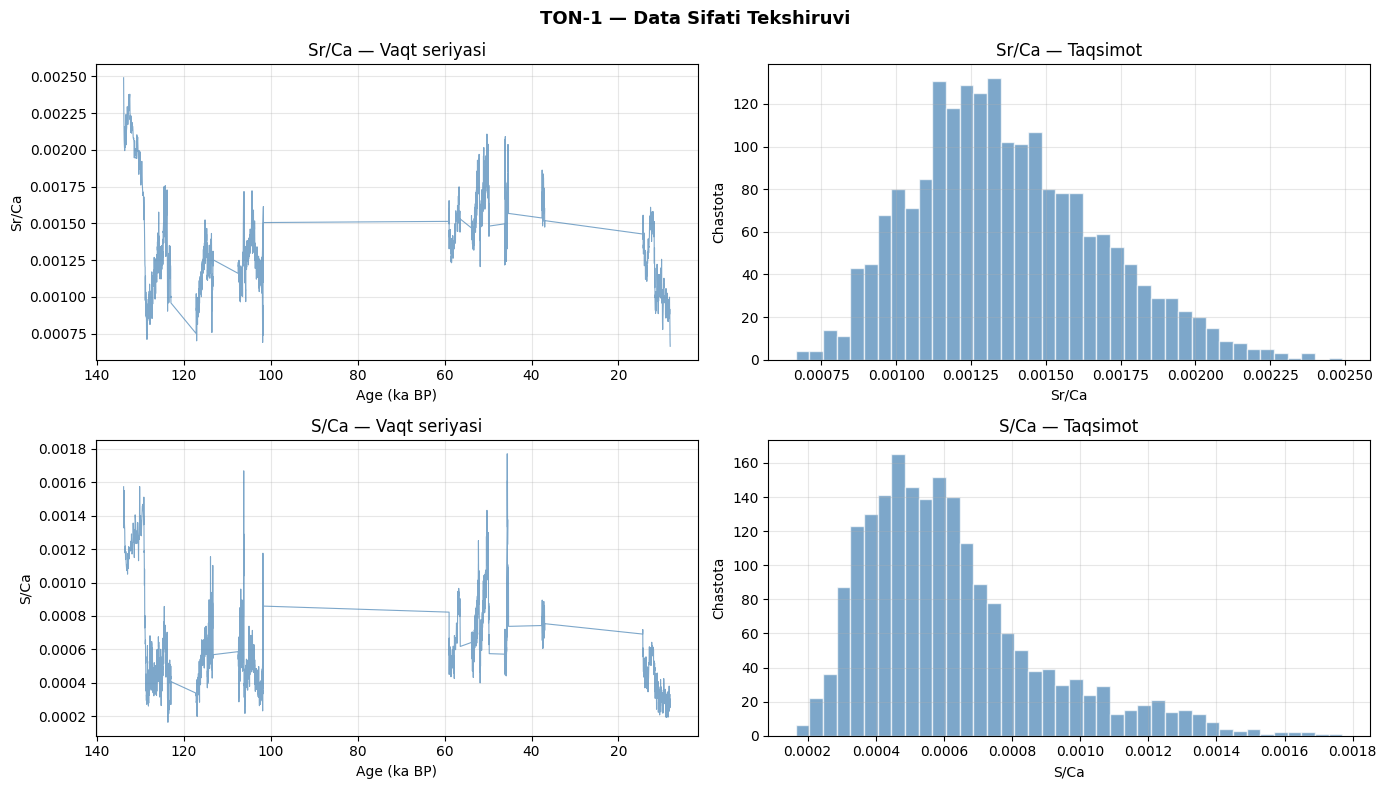


✅ Grafik saqlandi: ton1_quality.png


  📂 TON-2

🔢 Shakl: 2489 rows × 4 columns
📋 Kolonkalar: ['depth_mm', 'age_calBP', 'd13CcarbVPDB', 'd18OcarbVPDB']

⚠️  Missing Values:
   depth_mm            : ✅ yo'q
   age_calBP           : ✅ yo'q
   d13CcarbVPDB        :   22 ta (0.88%)
   d18OcarbVPDB        :   22 ta (0.88%)

🔁 Dublikat qatorlar: 0

🕰️  Vaqt qatori (age_calBP):
   Min age    :      -58.0 cal yr BP
   Max age    :  114,822.0 cal yr BP
   O'rtacha qadam:    46.2 yil
   Min qadam  :     0.0 yil
   Max qadam  : 22394.0 yil
   Std qadam  :   563.6 yil

   ⚠️  Katta bo'shliqlar (>139 yil):
      Age ~36,939 BP → 22394 yillik uzilish
      Age ~45,401 BP → 7710 yillik uzilish
      Age ~51,186 BP → 4790 yillik uzilish
      Age ~56,613 BP → 2597 yillik uzilish
      Age ~71,576 BP → 13446 yillik uzilish
      Age ~73,718 BP → 2003 yillik uzilish
      Age ~76,820 BP → 1247 yillik uzilish
      Age ~81,325 BP → 366 yillik uzilish
      Age ~89,063 BP → 3562 yillik uzilish
      Age ~

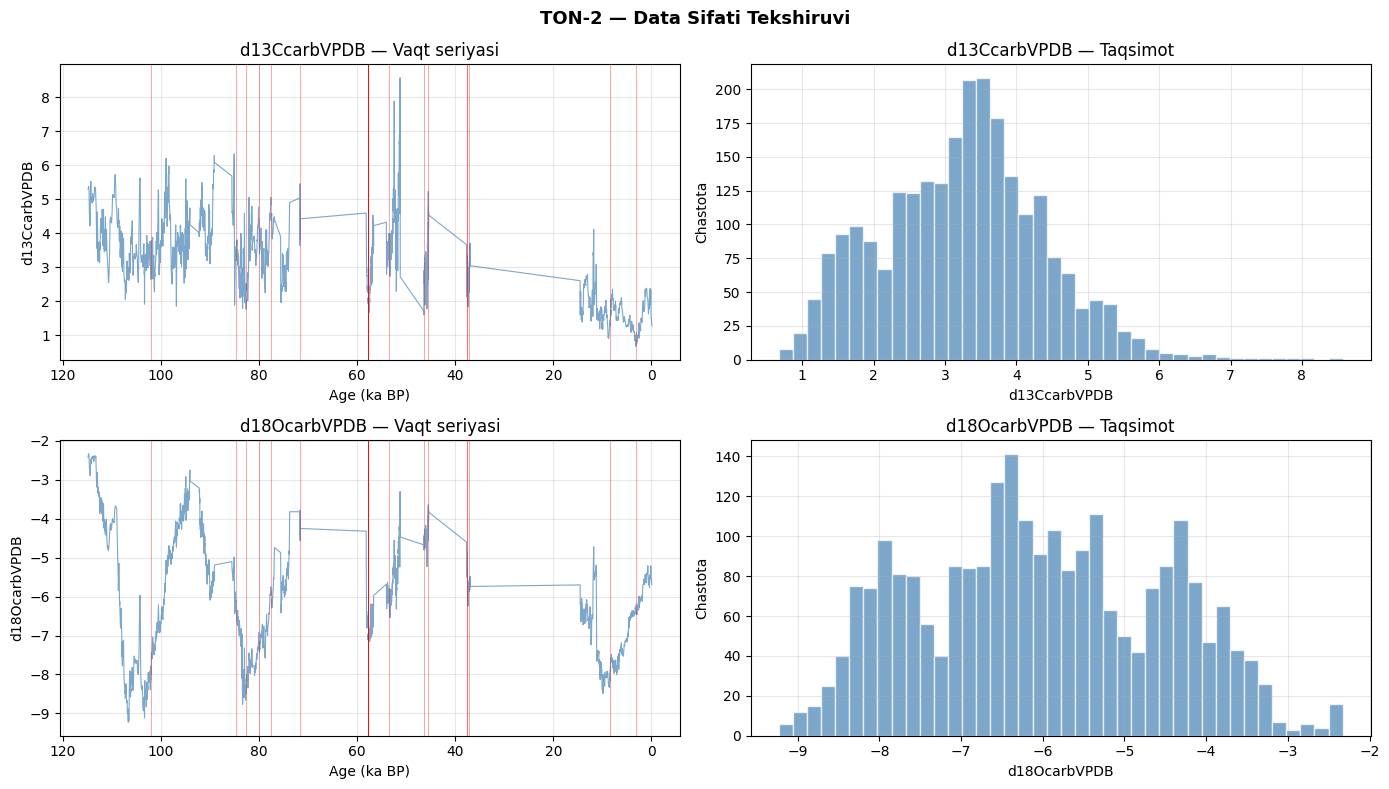


✅ Grafik saqlandi: ton2_quality.png


  ✅ TEKSHIRUV TUGADI

Keyingi qadam: natijalar asosida tozalash usulini tanlaymiz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Fayllarni yuklash ─────────────────────────────────────────
df1 = pd.read_csv("tonnelnaya_cave_data1.csv")
df2 = pd.read_csv("tonnelnaya_cave_data2.csv")

for name, df in [("TON-1", df1), ("TON-2", df2)]:
    print("=" * 60)
    print(f"  📂 {name}")
    print("=" * 60)

    # ── Umumiy ma'lumot ──────────────────────────────────────────
    print(f"\n🔢 Shakl: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"📋 Kolonkalar: {list(df.columns)}")

    # ── Missing values ───────────────────────────────────────────
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    print(f"\n⚠️  Missing Values:")
    for col in df.columns:
        if missing[col] > 0:
            print(f"   {col:20s}: {missing[col]:4d} ta ({missing_pct[col]}%)")
        else:
            print(f"   {col:20s}: ✅ yo'q")

    # ── Dublikatlar ──────────────────────────────────────────────
    dups = df.duplicated().sum()
    print(f"\n🔁 Dublikat qatorlar: {dups}")

    # ── Vaqt qatori tekshiruvi ───────────────────────────────────
    age_col = [c for c in df.columns if 'age' in c.lower()]
    if age_col:
        age = df[age_col[0]].dropna().sort_values()
        gaps = age.diff().dropna()
        print(f"\n🕰️  Vaqt qatori ({age_col[0]}):")
        print(f"   Min age    : {age.min():>10,.1f} cal yr BP")
        print(f"   Max age    : {age.max():>10,.1f} cal yr BP")
        print(f"   O'rtacha qadam: {gaps.mean():>7.1f} yil")
        print(f"   Min qadam  : {gaps.min():>7.1f} yil")
        print(f"   Max qadam  : {gaps.max():>7.1f} yil")
        print(f"   Std qadam  : {gaps.std():>7.1f} yil")

        # Katta bo'shliqlarni aniqlash (o'rtachadan 3x katta)
        threshold = gaps.mean() * 3
        big_gaps = gaps[gaps > threshold]
        if len(big_gaps) > 0:
            print(f"\n   ⚠️  Katta bo'shliqlar (>{threshold:.0f} yil):")
            for idx, gap in big_gaps.items():
                age_at = age.iloc[list(age.index).index(idx)]
                print(f"      Age ~{age_at:,.0f} BP → {gap:.0f} yillik uzilish")
        else:
            print(f"   ✅ Katta bo'shliqlar yo'q")

    # ── Outlier tekshiruvi (IQR usuli) ──────────────────────────
    print(f"\n📊 Outlier tekshiruvi (IQR usuli):")
    num_cols = df.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if 'age' not in c.lower() 
                and 'depth' not in c.lower()]
    
    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        print(f"   {col:20s}: {len(outliers):3d} ta outlier "
              f"(< {lower:.4f} yoki > {upper:.4f})")

    # ── Vizualizatsiya ───────────────────────────────────────────
    num_cols_list = list(num_cols)
    if age_col and num_cols_list:
        fig, axes = plt.subplots(len(num_cols_list), 2,
                                  figsize=(14, 4 * len(num_cols_list)))
        if len(num_cols_list) == 1:
            axes = [axes]
        fig.suptitle(f'{name} — Data Sifati Tekshiruvi', 
                     fontsize=13, fontweight='bold')

        for i, col in enumerate(num_cols_list):
            age_vals = df[age_col[0]]
            proxy_vals = df[col]

            # Chap: Vaqt seriyasi
            ax1 = axes[i][0]
            ax1.plot(age_vals / 1000, proxy_vals, 
                     lw=0.8, color='steelblue', alpha=0.7)
            ax1.set_xlabel('Age (ka BP)')
            ax1.set_ylabel(col)
            ax1.set_title(f'{col} — Vaqt seriyasi')
            ax1.invert_xaxis()
            ax1.grid(True, alpha=0.3)

            # Missing joylarni belgilash
            missing_ages = age_vals[proxy_vals.isnull()]
            for ma in missing_ages:
                ax1.axvline(ma / 1000, color='red', 
                           alpha=0.5, lw=0.5)

            # O'ng: Taqsimot (histogram)
            ax2 = axes[i][1]
            proxy_vals.dropna().hist(ax=ax2, bins=40, 
                                      color='steelblue', alpha=0.7,
                                      edgecolor='white')
            ax2.set_xlabel(col)
            ax2.set_ylabel('Chastota')
            ax2.set_title(f'{col} — Taqsimot')
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{name.lower().replace("-","")}_quality.png', 
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Grafik saqlandi: "
              f"{name.lower().replace('-','')}_quality.png")

    print("\n")

print("=" * 60)
print("  ✅ TEKSHIRUV TUGADI")
print("=" * 60)
print("\nKeyingi qadam: natijalar asosida tozalash usulini tanlaymiz.")

In [2]:
import pandas as pd
import requests
from io import StringIO

# ── NOAA dan to'g'ridan-to'g'ri yuklash ─────────────────────────
urls = {
    'TON1_elem': 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/uzbekistan/tonnelnaya2016ton1elem-noaa.txt',
    'TON2_iso' : 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/uzbekistan/tonnelnaya2016ton2iso.txt',
}

for name, url in urls.items():
    r = requests.get(url)
    lines = [l for l in r.text.split('\n') if not l.startswith('#') and l.strip()]
    df = pd.read_csv(StringIO('\n'.join(lines)), sep='\t')
    df.to_csv(f'{name}_original.csv', index=False)
    print(f"✅ {name}: {df.shape} — kolonkalar: {list(df.columns)}")
    print(df.head(3))
    print()

✅ TON1_elem: (2007, 4) — kolonkalar: ['depth_mm', 'age_calBP', 'Sr/Ca', 'S/Ca']
   depth_mm  age_calBP     Sr/Ca      S/Ca
0       1.0       8104  0.000664  0.000330
1       1.2       8131  0.000692  0.000311
2       1.4       8158  0.000776  0.000252

✅ TON2_iso: (2489, 4) — kolonkalar: ['depth_mm', 'age_calBP', 'd13CcarbVPDB', 'd18OcarbVPDB']
   depth_mm  age_calBP  d13CcarbVPDB  d18OcarbVPDB
0       0.0        -58          1.27         -5.69
1       0.1          9          1.48         -5.55
2       0.2         76          1.51         -5.50




=== TON1_elem ===
shape: (2007, 4)
dtypes:
 depth_mm     float64
age_calBP      int64
Sr/Ca        float64
S/Ca         float64
dtype: object
missing:
 depth_mm     0
age_calBP    0
Sr/Ca        0
S/Ca         0
dtype: int64
duplicates: 0
age min/max: 8104 133832
age monotonic increasing: False

=== TON2_iso ===
shape: (2489, 4)
dtypes:
 depth_mm        float64
age_calBP         int64
d13CcarbVPDB    float64
d18OcarbVPDB    float64
dtype: object
missing:
 depth_mm         0
age_calBP        0
d13CcarbVPDB    22
d18OcarbVPDB    22
dtype: int64
duplicates: 0
age min/max: -58 114822
age monotonic increasing: True

TON1 summary:
              Sr/Ca         S/Ca
count  2007.000000  2007.000000
mean      0.001367     0.000620
std       0.000306     0.000262
min       0.000664     0.000165
25%       0.001146     0.000433
50%       0.001326     0.000568
75%       0.001564     0.000734
max       0.002491     0.001769

TON2 summary (keep all):
        d13CcarbVPDB  d18OcarbVPDB
count   2467.000

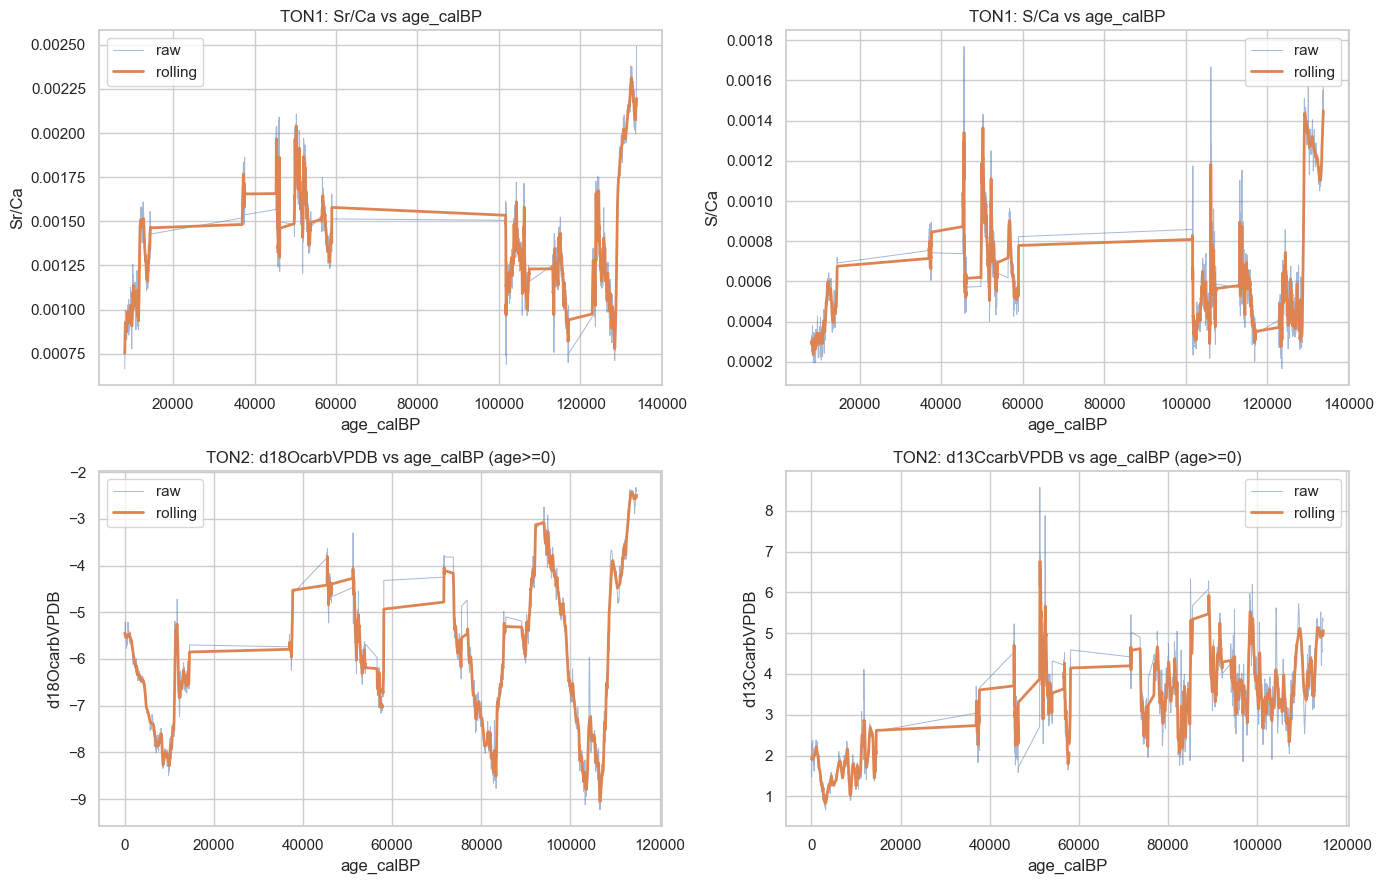


TON2 period stats:
            d13CcarbVPDB                 d18OcarbVPDB                
                   mean       std count         mean       std count
period                                                              
Holocene       1.548168  0.383077   333    -7.107688  0.909132   333
11.7-26 ka     2.100078  0.496212   128    -6.381094  0.370463   128
26-50 ka       2.902837  0.657093   215    -4.731628  0.590852   215
>50 ka         3.674715  0.919132  1790    -5.955994  1.544771  1790


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Yuklash
# -----------------------------
ton1 = pd.read_csv("TON1_elem_original.csv")
ton2 = pd.read_csv("TON2_iso_original.csv")

# -----------------------------
# 2) Data quality check
# -----------------------------
def qc_report(df, name):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("dtypes:\n", df.dtypes)
    print("missing:\n", df.isna().sum())
    print("duplicates:", df.duplicated().sum())
    print("age min/max:", df["age_calBP"].min(), df["age_calBP"].max())
    print("age monotonic increasing:", df["age_calBP"].is_monotonic_increasing)

qc_report(ton1, "TON1_elem")
qc_report(ton2, "TON2_iso")

# TON2_iso: age<0 (masalan -58) "presentdan keyingi" nuqta bo‘lishi mumkin.
# Ikkita variant:
# A) saqlab qolish
ton2_keep = ton2.copy()

# B) faqat paleodata (age>=0)
ton2_paleo = ton2[ton2["age_calBP"] >= 0].copy()

# -----------------------------
# 3) Asosiy statistikalar
# -----------------------------
print("\nTON1 summary:\n", ton1[["Sr/Ca","S/Ca"]].describe())
print("\nTON2 summary (keep all):\n", ton2_keep[["d13CcarbVPDB","d18OcarbVPDB"]].describe())
print("\nTON2 summary (age>=0):\n", ton2_paleo[["d13CcarbVPDB","d18OcarbVPDB"]].describe())

# -----------------------------
# 4) Rolling trend (500 yillik approx oynada)
# -----------------------------
def add_rolling_by_age(df, value_col, age_col="age_calBP", window_years=500):
    d = df.sort_values(age_col).copy()
    # age oralig'iga qarab taxminiy point soni
    age_span = d[age_col].max() - d[age_col].min()
    n = len(d)
    pts = max(5, int((window_years / age_span) * n))
    d[f"{value_col}_roll"] = d[value_col].rolling(pts, center=True, min_periods=max(3, pts//3)).mean()
    return d, pts

ton1_sr, pts_sr = add_rolling_by_age(ton1, "Sr/Ca", window_years=500)
ton1_sc, pts_sc = add_rolling_by_age(ton1, "S/Ca", window_years=500)
ton2_o,  pts_o  = add_rolling_by_age(ton2_paleo, "d18OcarbVPDB", window_years=500)
ton2_c,  pts_c  = add_rolling_by_age(ton2_paleo, "d13CcarbVPDB", window_years=500)

print(f"\nRolling points: TON1 Sr/Ca={pts_sr}, TON1 S/Ca={pts_sc}, TON2 d18O={pts_o}, TON2 d13C={pts_c}")

# -----------------------------
# 5) Korrelyatsiyalar
# -----------------------------
print("\nTON1 corr (Pearson):")
print(ton1[["Sr/Ca","S/Ca"]].corr(method="pearson"))

print("\nTON2 corr (Pearson, age>=0):")
print(ton2_paleo[["d13CcarbVPDB","d18OcarbVPDB"]].corr(method="pearson"))

print("\nTON2 corr (Spearman, age>=0):")
print(ton2_paleo[["d13CcarbVPDB","d18OcarbVPDB"]].corr(method="spearman"))

# -----------------------------
# 6) Vizualizatsiya
# -----------------------------
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)

# TON1 Sr/Ca
axes[0,0].plot(ton1_sr["age_calBP"], ton1_sr["Sr/Ca"], lw=0.7, alpha=0.5, label="raw")
axes[0,0].plot(ton1_sr["age_calBP"], ton1_sr["Sr/Ca_roll"], lw=2, label="rolling")
axes[0,0].set_title("TON1: Sr/Ca vs age_calBP")
axes[0,0].set_xlabel("age_calBP")
axes[0,0].set_ylabel("Sr/Ca")
axes[0,0].legend()

# TON1 S/Ca
axes[0,1].plot(ton1_sc["age_calBP"], ton1_sc["S/Ca"], lw=0.7, alpha=0.5, label="raw")
axes[0,1].plot(ton1_sc["age_calBP"], ton1_sc["S/Ca_roll"], lw=2, label="rolling")
axes[0,1].set_title("TON1: S/Ca vs age_calBP")
axes[0,1].set_xlabel("age_calBP")
axes[0,1].set_ylabel("S/Ca")
axes[0,1].legend()

# TON2 d18O
axes[1,0].plot(ton2_o["age_calBP"], ton2_o["d18OcarbVPDB"], lw=0.7, alpha=0.5, label="raw")
axes[1,0].plot(ton2_o["age_calBP"], ton2_o["d18OcarbVPDB_roll"], lw=2, label="rolling")
axes[1,0].set_title("TON2: d18OcarbVPDB vs age_calBP (age>=0)")
axes[1,0].set_xlabel("age_calBP")
axes[1,0].set_ylabel("d18OcarbVPDB")
axes[1,0].legend()

# TON2 d13C
axes[1,1].plot(ton2_c["age_calBP"], ton2_c["d13CcarbVPDB"], lw=0.7, alpha=0.5, label="raw")
axes[1,1].plot(ton2_c["age_calBP"], ton2_c["d13CcarbVPDB_roll"], lw=2, label="rolling")
axes[1,1].set_title("TON2: d13CcarbVPDB vs age_calBP (age>=0)")
axes[1,1].set_xlabel("age_calBP")
axes[1,1].set_ylabel("d13CcarbVPDB")
axes[1,1].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Davrlar bo'yicha (misol)
# -----------------------------
# Holocene (0-11700), LGM atrofida (19000-26000), Older (>50000)
bins = [0, 11700, 26000, 50000, ton2_paleo["age_calBP"].max()]
labels = ["Holocene", "11.7-26 ka", "26-50 ka", ">50 ka"]
ton2_paleo["period"] = pd.cut(ton2_paleo["age_calBP"], bins=bins, labels=labels, include_lowest=True)

period_stats = ton2_paleo.groupby("period")[["d13CcarbVPDB","d18OcarbVPDB"]].agg(["mean","std","count"])
print("\nTON2 period stats:\n", period_stats)

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# =========================
# Config
# =========================
TON1_FILE = "TON1_elem_original.csv"
TON2_FILE = "TON2_iso_original.csv"

# lag scan diapazoni (yil)
LAG_MIN = -30
LAG_MAX = 30

# =========================
# Helpers
# =========================
def pass_warn_fail(cond_pass, cond_warn=True):
    if cond_pass:
        return "PASS"
    if cond_warn:
        return "WARNING"
    return "FAIL"

def numeric_outlier_rate(series, z_thr=3.5):
    s = series.dropna().astype(float)
    if len(s) < 10:
        return np.nan
    med = np.median(s)
    mad = np.median(np.abs(s - med))
    if mad == 0:
        return 0.0
    mz = 0.6745 * (s - med) / mad
    return float((np.abs(mz) > z_thr).mean())

def inversion_stats(df, depth_col="depth_mm", age_col="age_calBP"):
    d = df[[depth_col, age_col]].dropna().sort_values(depth_col).copy()
    age_diff = d[age_col].diff().dropna()
    inv = (age_diff < 0).sum()
    total = len(age_diff)
    rate = inv / total if total > 0 else np.nan
    return inv, total, rate

def corr_pair(df, a, b):
    x = df[[a, b]].dropna()
    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan
    pr, pp = pearsonr(x[a], x[b])
    sr, sp = spearmanr(x[a], x[b])
    return pr, pp, sr, sp

def qc_report(df, name, value_cols):
    print(f"\n{'='*70}\n{name} QC REPORT\n{'='*70}")
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", int(df.duplicated().sum()))

    # Basic age checks
    age_min, age_max = df["age_calBP"].min(), df["age_calBP"].max()
    monotonic_age = df["age_calBP"].is_monotonic_increasing
    print(f"\nAge min/max: {age_min} / {age_max}")
    print("Age monotonic increasing (file order):", monotonic_age)

    # Inversions by depth
    inv, total, inv_rate = inversion_stats(df, "depth_mm", "age_calBP")
    print(f"Age inversions by depth: {inv}/{total} ({inv_rate:.2%})")

    # Outlier rates
    print("\nOutlier rates (modified-z > 3.5):")
    for c in value_cols:
        rate = numeric_outlier_rate(df[c])
        print(f"  {c}: {rate:.2%}" if pd.notna(rate) else f"  {c}: NA")

    # PASS/WARN flags
    miss_rate = df.isna().mean().mean()
    dup_rate = df.duplicated().mean()
    inv_flag = pass_warn_fail(inv_rate < 0.01, inv_rate < 0.05)
    miss_flag = pass_warn_fail(miss_rate < 0.01, miss_rate < 0.05)
    dup_flag = pass_warn_fail(dup_rate == 0, dup_rate < 0.01)

    print("\nQC Flags:")
    print(f"  Missingness: {miss_flag} (mean rate={miss_rate:.2%})")
    print(f"  Duplicates : {dup_flag} (rate={dup_rate:.2%})")
    print(f"  Age-depth  : {inv_flag} (inversion rate={inv_rate:.2%})")

def align_by_nearest_age(df_a, df_b, col_a, col_b, tol_years=80):
    """
    df_a: target dataframe (age, col_a), df_b: source dataframe (age, col_b)
    nearest age match within tolerance.
    """
    a = df_a[["age_calBP", col_a]].dropna().sort_values("age_calBP").copy()
    b = df_b[["age_calBP", col_b]].dropna().sort_values("age_calBP").copy()

    merged = pd.merge_asof(
        a, b,
        on="age_calBP",
        direction="nearest",
        tolerance=tol_years
    )
    merged = merged.dropna()
    return merged

def lag_scan(df, x_col, y_col, lag_min=-30, lag_max=30):
    """
    lag > 0: x(t) with y(t+lag)
    """
    d = df[["age_calBP", x_col, y_col]].dropna().sort_values("age_calBP").copy()
    results = []
    for lag in range(lag_min, lag_max + 1):
        t = d.copy()
        t["age_shift"] = t["age_calBP"] + lag
        m = pd.merge_asof(
            t[["age_shift", x_col]].sort_values("age_shift"),
            d[["age_calBP", y_col]].sort_values("age_calBP"),
            left_on="age_shift",
            right_on="age_calBP",
            direction="nearest",
            tolerance=1
        ).dropna()

        n = len(m)
        if n < 10:
            results.append((lag, n, np.nan, np.nan))
            continue
        r_p, p_p = pearsonr(m[x_col], m[y_col])
        results.append((lag, n, r_p, p_p))

    out = pd.DataFrame(results, columns=["lag_year", "n_pairs", "pearson_r", "p_value"])
    out["abs_r"] = out["pearson_r"].abs()
    out = out.sort_values("lag_year").reset_index(drop=True)
    return out

# =========================
# Main
# =========================
if __name__ == "__main__":
    ton1 = pd.read_csv(TON1_FILE)
    ton2 = pd.read_csv(TON2_FILE)

    # TON2 paleo-only copy
    ton2_paleo = ton2[ton2["age_calBP"] >= 0].copy()

    # 1) QC
    qc_report(ton1, "TON1_elem", ["Sr/Ca", "S/Ca"])
    qc_report(ton2, "TON2_iso (all)", ["d13CcarbVPDB", "d18OcarbVPDB"])
    qc_report(ton2_paleo, "TON2_iso (age>=0)", ["d13CcarbVPDB", "d18OcarbVPDB"])

    # 2) Internal consistency
    print(f"\n{'='*70}\nINTERNAL CONSISTENCY\n{'='*70}")
    pr, pp, sr, sp = corr_pair(ton1, "Sr/Ca", "S/Ca")
    print(f"TON1 Sr/Ca vs S/Ca: Pearson r={pr:.3f} (p={pp:.2e}), Spearman rho={sr:.3f} (p={sp:.2e})")

    pr, pp, sr, sp = corr_pair(ton2_paleo, "d13CcarbVPDB", "d18OcarbVPDB")
    print(f"TON2 d13C vs d18O   : Pearson r={pr:.3f} (p={pp:.2e}), Spearman rho={sr:.3f} (p={sp:.2e})")

    # 3) Cross-dataset alignment (age-nearest) for lag exploration
    print(f"\n{'='*70}\nTON1 vs TON2 ALIGNMENT\n{'='*70}")
    # TON1 Sr/Ca with TON2 d18O
    aligned = align_by_nearest_age(
        ton1.rename(columns={"Sr/Ca": "SrCa"}),
        ton2_paleo.rename(columns={"d18OcarbVPDB": "d18O"}),
        col_a="SrCa",
        col_b="d18O",
        tol_years=80
    )
    print("Aligned pairs (Sr/Ca ~ d18O):", aligned.shape[0])

    # 4) Lag scan
    if aligned.shape[0] >= 20:
        lag_df = lag_scan(
            aligned.rename(columns={"SrCa": "x", "d18O": "y"}),
            x_col="x", y_col="y",
            lag_min=LAG_MIN, lag_max=LAG_MAX
        )
        best = lag_df.dropna(subset=["abs_r"]).sort_values("abs_r", ascending=False).head(1)
        print(f"\n{'='*70}\nLAG SCAN RESULT\n{'='*70}")
        if len(best):
            b = best.iloc[0]
            print(f"Best lag: {int(b['lag_year'])} years | r={b['pearson_r']:.3f} | p={b['p_value']:.2e} | n={int(b['n_pairs'])}")
        else:
            print("No valid lag result (too few pairs).")

        lag_df.to_csv("lag_scan_ton1_srca_vs_ton2_d18o.csv", index=False)
        print("Saved: lag_scan_ton1_srca_vs_ton2_d18o.csv")
    else:
        print("Lag scan skipped: not enough aligned pairs.")

    print("\nDONE.")


TON1_elem QC REPORT
Shape: (2007, 4)

Dtypes:
depth_mm     float64
age_calBP      int64
Sr/Ca        float64
S/Ca         float64
dtype: object

Missing values:
depth_mm     0
age_calBP    0
Sr/Ca        0
S/Ca         0
dtype: int64

Duplicate rows: 0

Age min/max: 8104 / 133832
Age monotonic increasing (file order): False
Age inversions by depth: 0/2006 (0.00%)

Outlier rates (modified-z > 3.5):
  Sr/Ca: 0.15%
  S/Ca: 2.09%

QC Flags:
  Missingness: PASS (mean rate=0.00%)
  Duplicates : PASS (rate=0.00%)
  Age-depth  : PASS (inversion rate=0.00%)

TON2_iso (all) QC REPORT
Shape: (2489, 4)

Dtypes:
depth_mm        float64
age_calBP         int64
d13CcarbVPDB    float64
d18OcarbVPDB    float64
dtype: object

Missing values:
depth_mm         0
age_calBP        0
d13CcarbVPDB    22
d18OcarbVPDB    22
dtype: int64

Duplicate rows: 0

Age min/max: -58 / 114822
Age monotonic increasing (file order): True
Age inversions by depth: 0/2488 (0.00%)

Outlier rates (modified-z > 3.5):
  d13CcarbV

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# =========================================================
# Robust lag scan for TON1 (Sr/Ca) vs TON2 (d18O)
# =========================================================

TON1_FILE = "TON1_elem_original.csv"
TON2_FILE = "TON2_iso_original.csv"

LAG_MIN, LAG_MAX = -30, 30
YEAR_STEP = 1           # annual grid
MIN_YEAR = 8104         # overlap min (TON1 starts ~8104)
MAX_YEAR = 114822       # overlap max (TON2 max ~114822)

def prep_series(df, age_col, val_col, min_year, max_year, step=1):
    d = df[[age_col, val_col]].dropna().copy()
    d = d[(d[age_col] >= min_year) & (d[age_col] <= max_year)]
    d = d.sort_values(age_col)

    # bir xil age bo'lsa o'rtacha
    d = d.groupby(age_col, as_index=False)[val_col].mean()

    # annual grid
    grid = pd.DataFrame({age_col: np.arange(min_year, max_year + 1, step)})
    merged = grid.merge(d, on=age_col, how="left")

    # interpolate both directions
    merged[val_col] = merged[val_col].interpolate(method="linear", limit_direction="both")
    return merged

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x)

def moving_average(x, w=31):
    # odd window tavsiya: 21, 31, 51
    s = pd.Series(x)
    return s.rolling(w, center=True, min_periods=max(5, w//3)).mean().to_numpy()

def lag_scan_grid(df, age_col, x_col, y_col, lag_min=-30, lag_max=30):
    out = []
    base = df[[age_col, x_col, y_col]].dropna().copy()

    for lag in range(lag_min, lag_max + 1):
        t = base.copy()
        # lag > 0 => x(t) with y(t+lag)
        t["age_y"] = t[age_col] + lag

        m = t.merge(
            base[[age_col, y_col]].rename(columns={age_col: "age_y", y_col: "y_shift"}),
            on="age_y",
            how="inner"
        ).dropna(subset=[x_col, "y_shift"])

        n = len(m)
        if n < 30:
            out.append([lag, n, np.nan, np.nan, np.nan, np.nan])
            continue

        pr, pp = pearsonr(m[x_col], m["y_shift"])
        sr, sp = spearmanr(m[x_col], m["y_shift"])
        out.append([lag, n, pr, pp, sr, sp])

    res = pd.DataFrame(out, columns=[
        "lag_year", "n_pairs", "pearson_r", "pearson_p", "spearman_rho", "spearman_p"
    ])
    res["abs_pearson_r"] = res["pearson_r"].abs()
    return res.sort_values("lag_year").reset_index(drop=True)

# 1) load
ton1 = pd.read_csv(TON1_FILE)
ton2 = pd.read_csv(TON2_FILE)
ton2 = ton2[ton2["age_calBP"] >= 0].copy()

# 2) common grid
s1 = prep_series(ton1, "age_calBP", "Sr/Ca", MIN_YEAR, MAX_YEAR, YEAR_STEP)
s2 = prep_series(ton2, "age_calBP", "d18OcarbVPDB", MIN_YEAR, MAX_YEAR, YEAR_STEP)

grid = s1.merge(s2, on="age_calBP", how="inner").dropna()
print("Common grid size:", grid.shape)

# 3) optional standardization
grid["SrCa_z"] = zscore(grid["Sr/Ca"])
grid["d18O_z"] = zscore(grid["d18OcarbVPDB"])

# 4) raw lag scan
raw_res = lag_scan_grid(grid, "age_calBP", "SrCa_z", "d18O_z", LAG_MIN, LAG_MAX)
raw_res.to_csv("lag_scan_robust_raw.csv", index=False)

best_raw = raw_res.dropna(subset=["pearson_r"]).sort_values("abs_pearson_r", ascending=False).head(5)
print("\nTop-5 RAW lags by |r|:")
print(best_raw[["lag_year", "n_pairs", "pearson_r", "pearson_p", "spearman_rho"]])

# 5) detrended lag scan (moving-average subtraction)
W = 31
grid["SrCa_dt"] = grid["SrCa_z"] - moving_average(grid["SrCa_z"], w=W)
grid["d18O_dt"] = grid["d18O_z"] - moving_average(grid["d18O_z"], w=W)
dt = grid.dropna(subset=["SrCa_dt", "d18O_dt"]).copy()

dt_res = lag_scan_grid(dt, "age_calBP", "SrCa_dt", "d18O_dt", LAG_MIN, LAG_MAX)
dt_res.to_csv("lag_scan_robust_detrended.csv", index=False)

best_dt = dt_res.dropna(subset=["pearson_r"]).sort_values("abs_pearson_r", ascending=False).head(5)
print("\nTop-5 DETRENDED lags by |r|:")
print(best_dt[["lag_year", "n_pairs", "pearson_r", "pearson_p", "spearman_rho"]])

# 6) quick decision hint
b0 = best_raw.iloc[0]
b1 = best_dt.iloc[0]
print("\nBest RAW lag:", int(b0["lag_year"]), "r=", round(float(b0["pearson_r"]), 3), "n=", int(b0["n_pairs"]))
print("Best DET lag:", int(b1["lag_year"]), "r=", round(float(b1["pearson_r"]), 3), "n=", int(b1["n_pairs"]))
print("\nSaved: lag_scan_robust_raw.csv, lag_scan_robust_detrended.csv")

Common grid size: (106719, 3)

Top-5 RAW lags by |r|:
   lag_year  n_pairs  pearson_r  pearson_p  spearman_rho
0       -30   106689   0.337822        0.0      0.355882
1       -29   106690   0.337731        0.0      0.355794
2       -28   106691   0.337640        0.0      0.355704
3       -27   106692   0.337549        0.0      0.355613
4       -26   106693   0.337458        0.0      0.355519

Top-5 DETRENDED lags by |r|:
   lag_year  n_pairs  pearson_r     pearson_p  spearman_rho
5       -25   106694  -0.025661  5.147893e-17      0.000170
4       -26   106693  -0.025262  1.549647e-16     -0.000753
6       -24   106695  -0.025198  1.840920e-16      0.002631
7       -23   106696  -0.023502  1.618977e-14      0.002560
3       -27   106692  -0.023322  2.560697e-14     -0.002802

Best RAW lag: -30 r= 0.338 n= 106689
Best DET lag: -25 r= -0.026 n= 106694

Saved: lag_scan_robust_raw.csv, lag_scan_robust_detrended.csv


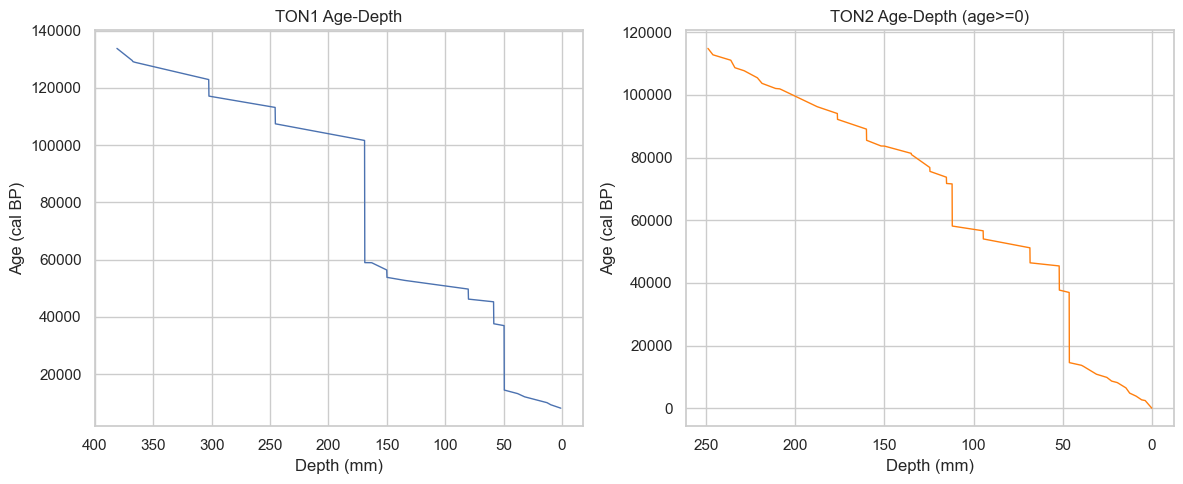

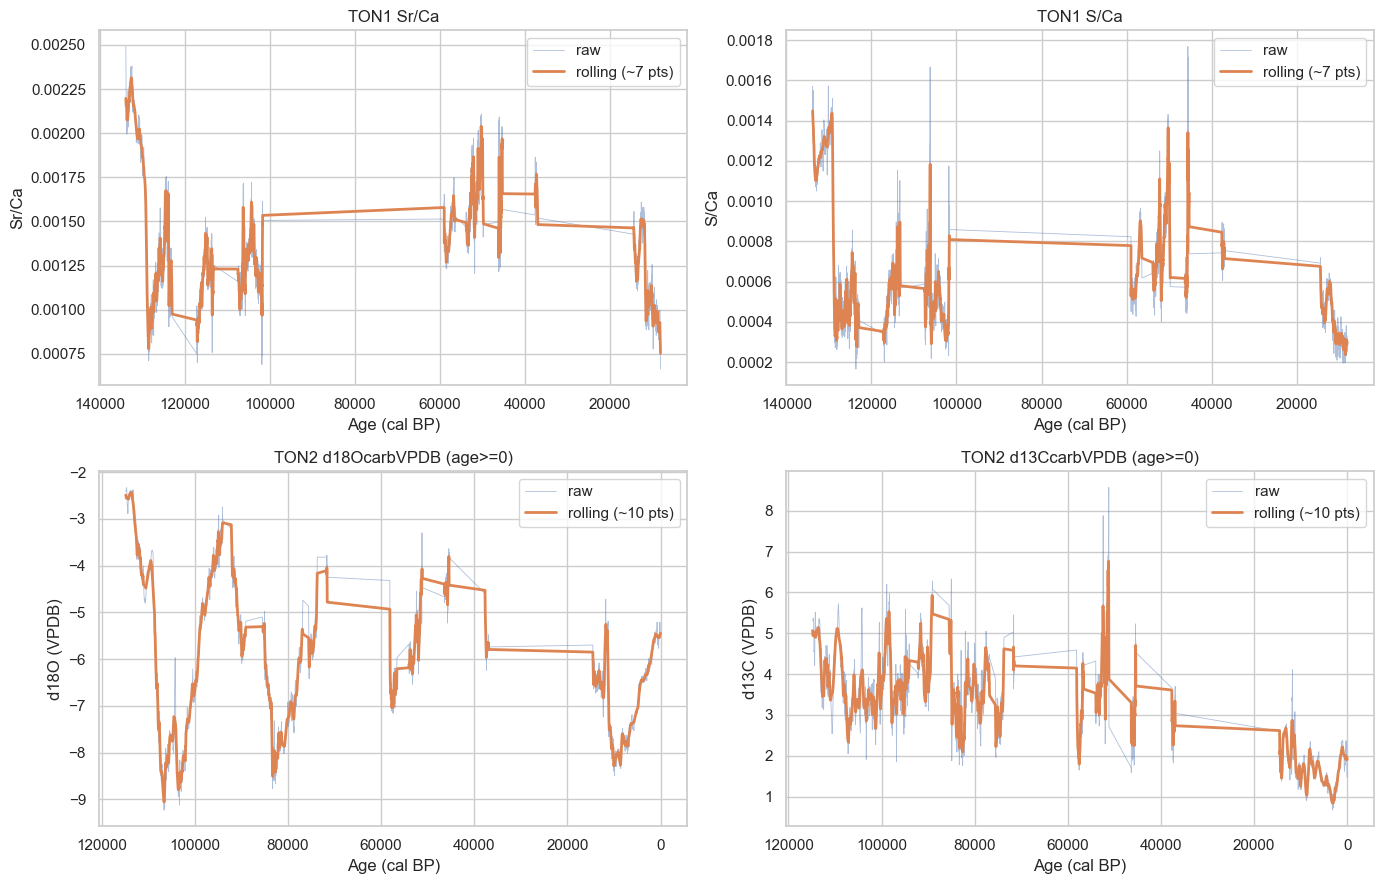

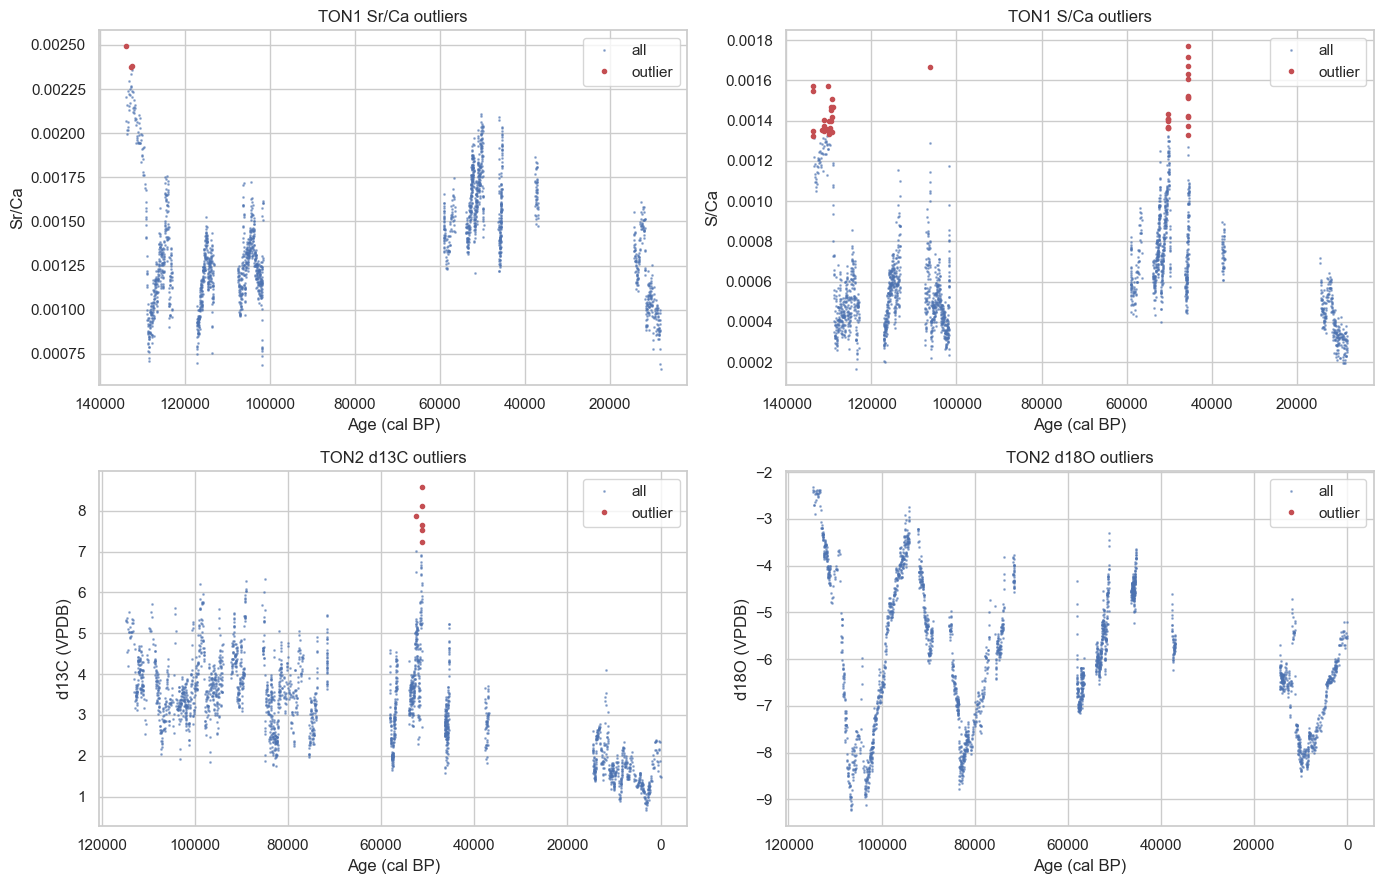

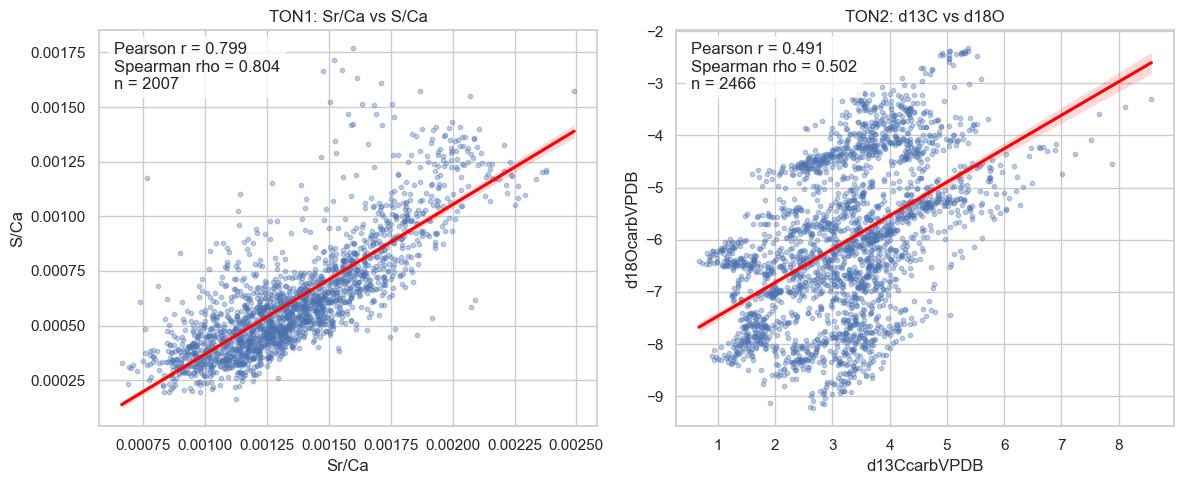

Saved figures:
 - fig1_age_depth.png
 - fig2_timeseries_raw_rolling.png
 - fig3_outlier_diagnostics.png
 - fig4_correlation_scatter.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Load
# =========================
ton1 = pd.read_csv("TON1_elem_original.csv")
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2p = ton2[ton2["age_calBP"] >= 0].copy()

sns.set(style="whitegrid", context="notebook")

# =========================
# Helper functions
# =========================
def rolling_by_age(df, value_col, age_col="age_calBP", window_years=500):
    d = df[[age_col, value_col]].dropna().sort_values(age_col).copy()
    span = d[age_col].max() - d[age_col].min()
    n = len(d)
    pts = max(7, int((window_years / span) * n))
    d[f"{value_col}_roll"] = d[value_col].rolling(
        pts, center=True, min_periods=max(3, pts // 3)
    ).mean()
    return d, pts

def modified_z_outliers(series, thr=3.5):
    s = series.copy()
    med = np.nanmedian(s)
    mad = np.nanmedian(np.abs(s - med))
    if mad == 0 or np.isnan(mad):
        return np.zeros(len(s), dtype=bool)
    mz = 0.6745 * (s - med) / mad
    return np.abs(mz) > thr

def annotate_corr(ax, x, y):
    m = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(m) < 3:
        return
    r = m["x"].corr(m["y"], method="pearson")
    rho = m["x"].corr(m["y"], method="spearman")
    ax.text(
        0.03, 0.97,
        f"Pearson r = {r:.3f}\nSpearman rho = {rho:.3f}\nn = {len(m)}",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

# =========================
# FIGURE 1: Age-depth reliability
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ton1["depth_mm"], ton1["age_calBP"], lw=1.0)
axes[0].set_title("TON1 Age-Depth")
axes[0].set_xlabel("Depth (mm)")
axes[0].set_ylabel("Age (cal BP)")
axes[0].invert_xaxis()  # optional in speleo style

axes[1].plot(ton2p["depth_mm"], ton2p["age_calBP"], lw=1.0, color="tab:orange")
axes[1].set_title("TON2 Age-Depth (age>=0)")
axes[1].set_xlabel("Depth (mm)")
axes[1].set_ylabel("Age (cal BP)")
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig("fig1_age_depth.png", dpi=300)
plt.show()

# =========================
# FIGURE 2: Raw + rolling time series
# =========================
t1_sr, w1 = rolling_by_age(ton1, "Sr/Ca", window_years=500)
t1_sc, w2 = rolling_by_age(ton1, "S/Ca", window_years=500)
t2_o,  w3 = rolling_by_age(ton2p, "d18OcarbVPDB", window_years=500)
t2_c,  w4 = rolling_by_age(ton2p, "d13CcarbVPDB", window_years=500)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# TON1 Sr/Ca
axes[0, 0].plot(t1_sr["age_calBP"], t1_sr["Sr/Ca"], lw=0.6, alpha=0.45, label="raw")
axes[0, 0].plot(t1_sr["age_calBP"], t1_sr["Sr/Ca_roll"], lw=2.0, label=f"rolling (~{w1} pts)")
axes[0, 0].set_title("TON1 Sr/Ca")
axes[0, 0].set_xlabel("Age (cal BP)")
axes[0, 0].set_ylabel("Sr/Ca")
axes[0, 0].invert_xaxis()
axes[0, 0].legend()

# TON1 S/Ca
axes[0, 1].plot(t1_sc["age_calBP"], t1_sc["S/Ca"], lw=0.6, alpha=0.45, label="raw")
axes[0, 1].plot(t1_sc["age_calBP"], t1_sc["S/Ca_roll"], lw=2.0, label=f"rolling (~{w2} pts)")
axes[0, 1].set_title("TON1 S/Ca")
axes[0, 1].set_xlabel("Age (cal BP)")
axes[0, 1].set_ylabel("S/Ca")
axes[0, 1].invert_xaxis()
axes[0, 1].legend()

# TON2 d18O
axes[1, 0].plot(t2_o["age_calBP"], t2_o["d18OcarbVPDB"], lw=0.6, alpha=0.45, label="raw")
axes[1, 0].plot(t2_o["age_calBP"], t2_o["d18OcarbVPDB_roll"], lw=2.0, label=f"rolling (~{w3} pts)")
axes[1, 0].set_title("TON2 d18OcarbVPDB (age>=0)")
axes[1, 0].set_xlabel("Age (cal BP)")
axes[1, 0].set_ylabel("d18O (VPDB)")
axes[1, 0].invert_xaxis()
axes[1, 0].legend()

# TON2 d13C
axes[1, 1].plot(t2_c["age_calBP"], t2_c["d13CcarbVPDB"], lw=0.6, alpha=0.45, label="raw")
axes[1, 1].plot(t2_c["age_calBP"], t2_c["d13CcarbVPDB_roll"], lw=2.0, label=f"rolling (~{w4} pts)")
axes[1, 1].set_title("TON2 d13CcarbVPDB (age>=0)")
axes[1, 1].set_xlabel("Age (cal BP)")
axes[1, 1].set_ylabel("d13C (VPDB)")
axes[1, 1].invert_xaxis()
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("fig2_timeseries_raw_rolling.png", dpi=300)
plt.show()

# =========================
# FIGURE 3: Outlier diagnostics
# =========================
t1 = ton1.copy()
t2 = ton2p.copy()

t1["Sr_out"] = modified_z_outliers(t1["Sr/Ca"], thr=3.5)
t1["S_out"] = modified_z_outliers(t1["S/Ca"], thr=3.5)
t2["d13C_out"] = modified_z_outliers(t2["d13CcarbVPDB"], thr=3.5)
t2["d18O_out"] = modified_z_outliers(t2["d18OcarbVPDB"], thr=3.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Sr/Ca outliers
axes[0, 0].plot(t1["age_calBP"], t1["Sr/Ca"], ".", ms=2, alpha=0.5, label="all")
axes[0, 0].plot(t1.loc[t1["Sr_out"], "age_calBP"], t1.loc[t1["Sr_out"], "Sr/Ca"],
                "ro", ms=3, label="outlier")
axes[0, 0].set_title("TON1 Sr/Ca outliers")
axes[0, 0].set_xlabel("Age (cal BP)")
axes[0, 0].set_ylabel("Sr/Ca")
axes[0, 0].invert_xaxis()
axes[0, 0].legend()

# S/Ca outliers
axes[0, 1].plot(t1["age_calBP"], t1["S/Ca"], ".", ms=2, alpha=0.5, label="all")
axes[0, 1].plot(t1.loc[t1["S_out"], "age_calBP"], t1.loc[t1["S_out"], "S/Ca"],
                "ro", ms=3, label="outlier")
axes[0, 1].set_title("TON1 S/Ca outliers")
axes[0, 1].set_xlabel("Age (cal BP)")
axes[0, 1].set_ylabel("S/Ca")
axes[0, 1].invert_xaxis()
axes[0, 1].legend()

# d13C outliers
axes[1, 0].plot(t2["age_calBP"], t2["d13CcarbVPDB"], ".", ms=2, alpha=0.5, label="all")
axes[1, 0].plot(t2.loc[t2["d13C_out"], "age_calBP"], t2.loc[t2["d13C_out"], "d13CcarbVPDB"],
                "ro", ms=3, label="outlier")
axes[1, 0].set_title("TON2 d13C outliers")
axes[1, 0].set_xlabel("Age (cal BP)")
axes[1, 0].set_ylabel("d13C (VPDB)")
axes[1, 0].invert_xaxis()
axes[1, 0].legend()

# d18O outliers
axes[1, 1].plot(t2["age_calBP"], t2["d18OcarbVPDB"], ".", ms=2, alpha=0.5, label="all")
axes[1, 1].plot(t2.loc[t2["d18O_out"], "age_calBP"], t2.loc[t2["d18O_out"], "d18OcarbVPDB"],
                "ro", ms=3, label="outlier")
axes[1, 1].set_title("TON2 d18O outliers")
axes[1, 1].set_xlabel("Age (cal BP)")
axes[1, 1].set_ylabel("d18O (VPDB)")
axes[1, 1].invert_xaxis()
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("fig3_outlier_diagnostics.png", dpi=300)
plt.show()

# =========================
# FIGURE 4: Correlation scatter
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TON1 Sr/Ca vs S/Ca
a = ton1[["Sr/Ca", "S/Ca"]].dropna()
sns.regplot(data=a, x="Sr/Ca", y="S/Ca", scatter_kws={"s":10, "alpha":0.35}, line_kws={"color":"red"}, ax=axes[0])
axes[0].set_title("TON1: Sr/Ca vs S/Ca")
annotate_corr(axes[0], a["Sr/Ca"], a["S/Ca"])

# TON2 d13C vs d18O
b = ton2p[["d13CcarbVPDB", "d18OcarbVPDB"]].dropna()
sns.regplot(data=b, x="d13CcarbVPDB", y="d18OcarbVPDB", scatter_kws={"s":10, "alpha":0.35}, line_kws={"color":"red"}, ax=axes[1])
axes[1].set_title("TON2: d13C vs d18O")
annotate_corr(axes[1], b["d13CcarbVPDB"], b["d18OcarbVPDB"])

plt.tight_layout()
plt.savefig("fig4_correlation_scatter.png", dpi=300)
plt.show()

print("Saved figures:")
print(" - fig1_age_depth.png")
print(" - fig2_timeseries_raw_rolling.png")
print(" - fig3_outlier_diagnostics.png")
print(" - fig4_correlation_scatter.png")


=== Period Stats ===
           d13CcarbVPDB                 d18OcarbVPDB                
                   mean       std count         mean       std count
period                                                              
Holocene       1.548168  0.383077   333    -7.107688  0.909132   333
11.7-26 ka     2.100078  0.496212   128    -6.381094  0.370463   128
26-50 ka       2.902837  0.657093   215    -4.731628  0.590852   215
>50 ka         3.674715  0.919132  1790    -5.955994  1.544771  1790

=== Period Correlations ===
       period     n  pearson_r  spearman_rho
0    Holocene   333   0.122913      0.036634
1  11.7-26 ka   128   0.602515      0.290590
2    26-50 ka   215   0.475431      0.577195
3      >50 ka  1790   0.528471      0.562515

Saved: period_correlations_ton2.csv, moving_correlation_ton2.csv


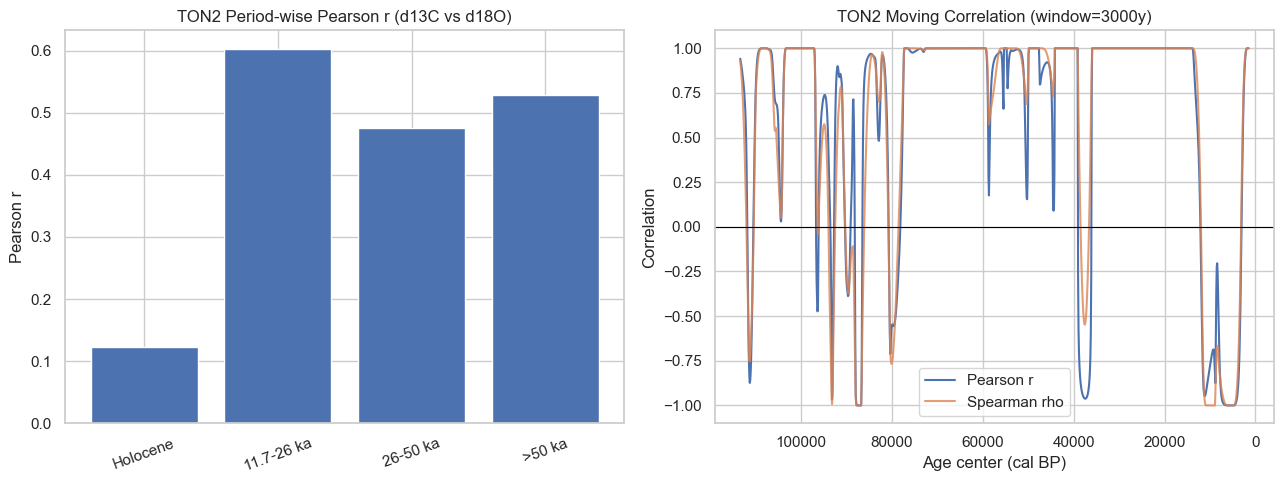

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load
# =========================
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2[ton2["age_calBP"] >= 0].copy()
ton2 = ton2.dropna(subset=["d13CcarbVPDB", "d18OcarbVPDB"]).sort_values("age_calBP")

# =========================
# 1) PERIOD-WISE COMPARISON
# =========================
# Siz xohlasangiz bu binlarni o'zgartirasiz
bins = [0, 11700, 26000, 50000, ton2["age_calBP"].max()]
labels = ["Holocene", "11.7-26 ka", "26-50 ka", ">50 ka"]
ton2["period"] = pd.cut(ton2["age_calBP"], bins=bins, labels=labels, include_lowest=True)

# Har davr uchun statistika
stats = ton2.groupby("period")[["d13CcarbVPDB", "d18OcarbVPDB"]].agg(["mean", "std", "count"])
print("\n=== Period Stats ===")
print(stats)

# Har davr uchun correlation
rows = []
for p, g in ton2.groupby("period"):
    if len(g) >= 10:
        r = g["d13CcarbVPDB"].corr(g["d18OcarbVPDB"], method="pearson")
        rho = g["d13CcarbVPDB"].corr(g["d18OcarbVPDB"], method="spearman")
        rows.append([p, len(g), r, rho])
period_corr = pd.DataFrame(rows, columns=["period", "n", "pearson_r", "spearman_rho"])
print("\n=== Period Correlations ===")
print(period_corr)

period_corr.to_csv("period_correlations_ton2.csv", index=False)

# =========================
# 2) MOVING CORRELATION
# =========================
# Age bo'yicha regular grid (50 yil)
grid_age = np.arange(int(ton2["age_calBP"].min()), int(ton2["age_calBP"].max()) + 1, 50)
g = pd.DataFrame({"age_calBP": grid_age})
g = g.merge(ton2[["age_calBP", "d13CcarbVPDB"]], on="age_calBP", how="left")
g = g.merge(ton2[["age_calBP", "d18OcarbVPDB"]], on="age_calBP", how="left", suffixes=("_d13C", "_d18O"))
g["d13CcarbVPDB"] = g["d13CcarbVPDB"].interpolate(limit_direction="both")
g["d18OcarbVPDB"] = g["d18OcarbVPDB"].interpolate(limit_direction="both")

# moving window (masalan 3000 yil)
window_years = 3000
step_years = 100
centers = np.arange(g["age_calBP"].min() + window_years//2,
                    g["age_calBP"].max() - window_years//2 + 1,
                    step_years)

mc = []
for c in centers:
    lo, hi = c - window_years/2, c + window_years/2
    w = g[(g["age_calBP"] >= lo) & (g["age_calBP"] <= hi)]
    if len(w) >= 20:
        r = w["d13CcarbVPDB"].corr(w["d18OcarbVPDB"], method="pearson")
        rho = w["d13CcarbVPDB"].corr(w["d18OcarbVPDB"], method="spearman")
        mc.append([c, len(w), r, rho])

mc = pd.DataFrame(mc, columns=["age_center", "n", "pearson_r", "spearman_rho"])
mc.to_csv("moving_correlation_ton2.csv", index=False)
print("\nSaved: period_correlations_ton2.csv, moving_correlation_ton2.csv")

# =========================
# 3) PLOTS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Period-wise bar (pearson)
axes[0].bar(period_corr["period"].astype(str), period_corr["pearson_r"])
axes[0].set_title("TON2 Period-wise Pearson r (d13C vs d18O)")
axes[0].set_ylabel("Pearson r")
axes[0].tick_params(axis='x', rotation=20)

# Moving correlation curve
axes[1].plot(mc["age_center"], mc["pearson_r"], label="Pearson r")
axes[1].plot(mc["age_center"], mc["spearman_rho"], label="Spearman rho", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("TON2 Moving Correlation (window=3000y)")
axes[1].set_xlabel("Age center (cal BP)")
axes[1].set_ylabel("Correlation")
axes[1].invert_xaxis()
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_period_and_moving_corr_ton2.png", dpi=300)
plt.show()

Grid size: (2297, 3)
Age range: 9 to 114809


C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Saved: moving_correlation_ton2_robust.csv


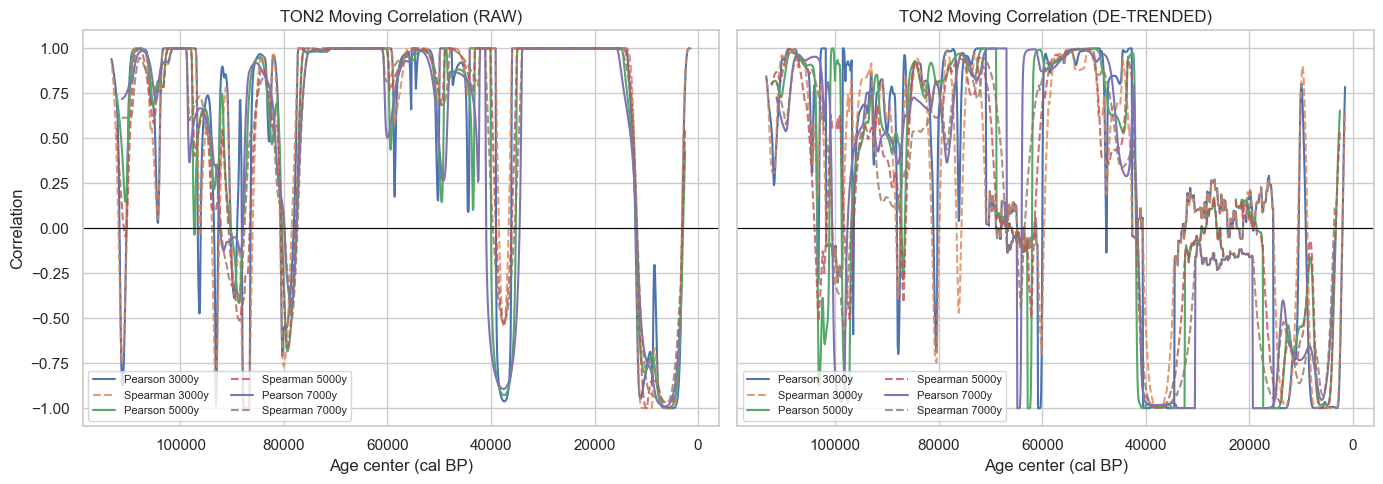


=== Moving-correlation summary ===
                       pearson_r                          spearman_rho  \
                            mean       std       min  max         mean   
mode      window_years                                                   
detrended 3000          0.259946  0.669021 -1.000000  1.0     0.223112   
          5000          0.233774  0.724318 -1.000000  1.0     0.198031   
          7000          0.195283  0.742389 -1.000000  1.0     0.159964   
raw       3000          0.608947  0.655177 -1.000000  1.0     0.610092   
          5000          0.583445  0.623104 -0.999475  1.0     0.601838   
          7000          0.555589  0.618973 -0.992088  1.0     0.600206   

                                                      
                             std       min       max  
mode      window_years                                
detrended 3000          0.594079 -0.999828  0.995480  
          5000          0.626054 -1.000000  0.999665  
          7000        

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# TON2 robust moving-correlation (artifact-safe workflow)
# =========================================================

FILE = "TON2_iso_original.csv"

# Grid and windows
GRID_STEP = 50                      # years
WINDOWS = [3000, 5000, 7000]        # sensitivity test
STEP_CENTER = 100                   # move window center every 100 years
MIN_VALID_FRAC = 0.8                # minimum valid fraction inside a window

# -------------------------
# 1) Load and clean
# -------------------------
df = pd.read_csv(FILE)
df = df[df["age_calBP"] >= 0].copy()
df = df.sort_values("age_calBP")

# Keep only needed
d13 = df[["age_calBP", "d13CcarbVPDB"]].dropna().groupby("age_calBP", as_index=False).mean()
d18 = df[["age_calBP", "d18OcarbVPDB"]].dropna().groupby("age_calBP", as_index=False).mean()

# Overlap range
age_min = int(max(d13["age_calBP"].min(), d18["age_calBP"].min()))
age_max = int(min(d13["age_calBP"].max(), d18["age_calBP"].max()))

# -------------------------
# 2) Build common grid (separate interpolation per variable)
# -------------------------
grid_age = np.arange(age_min, age_max + 1, GRID_STEP)
grid = pd.DataFrame({"age_calBP": grid_age})

# Merge each variable separately then interpolate
g13 = grid.merge(d13, on="age_calBP", how="left").sort_values("age_calBP")
g18 = grid.merge(d18, on="age_calBP", how="left").sort_values("age_calBP")

g13["d13CcarbVPDB"] = g13["d13CcarbVPDB"].interpolate(method="linear", limit_direction="both")
g18["d18OcarbVPDB"] = g18["d18OcarbVPDB"].interpolate(method="linear", limit_direction="both")

g = pd.DataFrame({
    "age_calBP": grid_age,
    "d13C": g13["d13CcarbVPDB"].values,
    "d18O": g18["d18OcarbVPDB"].values
}).dropna()

print("Grid size:", g.shape)
print("Age range:", g["age_calBP"].min(), "to", g["age_calBP"].max())

# -------------------------
# 3) Optional detrend helper
# -------------------------
def detrend_ma(x, window_pts):
    s = pd.Series(x)
    trend = s.rolling(window_pts, center=True, min_periods=max(3, window_pts//3)).mean()
    return (s - trend).values

# -------------------------
# 4) Moving-correlation function
# -------------------------
def moving_corr(grid_df, window_years, step_center=100, detrend=False):
    arr = grid_df.copy().sort_values("age_calBP")
    ages = arr["age_calBP"].values
    x = arr["d13C"].values
    y = arr["d18O"].values

    # points in one window
    dt = int(np.median(np.diff(ages)))
    w_pts = max(7, int(round(window_years / dt)))
    if w_pts % 2 == 0:
        w_pts += 1

    # optional detrending
    if detrend:
        x = detrend_ma(x, w_pts)
        y = detrend_ma(y, w_pts)

    # centers by year
    cmin = ages.min() + window_years // 2
    cmax = ages.max() - window_years // 2
    centers = np.arange(cmin, cmax + 1, step_center)

    rows = []
    for c in centers:
        lo = c - window_years / 2
        hi = c + window_years / 2
        mask = (ages >= lo) & (ages <= hi)
        xs = x[mask]
        ys = y[mask]

        # valid ratio check
        valid = np.isfinite(xs) & np.isfinite(ys)
        n_all = len(xs)
        n = valid.sum()
        if n_all == 0 or n / n_all < MIN_VALID_FRAC or n < 20:
            rows.append([c, n, np.nan, np.nan])
            continue

        xv = xs[valid]
        yv = ys[valid]
        pr = pd.Series(xv).corr(pd.Series(yv), method="pearson")
        sr = pd.Series(xv).corr(pd.Series(yv), method="spearman")
        rows.append([c, n, pr, sr])

    out = pd.DataFrame(rows, columns=["age_center", "n", "pearson_r", "spearman_rho"])
    return out

# -------------------------
# 5) Run windows (raw + detrended)
# -------------------------
all_out = []
for w in WINDOWS:
    raw = moving_corr(g, w, step_center=STEP_CENTER, detrend=False)
    raw["window_years"] = w
    raw["mode"] = "raw"

    dt = moving_corr(g, w, step_center=STEP_CENTER, detrend=True)
    dt["window_years"] = w
    dt["mode"] = "detrended"

    all_out.append(raw)
    all_out.append(dt)

mc = pd.concat(all_out, ignore_index=True)
mc.to_csv("moving_correlation_ton2_robust.csv", index=False)
print("Saved: moving_correlation_ton2_robust.csv")

# -------------------------
# 6) Plot (2 panels: raw, detrended)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for w in WINDOWS:
    s = mc[(mc["window_years"] == w) & (mc["mode"] == "raw")]
    axes[0].plot(s["age_center"], s["pearson_r"], label=f"Pearson {w}y")
    axes[0].plot(s["age_center"], s["spearman_rho"], linestyle="--", alpha=0.8, label=f"Spearman {w}y")

axes[0].axhline(0, color="black", lw=0.8)
axes[0].invert_xaxis()
axes[0].set_title("TON2 Moving Correlation (RAW)")
axes[0].set_xlabel("Age center (cal BP)")
axes[0].set_ylabel("Correlation")
axes[0].legend(fontsize=8, ncol=2)

for w in WINDOWS:
    s = mc[(mc["window_years"] == w) & (mc["mode"] == "detrended")]
    axes[1].plot(s["age_center"], s["pearson_r"], label=f"Pearson {w}y")
    axes[1].plot(s["age_center"], s["spearman_rho"], linestyle="--", alpha=0.8, label=f"Spearman {w}y")

axes[1].axhline(0, color="black", lw=0.8)
axes[1].invert_xaxis()
axes[1].set_title("TON2 Moving Correlation (DE-TRENDED)")
axes[1].set_xlabel("Age center (cal BP)")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("fig_moving_corr_ton2_robust.png", dpi=300)
plt.show()

# -------------------------
# 7) Quick summary table
# -------------------------
summary = (
    mc.groupby(["mode", "window_years"])[["pearson_r", "spearman_rho"]]
      .agg(["mean", "std", "min", "max"])
)
print("\n=== Moving-correlation summary ===")
print(summary)
summary.to_csv("moving_correlation_ton2_robust_summary.csv")
print("Saved: moving_correlation_ton2_robust_summary.csv")

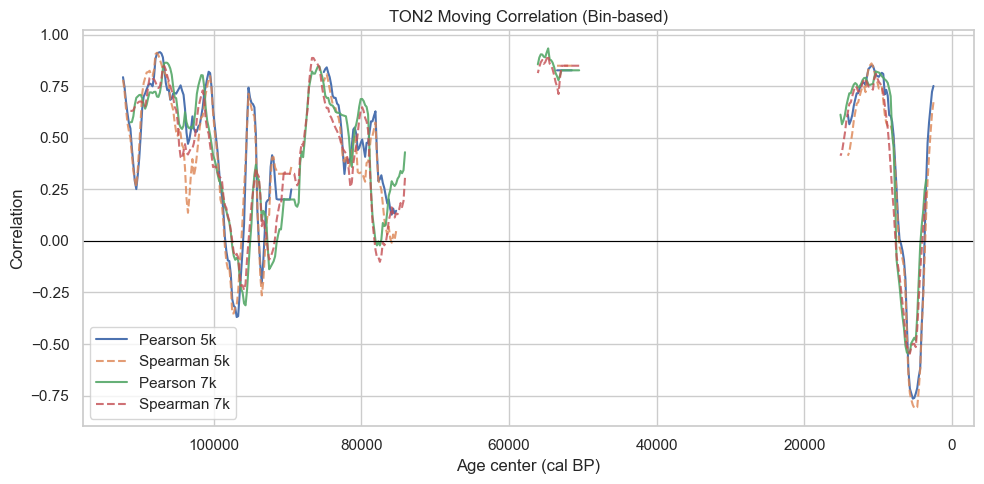

Saved: moving_corr_bins_5k.csv, moving_corr_bins_7k.csv, fig_moving_corr_bins_no_interp.png


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["d13CcarbVPDB","d18OcarbVPDB"]).copy()

# 1) 100-year bins, NO interpolation
bin_w = 100
df["age_bin"] = (df["age_calBP"] // bin_w) * bin_w
b = df.groupby("age_bin", as_index=False).agg(
    d13C=("d13CcarbVPDB","mean"),
    d18O=("d18OcarbVPDB","mean"),
    n_raw=("age_calBP","count")
).sort_values("age_bin")

# 2) moving correlation on bins
def moving_corr_bins(bdf, window_years=5000, step_years=200, min_n=30):
    centers = np.arange(
        bdf["age_bin"].min() + window_years//2,
        bdf["age_bin"].max() - window_years//2 + 1,
        step_years
    )
    out = []
    for c in centers:
        lo, hi = c - window_years/2, c + window_years/2
        w = bdf[(bdf["age_bin"] >= lo) & (bdf["age_bin"] <= hi)].copy()
        w = w.dropna(subset=["d13C","d18O"])
        if len(w) < min_n:
            out.append([c, len(w), np.nan, np.nan])
            continue
        if w["d13C"].std() == 0 or w["d18O"].std() == 0:
            out.append([c, len(w), np.nan, np.nan])
            continue
        pr = w["d13C"].corr(w["d18O"], method="pearson")
        sr = w["d13C"].corr(w["d18O"], method="spearman")
        out.append([c, len(w), pr, sr])
    return pd.DataFrame(out, columns=["age_center","n_bins","pearson_r","spearman_rho"])

mc5 = moving_corr_bins(b, window_years=5000, step_years=200, min_n=30)
mc7 = moving_corr_bins(b, window_years=7000, step_years=200, min_n=30)

mc5.to_csv("moving_corr_bins_5k.csv", index=False)
mc7.to_csv("moving_corr_bins_7k.csv", index=False)

# 3) plot
plt.figure(figsize=(10,5))
plt.plot(mc5["age_center"], mc5["pearson_r"], label="Pearson 5k")
plt.plot(mc5["age_center"], mc5["spearman_rho"], "--", label="Spearman 5k", alpha=0.8)
plt.plot(mc7["age_center"], mc7["pearson_r"], label="Pearson 7k", alpha=0.9)
plt.plot(mc7["age_center"], mc7["spearman_rho"], "--", label="Spearman 7k", alpha=0.8)
plt.axhline(0, color="black", lw=0.8)
plt.gca().invert_xaxis()
plt.xlabel("Age center (cal BP)")
plt.ylabel("Correlation")
plt.title("TON2 Moving Correlation (Bin-based)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_moving_corr_bins_no_interp.png", dpi=300)
plt.show()

print("Saved: moving_corr_bins_5k.csv, moving_corr_bins_7k.csv, fig_moving_corr_bins_no_interp.png")

In [1]:
import pandas as pd

# 1) Excelni o'qish
df = pd.read_excel("Бойсун МС.xlsx",sheet_name ='Ҳарорат')   # fayl nomini moslang
print(df.head())
print(df.columns)

   Unnamed: 0  Unnamed: 1  янв  фев  мар   апр   май   июн   июл   авг   сен  \
0         NaN        1933 -1.2  4.8  4.7  12.7  21.3  24.1  29.2  26.8  21.0   
1         NaN        1934 -5.4  5.8  7.5  11.8  13.6  23.9  28.1  26.2  18.4   
2         NaN        1935 -2.4  5.3  7.4  13.0  18.1  20.5  27.4  27.2  20.0   
3         NaN        1936 -0.4  4.3  3.9  12.2  20.6  26.2  27.2  24.8  21.9   
4         NaN        1937 -0.9  4.2  4.7  10.7  18.9  24.8  27.9  26.4  21.0   

    окт  ноя  дек   йил  
0  14.5  8.4  5.3  14.3  
1  12.8  6.2  4.5  12.8  
2  13.5  6.2  3.4  13.3  
3  16.8  8.3  1.2  13.9  
4  13.4  6.5  3.0  13.4  
Index(['Unnamed: 0', 'Unnamed: 1', 'янв', 'фев', 'мар', 'апр', 'май', 'июн',
       'июл', 'авг', 'сен', 'окт', 'ноя', 'дек', 'йил'],
      dtype='str')


In [2]:
rename_map = {
    df.columns[0]: "year",
    "янв":"jan","фев":"feb","мар":"mar","апр":"apr","май":"may","июн":"jun",
    "июл":"jul","авг":"aug","сен":"sep","окт":"oct","ноя":"nov","дек":"dec",
    "йил":"annual"
}
df = df.rename(columns=rename_map)

# faqat kerakli ustunlar
cols = ["year","jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec","annual"]
df = df[cols]

# son tipiga o'tkazish (vergul bo'lsa nuqtaga almashtirish)
for c in cols[1:]:
    df[c] = (df[c].astype(str).str.replace(",", ".", regex=False))
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

print(df.dtypes)
print(df.isna().sum())
df.head()

year        Int64
jan       float64
feb       float64
mar       float64
apr       float64
may       float64
jun       float64
jul       float64
aug       float64
sep       float64
oct       float64
nov       float64
dec       float64
annual    float64
dtype: object
year      94
jan        0
feb        0
mar        0
apr        0
may        1
jun        1
jul        1
aug        1
sep        1
oct        1
nov        1
dec        1
annual     1
dtype: int64


,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual
0,<NA>,-1.2,4.8,4.7,12.7,21.3,24.1,29.2,26.8,21.0,14.5,8.4,5.3,14.3
1,<NA>,-5.4,5.8,7.5,11.8,13.6,23.9,28.1,26.2,18.4,12.8,6.2,4.5,12.8
2,<NA>,-2.4,5.3,7.4,13.0,18.1,20.5,27.4,27.2,20.0,13.5,6.2,3.4,13.3
3,<NA>,-0.4,4.3,3.9,12.2,20.6,26.2,27.2,24.8,21.9,16.8,8.3,1.2,13.9
4,<NA>,-0.9,4.2,4.7,10.7,18.9,24.8,27.9,26.4,21.0,13.4,6.5,3.0,13.4


In [6]:
import pandas as pd

# 1) Excel yuklash
raw = pd.read_excel("Бойсун МС.xlsx",sheet_name ='Ҳарорат')  # fayl nomini moslang

# 2) Keraksiz bo'sh ustunlarni olib tashlash
# Sizda 'Unnamed: 0', 'Unnamed: 1' bor
df = raw.drop(columns=["Unnamed: 0"], errors="ignore").copy()

# 3) Ustunlarni rename qilish
df = df.rename(columns={
    "янв": "jan",
    "фев": "feb",
    "мар": "mar",
    "апр": "apr",
    "май": "may",
    "июн": "jun",
    "июл": "jul",
    "авг": "aug",
    "сен": "sep",
    "окт": "oct",
    "ноя": "nov",
    "дек": "dec",
    "йил": "annual"
})

# 4) Year ustunini topish:
# Ko'pincha Excel'da yil indexdan kelib birinchi ustunda qoladi.
# Agar birinchi ustun nomi hali Unnamed bo'lsa, uni year qilamiz.
first_col = df.columns[0]
if first_col.startswith("Unnamed"):
    df = df.rename(columns={first_col: "year"})
elif first_col not in ["year", "jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec", "annual"]:
    df = df.rename(columns={first_col: "year"})

# 5) Agar year ustuni hali yo'q bo'lsa, raw'dan birinchi ustunni olamiz
if "year" not in df.columns:
    df.insert(0, "year", raw.iloc[:, 0])

# 6) Faqat kerakli ustunlar
cols = ["year","jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec","annual"]
df = df[[c for c in cols if c in df.columns]].copy()

# 7) Matn -> son (vergulni nuqtaga aylantirish)
for c in df.columns:
    df[c] = df[c].astype(str).str.strip().str.replace(",", ".", regex=False)

# year alohida
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# qolganlari float
for c in [x for x in df.columns if x != "year"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 8) Tozalash
df = df.dropna(subset=["year"]).sort_values("year").reset_index(drop=True)

print("Shape:", df.shape)
print(df.dtypes)
print("\nMissing:\n", df.isna().sum())
print("\nHead:\n", df.head())
print("\nTail:\n", df.tail())

Shape: (94, 14)
year        Int64
jan       float64
feb       float64
mar       float64
apr       float64
may       float64
jun       float64
jul       float64
aug       float64
sep       float64
oct       float64
nov       float64
dec       float64
annual    float64
dtype: object

Missing:
 year      0
jan       0
feb       0
mar       0
apr       0
may       1
jun       1
jul       1
aug       1
sep       1
oct       1
nov       1
dec       1
annual    1
dtype: int64

Head:
    year  jan  feb  mar   apr   may   jun   jul   aug   sep   oct  nov  dec  \
0  1933 -1.2  4.8  4.7  12.7  21.3  24.1  29.2  26.8  21.0  14.5  8.4  5.3   
1  1934 -5.4  5.8  7.5  11.8  13.6  23.9  28.1  26.2  18.4  12.8  6.2  4.5   
2  1935 -2.4  5.3  7.4  13.0  18.1  20.5  27.4  27.2  20.0  13.5  6.2  3.4   
3  1936 -0.4  4.3  3.9  12.2  20.6  26.2  27.2  24.8  21.9  16.8  8.3  1.2   
4  1937 -0.9  4.2  4.7  10.7  18.9  24.8  27.9  26.4  21.0  13.4  6.5  3.0   

   annual  
0    14.3  
1    12.8  
2    13.3  
3

In [7]:
df = df.fillna(0)
df.head()
df.tail()

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual
89,2022,3.9,5.1,9.9,18.1,19.8,24.9,28.6,24.2,21.9,14.2,8.6,3.0,15.2
90,2023,-0.9,5.9,13.3,15.0,20.1,27.1,28.1,25.6,20.3,15.1,12.5,7.1,15.8
91,2024,7.0,4.0,8.0,13.7,18.7,24.9,27.1,26.4,20.2,15.4,10.1,2.7,14.9
92,2025,2.4,3.9,8.9,16.8,22.8,25.4,28.7,26.1,21.7,16.3,8.9,6.8,15.7
93,2026,3.1,9.3,10.3,14.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.head()

,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual
0,1933,-1.2,4.8,4.7,12.7,21.3,24.1,29.2,26.8,21.0,14.5,8.4,5.3,14.3
1,1934,-5.4,5.8,7.5,11.8,13.6,23.9,28.1,26.2,18.4,12.8,6.2,4.5,12.8
2,1935,-2.4,5.3,7.4,13.0,18.1,20.5,27.4,27.2,20.0,13.5,6.2,3.4,13.3
3,1936,-0.4,4.3,3.9,12.2,20.6,26.2,27.2,24.8,21.9,16.8,8.3,1.2,13.9
4,1937,-0.9,4.2,4.7,10.7,18.9,24.8,27.9,26.4,21.0,13.4,6.5,3.0,13.4


Overlap years: 1941 - 1941 | n = 1
   year  annual  d18OcarbVPDB  d13CcarbVPDB
0  1941    15.7         -5.55          1.48

Model A: annual ~ d18O
coef: [0.] intercept: 15.7
R2: nan RMSE: 0.0

Model B: annual ~ d13C
coef: [0.] intercept: 15.7
R2: nan RMSE: 0.0

Model C: annual ~ d18O + d13C
coef: [0. 0.] intercept: 15.7
R2: nan RMSE: 0.0


C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\ProgramData\anaconda3\envs\paleo_env\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\user\AppData\Local\Temp\ipykernel_11488\2853595691.py:78: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(m["d18OcarbVPDB"], m["annual"], 1)


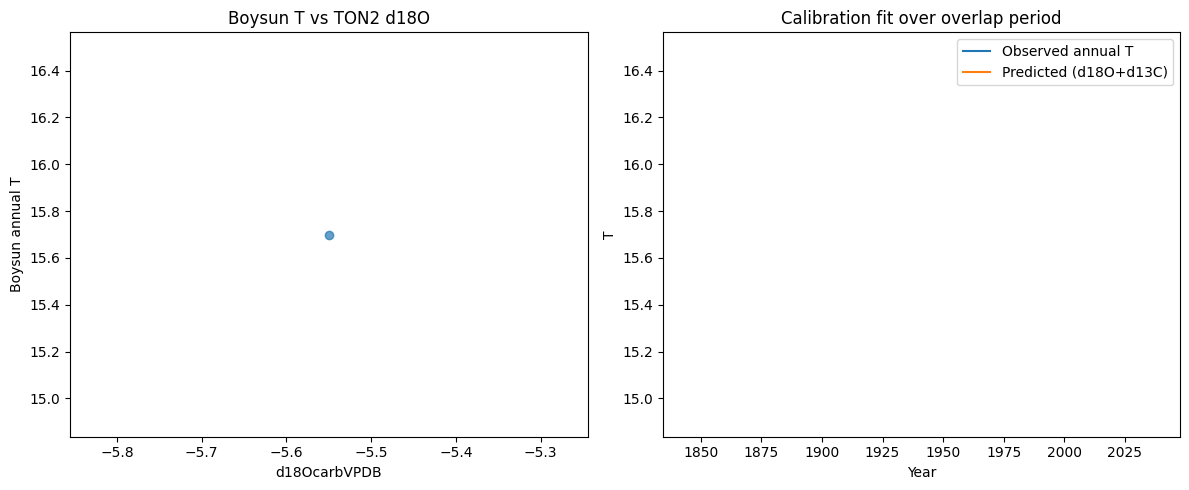

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# =========================
# 1) TON2 ni tayyorlash
# =========================
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2[ton2["age_calBP"] >= 0].copy()
ton2 = ton2.dropna(subset=["d18OcarbVPDB", "d13CcarbVPDB"])

# cal BP -> CE year (0 BP = 1950 CE)
ton2["year_ce"] = 1950 - ton2["age_calBP"]

# Instrumental davr uchun kesamiz
ton2_mod = ton2[(ton2["year_ce"] >= 1933) & (ton2["year_ce"] <= 2025)].copy()

# Yiliga agregatsiya (bir yilda bir nechta nuqta bo'lsa)
ton2_y = ton2_mod.groupby("year_ce", as_index=False).agg({
    "d18OcarbVPDB": "mean",
    "d13CcarbVPDB": "mean"
}).rename(columns={"year_ce": "year"})

# =========================
# 2) Boysun bilan merge
# =========================
# df sizda allaqachon tayyor: year, jan...dec, annual
b = df.copy()
b["year"] = pd.to_numeric(b["year"], errors="coerce")
b = b.dropna(subset=["year"])
b["year"] = b["year"].astype(int)

# annual harorat target
m = pd.merge(b[["year","annual"]], ton2_y, on="year", how="inner").dropna()

print("Overlap years:", m["year"].min(), "-", m["year"].max(), "| n =", len(m))
print(m.head())

# =========================
# 3) Oddiy kalibratsiya modellari
# =========================
def fit_report(X, y, name):
    lr = LinearRegression()
    lr.fit(X, y)
    pred = lr.predict(X)
    r2 = r2_score(y, pred)
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    print(f"\n{name}")
    print("coef:", lr.coef_, "intercept:", lr.intercept_)
    print("R2:", round(r2, 3), "RMSE:", round(rmse, 3))
    return lr, pred


y = m["annual"].values

# Model A: faqat d18O
Xa = m[["d18OcarbVPDB"]].values
model_a, pred_a = fit_report(Xa, y, "Model A: annual ~ d18O")

# Model B: faqat d13C
Xb = m[["d13CcarbVPDB"]].values
model_b, pred_b = fit_report(Xb, y, "Model B: annual ~ d13C")

# Model C: d18O + d13C
Xc = m[["d18OcarbVPDB","d13CcarbVPDB"]].values
model_c, pred_c = fit_report(Xc, y, "Model C: annual ~ d18O + d13C")

# =========================
# 4) Vizual tekshiruv
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Scatter annual vs d18O
axes[0].scatter(m["d18OcarbVPDB"], m["annual"], alpha=0.7)
z = np.polyfit(m["d18OcarbVPDB"], m["annual"], 1)
xx = np.linspace(m["d18OcarbVPDB"].min(), m["d18OcarbVPDB"].max(), 100)
axes[0].plot(xx, z[0]*xx + z[1], "r")
axes[0].set_xlabel("d18OcarbVPDB")
axes[0].set_ylabel("Boysun annual T")
axes[0].set_title("Boysun T vs TON2 d18O")

# Time series: observed vs best model (C)
axes[1].plot(m["year"], m["annual"], label="Observed annual T")
axes[1].plot(m["year"], pred_c, label="Predicted (d18O+d13C)")
axes[1].set_title("Calibration fit over overlap period")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("T")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

ton2 = pd.read_csv("TON2_iso_original.csv")

# d18O mavjud bo'lgan age oralig'i
d18 = ton2.dropna(subset=["d18OcarbVPDB"]).copy()
print("d18O age_calBP min/max:", d18["age_calBP"].min(), d18["age_calBP"].max())
print("d18O CE year min/max:", 1950 - d18["age_calBP"].max(), 1950 - d18["age_calBP"].min())

# d13C mavjud bo'lgan age oralig'i
d13 = ton2.dropna(subset=["d13CcarbVPDB"]).copy()
print("d13C age_calBP min/max:", d13["age_calBP"].min(), d13["age_calBP"].max())
print("d13C CE year min/max:", 1950 - d13["age_calBP"].max(), 1950 - d13["age_calBP"].min())

d18O age_calBP min/max: -58 114822
d18O CE year min/max: -112872 2008
d13C age_calBP min/max: -58 114822
d13C CE year min/max: -112872 2008


In [12]:
import pandas as pd
import numpy as np

ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["d18OcarbVPDB","d13CcarbVPDB"]).copy()
ton2["year_ce_float"] = 1950 - ton2["age_calBP"]

# Yilga aylantirishning 3 usuli
ton2["year_floor"] = np.floor(ton2["year_ce_float"]).astype(int)
ton2["year_round"] = np.round(ton2["year_ce_float"]).astype(int)
ton2["year_ceil"]  = np.ceil(ton2["year_ce_float"]).astype(int)

# Zamonaviy qismni ko'rish
modern = ton2[(ton2["year_ce_float"] >= 1900) & (ton2["year_ce_float"] <= 2025)].copy()
print("Modern points count:", len(modern))
print(modern[["age_calBP","year_ce_float","year_floor","year_round","year_ceil","d18OcarbVPDB","d13CcarbVPDB"]]
      .sort_values("year_ce_float")
      .tail(30))

# Har usulda nechta unik yil bor
for c in ["year_floor","year_round","year_ceil"]:
    x = modern[c].value_counts().sort_index()
    print(f"\n{c}: unique years={x.shape[0]}")
    print(x.tail(20))

Modern points count: 2
   age_calBP  year_ce_float  year_floor  year_round  year_ceil  d18OcarbVPDB  \
1          9           1941        1941        1941       1941         -5.55   
0        -58           2008        2008        2008       2008         -5.69   

   d13CcarbVPDB  
1          1.48  
0          1.27  

year_floor: unique years=2
year_floor
1941    1
2008    1
Name: count, dtype: int64

year_round: unique years=2
year_round
1941    1
2008    1
Name: count, dtype: int64

year_ceil: unique years=2
year_ceil
1941    1
2008    1
Name: count, dtype: int64


In [13]:
# Boysun df: year, annual
b = df[["year","annual"]].dropna().copy()
b["year"] = b["year"].astype(int)

ton2_y = ton2.copy()
ton2_y["year"] = ton2_y["year_round"]  # muhim
ton2_y = ton2_y.groupby("year", as_index=False)[["d18OcarbVPDB","d13CcarbVPDB"]].mean()

m = b.merge(ton2_y, on="year", how="inner").dropna()
print("Overlap n =", len(m), "| years:", m["year"].min(), "-", m["year"].max())
print(m.head(20))

Overlap n = 2 | years: 1941 - 2008
   year  annual  d18OcarbVPDB  d13CcarbVPDB
0  1941    15.7         -5.55          1.48
1  2008    13.4         -5.69          1.27


In [14]:
import pandas as pd

ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["d18OcarbVPDB", "d13CcarbVPDB"]).copy()
ton2["year_ce"] = 1950 - ton2["age_calBP"]

# 1933–2008 oralig'i
x = ton2[(ton2["year_ce"] >= 1933) & (ton2["year_ce"] <= 2008)].copy()
print("Rows in 1933-2008:", len(x))
print(x[["age_calBP","year_ce","d18OcarbVPDB","d13CcarbVPDB"]].sort_values("year_ce"))

# faqat age<=17 bo'lganlarni ko'rish (chunki 1950-17=1933)
y = ton2[ton2["age_calBP"] <= 17].copy()
print("\nRows with age_calBP <= 17:", len(y))
print(y[["age_calBP","year_ce","d18OcarbVPDB","d13CcarbVPDB"]].sort_values("age_calBP"))

# umumiy eng yosh 20 ta nuqta
print("\nYoungest 20 by age_calBP:")
print(ton2.sort_values("age_calBP").head(20)[["age_calBP","year_ce","d18OcarbVPDB","d13CcarbVPDB"]])

Rows in 1933-2008: 2
   age_calBP  year_ce  d18OcarbVPDB  d13CcarbVPDB
1          9     1941         -5.55          1.48
0        -58     2008         -5.69          1.27

Rows with age_calBP <= 17: 2
   age_calBP  year_ce  d18OcarbVPDB  d13CcarbVPDB
0        -58     2008         -5.69          1.27
1          9     1941         -5.55          1.48

Youngest 20 by age_calBP:
    age_calBP  year_ce  d18OcarbVPDB  d13CcarbVPDB
0         -58     2008         -5.69          1.27
1           9     1941         -5.55          1.48
2          76     1874         -5.50          1.51
3         144     1806         -5.21          2.33
4         211     1739         -5.54          1.87
5         278     1672         -5.44          2.37
6         345     1605         -5.52          2.13
7         412     1538         -5.77          2.16
8         480     1470         -5.52          1.77
9         547     1403         -5.70          1.84
10        614     1336         -5.70          1.62
11        

Saved: boysun_trend_table.csv
    series     period  slope_per_decade   p_value   r_value
0   annual       full          0.196128  0.557511  0.061260
1      DJF       full          0.104977  0.097350  0.172018
2      MAM       full          0.158509  0.004676  0.289343
3      JJA       full         -0.250900  0.018022 -0.243522
4      SON       full         -0.085285  0.222129 -0.127114
5   annual  1933-1960         -0.398194  0.045846 -0.380382
6   annual  1961-1990          0.081869  0.598659  0.100106
7   annual  1991-2026         -2.108108  0.357379 -0.158005
8      DJF  1933-1960          0.201058  0.504866  0.131469
9      DJF  1961-1990         -0.000890  0.998373 -0.000389
10     DJF  1991-2026          0.306006  0.210739  0.213712
11     MAM  1933-1960         -0.167761  0.624730 -0.096631
12     MAM  1961-1990         -0.008083  0.967042 -0.007878
13     MAM  1991-2026          0.586272  0.039146  0.345307
14     JJA  1933-1960         -0.921091  0.000230 -0.642176


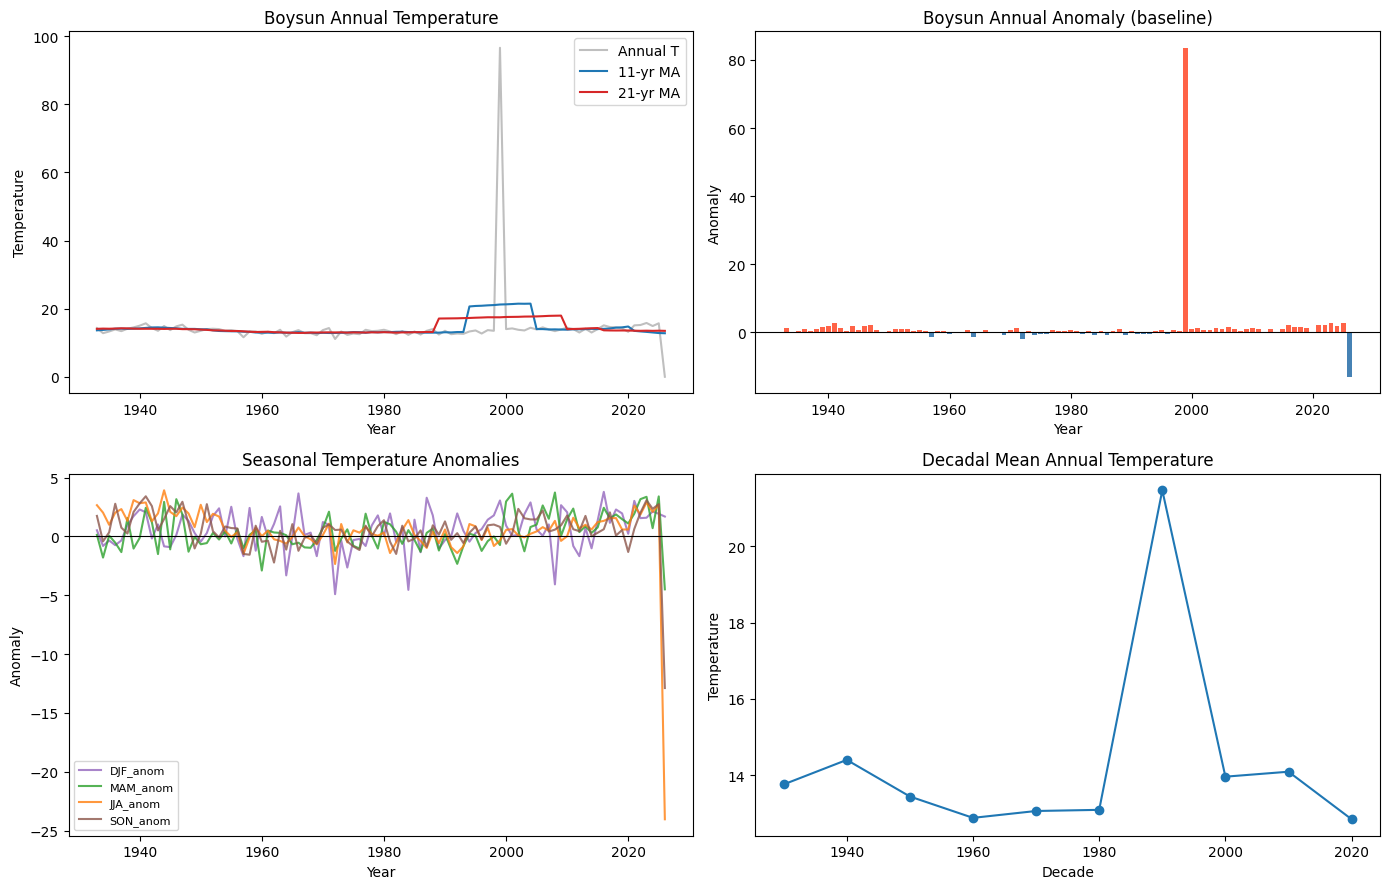

Saved: fig_boysun_context.png, boysun_context_timeseries.csv


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# Boysun modern-climate context analysis
# (for supporting paleo interpretation)
# ==========================================

# Sizda allaqachon tayyor df bor deb olamiz:
# columns: year, jan..dec, annual
# Agar df yo'q bo'lsa, avval Exceldan tayyorlab oling.

# --------------------------
# 1) Basic prep
# --------------------------
d = df.copy()

num_cols = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec","annual"]
for c in ["year"] + num_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")

d = d.dropna(subset=["year"]).sort_values("year")
d["year"] = d["year"].astype(int)

# --------------------------
# 2) Seasonal indices
# --------------------------
# DJF uchun oddiy yondashuv: (dec + jan + feb)/3 (calendar-year based)
d["DJF"] = d[["dec","jan","feb"]].mean(axis=1)
d["MAM"] = d[["mar","apr","may"]].mean(axis=1)
d["JJA"] = d[["jun","jul","aug"]].mean(axis=1)
d["SON"] = d[["sep","oct","nov"]].mean(axis=1)

# --------------------------
# 3) Baseline anomalies (1961-1990)
# --------------------------
base = d[(d["year"] >= 1961) & (d["year"] <= 1990)]
if len(base) < 10:
    # fallback baseline
    base = d[(d["year"] >= d["year"].min()) & (d["year"] <= d["year"].min()+29)]

for c in ["annual","DJF","MAM","JJA","SON"]:
    clim = base[c].mean()
    d[f"{c}_anom"] = d[c] - clim

# --------------------------
# 4) Trend function
# --------------------------
def trend_info(series_df, y_col):
    x = series_df["year"].values
    y = series_df[y_col].values
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 10:
        return np.nan, np.nan, np.nan
    lr = linregress(x, y)
    # per decade
    slope_dec = lr.slope * 10
    return slope_dec, lr.pvalue, lr.rvalue

# Full-period trends
trend_rows = []
for c in ["annual","DJF","MAM","JJA","SON"]:
    slope_dec, p, r = trend_info(d, c)
    trend_rows.append([c, "full", slope_dec, p, r])

# Sub-period trends (example)
periods = [(1933, 1960), (1961, 1990), (1991, d["year"].max())]
for c in ["annual","DJF","MAM","JJA","SON"]:
    for a,b in periods:
        s = d[(d["year"] >= a) & (d["year"] <= b)]
        slope_dec, p, r = trend_info(s, c)
        trend_rows.append([c, f"{a}-{b}", slope_dec, p, r])

trend_tbl = pd.DataFrame(trend_rows, columns=["series","period","slope_per_decade","p_value","r_value"])
trend_tbl.to_csv("boysun_trend_table.csv", index=False)

print("Saved: boysun_trend_table.csv")
print(trend_tbl.head(15))

# --------------------------
# 5) Regime shift (simple running means)
# --------------------------
d["annual_ma11"] = d["annual"].rolling(11, center=True, min_periods=6).mean()
d["annual_ma21"] = d["annual"].rolling(21, center=True, min_periods=11).mean()

# --------------------------
# 6) Plots
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# A) Annual + running means
axes[0,0].plot(d["year"], d["annual"], color="gray", alpha=0.5, label="Annual T")
axes[0,0].plot(d["year"], d["annual_ma11"], color="tab:blue", label="11-yr MA")
axes[0,0].plot(d["year"], d["annual_ma21"], color="tab:red", label="21-yr MA")
axes[0,0].set_title("Boysun Annual Temperature")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Temperature")
axes[0,0].legend()

# B) Annual anomaly
axes[0,1].axhline(0, color="black", lw=0.8)
axes[0,1].bar(d["year"], d["annual_anom"], width=0.8, color=np.where(d["annual_anom"]>=0, "tomato", "steelblue"))
axes[0,1].set_title("Boysun Annual Anomaly (baseline)")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Anomaly")

# C) Seasonal anomalies
for c, col in zip(["DJF_anom","MAM_anom","JJA_anom","SON_anom"],
                  ["tab:purple","tab:green","tab:orange","tab:brown"]):
    axes[1,0].plot(d["year"], d[c], label=c, color=col, alpha=0.8)
axes[1,0].axhline(0, color="black", lw=0.8)
axes[1,0].set_title("Seasonal Temperature Anomalies")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Anomaly")
axes[1,0].legend(fontsize=8)

# D) Decadal means
d["decade"] = (d["year"] // 10) * 10
dec = d.groupby("decade", as_index=False)["annual"].mean()
axes[1,1].plot(dec["decade"], dec["annual"], marker="o")
axes[1,1].set_title("Decadal Mean Annual Temperature")
axes[1,1].set_xlabel("Decade")
axes[1,1].set_ylabel("Temperature")

plt.tight_layout()
plt.savefig("fig_boysun_context.png", dpi=300)
plt.show()

# --------------------------
# 7) Export context table
# --------------------------
out_cols = [
    "year","annual","DJF","MAM","JJA","SON",
    "annual_anom","DJF_anom","MAM_anom","JJA_anom","SON_anom",
    "annual_ma11","annual_ma21"
]
d[out_cols].to_csv("boysun_context_timeseries.csv", index=False)
print("Saved: fig_boysun_context.png, boysun_context_timeseries.csv")

In [16]:
import numpy as np
import pandas as pd

d = df.copy()

# son format
for c in d.columns:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# 1) fizik diapazon filtri (harorat uchun mantiqiy chegaralar)
month_cols = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
for c in month_cols:
    d.loc[(d[c] < -45) | (d[c] > 50), c] = np.nan

# annual uchun ham
d.loc[(d["annual"] < -20) | (d["annual"] > 35), "annual"] = np.nan

# 2) annualni oyliklardan qayta hisoblash (eng to'g'ri)
d["annual_calc"] = d[month_cols].mean(axis=1)
d["annual_diff"] = d["annual"] - d["annual_calc"]

# agar annual juda farq qilsa, annualni qayta yozamiz
d.loc[d["annual_diff"].abs() > 1.0, "annual"] = d.loc[d["annual_diff"].abs() > 1.0, "annual_calc"]

# tekshiruv: eng katta farqlar
print(d[["year","annual","annual_calc","annual_diff"]].sort_values("annual_diff", key=lambda s: s.abs(), ascending=False).head(15))

# yangilangan df
df_clean = d.drop(columns=["annual_calc","annual_diff"]).copy()

    year  annual  annual_calc  annual_diff
93  2026     3.1     3.100000    -3.100000
91  2024    14.9    14.850000     0.050000
76  2009    13.9    13.850000     0.050000
44  1977    13.8    13.750000     0.050000
39  1972    11.1    11.050000     0.050000
82  2015    14.0    13.950000     0.050000
62  1995    13.6    13.550000     0.050000
45  1978    13.4    13.350000     0.050000
5   1938    14.1    14.058333     0.041667
59  1992    12.7    12.658333     0.041667
16  1949    13.0    13.041667    -0.041667
73  2006    14.5    14.458333     0.041667
63  1996    12.7    12.741667    -0.041667
58  1991    12.5    12.458333     0.041667
18  1951    14.0    13.958333     0.041667


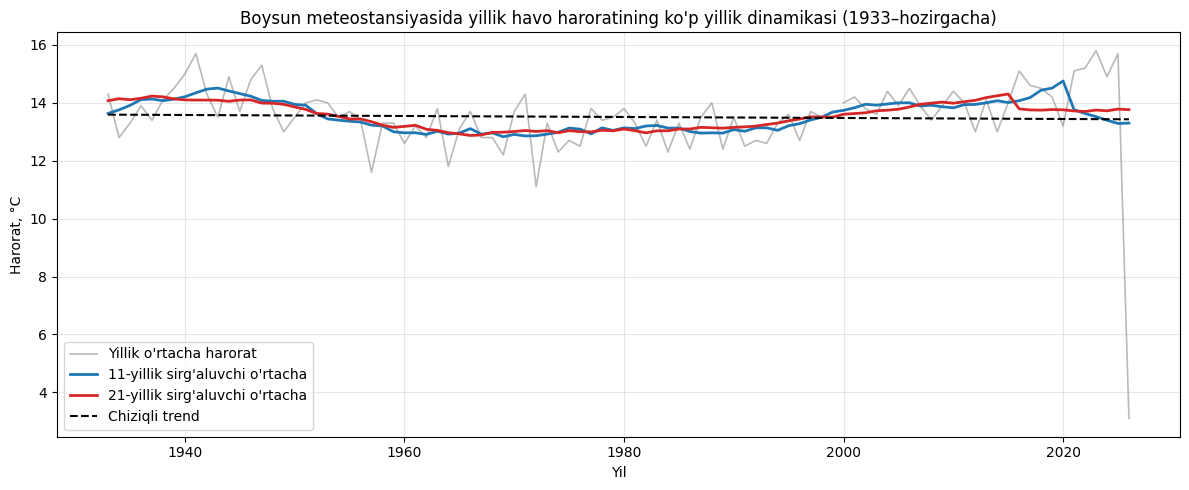

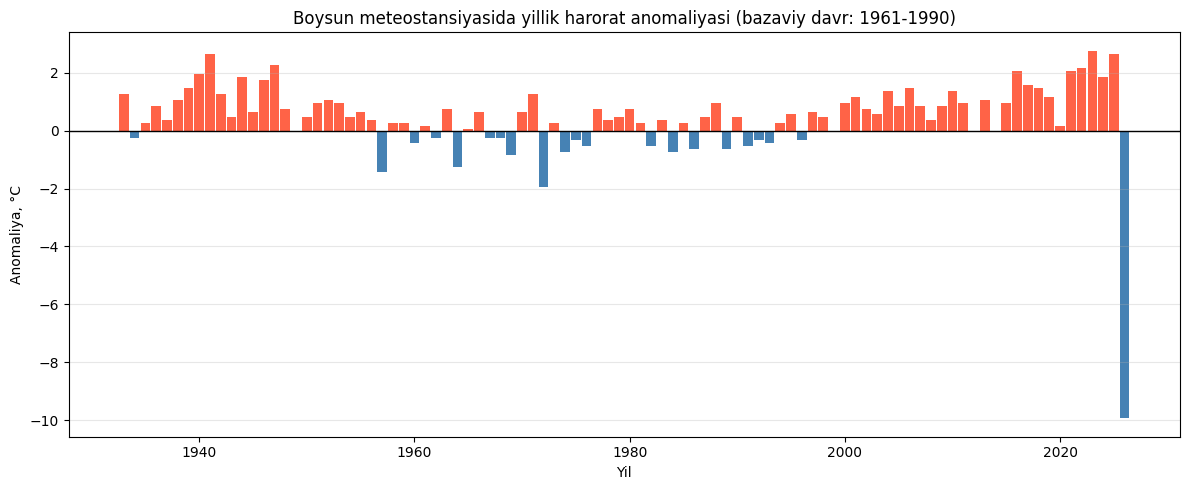

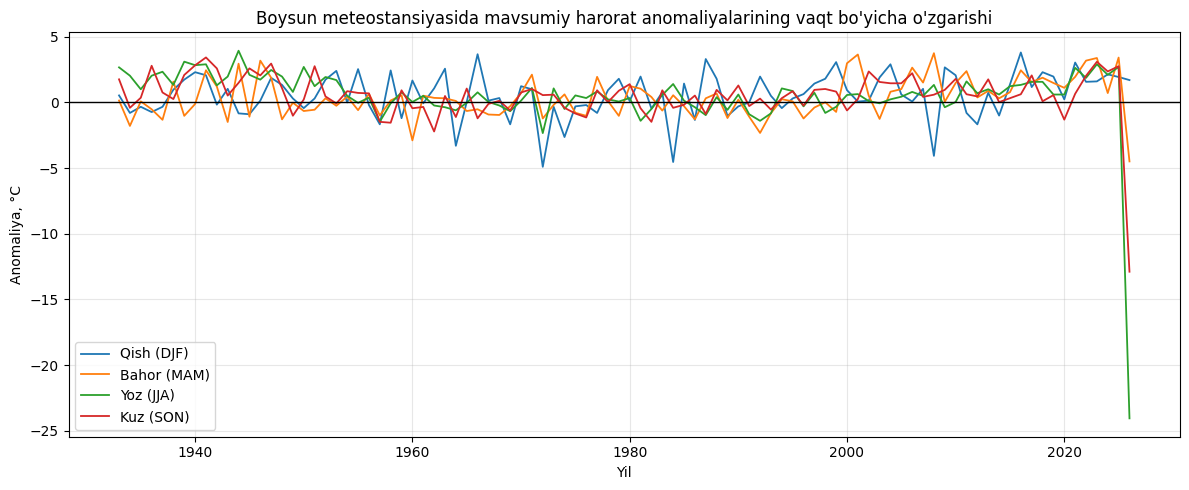

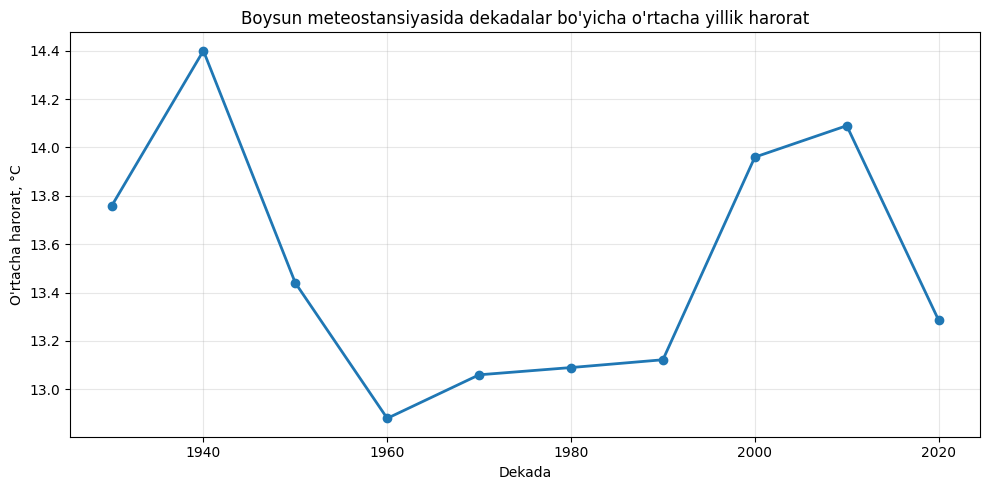


Yillik harorat trendi:
Qiyalik: -0.0017 °C/yil
Dekada bo'yicha: -0.017 °C/10 yil
p-qiymat: 0.7509, R: -0.033

Saqlangan fayl: boysun_harorat_tozalangan_va_indekslar.csv
Saqlangan rasmlar: 1-rasm ... 4-rasm


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =========================================================
# Boysun: tozalash + maqolabop (o'zbekcha) grafiklar
# =========================================================

# Sizda df tayyor (year, jan..dec, annual) deb olamiz
d = df.copy()

# 1) Son formatga o'tkazish
for c in d.columns:
    d[c] = pd.to_numeric(d[c], errors="coerce")

# 2) Diapazon bo'yicha tozalash (harorat uchun fizik chegaralar)
month_cols = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

for c in month_cols:
    d.loc[(d[c] < -45) | (d[c] > 50), c] = np.nan

d.loc[(d["annual"] < -20) | (d["annual"] > 35), "annual"] = np.nan

# 3) Annualni oyliklardan qayta hisoblash va tekislash
d["annual_calc"] = d[month_cols].mean(axis=1)
d["annual_diff"] = d["annual"] - d["annual_calc"]

# annual ancha farq qilsa (>|1|), annual_calc bilan almashtiramiz
mask_bad_annual = d["annual_diff"].abs() > 1.0
d.loc[mask_bad_annual, "annual"] = d.loc[mask_bad_annual, "annual_calc"]

# 4) Asosiy tayyorlash
d = d.dropna(subset=["year"]).sort_values("year").copy()
d["year"] = d["year"].astype(int)

# Mavsumiy indekslar
d["Qish_DJF"] = d[["dec","jan","feb"]].mean(axis=1)
d["Bahor_MAM"] = d[["mar","apr","may"]].mean(axis=1)
d["Yoz_JJA"] = d[["jun","jul","aug"]].mean(axis=1)
d["Kuz_SON"] = d[["sep","oct","nov"]].mean(axis=1)

# Bazaviy davr (WMO uslubiga yaqin): 1961–1990
base = d[(d["year"] >= 1961) & (d["year"] <= 1990)].copy()
if len(base) < 10:
    base = d.iloc[:min(30, len(d))].copy()

for c in ["annual","Qish_DJF","Bahor_MAM","Yoz_JJA","Kuz_SON"]:
    d[f"{c}_anom"] = d[c] - base[c].mean()

# Running mean
d["annual_ma11"] = d["annual"].rolling(11, center=True, min_periods=6).mean()
d["annual_ma21"] = d["annual"].rolling(21, center=True, min_periods=11).mean()

# Trend (yillik)
x = d["year"].values
y = d["annual"].values
m = np.isfinite(x) & np.isfinite(y)
lr = linregress(x[m], y[m])
trend_line = lr.intercept + lr.slope * x
trend_decade = lr.slope * 10

# Dekadal o'rtacha
d["decade"] = (d["year"] // 10) * 10
dec = d.groupby("decade", as_index=False)["annual"].mean()

# =========================================================
# 1-rasm: Yillik harorat dinamikasi
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(d["year"], d["annual"], color="gray", alpha=0.55, linewidth=1.2, label="Yillik o'rtacha harorat")
plt.plot(d["year"], d["annual_ma11"], color="tab:blue", linewidth=2.0, label="11-yillik sirg'aluvchi o'rtacha")
plt.plot(d["year"], d["annual_ma21"], color="tab:red", linewidth=2.0, label="21-yillik sirg'aluvchi o'rtacha")
plt.plot(d["year"], trend_line, color="black", linestyle="--", linewidth=1.5, label="Chiziqli trend")

plt.title("Boysun meteostansiyasida yillik havo haroratining ko'p yillik dinamikasi (1933–hozirgacha)")
plt.xlabel("Yil")
plt.ylabel("Harorat, °C")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("1-rasm_boysun_yillik_harorat_dinamikasi.png", dpi=300)
plt.show()

# =========================================================
# 2-rasm: Yillik anomaliya (bazaviy davrga nisbatan)
# =========================================================
plt.figure(figsize=(12, 5))
colors = np.where(d["annual_anom"] >= 0, "tomato", "steelblue")
plt.bar(d["year"], d["annual_anom"], color=colors, width=0.9)
plt.axhline(0, color="black", linewidth=1.0)

base_label = f"{int(base['year'].min())}-{int(base['year'].max())}"
plt.title(f"Boysun meteostansiyasida yillik harorat anomaliyasi (bazaviy davr: {base_label})")
plt.xlabel("Yil")
plt.ylabel("Anomaliya, °C")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("2-rasm_boysun_yillik_harorat_anomaliyasi.png", dpi=300)
plt.show()

# =========================================================
# 3-rasm: Mavsumiy anomaliyalar
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(d["year"], d["Qish_DJF_anom"], label="Qish (DJF)", linewidth=1.3)
plt.plot(d["year"], d["Bahor_MAM_anom"], label="Bahor (MAM)", linewidth=1.3)
plt.plot(d["year"], d["Yoz_JJA_anom"], label="Yoz (JJA)", linewidth=1.3)
plt.plot(d["year"], d["Kuz_SON_anom"], label="Kuz (SON)", linewidth=1.3)
plt.axhline(0, color="black", linewidth=1.0)

plt.title("Boysun meteostansiyasida mavsumiy harorat anomaliyalarining vaqt bo'yicha o'zgarishi")
plt.xlabel("Yil")
plt.ylabel("Anomaliya, °C")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("3-rasm_boysun_mavsumiy_harorat_anomaliyalari.png", dpi=300)
plt.show()

# =========================================================
# 4-rasm: Dekadal o'rtachalar
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(dec["decade"], dec["annual"], marker="o", linewidth=2)
plt.title("Boysun meteostansiyasida dekadalar bo'yicha o'rtacha yillik harorat")
plt.xlabel("Dekada")
plt.ylabel("O'rtacha harorat, °C")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("4-rasm_boysun_dekadal_o'rtacha_harorat.png", dpi=300)
plt.show()

# =========================================================
# Trend natijasi va eksport
# =========================================================
print("\nYillik harorat trendi:")
print(f"Qiyalik: {lr.slope:.4f} °C/yil")
print(f"Dekada bo'yicha: {trend_decade:.3f} °C/10 yil")
print(f"p-qiymat: {lr.pvalue:.4g}, R: {lr.rvalue:.3f}")

# Tozalangan jadvalni saqlash
save_cols = [
    "year","jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec",
    "annual","Qish_DJF","Bahor_MAM","Yoz_JJA","Kuz_SON",
    "annual_anom","Qish_DJF_anom","Bahor_MAM_anom","Yoz_JJA_anom","Kuz_SON_anom",
    "annual_ma11","annual_ma21"
]
d[save_cols].to_csv("boysun_harorat_tozalangan_va_indekslar.csv", index=False)
print("\nSaqlangan fayl: boysun_harorat_tozalangan_va_indekslar.csv")
print("Saqlangan rasmlar: 1-rasm ... 4-rasm")

In [18]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu

# =========================================================
# TON2 period significance:
# Kruskal + Pairwise Mann-Whitney + FDR + Effect size
# =========================================================

# 1) Load
df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].copy()

# 2) Period bins
bins = [0, 11700, 26000, 50000, df["age_calBP"].max()]
labels = ["Holocene", "11.7-26 ka", "26-50 ka", ">50 ka"]
df["period"] = pd.cut(df["age_calBP"], bins=bins, labels=labels, include_lowest=True)

# 3) Helper functions
def cliffs_delta(x, y):
    """
    Cliff's delta in [-1,1]:
    >0 => x tends to be larger than y
    <0 => x tends to be smaller than y
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n_x = len(x)
    n_y = len(y)
    if n_x == 0 or n_y == 0:
        return np.nan

    # efficient pairwise comparison via broadcasting (can be heavy for very large arrays)
    # here still okay for TON2 period sizes
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return (gt - lt) / (n_x * n_y)

def cliffs_magnitude(delta):
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"

def benjamini_hochberg(pvals):
    """
    Returns q-values (FDR-adjusted p-values)
    """
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    # map back
    q_back = np.empty(n, dtype=float)
    q_back[order] = np.minimum(q, 1.0)
    return q_back

def run_tests(var_name):
    x = df[["period", var_name]].dropna().copy()

    # group arrays in period order
    groups = []
    group_names = []
    for p in labels:
        vals = x.loc[x["period"] == p, var_name].dropna().values
        if len(vals) > 0:
            groups.append(vals)
            group_names.append(p)

    # ---- Global Kruskal-Wallis ----
    if len(groups) >= 2:
        H, p_kw = kruskal(*groups)
    else:
        H, p_kw = np.nan, np.nan

    global_res = pd.DataFrame([{
        "variable": var_name,
        "test": "Kruskal-Wallis",
        "H_stat": H,
        "p_value": p_kw,
        "n_groups": len(groups)
    }])

    # ---- Pairwise Mann-Whitney ----
    pairs = []
    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            a_name, b_name = group_names[i], group_names[j]
            a = x.loc[x["period"] == a_name, var_name].dropna().values
            b = x.loc[x["period"] == b_name, var_name].dropna().values

            # two-sided non-parametric
            U, p = mannwhitneyu(a, b, alternative="two-sided")
            delta = cliffs_delta(a, b)
            mag = cliffs_magnitude(delta)

            pairs.append({
                "variable": var_name,
                "period_A": a_name,
                "period_B": b_name,
                "n_A": len(a),
                "n_B": len(b),
                "U_stat": U,
                "p_value": p,
                "cliffs_delta": delta,
                "effect_size": mag,
                "median_A": np.median(a),
                "median_B": np.median(b),
                "median_diff_A_minus_B": np.median(a) - np.median(b)
            })

    pair_df = pd.DataFrame(pairs)

    # FDR adjust (within variable)
    if len(pair_df) > 0:
        pair_df["q_value_fdr_bh"] = benjamini_hochberg(pair_df["p_value"].values)
        pair_df["significant_q<0.05"] = pair_df["q_value_fdr_bh"] < 0.05

    return global_res, pair_df

# 4) Run for d18O and d13C
global_d18, pair_d18 = run_tests("d18OcarbVPDB")
global_d13, pair_d13 = run_tests("d13CcarbVPDB")

global_all = pd.concat([global_d18, global_d13], ignore_index=True)
pair_all = pd.concat([pair_d18, pair_d13], ignore_index=True)

# 5) Save
global_all.to_csv("ton2_global_kruskal_results.csv", index=False)
pair_all.to_csv("ton2_pairwise_mannwhitney_fdr_cliffs.csv", index=False)

# 6) Print key outputs
print("\n=== GLOBAL TESTS (Kruskal-Wallis) ===")
print(global_all)

print("\n=== PAIRWISE (first rows) ===")
print(pair_all.head(12))

print("\nSaved files:")
print(" - ton2_global_kruskal_results.csv")
print(" - ton2_pairwise_mannwhitney_fdr_cliffs.csv")


=== GLOBAL TESTS (Kruskal-Wallis) ===
       variable            test       H_stat        p_value  n_groups
0  d18OcarbVPDB  Kruskal-Wallis   374.367802   7.885142e-81         4
1  d13CcarbVPDB  Kruskal-Wallis  1141.415441  3.765547e-247         4

=== PAIRWISE (first rows) ===
        variable    period_A    period_B  n_A   n_B    U_stat        p_value  \
0   d18OcarbVPDB    Holocene  11.7-26 ka  333   128   12000.5   3.632176e-13   
1   d18OcarbVPDB    Holocene    26-50 ka  333   215    1611.5   1.402226e-79   
2   d18OcarbVPDB    Holocene      >50 ka  333  1790  166697.5   1.949399e-37   
3   d18OcarbVPDB  11.7-26 ka    26-50 ka  128   215     391.5   3.393271e-51   
4   d18OcarbVPDB  11.7-26 ka      >50 ka  128  1790   94095.0   7.226507e-04   
5   d18OcarbVPDB    26-50 ka      >50 ka  215  1790  285007.0   8.041859e-31   
6   d13CcarbVPDB    Holocene  11.7-26 ka  333   128    7718.5   2.634253e-26   
7   d13CcarbVPDB    Holocene    26-50 ka  333   215    1597.5   1.208945e-79   


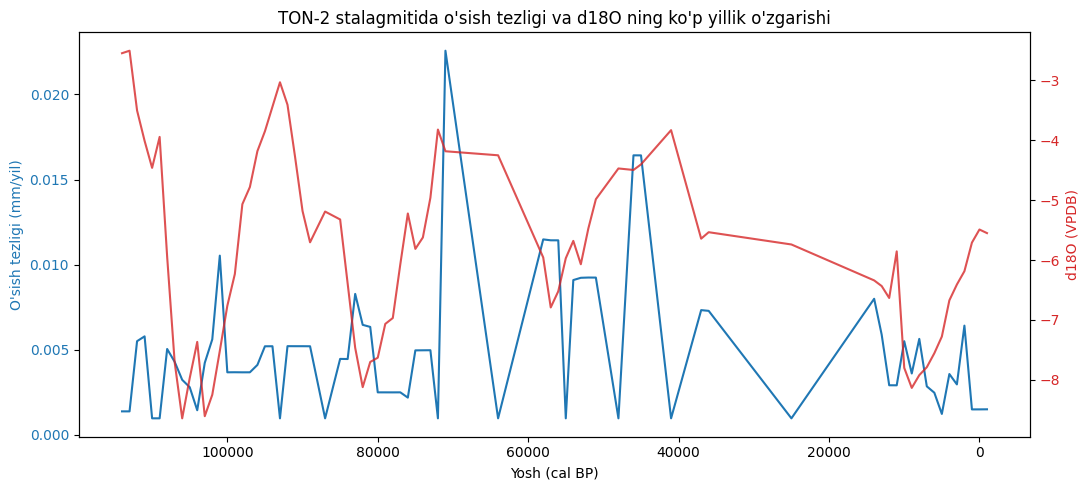

Binlar soni: 74
Pearson r (growth vs d18O): -0.003728956600825728
Spearman rho (growth vs d18O): -0.12990133338730184


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) TON2 yuklash
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["depth_mm", "age_calBP", "d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

# 2) Growth rate (mm/year): depth differ / age differ
ton2["d_depth"] = ton2["depth_mm"].diff()
ton2["d_age"] = ton2["age_calBP"].diff()

# manfiy/0 intervalni tashlab yuboramiz
ton2["growth_mm_per_yr"] = np.where(ton2["d_age"] > 0, ton2["d_depth"] / ton2["d_age"], np.nan)

# 3) Markaziy yosh (interval markazi)
ton2["age_mid"] = (ton2["age_calBP"] + ton2["age_calBP"].shift(1)) / 2

# 4) Outlierni yumshatish (1-99% kesish)
q1, q99 = ton2["growth_mm_per_yr"].quantile([0.01, 0.99])
ton2["growth_clip"] = ton2["growth_mm_per_yr"].clip(q1, q99)

# 5) 1000 yillik bin o'rtacha
bin_w = 1000
ton2["age_bin"] = (ton2["age_mid"] // bin_w) * bin_w
g = ton2.groupby("age_bin", as_index=False).agg(
    growth_mean=("growth_clip", "mean"),
    d18O_mean=("d18OcarbVPDB", "mean"),
    n=("growth_clip", "count")
)

# 6) Grafik
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(g["age_bin"], g["growth_mean"], color="tab:blue", label="O'sish tezligi (mm/yil)")
ax1.set_xlabel("Yosh (cal BP)")
ax1.set_ylabel("O'sish tezligi (mm/yil)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.plot(g["age_bin"], g["d18O_mean"], color="tab:red", alpha=0.8, label="d18O (VPDB)")
ax2.set_ylabel("d18O (VPDB)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("TON-2 stalagmitida o'sish tezligi va d18O ning ko'p yillik o'zgarishi")
fig.tight_layout()
plt.show()

# 7) Korrelyatsiya (bin asosida)
m = g.dropna(subset=["growth_mean", "d18O_mean"])
print("Binlar soni:", len(m))
print("Pearson r (growth vs d18O):", m["growth_mean"].corr(m["d18O_mean"], method="pearson"))
print("Spearman rho (growth vs d18O):", m["growth_mean"].corr(m["d18O_mean"], method="spearman"))

Best period (years): 23737.9
Best power: 0.6273
Precession band (19-23k): mean power = 0.3599 max = 0.5804
Obliquity-like band (38-46k): mean power = 0.0093 max = 0.0276


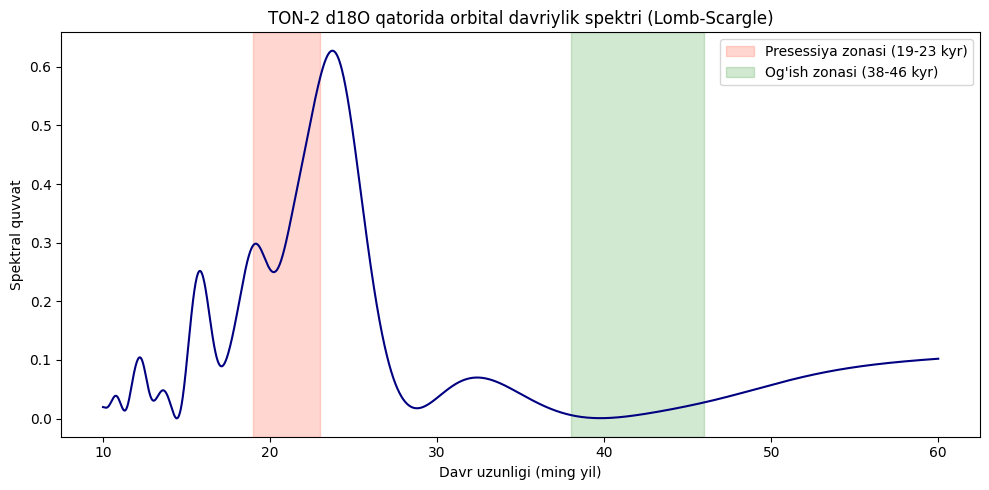

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lombscargle

# 1) TON2 d18O
ton2 = pd.read_csv("TON2_iso_original.csv")
x = ton2.dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
x = x[x["age_calBP"] >= 0].sort_values("age_calBP")

t = x["age_calBP"].values.astype(float)      # year BP
y = x["d18OcarbVPDB"].values.astype(float)
y = y - np.mean(y)

# 2) Precession band uchun period grid
# period: 10k .. 60k years
periods = np.linspace(10000, 60000, 3000)
freq = 2*np.pi / periods  # lombscargle angular freq

pwr = lombscargle(t, y, freq, precenter=False, normalize=True)

# 3) Eng kuchli period
i_max = np.argmax(pwr)
best_period = periods[i_max]
best_power = pwr[i_max]

print("Best period (years):", round(best_period, 1))
print("Best power:", round(float(best_power), 4))

# 4) Precession zonalarida quvvat
def band_power(pmin, pmax):
    m = (periods >= pmin) & (periods <= pmax)
    if m.sum() == 0:
        return np.nan, np.nan
    return float(np.nanmean(pwr[m])), float(np.nanmax(pwr[m]))


mean_19_23, max_19_23 = band_power(19000, 23000)
mean_38_46, max_38_46 = band_power(38000, 46000)
mean_90_120, max_90_120 = band_power(90000, 120000)  # faqat reference, period griddan tashqarida bo'lishi mumkin

print("Precession band (19-23k): mean power =", round(mean_19_23,4), "max =", round(max_19_23,4))
print("Obliquity-like band (38-46k): mean power =", round(mean_38_46,4), "max =", round(max_38_46,4))

# 5) Plot
plt.figure(figsize=(10,5))
plt.plot(periods/1000, pwr, color="navy")
plt.axvspan(19, 23, color="tomato", alpha=0.25, label="Presessiya zonasi (19-23 kyr)")
plt.axvspan(38, 46, color="green", alpha=0.18, label="Og'ish zonasi (38-46 kyr)")
plt.xlabel("Davr uzunligi (ming yil)")
plt.ylabel("Spektral quvvat")
plt.title("TON-2 d18O qatorida orbital davriylik spektri (Lomb-Scargle)")
plt.legend()
plt.tight_layout()
plt.show()

=== d18O ===
Best period (years): 23737.9
Best power: 0.6273
Precession (19-23k): mean = 0.3599 max = 0.5804
Obliquity (38-46k): mean = 0.0093 max = 0.0276

=== d13C ===
Best period (years): 60000.0
Best power: 0.2451
Precession (19-23k): mean = 0.0428 max = 0.0913
Obliquity (38-46k): mean = 0.0389 max = 0.0884

Precession/Obliquity max-power ratio:
d18O ratio: 21.02
d13C ratio: 1.03


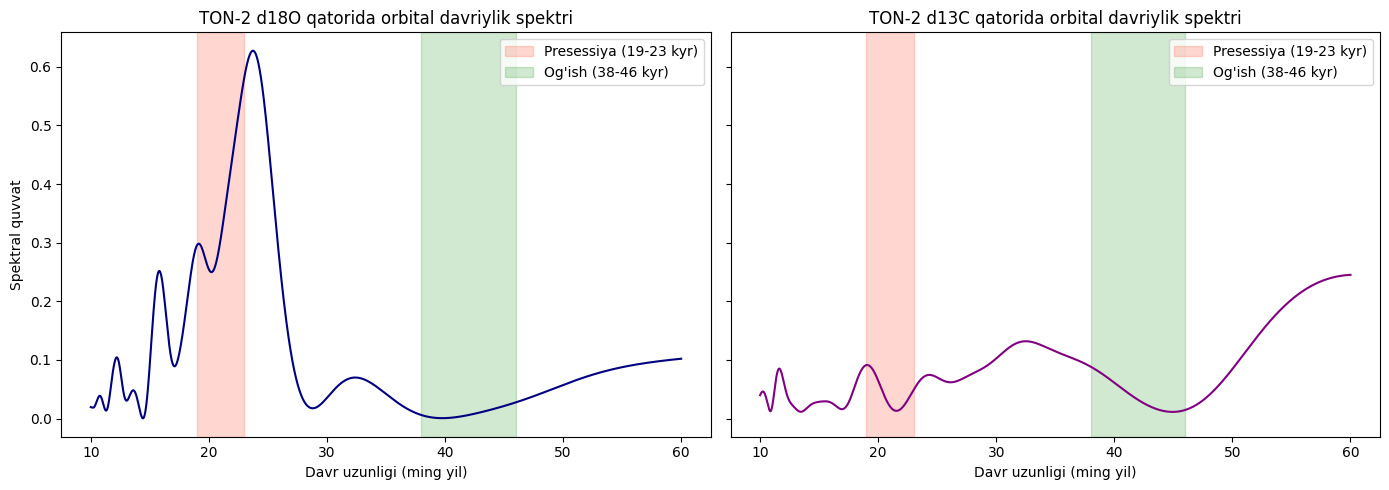


Saved:
 - fig_ton2_d18o_d13c_orbital_spectra.png
 - ton2_orbital_spectral_summary.csv


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lombscargle

# =========================
# 1) Load TON2
# =========================
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2[ton2["age_calBP"] >= 0].copy()

# Common period grid (10k..60k)
periods = np.linspace(10000, 60000, 3000)
freq = 2*np.pi / periods  # angular frequency for lombscargle

def lomb_power(age, val, periods, freq):
    x = np.asarray(age, dtype=float)
    y = np.asarray(val, dtype=float)
    y = y - np.mean(y)
    p = lombscargle(x, y, freq, precenter=False, normalize=True)
    return p

def band_stats(periods, power, pmin, pmax):
    m = (periods >= pmin) & (periods <= pmax)
    if m.sum() == 0:
        return np.nan, np.nan
    return float(np.nanmean(power[m])), float(np.nanmax(power[m]))

# =========================
# 2) d18O spectrum
# =========================
d18 = ton2.dropna(subset=["age_calBP","d18OcarbVPDB"]).sort_values("age_calBP")
p18 = lomb_power(d18["age_calBP"], d18["d18OcarbVPDB"], periods, freq)

best18_i = np.argmax(p18)
best18_period = periods[best18_i]
best18_power = p18[best18_i]
d18_prec_mean, d18_prec_max = band_stats(periods, p18, 19000, 23000)
d18_obl_mean, d18_obl_max = band_stats(periods, p18, 38000, 46000)

# =========================
# 3) d13C spectrum
# =========================
d13 = ton2.dropna(subset=["age_calBP","d13CcarbVPDB"]).sort_values("age_calBP")
p13 = lomb_power(d13["age_calBP"], d13["d13CcarbVPDB"], periods, freq)

best13_i = np.argmax(p13)
best13_period = periods[best13_i]
best13_power = p13[best13_i]
d13_prec_mean, d13_prec_max = band_stats(periods, p13, 19000, 23000)
d13_obl_mean, d13_obl_max = band_stats(periods, p13, 38000, 46000)

# =========================
# 4) Print summary
# =========================
print("=== d18O ===")
print("Best period (years):", round(best18_period, 1))
print("Best power:", round(float(best18_power), 4))
print("Precession (19-23k): mean =", round(d18_prec_mean,4), "max =", round(d18_prec_max,4))
print("Obliquity (38-46k): mean =", round(d18_obl_mean,4), "max =", round(d18_obl_max,4))

print("\n=== d13C ===")
print("Best period (years):", round(best13_period, 1))
print("Best power:", round(float(best13_power), 4))
print("Precession (19-23k): mean =", round(d13_prec_mean,4), "max =", round(d13_prec_max,4))
print("Obliquity (38-46k): mean =", round(d13_obl_mean,4), "max =", round(d13_obl_max,4))

# Simple ratios (precession dominance)
ratio18 = d18_prec_max / d18_obl_max if (d18_obl_max and not np.isnan(d18_obl_max)) else np.nan
ratio13 = d13_prec_max / d13_obl_max if (d13_obl_max and not np.isnan(d13_obl_max)) else np.nan
print("\nPrecession/Obliquity max-power ratio:")
print("d18O ratio:", round(ratio18, 2))
print("d13C ratio:", round(ratio13, 2))

# =========================
# 5) Plot side-by-side
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# d18O
axes[0].plot(periods/1000, p18, color="navy")
axes[0].axvspan(19, 23, color="tomato", alpha=0.25, label="Presessiya (19-23 kyr)")
axes[0].axvspan(38, 46, color="green", alpha=0.18, label="Og'ish (38-46 kyr)")
axes[0].set_title("TON-2 d18O qatorida orbital davriylik spektri")
axes[0].set_xlabel("Davr uzunligi (ming yil)")
axes[0].set_ylabel("Spektral quvvat")
axes[0].legend()

# d13C
axes[1].plot(periods/1000, p13, color="purple")
axes[1].axvspan(19, 23, color="tomato", alpha=0.25, label="Presessiya (19-23 kyr)")
axes[1].axvspan(38, 46, color="green", alpha=0.18, label="Og'ish (38-46 kyr)")
axes[1].set_title("TON-2 d13C qatorida orbital davriylik spektri")
axes[1].set_xlabel("Davr uzunligi (ming yil)")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ton2_d18o_d13c_orbital_spectra.png", dpi=300)
plt.show()

# =========================
# 6) Save compact result table
# =========================
res = pd.DataFrame([
    ["d18O", best18_period, best18_power, d18_prec_mean, d18_prec_max, d18_obl_mean, d18_obl_max, ratio18],
    ["d13C", best13_period, best13_power, d13_prec_mean, d13_prec_max, d13_obl_mean, d13_obl_max, ratio13]
], columns=[
    "proxy","best_period_yr","best_power",
    "precession_mean_power","precession_max_power",
    "obliquity_mean_power","obliquity_max_power",
    "precession_to_obliquity_ratio"
])

res.to_csv("ton2_orbital_spectral_summary.csv", index=False)
print("\nSaved:")
print(" - fig_ton2_d18o_d13c_orbital_spectra.png")
print(" - ton2_orbital_spectral_summary.csv")

Total bins: 121

Regime counts:
regime
Normal               46
Past_d18O_rejim      40
Yuqori_d18O_rejim    35
Name: count, dtype: int64

Long episodes (>=2000y):
                label   start     end  duration_yr
0              Normal       0    4000         4500
2              Normal   11000   14500         4000
7              Normal   51500   54000         3000
13             Normal   74000   75500         2000
22             Normal   98500  100000         2000
1     Past_d18O_rejim    4500   10500         6500
16    Past_d18O_rejim   78500   83500         5500
23    Past_d18O_rejim  100500  107500         7500
20  Yuqori_d18O_rejim   90500   92000         2000
21  Yuqori_d18O_rejim   94000   98000         4500
25  Yuqori_d18O_rejim  108500  114500         6500


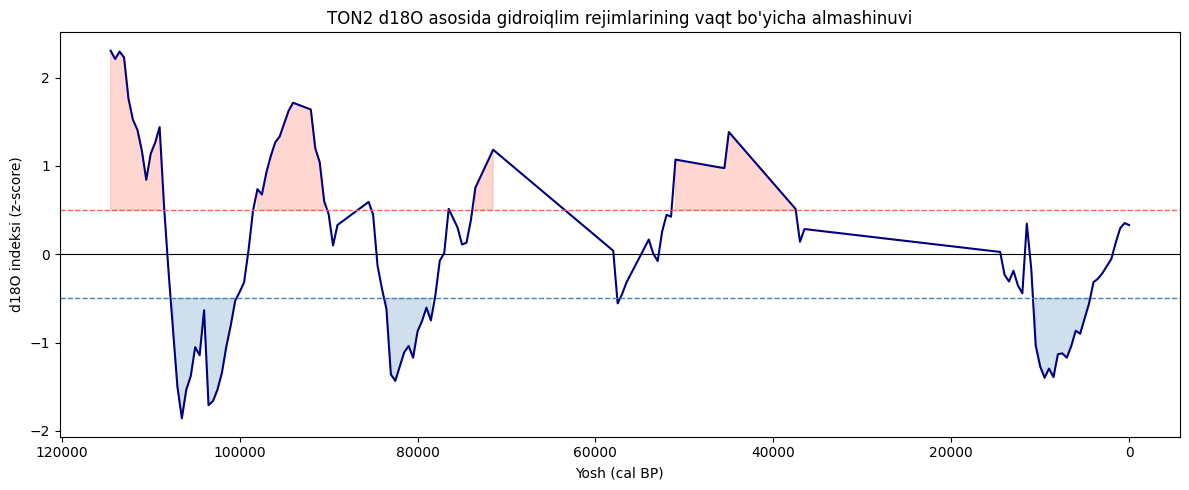


Saved:
 - fig_ton2_d18o_regimes.png
 - ton2_d18o_regime_bins.csv
 - ton2_d18o_regime_episodes_all.csv
 - ton2_d18o_regime_episodes_long.csv


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load
df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
df = df.sort_values("age_calBP")

# 2) 500-yillik bin (siz 200/1000 ham sinab ko'rishingiz mumkin)
bin_w = 500
df["age_bin"] = (df["age_calBP"] // bin_w) * bin_w

b = df.groupby("age_bin", as_index=False).agg(
    d18O_mean=("d18OcarbVPDB","mean"),
    n=("d18OcarbVPDB","count")
)

# 3) Standardized index (z-score)
mu = b["d18O_mean"].mean()
sd = b["d18O_mean"].std()
b["d18O_z"] = (b["d18O_mean"] - mu) / sd

# 4) Regime labels
# Eslatma: d18O talqini regionga bog'liq; hozir neytral nom beramiz
b["regime"] = "Normal"
b.loc[b["d18O_z"] >= 0.5, "regime"] = "Yuqori_d18O_rejim"
b.loc[b["d18O_z"] <= -0.5, "regime"] = "Past_d18O_rejim"

# 5) Uzluksiz interval (episode)larni topish
episodes = []
curr = None

for _, r in b.iterrows():
    lab = r["regime"]
    age = r["age_bin"]
    if curr is None:
        curr = {"label": lab, "start": age, "end": age}
    elif lab == curr["label"] and age == curr["end"] + bin_w:
        curr["end"] = age
    else:
        episodes.append(curr)
        curr = {"label": lab, "start": age, "end": age}
if curr is not None:
    episodes.append(curr)

ep = pd.DataFrame(episodes)
ep["duration_yr"] = ep["end"] - ep["start"] + bin_w

# faqat 2000 yildan uzun epizodlar
ep_long = ep[ep["duration_yr"] >= 2000].copy()

print("Total bins:", len(b))
print("\nRegime counts:")
print(b["regime"].value_counts())

print("\nLong episodes (>=2000y):")
print(ep_long.sort_values(["label","start"]).head(30))

# 6) Plot
plt.figure(figsize=(12,5))
plt.plot(b["age_bin"], b["d18O_z"], color="navy", lw=1.5)
plt.axhline(0.5, color="tomato", ls="--", lw=1)
plt.axhline(-0.5, color="steelblue", ls="--", lw=1)
plt.axhline(0, color="black", lw=0.8)

plt.fill_between(b["age_bin"], b["d18O_z"], 0.5, where=(b["d18O_z"]>=0.5), color="tomato", alpha=0.25)
plt.fill_between(b["age_bin"], b["d18O_z"], -0.5, where=(b["d18O_z"]<=-0.5), color="steelblue", alpha=0.25)

plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("d18O indeksi (z-score)")
plt.title("TON2 d18O asosida gidroiqlim rejimlarining vaqt bo'yicha almashinuvi")
plt.tight_layout()
plt.savefig("fig_ton2_d18o_regimes.png", dpi=300)
plt.show()

# 7) Save
b.to_csv("ton2_d18o_regime_bins.csv", index=False)
ep.to_csv("ton2_d18o_regime_episodes_all.csv", index=False)
ep_long.to_csv("ton2_d18o_regime_episodes_long.csv", index=False)
print("\nSaved:")
print(" - fig_ton2_d18o_regimes.png")
print(" - ton2_d18o_regime_bins.csv")
print(" - ton2_d18o_regime_episodes_all.csv")
print(" - ton2_d18o_regime_episodes_long.csv")

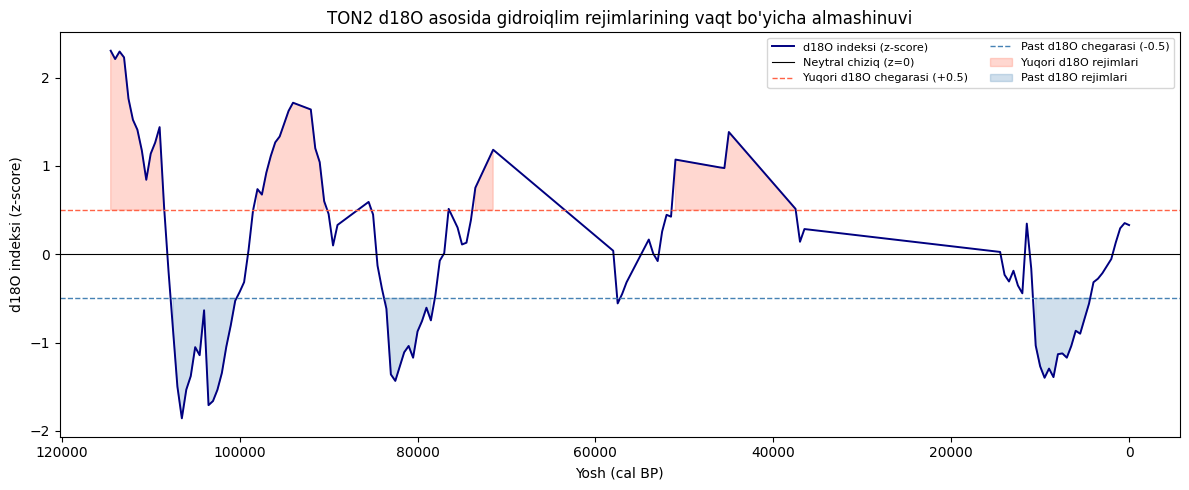

Saved:
 - fig_ton2_d18o_regimes_with_legend.png
 - ton2_regime_episodes_all.csv
 - ton2_regime_episodes_long_final.csv
 - jadval_ton2_regime_shift_chronology.csv

Preview:
    boshlanish_yoshi_calBP  tugash_yoshi_calBP  davomiylik_yil  \
0                        0                4000            4500   
1                     4500               10500            6500   
2                    11000               14500            4000   
3                    51500               54000            3000   
4                    74000               75500            2000   
5                    78500               83500            5500   
6                    90500               92000            2000   
7                    94000               98000            4500   
8                    98500              100000            2000   
9                   100500              107500            7500   
10                  108500              114500            6500   

       dominant_rejim        davr  

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# TON2 d18O regime plot (with legend) + final chronology
# =========================================================

# 1) Load
df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
df = df.sort_values("age_calBP")

# 2) Bin series
bin_w = 500
df["age_bin"] = (df["age_calBP"] // bin_w) * bin_w
b = df.groupby("age_bin", as_index=False).agg(
    d18O_mean=("d18OcarbVPDB","mean"),
    n=("d18OcarbVPDB","count")
)

# 3) z-index and regimes
mu, sd = b["d18O_mean"].mean(), b["d18O_mean"].std()
b["d18O_z"] = (b["d18O_mean"] - mu) / sd

low_thr, high_thr = -0.5, 0.5
b["regime"] = "Normal"
b.loc[b["d18O_z"] <= low_thr, "regime"] = "Past_d18O_rejim"
b.loc[b["d18O_z"] >= high_thr, "regime"] = "Yuqori_d18O_rejim"

# 4) Episodes
episodes = []
cur = None
for _, r in b.iterrows():
    lab, age = r["regime"], int(r["age_bin"])
    if cur is None:
        cur = {"label": lab, "start": age, "end": age}
    elif lab == cur["label"] and age == cur["end"] + bin_w:
        cur["end"] = age
    else:
        episodes.append(cur)
        cur = {"label": lab, "start": age, "end": age}
if cur is not None:
    episodes.append(cur)

ep = pd.DataFrame(episodes)
ep["duration_yr"] = ep["end"] - ep["start"] + bin_w

# 5) Add period labels
def period_label(age):
    if age <= 11700:
        return "Holocene"
    elif age <= 26000:
        return "11.7-26 ka"
    elif age <= 50000:
        return "26-50 ka"
    else:
        return ">50 ka"

ep["age_mid"] = (ep["start"] + ep["end"]) / 2
ep["period"] = ep["age_mid"].apply(period_label)

# 6) d18O median per episode
meds = []
for _, r in ep.iterrows():
    w = b[(b["age_bin"] >= r["start"]) & (b["age_bin"] <= r["end"])]
    meds.append(w["d18O_mean"].median())
ep["d18O_median"] = meds

# 7) Long episodes only
ep_long = ep[ep["duration_yr"] >= 2000].copy()
ep_long = ep_long.sort_values("start").reset_index(drop=True)

# 8) Plot WITH legend
plt.figure(figsize=(12,5))

# main line
plt.plot(b["age_bin"], b["d18O_z"], color="navy", lw=1.4, label="d18O indeksi (z-score)")

# thresholds
plt.axhline(0, color="black", lw=0.8, label="Neytral chiziq (z=0)")
plt.axhline(high_thr, color="tomato", ls="--", lw=1.0, label="Yuqori d18O chegarasi (+0.5)")
plt.axhline(low_thr, color="steelblue", ls="--", lw=1.0, label="Past d18O chegarasi (-0.5)")

# shaded regimes
plt.fill_between(
    b["age_bin"], b["d18O_z"], high_thr,
    where=(b["d18O_z"] >= high_thr),
    color="tomato", alpha=0.25, label="Yuqori d18O rejimlari"
)
plt.fill_between(
    b["age_bin"], b["d18O_z"], low_thr,
    where=(b["d18O_z"] <= low_thr),
    color="steelblue", alpha=0.25, label="Past d18O rejimlari"
)

plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("d18O indeksi (z-score)")
plt.title("TON2 d18O asosida gidroiqlim rejimlarining vaqt bo'yicha almashinuvi")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("fig_ton2_d18o_regimes_with_legend.png", dpi=300)
plt.show()

# 9) Save tables
ep.to_csv("ton2_regime_episodes_all.csv", index=False)
ep_long.to_csv("ton2_regime_episodes_long_final.csv", index=False)

# Publication-ready compact table
final_cols = ["start","end","duration_yr","label","period","d18O_median"]
final_tbl = ep_long[final_cols].rename(columns={
    "start":"boshlanish_yoshi_calBP",
    "end":"tugash_yoshi_calBP",
    "duration_yr":"davomiylik_yil",
    "label":"dominant_rejim",
    "period":"davr",
    "d18O_median":"d18O_median_VPDB"
})
final_tbl.to_csv("jadval_ton2_regime_shift_hronology.csv", index=False)

print("Saved:")
print(" - fig_ton2_d18o_regimes_with_legend.png")
print(" - ton2_regime_episodes_all.csv")
print(" - ton2_regime_episodes_long_final.csv")
print(" - jadval_ton2_regime_shift_chronology.csv")
print("\nPreview:")
print(final_tbl.head(20))

In [1]:
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd

# ── 1. ERA5 Yuklab Olish ─────────────────────────────────────────
# Tonnelnaya g'ori atrofi: 35–42°N, 63–72°E
# Davr: 1940–2020 (TON-2 bilan overlap)

c = cdsapi.Client()

# Yog'ingarchilik
c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': [
            'total_precipitation',
            '2m_temperature',
        ],
        'year': [str(y) for y in range(1940, 2024)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'area': [42, 63, 35, 72],  # N, W, S, E
        'format': 'netcdf',
    },
    'era5_tonnelnaya_region.nc'
)
print("✅ ERA5 yuklandi: era5_tonnelnaya_region.nc")

# ── 2. NetCDF ni o'qish ──────────────────────────────────────────
ds = xr.open_dataset('era5_tonnelnaya_region.nc')
print("\n📋 ERA5 dataset:")
print(ds)

# ── 3. Tonnelnaya g'or koordinatalari ───────────────────────────
# G'or: 38.4°N, 67.23°E
cave_lat = 38.4
cave_lon = 67.23

# G'or nuqtasidagi qiymatlar
tp_cave = ds['tp'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
)
t2m_cave = ds['t2m'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
)

# ── 4. Yillik aggregatsiya ───────────────────────────────────────
# Yog'in: yillik yig'indi (mm)
tp_annual = tp_cave.resample(time='1Y').sum() * 1000  # m → mm
# Harorat: yillik o'rtacha (°C)
t2m_annual = t2m_cave.resample(time='1Y').mean() - 273.15  # K → °C

# DataFrame ga aylantirish
df_era5 = pd.DataFrame({
    'year': tp_annual.time.dt.year.values,
    'precip_mm': tp_annual.values,
    'temp_c': t2m_annual.values
})

print("\n📊 ERA5 g'or nuqtasi (yillik):")
print(df_era5.head(10))
print(f"\n   Yog'in o'rtacha: {df_era5['precip_mm'].mean():.1f} mm/yil")
print(f"   Harorat o'rtacha: {df_era5['temp_c'].mean():.1f} °C")

df_era5.to_csv('era5_cave_point.csv', index=False)
print("\n✅ Saqlandi: era5_cave_point.csv")

# ── 5. Regional grid (spatial korrelyatsiya uchun) ───────────────
# Har bir grid nuqtasi uchun yillik yog'in
tp_regional = ds['tp'].resample(time='1Y').sum() * 1000
tp_regional_annual = tp_regional.mean(dim='time')

print("\n📊 Regional grid:")
print(f"   Lat: {ds.latitude.values.min():.1f} → {ds.latitude.values.max():.1f}")
print(f"   Lon: {ds.longitude.values.min():.1f} → {ds.longitude.values.max():.1f}")
print(f"   Grid nuqtalari: {len(ds.latitude) * len(ds.longitude)}")

ds_annual = xr.Dataset({
    'precip': tp_regional,
    'temp': (ds['t2m'] - 273.15).resample(time='1Y').mean()
})
ds_annual.to_netcdf('era5_regional_annual.nc')
print("✅ Saqlandi: era5_regional_annual.nc")

2026-05-27 15:22:28,029 INFO Request ID is aee6d2b6-d85f-4541-9e2e-00de44c06c45
2026-05-27 15:22:28,912 INFO status has been updated to accepted
2026-05-27 15:22:45,854 INFO status has been updated to running
2026-05-27 15:25:27,821 INFO status has been updated to successful
                                                                                                                                                                       

✅ ERA5 yuklandi: era5_tonnelnaya_region.nc


ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [3]:
 #Terminal yoki Anaconda Prompt da:
!pip install netcdf4 h5netcdf scipy

  Using cached h5netcdf-1.8.1-py3-none-any.whl.metadata (15 kB)
Using cached h5netcdf-1.8.1-py3-none-any.whl (62 kB)


In [4]:
import xarray as xr
import pandas as pd
import numpy as np

# ── NetCDF ni o'qish (engine qo'shildi) ─────────────────────────
ds = xr.open_dataset('era5_tonnelnaya_region.nc', engine='netcdf4')
print("✅ ERA5 yuklandi!")
print(ds)

# ── G'or koordinatalari ──────────────────────────────────────────
cave_lat = 38.4
cave_lon = 67.23

# G'or nuqtasidagi qiymatlar
tp_cave = ds['tp'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
)
t2m_cave = ds['t2m'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
)

# ── Yillik aggregatsiya ──────────────────────────────────────────
tp_annual  = tp_cave.resample(time='1YE').sum() * 1000   # mm
t2m_annual = t2m_cave.resample(time='1YE').mean() - 273.15  # °C

df_era5 = pd.DataFrame({
    'year'      : tp_annual.time.dt.year.values,
    'precip_mm' : tp_annual.values,
    'temp_c'    : t2m_annual.values
})

print("\n📊 ERA5 g'or nuqtasi (yillik):")
print(df_era5.head(10))
print(f"\n   Yog'in o'rtacha : {df_era5['precip_mm'].mean():.1f} mm/yil")
print(f"   Harorat o'rtacha: {df_era5['temp_c'].mean():.1f} °C")

df_era5.to_csv('era5_cave_point.csv', index=False)
print("\n✅ Saqlandi: era5_cave_point.csv")

# ── Regional grid saqlash ────────────────────────────────────────
ds_annual = xr.Dataset({
    'precip': ds['tp'].resample(time='1YE').sum() * 1000,
    'temp'  : (ds['t2m'] - 273.15).resample(time='1YE').mean()
})
ds_annual.to_netcdf('era5_regional_annual.nc')
print("✅ Saqlandi: era5_regional_annual.nc")

OSError: [Errno -51] NetCDF: Unknown file format: 'C:\\Users\\user\\paleo\\era5_tonnelnaya_region.nc'

In [5]:
import os

# Fayl hajmini tekshirish
fsize = os.path.getsize('era5_tonnelnaya_region.nc')
print(f"Fayl hajmi: {fsize / 1024 / 1024:.1f} MB")

# Fayl boshini tekshirish
with open('era5_tonnelnaya_region.nc', 'rb') as f:
    header = f.read(4)
    print(f"Fayl header (hex): {header.hex()}")
    print(f"Fayl header (raw): {header}")

Fayl hajmi: 3.6 MB
Fayl header (hex): 504b0304
Fayl header (raw): b'PK\x03\x04'


In [6]:
import zipfile
import os

zip_path = 'era5_tonnelnaya_region.nc'

# ZIP tarkibini ko'rish
with zipfile.ZipFile(zip_path, 'r') as z:
    print("📦 ZIP tarkibi:")
    for name in z.namelist():
        info = z.getinfo(name)
        print(f"   {name} — {info.file_size / 1024 / 1024:.1f} MB")
    
    # Barcha fayllarni chiqarish
    z.extractall('era5_extracted')
    print("\n✅ Fayllar chiqarildi: era5_extracted/ papkasiga")

# Chiqarilgan fayllarni ko'rish
print("\n📂 era5_extracted/ ichida:")
for f in os.listdir('era5_extracted'):
    fsize = os.path.getsize(f'era5_extracted/{f}')
    print(f"   {f} — {fsize / 1024 / 1024:.1f} MB")

📦 ZIP tarkibi:
   data_stream-moda_stepType-avgua.nc — 1.9 MB
   data_stream-moda_stepType-avgad.nc — 1.7 MB

✅ Fayllar chiqarildi: era5_extracted/ papkasiga

📂 era5_extracted/ ichida:
   data_stream-moda_stepType-avgad.nc — 1.7 MB
   data_stream-moda_stepType-avgua.nc — 1.9 MB


In [7]:
import xarray as xr

# Ikki faylni tekshirish
files = [
    'era5_extracted/data_stream-moda_stepType-avgua.nc',
    'era5_extracted/data_stream-moda_stepType-avgad.nc'
]

for f in files:
    print(f"\n{'='*55}")
    print(f"📂 {f.split('/')[-1]}")
    print('='*55)
    try:
        ds = xr.open_dataset(f, engine='netcdf4')
        print(f"✅ O'qildi!")
        print(f"   O'zgaruvchilar: {list(ds.data_vars)}")
        print(f"   Koordinatalar : {list(ds.coords)}")
        print(f"   Vaqt diapazoni: {ds.time.values[0]} → {ds.time.values[-1]}")
        print(f"   Lat: {float(ds.latitude.min()):.2f} → {float(ds.latitude.max()):.2f}")
        print(f"   Lon: {float(ds.longitude.min()):.2f} → {float(ds.longitude.max()):.2f}")
        print(ds)
    except Exception as e:
        print(f"❌ Xato: {e}")


📂 data_stream-moda_stepType-avgua.nc
✅ O'qildi!
   O'zgaruvchilar: ['t2m']
   Koordinatalar : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
❌ Xato: 'Dataset' object has no attribute 'time'

📂 data_stream-moda_stepType-avgad.nc
✅ O'qildi!
   O'zgaruvchilar: ['tp']
   Koordinatalar : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
❌ Xato: 'Dataset' object has no attribute 'time'


In [8]:
import xarray as xr
import pandas as pd
import numpy as np

# ── 1. Fayllarni yuklash ─────────────────────────────────────────
ds_t2m = xr.open_dataset('era5_extracted/data_stream-moda_stepType-avgua.nc', 
                          engine='netcdf4')
ds_tp  = xr.open_dataset('era5_extracted/data_stream-moda_stepType-avgad.nc',  
                          engine='netcdf4')

print("✅ Fayllar yuklandi!")
print(f"\nt2m vaqt diapazoni: {ds_t2m.valid_time.values[0]} → {ds_t2m.valid_time.values[-1]}")
print(f"tp  vaqt diapazoni: {ds_tp.valid_time.values[0]}  → {ds_tp.valid_time.values[-1]}")
print(f"\nt2m o'lchamlari: {ds_t2m.dims}")
print(f"tp  o'lchamlari: {ds_tp.dims}")

# ── 2. G'or koordinatalari ───────────────────────────────────────
cave_lat = 38.4
cave_lon = 67.23

# G'or nuqtasini ajratish
t2m_cave = ds_t2m['t2m'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
).squeeze()

tp_cave = ds_tp['tp'].sel(
    latitude=cave_lat,
    longitude=cave_lon,
    method='nearest'
).squeeze()

print(f"\n✅ G'or nuqtasi ajratildi")
print(f"   t2m nuqtalar: {len(t2m_cave.valid_time)}")
print(f"   tp  nuqtalar: {len(tp_cave.valid_time)}")

# ── 3. Yillik aggregatsiya ───────────────────────────────────────
# valid_time ga rename qilib resample qilamiz
t2m_ts = t2m_cave.assign_coords(valid_time=pd.to_datetime(t2m_cave.valid_time.values))
tp_ts  = tp_cave.assign_coords(valid_time=pd.to_datetime(tp_cave.valid_time.values))

t2m_annual = (t2m_ts.resample(valid_time='1YE').mean() - 273.15)
tp_annual  = (tp_ts.resample(valid_time='1YE').sum() * 1000)  # m → mm

# ── 4. DataFrame ─────────────────────────────────────────────────
df_era5 = pd.DataFrame({
    'year'      : t2m_annual.valid_time.dt.year.values,
    'temp_c'    : t2m_annual.values,
    'precip_mm' : tp_annual.values
})

print("\n📊 ERA5 g'or nuqtasi (yillik):")
print(df_era5.head(10))
print(f"\n   Yog'in o'rtacha : {df_era5['precip_mm'].mean():.1f} mm/yil")
print(f"   Harorat o'rtacha: {df_era5['temp_c'].mean():.1f} °C")
print(f"   Davr: {df_era5['year'].min()} → {df_era5['year'].max()}")

# ── 5. Saqlash ───────────────────────────────────────────────────
df_era5.to_csv('era5_cave_point.csv', index=False)
print("\n✅ Saqlandi: era5_cave_point.csv")

# ── 6. Regional grid (spatial korrelyatsiya uchun) ───────────────
ds_regional = xr.Dataset({
    'temp'  : (ds_t2m['t2m'] - 273.15).assign_coords(
                valid_time=pd.to_datetime(ds_t2m.valid_time.values)
              ).resample(valid_time='1YE').mean(),
    'precip': (ds_tp['tp'] * 1000).assign_coords(
                valid_time=pd.to_datetime(ds_tp.valid_time.values)
              ).resample(valid_time='1YE').sum()
})

ds_regional.to_netcdf('era5_regional_annual.nc')
print("✅ Saqlandi: era5_regional_annual.nc")

✅ Fayllar yuklandi!

t2m vaqt diapazoni: 1940-01-01T00:00:00.000000000 → 2023-12-01T00:00:00.000000000
tp  vaqt diapazoni: 1940-01-01T06:00:00.000000000  → 2023-12-01T06:00:00.000000000

t2m o'lchamlari: FrozenMappingWarningOnValuesAccess({'valid_time': 1008, 'latitude': 29, 'longitude': 37})
tp  o'lchamlari: FrozenMappingWarningOnValuesAccess({'valid_time': 1008, 'latitude': 29, 'longitude': 37})

✅ G'or nuqtasi ajratildi
   t2m nuqtalar: 1008
   tp  nuqtalar: 1008

📊 ERA5 g'or nuqtasi (yillik):
   year    temp_c  precip_mm
0  1940  5.405151  19.920349
1  1941  7.420166  18.610001
2  1942  6.936401  24.246216
3  1943  5.359436  30.851364
4  1944  6.355621  22.637367
5  1945  5.061249  29.040337
6  1946  6.752441  17.582893
7  1947  6.764832  18.285751
8  1948  5.526703  24.480820
9  1949  4.287842  33.247948

   Yog'in o'rtacha : 29.3 mm/yil
   Harorat o'rtacha: 5.6 °C
   Davr: 1940 → 2023

✅ Saqlandi: era5_cave_point.csv
✅ Saqlandi: era5_regional_annual.nc


In [9]:
import xarray as xr
import pandas as pd
import numpy as np

# ── Fayllarni qayta yuklash ──────────────────────────────────────
ds_t2m = xr.open_dataset('era5_extracted/data_stream-moda_stepType-avgua.nc',
                          engine='netcdf4')
ds_tp  = xr.open_dataset('era5_extracted/data_stream-moda_stepType-avgad.nc',
                          engine='netcdf4')

# ── Vaqt koordinatasini tekshirish ──────────────────────────────
print("tp o'zgaruvchi atributlari:")
print(ds_tp['tp'].attrs)
print(f"\ntp min qiymati: {float(ds_tp['tp'].min()):.6f}")
print(f"tp max qiymati: {float(ds_tp['tp'].max()):.6f}")
print(f"tp o'rtacha   : {float(ds_tp['tp'].mean()):.6f}")

print("\nt2m atributlari:")
print(ds_t2m['t2m'].attrs)
print(f"\nt2m min: {float(ds_t2m['t2m'].min()) - 273.15:.1f} °C")
print(f"t2m max: {float(ds_t2m['t2m'].max()) - 273.15:.1f} °C")

# ── G'or koordinatasi ────────────────────────────────────────────
cave_lat = 38.4
cave_lon = 67.23

# Eng yaqin grid nuqtasini topish
t2m_cave = ds_t2m['t2m'].sel(
    latitude=cave_lat, longitude=cave_lon, method='nearest').squeeze()
tp_cave = ds_tp['tp'].sel(
    latitude=cave_lat, longitude=cave_lon, method='nearest').squeeze()

# Haqiqiy grid koordinatalarini ko'rish
actual_lat = float(ds_t2m.latitude.sel(latitude=cave_lat, method='nearest'))
actual_lon = float(ds_t2m.longitude.sel(longitude=cave_lon, method='nearest'))
print(f"\n📍 So'ralgan: {cave_lat}°N, {cave_lon}°E")
print(f"📍 Haqiqiy grid: {actual_lat}°N, {actual_lon}°E")

# ── Oylik ma'lumotlarni ko'rish ──────────────────────────────────
t2m_vals = t2m_cave.values - 273.15
tp_vals  = tp_cave.values
times    = pd.to_datetime(t2m_cave.valid_time.values)

df_monthly = pd.DataFrame({
    'date'    : times,
    'year'    : times.year,
    'month'   : times.month,
    'temp_c'  : t2m_vals,
    'tp_raw'  : tp_vals
})

print("\n📊 Oylik ma'lumotlar (dastlabki 12 oy):")
print(df_monthly.head(12).to_string())

# ── tp birligini aniqlash ────────────────────────────────────────
# ERA5 monthly averaged: tp = m (oylik o'rtacha kunlik)
# Oylik yig'indi = tp * kunlar_soni * 1000 (mm ga)
import calendar

df_monthly['days_in_month'] = df_monthly.apply(
    lambda r: calendar.monthrange(r['year'], r['month'])[1], axis=1)

# Variant 1: oylik o'rtacha kunlik → oylik yig'indi
df_monthly['precip_mm_v1'] = df_monthly['tp_raw'] * df_monthly['days_in_month'] * 1000

# Variant 2: shunchaki *1000 (agar allaqachon oylik bo'lsa)
df_monthly['precip_mm_v2'] = df_monthly['tp_raw'] * 1000

print("\n📊 Yog'in hisoblash variantlari:")
print(df_monthly[['date','tp_raw','precip_mm_v1','precip_mm_v2']].head(12).to_string())

# Yillik yig'indi
annual_v1 = df_monthly.groupby('year')['precip_mm_v1'].sum()
annual_v2 = df_monthly.groupby('year')['precip_mm_v2'].sum()
annual_t  = df_monthly.groupby('year')['temp_c'].mean()

print(f"\n📊 Yillik yog'in (Variant 1 — kunlik*kun): {annual_v1.mean():.1f} mm/yil")
print(f"📊 Yillik yog'in (Variant 2 — oylik*1000): {annual_v2.mean():.1f} mm/yil")
print(f"📊 Yillik harorat o'rtacha              : {annual_t.mean():.1f} °C")
print(f"\n   Boysun MS bilan taqqoslash:")
print(f"   Boysun T o'rtacha: ~13.5°C")
print(f"   ERA5 T o'rtacha  : {annual_t.mean():.1f}°C")
print(f"   Farq (balandlik) : {13.5 - annual_t.mean():.1f}°C")

tp o'zgaruvchi atributlari:
{'GRIB_paramId': 228, 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': 1073, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'avgad', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': 0, 'GRIB_NV': 0, 'GRIB_Nx': 37, 'GRIB_Ny': 29, 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': 0.25, 'GRIB_iScansNegatively': 0, 'GRIB_jDirectionIncrementInDegrees': 0.25, 'GRIB_jPointsAreConsecutive': 0, 'GRIB_jScansPositively': 0, 'GRIB_latitudeOfFirstGridPointInDegrees': 42.0, 'GRIB_latitudeOfLastGridPointInDegrees': 35.0, 'GRIB_longitudeOfFirstGridPointInDegrees': 63.0, 'GRIB_longitudeOfLastGridPointInDegrees': 72.0, 'GRIB_missingValue': 3.4028234663852886e+38, 'GRIB_name': 'Total precipitation', 'GRIB_shortName': 'tp', 'GRIB_totalNumber': 0, 'GRIB_units': 'm', 'long_name': 'Total precipitation', 'units': 'm', 'standard_name': 'unknown', 'GRIB_surface'

📊 O'rtacha oylik yog'in (Variant 1):
    1-oy:   96.7 mm  ███████████████████
    2-oy:  104.4 mm  ████████████████████
    3-oy:  138.4 mm  ███████████████████████████
    4-oy:  123.6 mm  ████████████████████████
    5-oy:  113.7 mm  ██████████████████████
    6-oy:   52.9 mm  ██████████
    7-oy:   27.6 mm  █████
    8-oy:   18.4 mm  ███
    9-oy:   16.3 mm  ███
   10-oy:   42.8 mm  ████████
   11-oy:   66.2 mm  █████████████
   12-oy:   86.9 mm  █████████████████

📊 Yillik yig'indi o'rtacha: 887.9 mm

   Bahor (MAM): 375.7 mm
   Yoz   (JJA): 98.9 mm
   Qish  (DJF): 288.0 mm

   Bahor/Yillik nisbat: 42.3%

📊 Yillik statistika:
   Yog'in: 887.9 ± 153.3 mm/yil
   Harorat: 5.6 ± 0.8 °C
   Min yog'in: 532.2 mm (1946)
   Max yog'in: 1287.6 mm (1969)


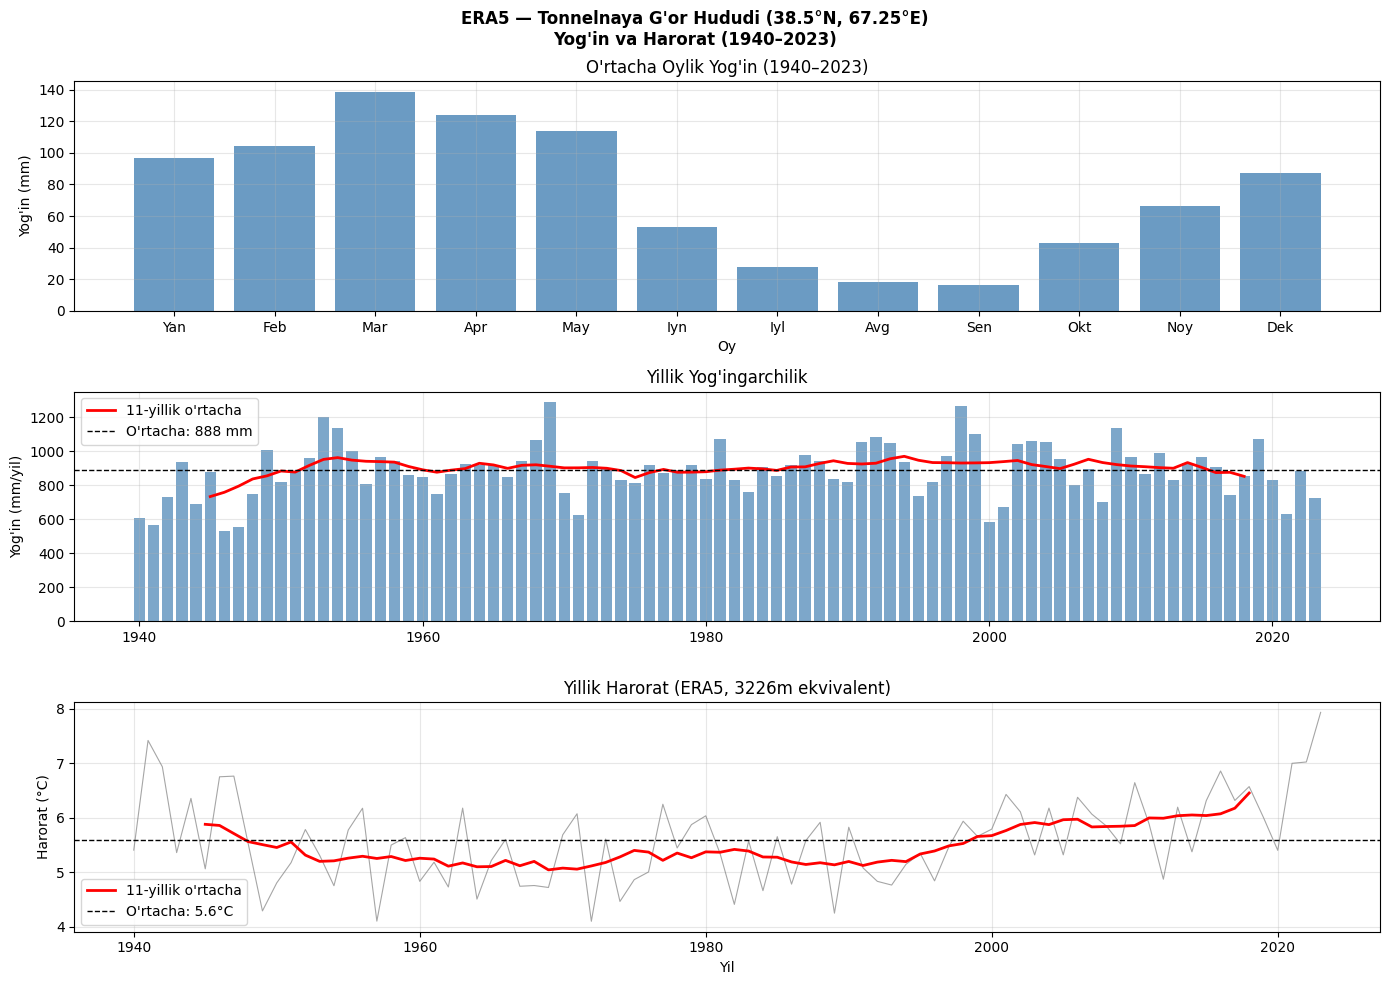


✅ Saqlandi: era5_cave_annual.csv
✅ Saqlandi: era5_cave_monthly.csv


In [10]:
import pandas as pd
import numpy as np
import calendar
import matplotlib.pyplot as plt

# df_monthly dan foydalanish (oldingi koddan)
# Mavsumiy yog'in pattern tekshirish

print("📊 O'rtacha oylik yog'in (Variant 1):")
monthly_avg = df_monthly.groupby('month')['precip_mm_v1'].mean()
for m, v in monthly_avg.items():
    bar = '█' * int(v/5)
    print(f"   {m:2d}-oy: {v:6.1f} mm  {bar}")

print(f"\n📊 Yillik yig'indi o'rtacha: {monthly_avg.sum():.1f} mm")

# O'rta Osiyo uchun tekshirish:
# Asosiy yog'in: mart-may (bahor)
# Quruq: iyun-sentyabr (yoz)
spring = monthly_avg[[3,4,5]].sum()
summer = monthly_avg[[6,7,8]].sum()
winter = monthly_avg[[12,1,2]].sum()

print(f"\n   Bahor (MAM): {spring:.1f} mm")
print(f"   Yoz   (JJA): {summer:.1f} mm")
print(f"   Qish  (DJF): {winter:.1f} mm")
print(f"\n   Bahor/Yillik nisbat: {spring/monthly_avg.sum()*100:.1f}%")

# ── Yillik qiymatlarni hisoblash ─────────────────────────────────
df_monthly['precip_mm'] = df_monthly['tp_raw'] * df_monthly['days_in_month'] * 1000

df_annual = df_monthly.groupby('year').agg(
    precip_mm=('precip_mm', 'sum'),
    temp_c=('temp_c', 'mean')
).reset_index()

print(f"\n📊 Yillik statistika:")
print(f"   Yog'in: {df_annual['precip_mm'].mean():.1f} ± "
      f"{df_annual['precip_mm'].std():.1f} mm/yil")
print(f"   Harorat: {df_annual['temp_c'].mean():.1f} ± "
      f"{df_annual['temp_c'].std():.1f} °C")
print(f"   Min yog'in: {df_annual['precip_mm'].min():.1f} mm "
      f"({df_annual.loc[df_annual['precip_mm'].idxmin(), 'year']})")
print(f"   Max yog'in: {df_annual['precip_mm'].max():.1f} mm "
      f"({df_annual.loc[df_annual['precip_mm'].idxmax(), 'year']})")

# ── Grafik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("ERA5 — Tonnelnaya G'or Hududi (38.5°N, 67.25°E)\n"
             "Yog'in va Harorat (1940–2023)", fontsize=12, fontweight='bold')

# Oylik mavsumiy pattern
ax1 = axes[0]
ax1.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8)
ax1.set_title("O'rtacha Oylik Yog'in (1940–2023)")
ax1.set_xlabel("Oy")
ax1.set_ylabel("Yog'in (mm)")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Yan','Feb','Mar','Apr','May','Iyn',
                      'Iyl','Avg','Sen','Okt','Noy','Dek'])
ax1.grid(True, alpha=0.3)

# Yillik yog'in
ax2 = axes[1]
ax2.bar(df_annual['year'], df_annual['precip_mm'], 
        color='steelblue', alpha=0.7, width=0.8)
ax2.plot(df_annual['year'], 
         df_annual['precip_mm'].rolling(11, center=True).mean(),
         color='red', lw=2, label='11-yillik o\'rtacha')
ax2.axhline(df_annual['precip_mm'].mean(), color='black', 
            ls='--', lw=1, label=f"O'rtacha: {df_annual['precip_mm'].mean():.0f} mm")
ax2.set_title("Yillik Yog'ingarchilik")
ax2.set_ylabel("Yog'in (mm/yil)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Yillik harorat
ax3 = axes[2]
ax3.plot(df_annual['year'], df_annual['temp_c'], 
         color='gray', lw=0.8, alpha=0.7)
ax3.plot(df_annual['year'],
         df_annual['temp_c'].rolling(11, center=True).mean(),
         color='red', lw=2, label='11-yillik o\'rtacha')
ax3.axhline(df_annual['temp_c'].mean(), color='black',
            ls='--', lw=1, label=f"O'rtacha: {df_annual['temp_c'].mean():.1f}°C")
ax3.set_title("Yillik Harorat (ERA5, 3226m ekvivalent)")
ax3.set_ylabel("Harorat (°C)")
ax3.set_xlabel("Yil")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('era5_cave_climate.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Saqlash ──────────────────────────────────────────────────────
df_annual.to_csv('era5_cave_annual.csv', index=False)
df_monthly.to_csv('era5_cave_monthly.csv', index=False)
print("\n✅ Saqlandi: era5_cave_annual.csv")
print("✅ Saqlandi: era5_cave_monthly.csv")

📂 TON-2 yuklandi:
   Rows: 2489
   Kolonkalar: ['depth_mm', 'age_calBP', 'd13CcarbVPDB', 'd18OcarbVPDB']
   depth_mm  age_calBP  d13CcarbVPDB  d18OcarbVPDB
0       0.0        -58          1.27         -5.69
1       0.1          9          1.48         -5.55
2       0.2         76          1.51         -5.50
3       0.3        144          2.33         -5.21
4       0.4        211          1.87         -5.54

📊 Growth Rate statistikasi:
   O'rtacha : 0.0071 mm/yil
   Median   : 0.0053 mm/yil
   Std      : 0.0095 mm/yil
   Min      : 0.0003 mm/yil
   Max      : 0.3000 mm/yil
   NaN soni : 20

📊 1000-yillik oyna growth rate:
   Oynalar soni: 64
   age_mid  growth_rate  n_points
0    442.0     0.001488        14
1   1442.0     0.001488        15
2   2442.0     0.006352        35
3   3442.0     0.002831        28
4   4442.0     0.003647        34
5   5442.0     0.001221        12
6   6442.0     0.002364        21
7   7442.0     0.002859        28
8   8442.0     0.005687        45
9   9442.0

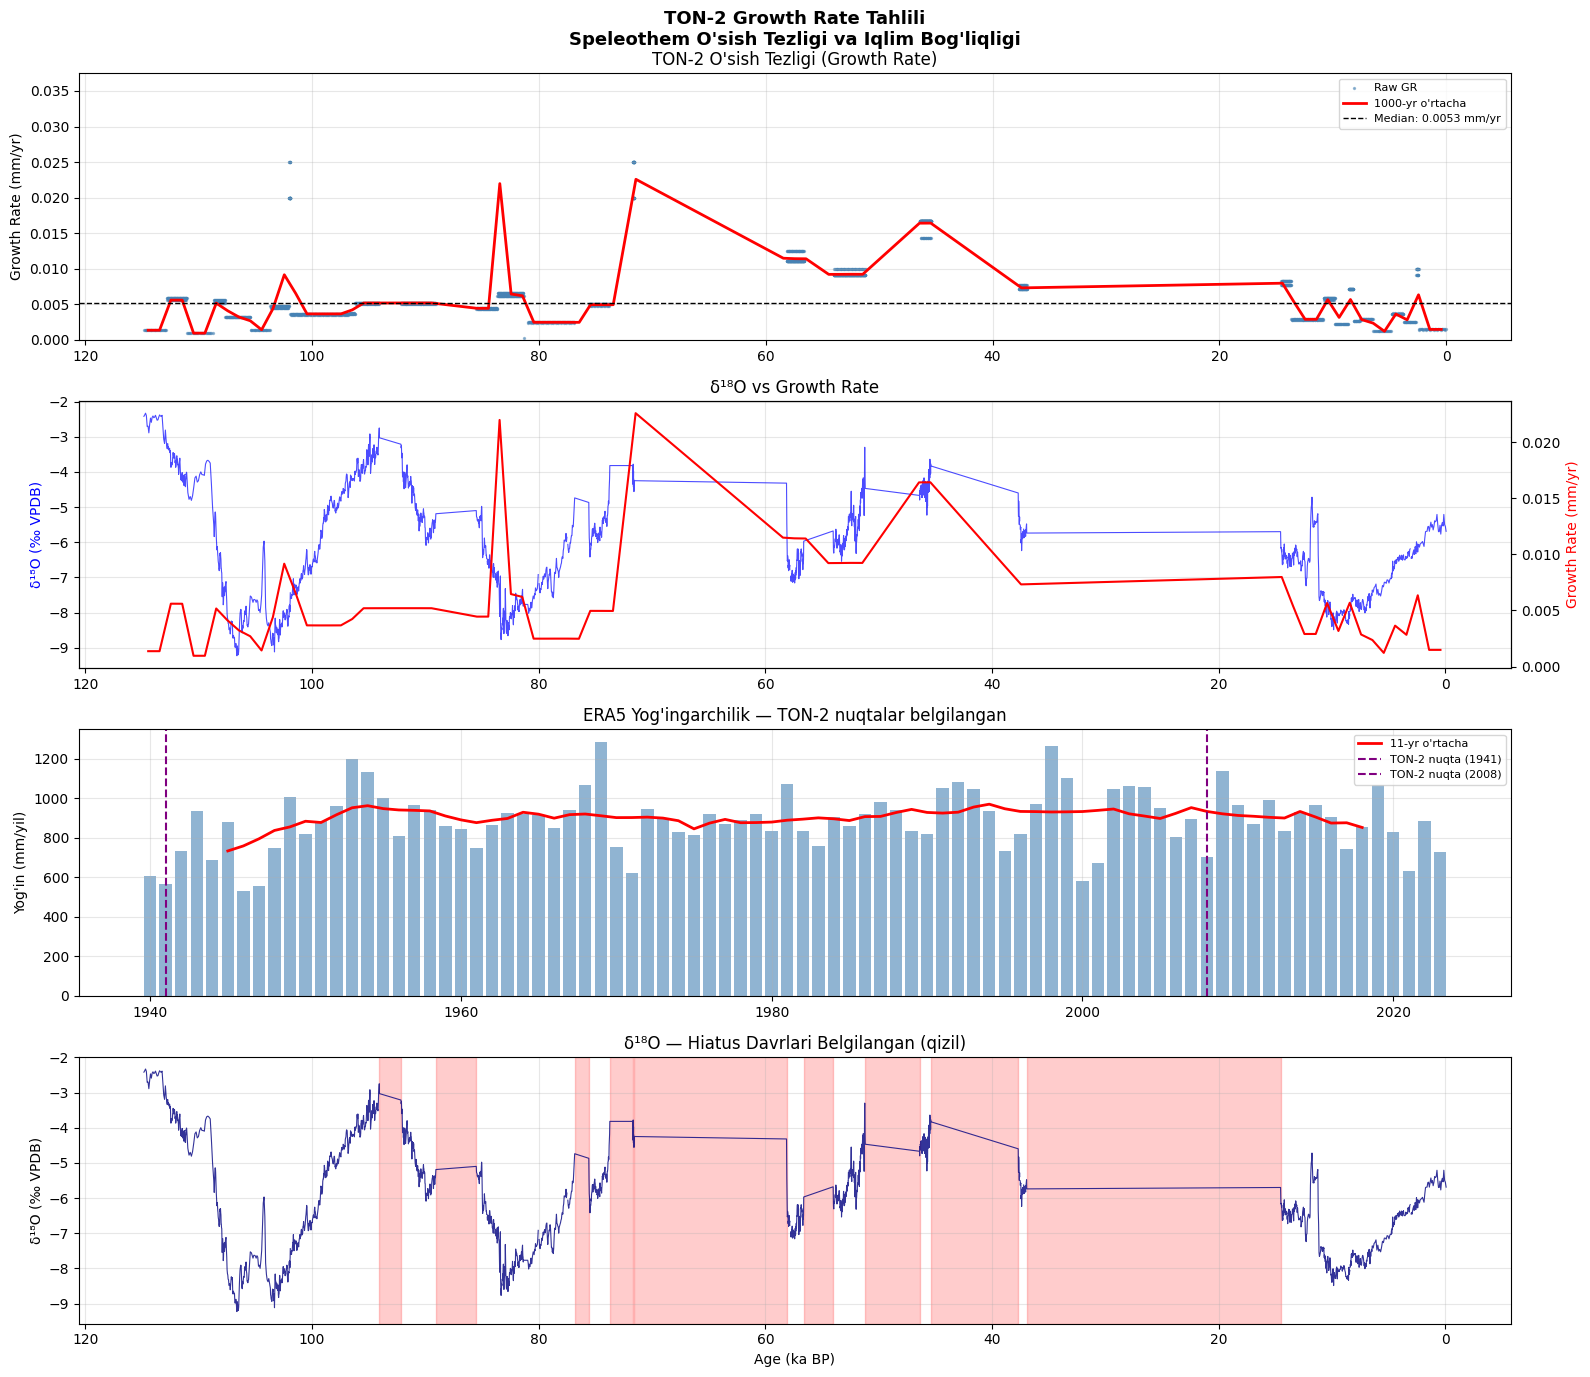


✅ Grafik saqlandi: fig_growth_rate.png
✅ Saqlandi: ton2_growth_rate.csv
✅ Saqlandi: ton2_gr_windowed.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. TON-2 ni yuklash ──────────────────────────────────────────
df2 = pd.read_csv('TON2_iso_original.csv')
df2 = df2.sort_values('age_calBP').reset_index(drop=True)

print("📂 TON-2 yuklandi:")
print(f"   Rows: {len(df2)}")
print(f"   Kolonkalar: {list(df2.columns)}")
print(df2.head())

# ── 2. Growth Rate Hisoblash ─────────────────────────────────────
# Growth rate = depth o'zgarishi / vaqt o'zgarishi (mm/yil)
# TON-2: age_calBP (o'sib boradi = eski), depth_mm (o'sib boradi)

# age_calBP → yilga aylantirish (1950 dan hisoblash)
# age_calBP = 0 → 1950 yil
# age_calBP = -58 → 2008 yil
# age_calBP = 9 → 1941 yil

df2['year_CE'] = 1950 - df2['age_calBP']

# Vaqt bo'yicha saralash (eng yangi → eng eski)
df2 = df2.sort_values('age_calBP').reset_index(drop=True)

# Growth rate: har ikki qo'shni nuqta orasida
# GR = Δdepth / Δage (mm/yil)
df2['d_depth'] = df2['depth_mm'].diff().abs()
df2['d_age']   = df2['age_calBP'].diff().abs()

# 0 ga bo'lishdan saqlash
df2['growth_rate'] = np.where(
    df2['d_age'] > 0,
    df2['d_depth'] / df2['d_age'],
    np.nan
)

# Hiatus davrlarida growth rate = 0 yoki NaN
# Katta d_age (>500 yil) = hiatus → NaN
HIATUS_THRESHOLD = 500  # yil
df2.loc[df2['d_age'] > HIATUS_THRESHOLD, 'growth_rate'] = np.nan

print(f"\n📊 Growth Rate statistikasi:")
print(f"   O'rtacha : {df2['growth_rate'].mean():.4f} mm/yil")
print(f"   Median   : {df2['growth_rate'].median():.4f} mm/yil")
print(f"   Std      : {df2['growth_rate'].std():.4f} mm/yil")
print(f"   Min      : {df2['growth_rate'].min():.4f} mm/yil")
print(f"   Max      : {df2['growth_rate'].max():.4f} mm/yil")
print(f"   NaN soni : {df2['growth_rate'].isna().sum()}")

# ── 3. Sliding Window Growth Rate ───────────────────────────────
# Har 1000 yillik oynada o'rtacha growth rate
window_size = 1000  # yil
age_bins = np.arange(df2['age_calBP'].min(),
                     df2['age_calBP'].max(),
                     window_size)

gr_windowed = []
for age_start in age_bins:
    age_end = age_start + window_size
    mask = ((df2['age_calBP'] >= age_start) &
            (df2['age_calBP'] < age_end) &
            (df2['growth_rate'].notna()))
    if mask.sum() > 0:
        gr_windowed.append({
            'age_mid'     : age_start + window_size / 2,
            'growth_rate' : df2.loc[mask, 'growth_rate'].mean(),
            'n_points'    : mask.sum()
        })

df_gr = pd.DataFrame(gr_windowed)
print(f"\n📊 1000-yillik oyna growth rate:")
print(f"   Oynalar soni: {len(df_gr)}")
print(df_gr.head(10).to_string())

# ── 4. Instrumental Davr (1940–2008) ────────────────────────────
# TON-2 ning instrumental davr bilan overlap qismi
instr_mask = df2['age_calBP'] <= 10  # ~1940 yildan keyin
df2_instr = df2[instr_mask].copy()

print(f"\n📊 Instrumental davr (age ≤ 10 BP):")
print(f"   Nuqtalar: {len(df2_instr)}")
print(df2_instr[['age_calBP', 'year_CE', 'depth_mm',
                  'growth_rate']].to_string())

# ── 5. ERA5 bilan birlashtirish ──────────────────────────────────
df_era5 = pd.read_csv('era5_cave_annual.csv')
print(f"\n📊 ERA5 yuklandi: {len(df_era5)} yil")

# Growth rate ni yillik ERA5 bilan solishtirish
# Faqat instrumental davr uchun (1940–2008)
# TON-2 dan 1941 va 2008 yillar
ton2_modern = df2[df2['age_calBP'].isin([-58, 9])].copy()
ton2_modern['year_CE'] = 1950 - ton2_modern['age_calBP']

print(f"\n📊 TON-2 zamonaviy nuqtalar:")
print(ton2_modern[['age_calBP', 'year_CE', 'depth_mm',
                    'd18OcarbVPDB', 'd13CcarbVPDB',
                    'growth_rate']].to_string())

# ERA5 da 1941 va 2008 yillar
era5_modern = df_era5[df_era5['year'].isin([1941, 2008])]
print(f"\n📊 ERA5 zamonaviy yillar:")
print(era5_modern.to_string())

# ── 6. Vizualizatsiya ────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle("TON-2 Growth Rate Tahlili\n"
             "Speleothem O'sish Tezligi va Iqlim Bog'liqligi",
             fontsize=13, fontweight='bold')

age_ka = df2['age_calBP'] / 1000

# Panel 1: Raw growth rate
ax1 = axes[0]
ax1.scatter(age_ka, df2['growth_rate'],
            s=2, color='steelblue', alpha=0.5, label='Raw GR')
ax1.plot(df_gr['age_mid'] / 1000,
         df_gr['growth_rate'],
         color='red', lw=2, label='1000-yr o\'rtacha')
ax1.axhline(df2['growth_rate'].median(),
            color='black', ls='--', lw=1,
            label=f"Median: {df2['growth_rate'].median():.4f} mm/yr")
ax1.set_ylabel('Growth Rate (mm/yr)')
ax1.set_title('TON-2 O\'sish Tezligi (Growth Rate)')
ax1.invert_xaxis()
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, df2['growth_rate'].quantile(0.99) * 1.5)

# Panel 2: δ¹⁸O va Growth Rate birga
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(age_ka, df2['d18OcarbVPDB'],
         color='blue', lw=0.8, alpha=0.7, label='δ¹⁸O')
ax2_twin.plot(df_gr['age_mid'] / 1000,
              df_gr['growth_rate'],
              color='red', lw=1.5, label='Growth Rate')
ax2.set_ylabel('δ¹⁸O (‰ VPDB)', color='blue')
ax2_twin.set_ylabel('Growth Rate (mm/yr)', color='red')
ax2.set_title('δ¹⁸O vs Growth Rate')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)

# Panel 3: ERA5 yog'in (instrumental davr)
ax3 = axes[2]
ax3.bar(df_era5['year'], df_era5['precip_mm'],
        color='steelblue', alpha=0.6, width=0.8)
ax3.plot(df_era5['year'],
         df_era5['precip_mm'].rolling(11, center=True).mean(),
         color='red', lw=2, label='11-yr o\'rtacha')
# 1941 va 2008 ni belgilash
for yr in [1941, 2008]:
    ax3.axvline(yr, color='purple', ls='--', lw=1.5,
                label=f'TON-2 nuqta ({yr})')
ax3.set_ylabel('Yog\'in (mm/yil)')
ax3.set_title('ERA5 Yog\'ingarchilik — TON-2 nuqtalar belgilangan')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# Panel 4: Hiatus davrlari
ax4 = axes[3]
ax4.plot(age_ka, df2['d18OcarbVPDB'],
         color='navy', lw=0.8, alpha=0.8)

# Hiatus davrlarini belgilash
hiatus_mask = df2['d_age'] > HIATUS_THRESHOLD
for _, row in df2[hiatus_mask].iterrows():
    ax4.axvspan(
        (row['age_calBP'] - row['d_age']) / 1000,
        row['age_calBP'] / 1000,
        color='red', alpha=0.2
    )

ax4.set_ylabel('δ¹⁸O (‰ VPDB)')
ax4.set_xlabel('Age (ka BP)')
ax4.set_title('δ¹⁸O — Hiatus Davrlari Belgilangan (qizil)')
ax4.invert_xaxis()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_growth_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Grafik saqlandi: fig_growth_rate.png")

# ── 7. Saqlash ───────────────────────────────────────────────────
df2[['age_calBP', 'year_CE', 'depth_mm',
     'd18OcarbVPDB', 'd13CcarbVPDB',
     'growth_rate']].to_csv('ton2_growth_rate.csv', index=False)
df_gr.to_csv('ton2_gr_windowed.csv', index=False)
print("✅ Saqlandi: ton2_growth_rate.csv")
print("✅ Saqlandi: ton2_gr_windowed.csv")

In [12]:
import os

# Joriy papkadagi barcha fayllarni ko'rish
print("📂 Joriy papka:", os.getcwd())
print("\n📋 Barcha fayllar:")
for f in sorted(os.listdir('.')):
    size = os.path.getsize(f) / 1024
    print(f"   {f:50s} {size:8.1f} KB")

📂 Joriy papka: C:\Users\user\paleo

📋 Barcha fayllar:
   .ipynb_checkpoints                                      4.0 KB
   1-rasm_boysun_yillik_harorat_dinamikasi.png           232.9 KB
   134k full analysis.ipynb                              643.5 KB
   2-rasm_boysun_yillik_harorat_anomaliyasi.png           78.4 KB
   3-rasm_boysun_mavsumiy_harorat_anomaliyalari.png      365.7 KB
   4-rasm_boysun_dekadal_o'rtacha_harorat.png            152.9 KB
   Aral86_pollen_reconstructions_TUSDB.tab                15.3 KB
   Climate_params_TUSDB.tab                               22.3 KB
   TON1_elem_original.csv                                 60.8 KB
   TON2_iso_original.csv                                  56.8 KB
   TUSDB_DataCollection_Dugerdil.zip                      98.2 KB
   Tonnel_analysis1.ipynb                               3112.6 KB
   Untitled.ipynb                                        262.5 KB
   Untitled1.ipynb                                      3643.0 KB
   Untitled2.ipynb    

In [13]:
df10 = pd.read_csv("cleaned_data.csv")
df10

,depth_mm,age_calBP,d13C,d18O,Sr_Ca,S_Ca,age_ka,growth_rate
0,381.2,133832.0,0.002491,0.001572,0.002491,0.001572,133.832,2.848368
1,381.0,133767.0,0.002207,0.001326,0.002207,0.001326,133.767,3.076923
2,380.8,133703.0,0.002071,0.001550,0.002071,0.001550,133.703,3.125000
3,380.6,133638.0,0.002020,0.001349,0.002020,0.001349,133.638,3.076923
4,380.4,133573.0,0.001995,0.001314,0.001995,0.001314,133.573,3.076923
...,...,...,...,...,...,...,...,...
2118,1.8,8211.0,0.000917,0.000293,0.000917,0.000293,8.211,7.407407
2119,1.6,8185.0,0.000883,0.000305,0.000883,0.000305,8.185,7.692308
2120,1.4,8158.0,0.000776,0.000252,0.000776,0.000252,8.158,7.407407
2121,1.2,8131.0,0.000692,0.000311,0.000692,0.000311,8.131,7.407407


✅ Ma'lumotlar yuklandi
   Growth rate oynalar: 64
   ERA5 grid: FrozenMappingWarningOnValuesAccess({'valid_time': 84, 'latitude': 29, 'longitude': 37})
   ERA5 o'zgaruvchilar: ['temp', 'precip']

   ERA5 vaqt: 1940 → 2023

   precip shape: (84, 29, 37)
   temp shape  : (84, 29, 37)
   Lat: 35.0 → 42.0
   Lon: 63.0 → 72.0

📊 TON-2 ERA5 overlap nuqtalar: 1

📊 Interpolated δ¹⁸O:
   Yillar: 1940 → 2023
   Min: -5.690, Max: -5.549

   Matched ERA5 years: 84
   d18O interp years : 84

✅ Spatial korrelyatsiya hisoblandi!
   Sig. grid nuqtalar (p<0.05): 335 / 1073
   r o'rtacha: -0.142
   r max     : 0.209
   r min     : -0.680


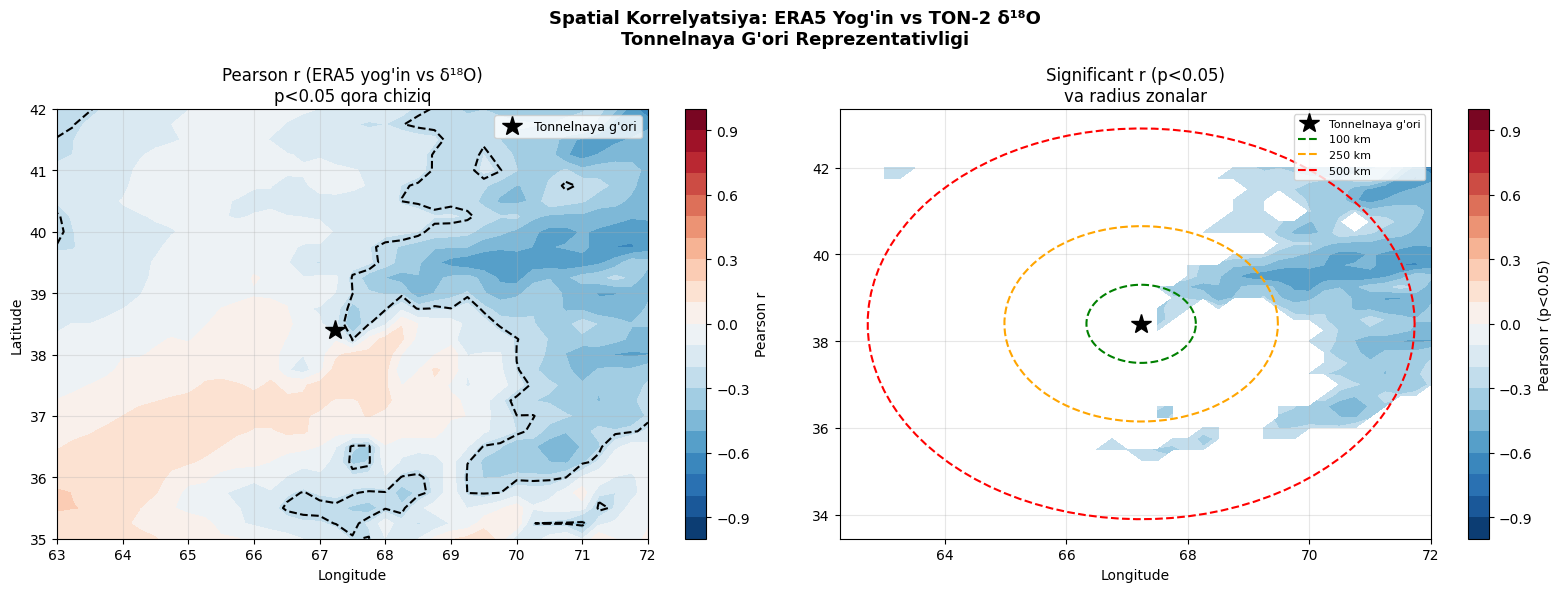


✅ Saqlandi: fig_spatial_correlation.png

📊 Radius tahlili:
   100 km:   8/ 42 grid sig (19.0%), r o'rtacha = -0.064
   250 km:  37/255 grid sig (14.5%), r o'rtacha = -0.058
   500 km: 249/909 grid sig (27.4%), r o'rtacha = -0.127


In [15]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr

# ── 1. Ma'lumotlarni yuklash ─────────────────────────────────────
df_gr = pd.read_csv('ton2_gr_windowed.csv')
ds    = xr.open_dataset('era5_regional_annual.nc', engine='netcdf4')

print("✅ Ma'lumotlar yuklandi")
print(f"   Growth rate oynalar: {len(df_gr)}")
print(f"   ERA5 grid: {ds.dims}")
print(f"   ERA5 o'zgaruvchilar: {list(ds.data_vars)}")
print(f"\n   ERA5 vaqt: "
      f"{pd.to_datetime(ds.valid_time.values[0]).year} → "
      f"{pd.to_datetime(ds.valid_time.values[-1]).year}")

# ── 2. ERA5 yillik o'rtachalarni hisoblash ───────────────────────
# valid_time → year
era5_years = pd.to_datetime(ds.valid_time.values).year

# Yog'in va harorat grid matritsalari
# Shape: (years, lat, lon)
precip = ds['precip'].values  # mm/yil
temp   = ds['temp'].values    # °C
lats   = ds.latitude.values
lons   = ds.longitude.values

print(f"\n   precip shape: {precip.shape}")
print(f"   temp shape  : {temp.shape}")
print(f"   Lat: {lats.min():.1f} → {lats.max():.1f}")
print(f"   Lon: {lons.min():.1f} → {lons.max():.1f}")

# ── 3. TON-2 growth rate — faqat instrumental davr ───────────────
# GR ni yillik ERA5 bilan solishtirish uchun
# TON-2 dan faqat yaqin davrni olamiz (0–2000 BP = 1950 yilgacha)
df_ton2 = pd.read_csv('ton2_growth_rate.csv')
df_ton2 = df_ton2.dropna(subset=['growth_rate'])
df_ton2['year_CE'] = 1950 - df_ton2['age_calBP']

# ERA5 davri bilan overlap: 1940–2008
df_ton2_era = df_ton2[
    (df_ton2['year_CE'] >= 1940) &
    (df_ton2['year_CE'] <= 2008)
].copy()

print(f"\n📊 TON-2 ERA5 overlap nuqtalar: {len(df_ton2_era)}")

# ── 4. Spatial Korrelyatsiya ─────────────────────────────────────
# Har bir grid nuqtasi uchun:
# ERA5 yog'in (1940–2008) vs TON-2 δ¹⁸O trend

# δ¹⁸O ni ERA5 yillari bilan interpolatsiya
df_ton2_full = pd.read_csv('ton2_growth_rate.csv')
df_ton2_full['year_CE'] = 1950 - df_ton2_full['age_calBP']
df_ton2_full = df_ton2_full.dropna(subset=['d18OcarbVPDB'])
df_ton2_full = df_ton2_full.sort_values('year_CE')

# ERA5 yillarida δ¹⁸O interpolatsiya
era5_yr_range = np.arange(1940, 2024)
d18o_interp = np.interp(
    era5_yr_range,
    df_ton2_full['year_CE'].values,
    df_ton2_full['d18OcarbVPDB'].values
)

print(f"\n📊 Interpolated δ¹⁸O:")
print(f"   Yillar: {era5_yr_range[0]} → {era5_yr_range[-1]}")
print(f"   Min: {d18o_interp.min():.3f}, Max: {d18o_interp.max():.3f}")

# ERA5 yog'inni bir xil yillar uchun ajratish
era5_mask = np.isin(era5_years, era5_yr_range)
precip_matched = precip[era5_mask]  # (84, lat, lon)

print(f"\n   Matched ERA5 years: {precip_matched.shape[0]}")
print(f"   d18O interp years : {len(d18o_interp)}")

# Korrelyatsiya matritsasi hisoblash
n_lat = len(lats)
n_lon = len(lons)
r_map  = np.full((n_lat, n_lon), np.nan)
p_map  = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        p_series = precip_matched[:, i, j]
        # NaN tekshirish
        valid = ~np.isnan(p_series) & ~np.isnan(d18o_interp)
        if valid.sum() > 10:
            r, p = pearsonr(p_series[valid], d18o_interp[valid])
            r_map[i, j] = r
            p_map[i, j] = p

print(f"\n✅ Spatial korrelyatsiya hisoblandi!")
print(f"   Sig. grid nuqtalar (p<0.05): "
      f"{(p_map < 0.05).sum()} / {n_lat * n_lon}")
print(f"   r o'rtacha: {np.nanmean(r_map):.3f}")
print(f"   r max     : {np.nanmax(r_map):.3f}")
print(f"   r min     : {np.nanmin(r_map):.3f}")

# ── 5. Xarita chizish ────────────────────────────────────────────
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("⚠️ Cartopy yo'q — oddiy xarita chizamiz")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Spatial Korrelyatsiya: ERA5 Yog\'in vs TON-2 δ¹⁸O\n"
    "Tonnelnaya G\'ori Reprezentativligi",
    fontsize=13, fontweight='bold'
)

# Significance mask
sig_mask = p_map < 0.05
r_masked = np.where(sig_mask, r_map, np.nan)

# Chap: barcha r qiymatlari
ax1 = axes[0]
im1 = ax1.contourf(lons, lats, r_map,
                    levels=np.linspace(-1, 1, 21),
                    cmap='RdBu_r')
ax1.contour(lons, lats, p_map,
            levels=[0.05], colors='black',
            linewidths=1.5, linestyles='--')
ax1.plot(67.23, 38.4, 'k*', markersize=15,
         label="Tonnelnaya g'ori")
ax1.set_title("Pearson r (ERA5 yog'in vs δ¹⁸O)\np<0.05 qora chiziq")
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='Pearson r')

# O'ng: faqat significant
ax2 = axes[1]
im2 = ax2.contourf(lons, lats, r_masked,
                    levels=np.linspace(-1, 1, 21),
                    cmap='RdBu_r')
ax2.plot(67.23, 38.4, 'k*', markersize=15,
         label="Tonnelnaya g'ori")

# 100, 250, 500 km radiuslar
for radius_km, color in [(100, 'green'),
                          (250, 'orange'),
                          (500, 'red')]:
    radius_deg = radius_km / 111
    theta = np.linspace(0, 2*np.pi, 100)
    ax2.plot(67.23 + radius_deg * np.cos(theta),
             38.4  + radius_deg * np.sin(theta),
             color=color, lw=1.5, ls='--',
             label=f'{radius_km} km')

ax2.set_title("Significant r (p<0.05)\nva radius zonalar")
ax2.set_xlabel('Longitude')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='Pearson r (p<0.05)')

plt.tight_layout()
plt.savefig('fig_spatial_correlation.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Saqlandi: fig_spatial_correlation.png")

# ── 6. Radius tahlili ────────────────────────────────────────────
print("\n📊 Radius tahlili:")
cave_lat, cave_lon = 38.4, 67.23

for radius_km in [100, 250, 500]:
    radius_deg = radius_km / 111
    in_radius  = np.full((n_lat, n_lon), False)
    for i, la in enumerate(lats):
        for j, lo in enumerate(lons):
            dist = np.sqrt((la-cave_lat)**2 + (lo-cave_lon)**2)
            if dist <= radius_deg:
                in_radius[i, j] = True
    total   = in_radius.sum()
    sig_cnt = (sig_mask & in_radius).sum()
    pct     = sig_cnt / total * 100 if total > 0 else 0
    r_mean  = np.nanmean(r_map[in_radius])
    print(f"   {radius_km:3d} km: "
          f"{sig_cnt:3d}/{total:3d} grid sig ({pct:.1f}%), "
          f"r o'rtacha = {r_mean:.3f}")

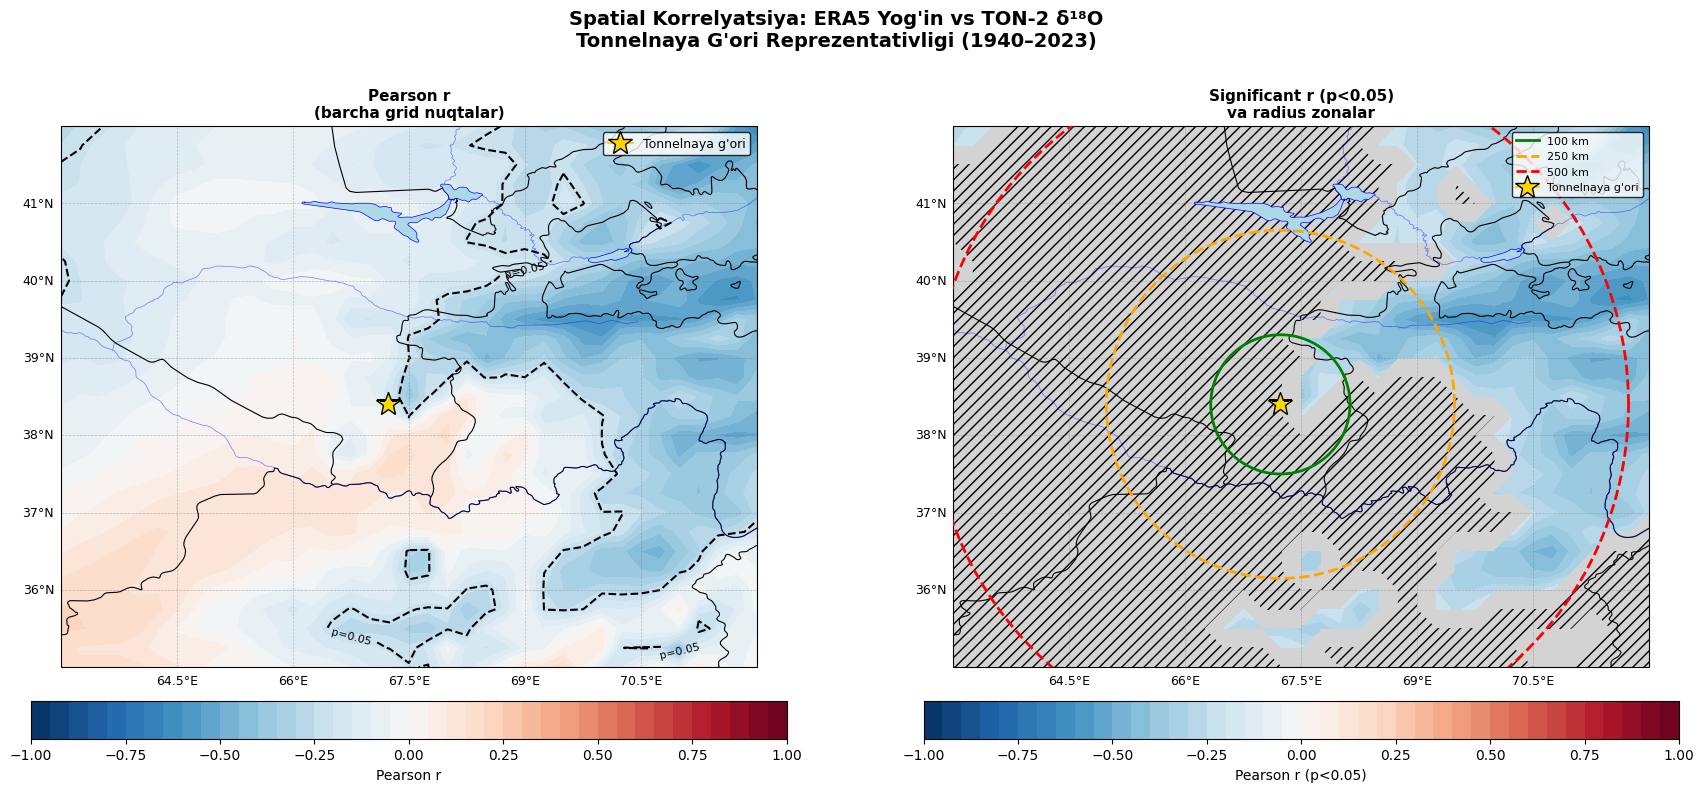

✅ Saqlandi: fig_spatial_correlation_cartopy.png

📊 Radius tahlili (yangilangan):
   100 km:   8/ 42 sig (19.0%), r o'rtacha=-0.064, manfiy sig=8
   250 km:  37/255 sig (14.5%), r o'rtacha=-0.058, manfiy sig=37
   500 km: 249/909 sig (27.4%), r o'rtacha=-0.127, manfiy sig=249


In [16]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.stats import pearsonr

# ── 1. Ma'lumotlarni yuklash ─────────────────────────────────────
ds = xr.open_dataset('era5_regional_annual.nc', engine='netcdf4')
df_ton2 = pd.read_csv('ton2_growth_rate.csv')
df_ton2['year_CE'] = 1950 - df_ton2['age_calBP']
df_ton2 = df_ton2.dropna(subset=['d18OcarbVPDB']).sort_values('year_CE')

era5_years = pd.to_datetime(ds.valid_time.values).year
lats = ds.latitude.values
lons = ds.longitude.values
precip = ds['precip'].values

# ── 2. δ¹⁸O interpolatsiya ──────────────────────────────────────
era5_yr_range = np.arange(1940, 2024)
d18o_interp = np.interp(
    era5_yr_range,
    df_ton2['year_CE'].values,
    df_ton2['d18OcarbVPDB'].values
)
era5_mask = np.isin(era5_years, era5_yr_range)
precip_matched = precip[era5_mask]

# ── 3. Spatial korrelyatsiya ─────────────────────────────────────
n_lat, n_lon = len(lats), len(lons)
r_map = np.full((n_lat, n_lon), np.nan)
p_map = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        p_series = precip_matched[:, i, j]
        valid = ~np.isnan(p_series) & ~np.isnan(d18o_interp)
        if valid.sum() > 10:
            r, p = pearsonr(p_series[valid], d18o_interp[valid])
            r_map[i, j] = r
            p_map[i, j] = p

sig_mask = p_map < 0.05
r_masked = np.where(sig_mask, r_map, np.nan)

# ── 4. Cartopy xarita ────────────────────────────────────────────
cave_lat, cave_lon = 38.4, 67.23

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 8))
fig.suptitle(
    "Spatial Korrelyatsiya: ERA5 Yog'in vs TON-2 δ¹⁸O\n"
    "Tonnelnaya G'ori Reprezentativligi (1940–2023)",
    fontsize=14, fontweight='bold', y=1.01
)

# Rang shkalasi
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
levels = np.linspace(-1, 1, 41)

# ── Panel 1: Barcha r qiymatlari ─────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection=proj)
ax1.set_extent([63, 72, 35, 42], crs=proj)

# Asosiy xarita elementlari
ax1.add_feature(cfeature.LAND,
                facecolor='lightgray', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.OCEAN,
                facecolor='lightblue', edgecolor='none', zorder=0)
ax1.add_feature(cfeature.BORDERS,
                linewidth=0.8, edgecolor='black', zorder=3)
ax1.add_feature(cfeature.COASTLINE,
                linewidth=0.8, zorder=3)
ax1.add_feature(cfeature.RIVERS,
                linewidth=0.5, edgecolor='blue',
                alpha=0.5, zorder=3)

# Tog' relyefi
ax1.add_feature(cfeature.LAKES,
                facecolor='lightblue', edgecolor='blue',
                linewidth=0.5, zorder=3)

# Korrelyatsiya
cf1 = ax1.contourf(lons, lats, r_map,
                    levels=levels, cmap=cmap,
                    norm=norm, transform=proj, zorder=1)

# Significance chegarasi
cs1 = ax1.contour(lons, lats, p_map,
                   levels=[0.05],
                   colors='black', linewidths=1.5,
                   linestyles='--', transform=proj, zorder=2)
ax1.clabel(cs1, fmt='p=0.05', fontsize=8)

# G'or belgisi
ax1.plot(cave_lon, cave_lat,
         marker='*', color='gold', markersize=18,
         markeredgecolor='black', markeredgewidth=1.0,
         transform=proj, zorder=5, label="Tonnelnaya g'ori")

ax1.set_title("Pearson r\n(barcha grid nuqtalar)",
              fontsize=11, fontweight='bold')

# Grid chiziqlar
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5,
                     color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
gl1.xlabel_style = {'size': 9}
gl1.ylabel_style = {'size': 9}

ax1.legend(loc='upper right', fontsize=9,
           facecolor='white', edgecolor='black')

plt.colorbar(cf1, ax=ax1, orientation='horizontal',
             pad=0.05, label='Pearson r', shrink=0.9)

# ── Panel 2: Significant + Radius ───────────────────────────────
ax2 = fig.add_subplot(1, 2, 2, projection=proj)
ax2.set_extent([63, 72, 35, 42], crs=proj)

ax2.add_feature(cfeature.LAND,
                facecolor='lightgray', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.OCEAN,
                facecolor='lightblue', edgecolor='none', zorder=0)
ax2.add_feature(cfeature.BORDERS,
                linewidth=0.8, edgecolor='black', zorder=3)
ax2.add_feature(cfeature.COASTLINE,
                linewidth=0.8, zorder=3)
ax2.add_feature(cfeature.RIVERS,
                linewidth=0.5, edgecolor='blue',
                alpha=0.5, zorder=3)
ax2.add_feature(cfeature.LAKES,
                facecolor='lightblue', edgecolor='blue',
                linewidth=0.5, zorder=3)

# Faqat significant r
cf2 = ax2.contourf(lons, lats, r_masked,
                    levels=levels, cmap=cmap,
                    norm=norm, transform=proj, zorder=1)

# Hatching — significant bo'lmagan zonalar
ax2.contourf(lons, lats,
             np.where(~sig_mask, 1, np.nan),
             levels=[0.5, 1.5],
             colors='none', hatches=['///'],
             transform=proj, zorder=2)

# Radius doiralari
radius_styles = [
    (100, 'green',  'solid',  '100 km'),
    (250, 'orange', 'dashed', '250 km'),
    (500, 'red',    'dashed', '500 km'),
]
for radius_km, color, ls, label in radius_styles:
    radius_deg = radius_km / 111
    theta = np.linspace(0, 2*np.pi, 360)
    circle_lons = cave_lon + radius_deg * np.cos(theta)
    circle_lats = cave_lat + radius_deg * np.sin(theta)
    ax2.plot(circle_lons, circle_lats,
             color=color, lw=2.0, ls=ls,
             transform=proj, zorder=4, label=label)

# G'or belgisi
ax2.plot(cave_lon, cave_lat,
         marker='*', color='gold', markersize=18,
         markeredgecolor='black', markeredgewidth=1.0,
         transform=proj, zorder=5,
         label="Tonnelnaya g'ori")

ax2.set_title("Significant r (p<0.05)\nva radius zonalar",
              fontsize=11, fontweight='bold')

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5,
                     color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER
gl2.xlabel_style = {'size': 9}
gl2.ylabel_style = {'size': 9}

ax2.legend(loc='upper right', fontsize=8,
           facecolor='white', edgecolor='black')

plt.colorbar(cf2, ax=ax2, orientation='horizontal',
             pad=0.05, label='Pearson r (p<0.05)', shrink=0.9)

plt.tight_layout()
plt.savefig('fig_spatial_correlation_cartopy.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saqlandi: fig_spatial_correlation_cartopy.png")

# ── 5. Radius statistikasi ───────────────────────────────────────
print("\n📊 Radius tahlili (yangilangan):")
lon_grid, lat_grid = np.meshgrid(lons, lats)

for radius_km in [100, 250, 500]:
    radius_deg = radius_km / 111
    dist = np.sqrt((lat_grid - cave_lat)**2 +
                   (lon_grid - cave_lon)**2)
    in_radius = dist <= radius_deg
    total     = in_radius.sum()
    sig_cnt   = (sig_mask & in_radius).sum()
    pct       = sig_cnt / total * 100 if total > 0 else 0
    r_mean    = np.nanmean(r_map[in_radius])
    neg_sig   = ((r_map < 0) & sig_mask & in_radius).sum()
    print(f"   {radius_km:3d} km: "
          f"{sig_cnt:3d}/{total:3d} sig ({pct:.1f}%), "
          f"r o'rtacha={r_mean:.3f}, "
          f"manfiy sig={neg_sig}")

In [18]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

# ── NOAA dan to'g'ridan-to'g'ri yuklab olish ────────────────────
cave_records = {
    'Kesang': {
        'url': 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016iso.txt',
        'lat': 42.87, 'lon': 81.71,
        'country': 'China',
        'reference': 'Cheng et al. 2016'
    },
    'Uluu-Too': {
        'url': 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/kyrgyzstan/uluu-too2017s-ca-noaa.txt',
        'lat': 40.5, 'lon': 72.8,
        'country': 'Kyrgyzstan',
        'reference': 'Wolff et al. 2017'
    },
    'Fergana': {
        'url': 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/kyrgyzstan/tan2024/tan2024-f11_iso.txt',
        'lat': 40.5, 'lon': 72.5,
        'country': 'Kyrgyzstan',
        'reference': 'Tan et al. 2024'
    },
}

# ── Har bir g'orni yuklash ───────────────────────────────────────
downloaded = {}

for name, info in cave_records.items():
    print(f"\n📥 {name} yuklanmoqda...")
    try:
        r = requests.get(info['url'], timeout=30)
        if r.status_code == 200:
            # # bilan boshlanadigan qatorlarni o'tkazib yuborish
            lines = [l for l in r.text.split('\n')
                     if not l.startswith('#') and l.strip()]
            content = '\n'.join(lines)

            # CSV ga o'qish
            df = pd.read_csv(StringIO(content), sep='\t',
                             on_bad_lines='skip')
            df.columns = df.columns.str.strip()

            print(f"   ✅ Yuklandi!")
            print(f"   Rows: {len(df)}")
            print(f"   Kolonkalar: {list(df.columns)}")
            print(df.head(3).to_string())

            downloaded[name] = {
                'df': df,
                'lat': info['lat'],
                'lon': info['lon'],
                'reference': info['reference']
            }

            # Saqlash
            df.to_csv(f'{name.lower()}_data.csv', index=False)
            print(f"   💾 Saqlandi: {name.lower()}_data.csv")

        else:
            print(f"   ❌ HTTP xato: {r.status_code}")

    except Exception as e:
        print(f"   ❌ Xato: {e}")

print(f"\n\n✅ Jami yuklandi: {len(downloaded)}/{len(cave_records)} g'or")


📥 Kesang yuklanmoqda...
   ❌ HTTP xato: 404

📥 Uluu-Too yuklanmoqda...
   ✅ Yuklandi!
   Rows: 1756
   Kolonkalar: ['depth_mm', 'age_calBP', 'S1000/Ca']
   depth_mm  age_calBP  S1000/Ca
0       0.8         24      1.47
1       0.9         25      1.44
2       1.0         27      1.41
   💾 Saqlandi: uluu-too_data.csv

📥 Fergana yuklanmoqda...
   ✅ Yuklandi!
   Rows: 2001
   Kolonkalar: ['depth', 'age', 'd18O', 'd13C']
   depth  age   d18O  d13C
0    0.0  656 -11.49 -6.68
1    0.1  658 -11.28 -6.19
2    0.2  661 -11.34 -6.25
   💾 Saqlandi: fergana_data.csv


✅ Jami yuklandi: 2/3 g'or


In [19]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

def download_noaa(url, name):
    try:
        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            print(f"   ❌ HTTP {r.status_code}")
            return None
        lines = [l for l in r.text.split('\n')
                 if not l.startswith('#') and l.strip()]
        df = pd.read_csv(StringIO('\n'.join(lines)),
                         sep='\t', on_bad_lines='skip')
        df.columns = df.columns.str.strip()
        print(f"   ✅ {len(df)} rows | {list(df.columns)}")
        df.to_csv(f'{name}.csv', index=False)
        return df
    except Exception as e:
        print(f"   ❌ {e}")
        return None

# ── Kesang stalagmitlari (barcha qismlari) ───────────────────────
kesang_files = {
    'kesang_ks08_2'    : 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016ks08-2iso-noaa.txt',
    'kesang_ks08_2mis3': 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016ks08-2-mis3iso-noaa.txt',
    'kesang_ks08_1h'   : 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016ks08-1-hiso-noaa.txt',
    'kesang_ks08_6'    : 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016ks08-6iso-noaa.txt',
    'kesang_ks06b'     : 'https://www.ncei.noaa.gov/pub/data/paleo/speleothem/asia/china/kesang2016ks06biso-noaa.txt',
}

dfs = {}
for name, url in kesang_files.items():
    print(f"\n📥 {name}...")
    df = download_noaa(url, name)
    if df is not None:
        dfs[name] = df

# ── Kesang qismlarini birlashtirish ──────────────────────────────
print("\n\n📊 Kesang stalagmitlarini birlashtirish...")

kesang_parts = []
for name, df in dfs.items():
    df_c = df.copy()
    df_c.columns = df_c.columns.str.lower()

    # age kolonkasini standartlashtirish
    age_col = [c for c in df_c.columns if 'age' in c]
    d18o_col = [c for c in df_c.columns if 'd18o' in c.lower()]

    if age_col and d18o_col:
        df_std = pd.DataFrame({
            'age_calBP' : df_c[age_col[0]],
            'd18O'      : df_c[d18o_col[0]],
            'source'    : name
        })
        # age ka BP → yr BP (agar kerak bo'lsa)
        if 'ka' in age_col[0].lower():
            df_std['age_calBP'] = df_std['age_calBP'] * 1000

        print(f"   {name}: {len(df_std)} rows | "
              f"age {df_std['age_calBP'].min():.0f}–"
              f"{df_std['age_calBP'].max():.0f} BP")
        kesang_parts.append(df_std)

if kesang_parts:
    df_kesang = pd.concat(kesang_parts, ignore_index=True)
    df_kesang = df_kesang.sort_values('age_calBP').reset_index(drop=True)
    df_kesang = df_kesang.drop_duplicates(subset='age_calBP')

    print(f"\n✅ Kesang composite:")
    print(f"   Jami: {len(df_kesang)} rows")
    print(f"   Age: {df_kesang['age_calBP'].min():.0f} → "
          f"{df_kesang['age_calBP'].max():.0f} BP")
    print(f"   d18O: {df_kesang['d18O'].min():.2f} → "
          f"{df_kesang['d18O'].max():.2f} ‰")

    df_kesang.to_csv('kesang_composite.csv', index=False)
    print("   💾 Saqlandi: kesang_composite.csv")


📥 kesang_ks08_2...
   ✅ 605 rows | ['depth_mm', 'age_calkaBP', 'd18OcarbVPDB', 'd13CcarbVPDB']

📥 kesang_ks08_2mis3...
   ✅ 89 rows | ['depth_mm', 'age_calkaBP', 'd18OcarbVPDB', 'd13CcarbVPDB']

📥 kesang_ks08_1h...
   ✅ 159 rows | ['depth_mm', 'age_calkaBP', 'd18OcarbVPDB', 'd13CcarbVPDB']

📥 kesang_ks08_6...
   ✅ 46 rows | ['depth_mm', 'age_calBP', 'd18OcarbVPDB', 'd13CcarbVPDB']

📥 kesang_ks06b...
   ✅ 451 rows | ['depth_mm', 'age_calkaBP', 'd18OcarbVPDB', 'd13CcarbVPDB']


📊 Kesang stalagmitlarini birlashtirish...
   kesang_ks08_2: 605 rows | age 70900–230100 BP
   kesang_ks08_2mis3: 89 rows | age 51610–53730 BP
   kesang_ks08_1h: 159 rows | age 5–3520 BP
   kesang_ks08_6: 46 rows | age 852–1318 BP
   kesang_ks06b: 451 rows | age 257200–456500 BP

✅ Kesang composite:
   Jami: 1098 rows
   Age: 5 → 456500 BP
   d18O: -13.27 → -6.00 ‰
   💾 Saqlandi: kesang_composite.csv


In [20]:
import numpy as np
import pandas as pd

df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()

def run_regime(df, bin_w=500, thr=0.5, min_ep=2000):
    d = df.copy()
    d["age_bin"] = (d["age_calBP"] // bin_w) * bin_w
    b = d.groupby("age_bin", as_index=False)["d18OcarbVPDB"].mean().rename(columns={"d18OcarbVPDB":"d18O"})
    b["z"] = (b["d18O"] - b["d18O"].mean()) / b["d18O"].std()

    b["regime"] = "Normal"
    b.loc[b["z"] >= thr, "regime"] = "High_d18O"
    b.loc[b["z"] <= -thr, "regime"] = "Low_d18O"

    # episodes
    eps, cur = [], None
    for _, r in b.iterrows():
        a, lab = int(r["age_bin"]), r["regime"]
        if cur is None:
            cur = {"label": lab, "start": a, "end": a}
        elif lab == cur["label"] and a == cur["end"] + bin_w:
            cur["end"] = a
        else:
            eps.append(cur); cur = {"label": lab, "start": a, "end": a}
    if cur is not None: eps.append(cur)

    ep = pd.DataFrame(eps)
    ep["duration"] = ep["end"] - ep["start"] + bin_w
    ep_long = ep[ep["duration"] >= min_ep].copy()

    out = {
        "bin_w": bin_w,
        "thr": thr,
        "n_bins": len(b),
        "n_high": int((b["regime"]=="High_d18O").sum()),
        "n_low": int((b["regime"]=="Low_d18O").sum()),
        "n_normal": int((b["regime"]=="Normal").sum()),
        "n_long_episodes": len(ep_long),
        "max_episode_yr": int(ep["duration"].max()) if len(ep) else 0
    }
    return out, ep_long

rows = []
all_long = []
for bw in [200, 500, 1000]:
    for t in [0.3, 0.5, 0.7]:
        s, ep_long = run_regime(df, bin_w=bw, thr=t, min_ep=2000)
        rows.append(s)
        ep_long["bin_w"] = bw
        ep_long["thr"] = t
        all_long.append(ep_long)

sens = pd.DataFrame(rows).sort_values(["bin_w","thr"])
sens.to_csv("gmimos_regime_sensitivity_summary.csv", index=False)
pd.concat(all_long, ignore_index=True).to_csv("gmimos_regime_sensitivity_episodes.csv", index=False)

print(sens)
print("\nSaved: gmimos_regime_sensitivity_summary.csv, gmimos_regime_sensitivity_episodes.csv")

   bin_w  thr  n_bins  n_high  n_low  n_normal  n_long_episodes  \
0    200  0.3     283     106    113        64                9   
1    200  0.5     283      82     97       104               10   
2    200  0.7     283      69     83       131               11   
3    500  0.3     121      46     50        25                8   
4    500  0.5     121      35     40        46               11   
5    500  0.7     121      29     34        58               15   
6   1000  0.3      65      23     25        17               14   
7   1000  0.5      65      19     21        25               13   
8   1000  0.7      65      16     18        31               16   

   max_episode_yr  
0            6800  
1            6600  
2            6200  
3            8500  
4            7500  
5            6000  
6            8000  
7            8000  
8            7000  

Saved: gmimos_regime_sensitivity_summary.csv, gmimos_regime_sensitivity_episodes.csv


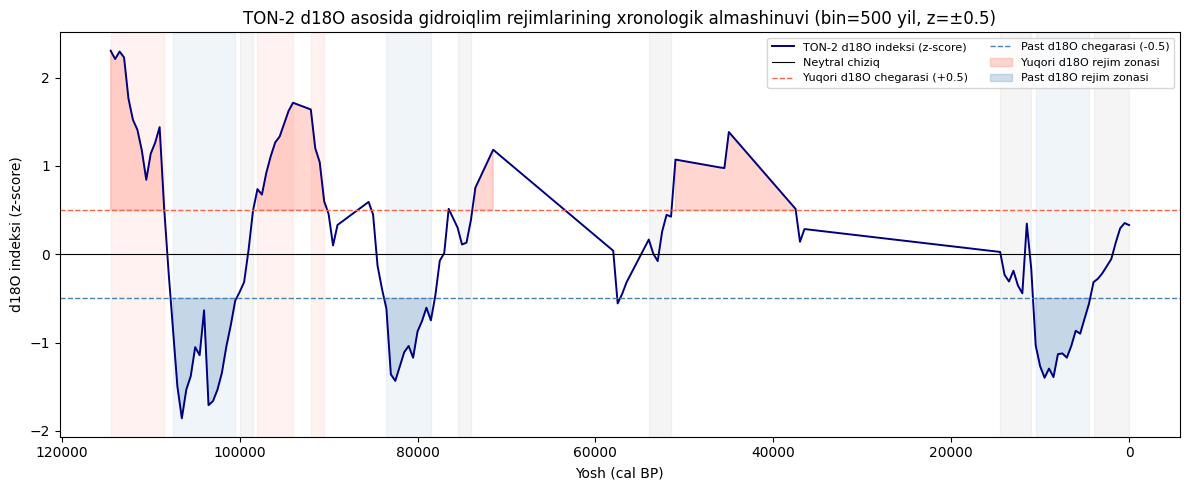

Saved files:
 - GMIMOS_Jadval_Regime_Chronology.csv
 - GMIMOS_Jadval_Regime_Summary.csv
 - GMIMOS_Rasm_Regime_Chronology.png

Chronology preview:
    start_calBP  end_calBP  duration_yr              regime              MIS  \
0             0       4000         4500              Normal  MIS 1 (Holosen)   
1          4500      10500         6500    Past d18O rejimi  MIS 1 (Holosen)   
2         11000      14500         4000              Normal            MIS 2   
3         51500      54000         3000              Normal            MIS 3   
4         74000      75500         2000              Normal            MIS 5   
5         78500      83500         5500    Past d18O rejimi            MIS 5   
6         90500      92000         2000  Yuqori d18O rejimi            MIS 5   
7         94000      98000         4500  Yuqori d18O rejimi            MIS 5   
8         98500     100000         2000              Normal            MIS 5   
9        100500     107500         7500    Past d18O r

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# GMIMOS final regime output
# Fixed params: bin=500, threshold=±0.5
# =========================================================

BIN_W = 500
THR = 0.5
MIN_EP_YR = 2000

# 1) Load
df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
df = df.sort_values("age_calBP")

# 2) Bin & z-index
df["age_bin"] = (df["age_calBP"] // BIN_W) * BIN_W
b = df.groupby("age_bin", as_index=False).agg(
    d18O_mean=("d18OcarbVPDB","mean"),
    n=("d18OcarbVPDB","count")
)

mu, sd = b["d18O_mean"].mean(), b["d18O_mean"].std()
b["d18O_z"] = (b["d18O_mean"] - mu) / sd

# 3) Regime labels
b["regime"] = "Normal"
b.loc[b["d18O_z"] >= THR, "regime"] = "Yuqori d18O rejimi"
b.loc[b["d18O_z"] <= -THR, "regime"] = "Past d18O rejimi"

# 4) Episode extraction
episodes = []
cur = None
for _, r in b.iterrows():
    age = int(r["age_bin"])
    lab = r["regime"]
    if cur is None:
        cur = {"regime": lab, "start_calBP": age, "end_calBP": age}
    elif lab == cur["regime"] and age == cur["end_calBP"] + BIN_W:
        cur["end_calBP"] = age
    else:
        episodes.append(cur)
        cur = {"regime": lab, "start_calBP": age, "end_calBP": age}
if cur is not None:
    episodes.append(cur)

ep = pd.DataFrame(episodes)
ep["duration_yr"] = ep["end_calBP"] - ep["start_calBP"] + BIN_W
ep["age_mid"] = (ep["start_calBP"] + ep["end_calBP"]) / 2

# 5) MIS helper
def mis_label(age):
    if age <= 11700:
        return "MIS 1 (Holosen)"
    elif age <= 29000:
        return "MIS 2"
    elif age <= 57000:
        return "MIS 3"
    elif age <= 71000:
        return "MIS 4"
    else:
        return "MIS 5"

ep["MIS"] = ep["age_mid"].apply(mis_label)

# 6) d18O median per episode
meds = []
for _, r in ep.iterrows():
    w = b[(b["age_bin"] >= r["start_calBP"]) & (b["age_bin"] <= r["end_calBP"])]
    meds.append(w["d18O_mean"].median())
ep["d18O_median_VPDB"] = meds

# 7) Long episodes table
ep_long = ep[ep["duration_yr"] >= MIN_EP_YR].copy().sort_values("start_calBP").reset_index(drop=True)

# Add CE approximate for readability (for very recent only meaningful)
ep_long["start_CE_approx"] = 1950 - ep_long["start_calBP"]
ep_long["end_CE_approx"] = 1950 - ep_long["end_calBP"]

# Publication-ready table
final_cols = [
    "start_calBP","end_calBP","duration_yr","regime","MIS","d18O_median_VPDB",
    "start_CE_approx","end_CE_approx"
]
final_tbl = ep_long[final_cols].copy()
final_tbl.to_csv("GMIMOS_Jadval_Regime_Chronology.csv", index=False)

# 8) Summary stats table
summary = pd.DataFrame({
    "Ko'rsatkich": [
        "Bin kengligi (yil)",
        "Threshold (z)",
        "Umumiy binlar soni",
        "Yuqori d18O binlari",
        "Past d18O binlari",
        "Normal binlar",
        "Uzoq epizodlar (>=2000 yil)",
        "Eng uzun epizod (yil)"
    ],
    "Qiymat": [
        BIN_W,
        THR,
        len(b),
        int((b["regime"]=="Yuqori d18O rejimi").sum()),
        int((b["regime"]=="Past d18O rejimi").sum()),
        int((b["regime"]=="Normal").sum()),
        len(ep_long),
        int(ep["duration_yr"].max()) if len(ep)>0 else np.nan
    ]
})
summary.to_csv("GMIMOS_Jadval_Regime_Summary.csv", index=False)

# 9) Final figure with legend
plt.figure(figsize=(12,5))
plt.plot(b["age_bin"], b["d18O_z"], color="navy", lw=1.4, label="TON-2 d18O indeksi (z-score)")
plt.axhline(0, color="black", lw=0.8, label="Neytral chiziq")
plt.axhline(THR, color="tomato", ls="--", lw=1, label="Yuqori d18O chegarasi (+0.5)")
plt.axhline(-THR, color="steelblue", ls="--", lw=1, label="Past d18O chegarasi (-0.5)")

plt.fill_between(
    b["age_bin"], b["d18O_z"], THR,
    where=(b["d18O_z"] >= THR),
    color="tomato", alpha=0.25, label="Yuqori d18O rejim zonasi"
)
plt.fill_between(
    b["age_bin"], b["d18O_z"], -THR,
    where=(b["d18O_z"] <= -THR),
    color="steelblue", alpha=0.25, label="Past d18O rejim zonasi"
)

# Optional: long episode markers
for _, r in ep_long.iterrows():
    if r["regime"] == "Yuqori d18O rejimi":
        c = "tomato"
    elif r["regime"] == "Past d18O rejimi":
        c = "steelblue"
    else:
        c = "gray"
    plt.axvspan(r["start_calBP"], r["end_calBP"], color=c, alpha=0.08)

plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("d18O indeksi (z-score)")
plt.title("TON-2 d18O asosida gidroiqlim rejimlarining xronologik almashinuvi (bin=500 yil, z=±0.5)")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Regime_Chronology.png", dpi=300)
plt.show()

# 10) Print quick preview
print("Saved files:")
print(" - GMIMOS_Jadval_Regime_Chronology.csv")
print(" - GMIMOS_Jadval_Regime_Summary.csv")
print(" - GMIMOS_Rasm_Regime_Chronology.png")

print("\nChronology preview:")
print(final_tbl.head(20))

print("\nSummary:")
print(summary)

In [23]:
import numpy as np
import pandas as pd

# -----------------------------
# Inputs
# -----------------------------
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2[ton2["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP")

# Boysun annual mean (sizdagi tozalangan df dan)
# Boysun annual mean ni avtomatik topish
annual_candidates = ["annual", "yil", "йил", "Yearly", "yearly", "ANNUAL"]

col_annual = None
for c in annual_candidates:
    if c in df.columns:
        col_annual = c
        break

# topilmasa oxirgi ustunni yillik deb olish (fallback)
if col_annual is None:
    print("WARNING: annual ustun topilmadi, oxirgi ustun fallback bo'ldi:", df.columns[-1])
    col_annual = df.columns[-1]

tmp = df.copy()
tmp[col_annual] = pd.to_numeric(tmp[col_annual], errors="coerce")
T_cave = float(tmp[col_annual].dropna().mean())
T_K = T_cave + 273.15

print("Annual column used:", col_annual, "| T_cave mean =", round(T_cave, 2), "°C")


# 500y bins
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = ton2.groupby("age_bin", as_index=False)["d18OcarbVPDB"].mean().rename(columns={"d18OcarbVPDB":"d18O_c_vpdb"})

# VPDB -> VSMOW (approx)
# common approximation: d18O_SMOW = 1.03091*d18O_PDB + 30.91
b["d18O_c_smow"] = 1.03091 * b["d18O_c_vpdb"] + 30.91

# -----------------------------
# Fractionation helpers
# -----------------------------
def alpha_kim_oneil(TK):
    # 1000 ln(alpha) = 18.03*(1000/T) - 32.42
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)

def alpha_tremaine(TK):
    # 1000 ln(alpha) = 16.1*(1000/T) - 24.6
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)

def water_from_calcite(d18O_calcite_smow, alpha):
    # alpha = (1000+d18Oc)/(1000+d18Ow)
    return ((1000.0 + d18O_calcite_smow)/alpha) - 1000.0

# -----------------------------
# Step 1: cave calcite -> precip-like water d18O (scenario)
# -----------------------------
a_ko = alpha_kim_oneil(T_K)
a_tr = alpha_tremaine(T_K)

b["d18O_w_ko"] = water_from_calcite(b["d18O_c_smow"], a_ko)
b["d18O_w_tr"] = water_from_calcite(b["d18O_c_smow"], a_tr)

# anomaly (relative, baseline = full mean)
for c in ["d18O_w_ko","d18O_w_tr"]:
    b[c+"_anom"] = b[c] - b[c].mean()

# -----------------------------
# Step 2: d18O anomaly -> climate anomaly (scenario transfer)
# -----------------------------
# Temperature effect: ~0.58 ‰ / °C  => °C = d18O / 0.58
for c in ["d18O_w_ko_anom","d18O_w_tr_anom"]:
    b[c.replace("d18O_w","dT")] = b[c] / 0.58

# Amount effect scenarios:
# -1.6 ‰ / 100 mm  => dP(mm) = -100/1.6 * d18O = -62.5*d18O
# -2.0 ‰ / 100 mm  => dP(mm) = -50*d18O
for c in ["d18O_w_ko_anom","d18O_w_tr_anom"]:
    b[c.replace("d18O_w","dP_island")] = -62.5 * b[c]
    b[c.replace("d18O_w","dP_continent")] = -50.0 * b[c]

# Ensemble-like median ranges
dT_cols = [c for c in b.columns if c.startswith("dT_") and c.endswith("_anom")]
dP_i_cols = [c for c in b.columns if c.startswith("dP_island_")]
dP_c_cols = [c for c in b.columns if c.startswith("dP_continent_")]

b["dT_med"] = b[dT_cols].median(axis=1)
b["dT_q16"] = b[dT_cols].quantile(0.16, axis=1)
b["dT_q84"] = b[dT_cols].quantile(0.84, axis=1)

b["dP_island_med"] = b[dP_i_cols].median(axis=1)
b["dP_cont_med"] = b[dP_c_cols].median(axis=1)

b.to_csv("scenario_transfer_ton2_from_published_equations.csv", index=False)
print("Saved: scenario_transfer_ton2_from_published_equations.csv")
print(b.head())

Annual column used: age_bin | T_cave mean = 66319.95 °C
Saved: scenario_transfer_ton2_from_published_equations.csv
   age_bin  d18O_c_vpdb  d18O_c_smow  d18O_w_ko  d18O_w_tr  d18O_w_ko_anom  \
0        0    -5.506250    25.233552  58.729594  50.513062        0.545071   
1      500    -5.471429    25.269450  58.766665  50.549845        0.582142   
2     1000    -5.562500    25.175563  58.669711  50.453643        0.485188   
3     1500    -5.814286    24.915995  58.401662  50.187675        0.217139   
4     2000    -6.101538    24.619863  58.095855  49.884241       -0.088668   

   d18O_w_tr_anom  dT_ko_anom  dT_tr_anom  dP_island_ko_anom  \
0        0.540841    0.939778    0.932484         -34.066941   
1        0.577624    1.003693    0.995903         -36.383853   
2        0.481422    0.836531    0.830039         -30.324236   
3        0.215454    0.374377    0.371472         -13.571178   
4       -0.087980   -0.152876   -0.151689           5.541749   

   dP_continent_ko_anom  dP_isl

In [26]:
import numpy as np
import pandas as pd

# -----------------------------------
# 0) BOYSUN annual ni alohida olish
# -----------------------------------
boysun_df = pd.read_csv('boysun_harorat_tozalangan_va_indekslar.csv')  # yoki sizdagi tayyor boysun dataframe
# Agar allaqachon tayyor bo'lsa: boysun_df = boysun_clean.copy()

# rename (agar kerak bo'lsa)
boysun_df = boysun_df.rename(columns={"йил":"annual","yil":"annual"})
if "annual" not in boysun_df.columns:
    raise ValueError("Boysun jadvalida annual/yil ustuni topilmadi.")

boysun_df["annual"] = pd.to_numeric(
    boysun_df["annual"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
T_cave = float(boysun_df["annual"].dropna().mean())   # taxminiy cave T
T_K = T_cave + 273.15
print("T_cave =", round(T_cave,2), "°C")

# -----------------------------------
# 1) TON2 alohida
# -----------------------------------
ton2_df = pd.read_csv("TON2_iso_original.csv")
ton2_df = ton2_df[ton2_df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
ton2_df = ton2_df.sort_values("age_calBP")

BIN_W = 500
ton2_df["age_bin"] = (ton2_df["age_calBP"] // BIN_W) * BIN_W
b = ton2_df.groupby("age_bin", as_index=False)["d18OcarbVPDB"].mean().rename(columns={"d18OcarbVPDB":"d18O_c_vpdb"})

# VPDB -> VSMOW
b["d18O_c_smow"] = 1.03091 * b["d18O_c_vpdb"] + 30.91

# -----------------------------------
# 2) Fractionation equations
# -----------------------------------
def alpha_kim_oneil(TK):
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)

def alpha_tremaine(TK):
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)

def water_from_calcite(d18O_calcite_smow, alpha):
    return ((1000.0 + d18O_calcite_smow)/alpha) - 1000.0

a_ko = alpha_kim_oneil(T_K)
a_tr = alpha_tremaine(T_K)

b["d18O_w_ko"] = water_from_calcite(b["d18O_c_smow"], a_ko)
b["d18O_w_tr"] = water_from_calcite(b["d18O_c_smow"], a_tr)

# anomalies
for c in ["d18O_w_ko","d18O_w_tr"]:
    b[c+"_anom"] = b[c] - b[c].mean()

# temperature scenario: 0.58 ‰ / °C
for c in ["d18O_w_ko_anom","d18O_w_tr_anom"]:
    b[c.replace("d18O_w","dT")] = b[c] / 0.58

# amount scenario
for c in ["d18O_w_ko_anom","d18O_w_tr_anom"]:
    b[c.replace("d18O_w","dP_island")] = -62.5 * b[c]     # -1.6‰/100mm
    b[c.replace("d18O_w","dP_continent")] = -50.0 * b[c]  # -2.0‰/100mm

b.to_csv("scenario_transfer_ton2_fixed.csv", index=False)
print("Saved: scenario_transfer_ton2_fixed.csv")
print(b.head())

T_cave = 13.51 °C
Saved: scenario_transfer_ton2_fixed.csv
   age_bin  d18O_c_vpdb  d18O_c_smow  d18O_w_ko  d18O_w_tr  d18O_w_ko_anom  \
0        0    -5.506250    25.233552  -5.540563  -6.621279        0.511983   
1      500    -5.471429    25.269450  -5.505742  -6.586496        0.546803   
2     1000    -5.562500    25.175563  -5.596811  -6.677466        0.455734   
3     1500    -5.814286    24.915995  -5.848588  -6.928969        0.203957   
4     2000    -6.101538    24.619863  -6.135830  -7.215900       -0.083285   

   d18O_w_tr_anom  dT_ko_anom  dT_tr_anom  dP_island_ko_anom  \
0        0.511426    0.882728    0.881769         -31.998908   
1        0.546209    0.942763    0.941739         -34.175172   
2        0.455239    0.785749    0.784895         -28.483404   
3        0.203736    0.351651    0.351269         -12.747340   
4       -0.083195   -0.143596   -0.143439           5.205337   

   dP_continent_ko_anom  dP_island_tr_anom  dP_continent_tr_anom  
0            -25.5991

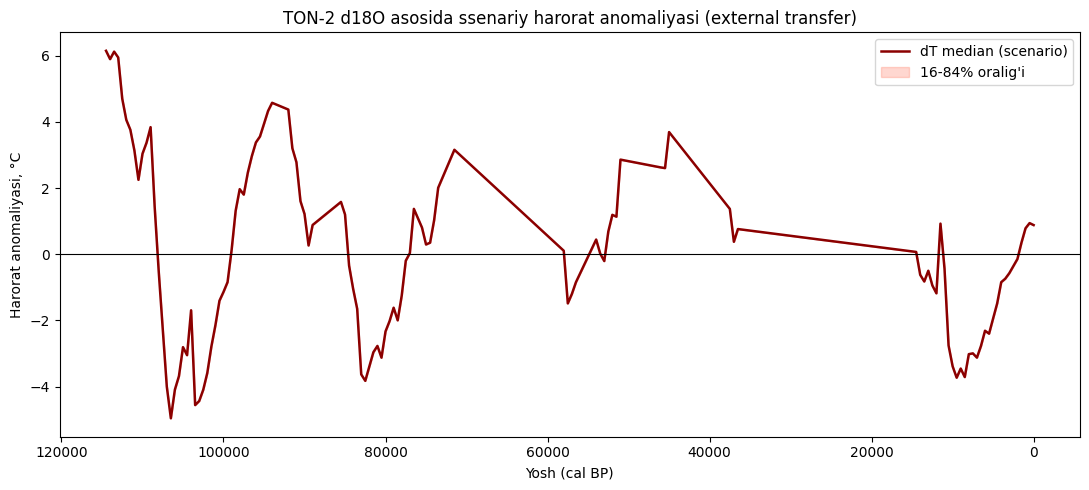

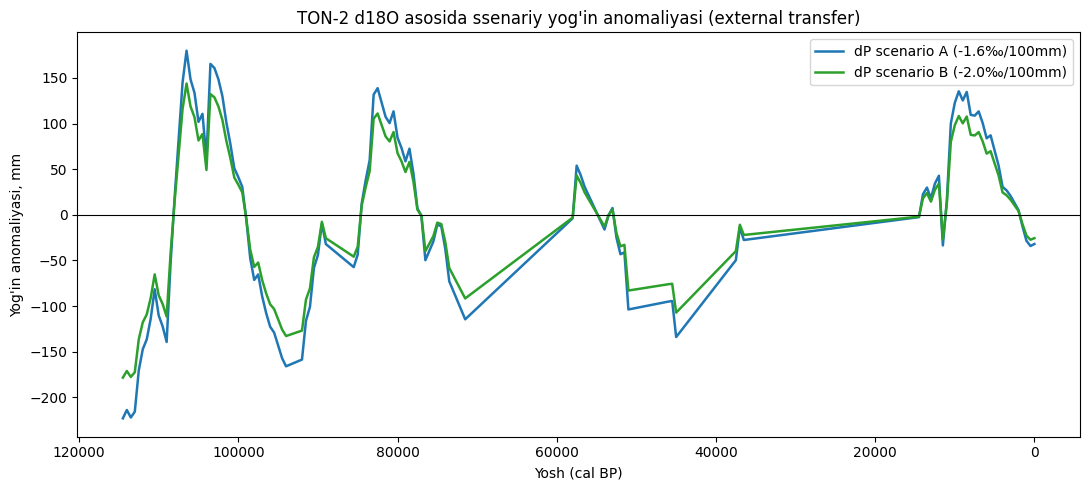

Saved:
 - GMIMOS_Rasm_Scenario_dT.png
 - GMIMOS_Rasm_Scenario_dP.png
 - GMIMOS_Jadval_Scenario_Summary.csv
 - GMIMOS_Jadval_Scenario_Series.csv

Preview:
                  Ko'rsatkich      Qiymat
0      dT median minimum (°C)   -4.959201
1      dT median maximum (°C)    6.152047
2  dP scenario A minimum (mm) -223.011695
3  dP scenario A maximum (mm)  179.771047
4  dP scenario B minimum (mm) -178.409356
5  dP scenario B maximum (mm)  143.816837


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Scenario natijalarni grafik qilish (GMIMOS qo'shimcha)
# ==========================================

s = pd.read_csv("scenario_transfer_ton2_fixed.csv").sort_values("age_bin")

# Agar oldingi kodda dT_med / dP_*_med chiqmagan bo'lsa, shu yerda hisoblaymiz
dt_cols = [c for c in s.columns if c.startswith("dT_") and c.endswith("_anom")]
dpi_cols = [c for c in s.columns if c.startswith("dP_island_") and c.endswith("_anom")]
dpc_cols = [c for c in s.columns if c.startswith("dP_continent_") and c.endswith("_anom")]

if "dT_med" not in s.columns:
    s["dT_med"] = s[dt_cols].median(axis=1)
    s["dT_q16"] = s[dt_cols].quantile(0.16, axis=1)
    s["dT_q84"] = s[dt_cols].quantile(0.84, axis=1)

if "dP_island_med" not in s.columns:
    s["dP_island_med"] = s[dpi_cols].median(axis=1)
if "dP_cont_med" not in s.columns:
    s["dP_cont_med"] = s[dpc_cols].median(axis=1)

# --- 1) dT scenario ---
plt.figure(figsize=(11,5))
plt.plot(s["age_bin"], s["dT_med"], color="darkred", lw=1.8, label="dT median (scenario)")
if "dT_q16" in s.columns and "dT_q84" in s.columns:
    plt.fill_between(s["age_bin"], s["dT_q16"], s["dT_q84"], alpha=0.25, color="tomato", label="16-84% oralig'i")
plt.axhline(0, color="black", lw=0.8)
plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("Harorat anomaliyasi, °C")
plt.title("TON-2 d18O asosida ssenariy harorat anomaliyasi (external transfer)")
plt.legend()
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Scenario_dT.png", dpi=300)
plt.show()

# --- 2) dP scenario (2 variant) ---
plt.figure(figsize=(11,5))
plt.plot(s["age_bin"], s["dP_island_med"], color="tab:blue", lw=1.8, label="dP scenario A (-1.6‰/100mm)")
plt.plot(s["age_bin"], s["dP_cont_med"], color="tab:green", lw=1.8, label="dP scenario B (-2.0‰/100mm)")
plt.axhline(0, color="black", lw=0.8)
plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("Yog'in anomaliyasi, mm")
plt.title("TON-2 d18O asosida ssenariy yog'in anomaliyasi (external transfer)")
plt.legend()
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Scenario_dP.png", dpi=300)
plt.show()

# --- 3) Jadval: asosiy statistikalar ---
summary = pd.DataFrame({
    "Ko'rsatkich": [
        "dT median minimum (°C)",
        "dT median maximum (°C)",
        "dP scenario A minimum (mm)",
        "dP scenario A maximum (mm)",
        "dP scenario B minimum (mm)",
        "dP scenario B maximum (mm)"
    ],
    "Qiymat": [
        s["dT_med"].min(),
        s["dT_med"].max(),
        s["dP_island_med"].min(),
        s["dP_island_med"].max(),
        s["dP_cont_med"].min(),
        s["dP_cont_med"].max()
    ]
})
summary.to_csv("GMIMOS_Jadval_Scenario_Summary.csv", index=False)

# To'liq scenario series saqlash
s.to_csv("GMIMOS_Jadval_Scenario_Series.csv", index=False)

print("Saved:")
print(" - GMIMOS_Rasm_Scenario_dT.png")
print(" - GMIMOS_Rasm_Scenario_dP.png")
print(" - GMIMOS_Jadval_Scenario_Summary.csv")
print(" - GMIMOS_Jadval_Scenario_Series.csv")
print("\nPreview:")
print(summary)

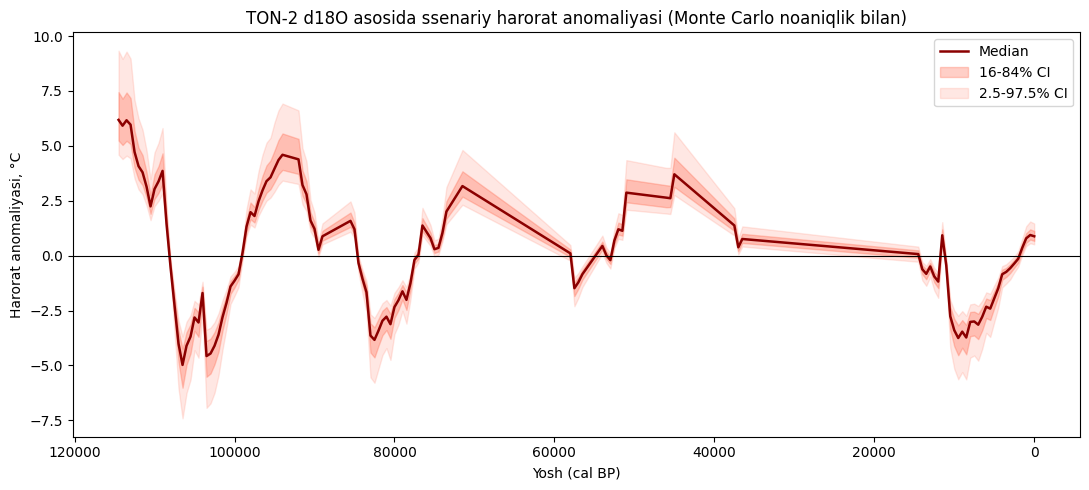

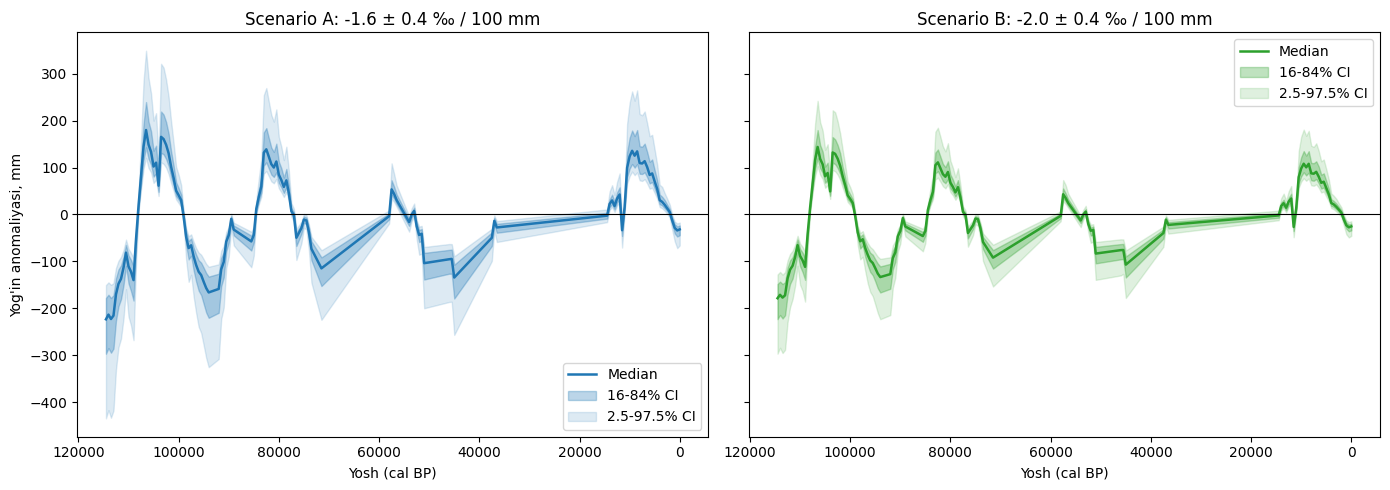

Saved:
 - scenario_transfer_uncertainty_mc.csv
 - GMIMOS_Rasm_Scenario_dT_with_uncertainty.png
 - GMIMOS_Rasm_Scenario_dP_with_uncertainty.png
 - GMIMOS_Jadval_Scenario_Uncertainty_Summary.csv

Preview:
            Ko'rsatkich      Qiymat
0    dT median min (°C)   -4.975625
1    dT median max (°C)    6.181504
2  dT 95% CI global min   -7.408773
3  dT 95% CI global max    9.332482
4  dP_A median min (mm) -223.309776
5  dP_A median max (mm)  179.882406
6  dP_B median min (mm) -178.363940
7  dP_B median max (mm)  143.806919


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Monte Carlo uncertainty propagation for TON2 scenario
# Output: dT and dP with 95% CI
# =========================================================

np.random.seed(42)

# -----------------------------
# 1) Load TON2 binned d18O
# -----------------------------
df = pd.read_csv("TON2_iso_original.csv")
df = df[df["age_calBP"] >= 0].dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
df = df.sort_values("age_calBP")

BIN_W = 500
df["age_bin"] = (df["age_calBP"] // BIN_W) * BIN_W
b = df.groupby("age_bin", as_index=False)["d18OcarbVPDB"].mean().rename(columns={"d18OcarbVPDB":"d18O_c_vpdb"})

# VPDB -> SMOW
b["d18O_c_smow"] = 1.03091 * b["d18O_c_vpdb"] + 30.91

# -----------------------------
# 2) Assumptions (editable)
# -----------------------------
N_MC = 3000

# Cave temperature uncertainty (Boysun mean around 13.5C)
T_mean = 13.5
T_sd   = 1.0

# Measurement noise (d18O, per mil)
d18_meas_sd = 0.10

# Fractionation model switch probability
# 0: Kim&O'Neil, 1: Tremaine
p_tremaine = 0.5

# Temperature effect slope: d18O per 1°C  (classic approx 0.58 ± 0.10)
slope_temp_mean = 0.58
slope_temp_sd   = 0.10

# Amount effect slope in per mil per 100 mm (negative)
# Scenario A: -1.6 ± 0.4
# Scenario B: -2.0 ± 0.4
amountA_mean = -1.6
amountA_sd   = 0.4

amountB_mean = -2.0
amountB_sd   = 0.4

# -----------------------------
# 3) Fractionation functions
# -----------------------------
def alpha_kim_oneil(TK):
    # 1000 ln(alpha) = 18.03*(1000/T) - 32.42
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)

def alpha_tremaine(TK):
    # 1000 ln(alpha) = 16.1*(1000/T) - 24.6
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)

def water_from_calcite(d18O_calcite_smow, alpha):
    # alpha = (1000+d18Oc)/(1000+d18Ow)
    return ((1000.0 + d18O_calcite_smow)/alpha) - 1000.0

# -----------------------------
# 4) Monte Carlo core
# -----------------------------
ages = b["age_bin"].values
d18c = b["d18O_c_smow"].values
n_age = len(ages)

# store MC realizations
dT_mc = np.zeros((N_MC, n_age))
dP_A_mc = np.zeros((N_MC, n_age))
dP_B_mc = np.zeros((N_MC, n_age))

for i in range(N_MC):
    # sample cave T
    T_c = np.random.normal(T_mean, T_sd)
    T_K = T_c + 273.15

    # sample fractionation formula
    use_tr = np.random.rand() < p_tremaine
    alpha = alpha_tremaine(T_K) if use_tr else alpha_kim_oneil(T_K)

    # sample d18O measurement perturbation
    d18c_noisy = d18c + np.random.normal(0, d18_meas_sd, size=n_age)

    # calc water d18O and anomaly
    d18w = water_from_calcite(d18c_noisy, alpha)
    d18w_anom = d18w - np.mean(d18w)

    # sample temp effect slope (avoid near-zero)
    slope_t = np.random.normal(slope_temp_mean, slope_temp_sd)
    slope_t = np.clip(slope_t, 0.2, 1.2)

    # dT (°C): d18O / slope
    dT = d18w_anom / slope_t

    # sample amount effect slopes (per mil per 100 mm, negative)
    mA = np.random.normal(amountA_mean, amountA_sd)
    mB = np.random.normal(amountB_mean, amountB_sd)
    mA = -abs(mA)  # ensure negative
    mB = -abs(mB)

    # dP (mm): d18O = m*(dP/100) => dP = 100*d18O/m
    dP_A = 100.0 * d18w_anom / mA
    dP_B = 100.0 * d18w_anom / mB

    dT_mc[i, :] = dT
    dP_A_mc[i, :] = dP_A
    dP_B_mc[i, :] = dP_B

# -----------------------------
# 5) Summaries
# -----------------------------
def qstats(arr):
    return (
        np.nanmedian(arr, axis=0),
        np.nanpercentile(arr, 2.5, axis=0),
        np.nanpercentile(arr, 16, axis=0),
        np.nanpercentile(arr, 84, axis=0),
        np.nanpercentile(arr, 97.5, axis=0),
    )

dT_med, dT_q025, dT_q16, dT_q84, dT_q975 = qstats(dT_mc)
dPA_med, dPA_q025, dPA_q16, dPA_q84, dPA_q975 = qstats(dP_A_mc)
dPB_med, dPB_q025, dPB_q16, dPB_q84, dPB_q975 = qstats(dP_B_mc)

out = pd.DataFrame({
    "age_bin": ages,
    "dT_med": dT_med, "dT_q025": dT_q025, "dT_q16": dT_q16, "dT_q84": dT_q84, "dT_q975": dT_q975,
    "dP_A_med": dPA_med, "dP_A_q025": dPA_q025, "dP_A_q16": dPA_q16, "dP_A_q84": dPA_q84, "dP_A_q975": dPA_q975,
    "dP_B_med": dPB_med, "dP_B_q025": dPB_q025, "dP_B_q16": dPB_q16, "dP_B_q84": dPB_q84, "dP_B_q975": dPB_q975
})

out.to_csv("scenario_transfer_uncertainty_mc.csv", index=False)

# -----------------------------
# 6) Plots
# -----------------------------
# dT plot
plt.figure(figsize=(11,5))
plt.plot(out["age_bin"], out["dT_med"], color="darkred", lw=1.8, label="Median")
plt.fill_between(out["age_bin"], out["dT_q16"], out["dT_q84"], color="tomato", alpha=0.30, label="16-84% CI")
plt.fill_between(out["age_bin"], out["dT_q025"], out["dT_q975"], color="tomato", alpha=0.15, label="2.5-97.5% CI")
plt.axhline(0, color="black", lw=0.8)
plt.gca().invert_xaxis()
plt.xlabel("Yosh (cal BP)")
plt.ylabel("Harorat anomaliyasi, °C")
plt.title("TON-2 d18O asosida ssenariy harorat anomaliyasi (Monte Carlo noaniqlik bilan)")
plt.legend()
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Scenario_dT_with_uncertainty.png", dpi=300)
plt.show()

# dP plot (A & B)
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].plot(out["age_bin"], out["dP_A_med"], color="tab:blue", lw=1.8, label="Median")
axes[0].fill_between(out["age_bin"], out["dP_A_q16"], out["dP_A_q84"], color="tab:blue", alpha=0.30, label="16-84% CI")
axes[0].fill_between(out["age_bin"], out["dP_A_q025"], out["dP_A_q975"], color="tab:blue", alpha=0.15, label="2.5-97.5% CI")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].invert_xaxis()
axes[0].set_title("Scenario A: -1.6 ± 0.4 ‰ / 100 mm")
axes[0].set_xlabel("Yosh (cal BP)")
axes[0].set_ylabel("Yog'in anomaliyasi, mm")
axes[0].legend()

axes[1].plot(out["age_bin"], out["dP_B_med"], color="tab:green", lw=1.8, label="Median")
axes[1].fill_between(out["age_bin"], out["dP_B_q16"], out["dP_B_q84"], color="tab:green", alpha=0.30, label="16-84% CI")
axes[1].fill_between(out["age_bin"], out["dP_B_q025"], out["dP_B_q975"], color="tab:green", alpha=0.15, label="2.5-97.5% CI")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].invert_xaxis()
axes[1].set_title("Scenario B: -2.0 ± 0.4 ‰ / 100 mm")
axes[1].set_xlabel("Yosh (cal BP)")
axes[1].legend()

plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Scenario_dP_with_uncertainty.png", dpi=300)
plt.show()

# -----------------------------
# 7) Short summary table
# -----------------------------
summary = pd.DataFrame({
    "Ko'rsatkich": [
        "dT median min (°C)", "dT median max (°C)",
        "dT 95% CI global min", "dT 95% CI global max",
        "dP_A median min (mm)", "dP_A median max (mm)",
        "dP_B median min (mm)", "dP_B median max (mm)"
    ],
    "Qiymat": [
        out["dT_med"].min(), out["dT_med"].max(),
        out["dT_q025"].min(), out["dT_q975"].max(),
        out["dP_A_med"].min(), out["dP_A_med"].max(),
        out["dP_B_med"].min(), out["dP_B_med"].max()
    ]
})
summary.to_csv("GMIMOS_Jadval_Scenario_Uncertainty_Summary.csv", index=False)

print("Saved:")
print(" - scenario_transfer_uncertainty_mc.csv")
print(" - GMIMOS_Rasm_Scenario_dT_with_uncertainty.png")
print(" - GMIMOS_Rasm_Scenario_dP_with_uncertainty.png")
print(" - GMIMOS_Jadval_Scenario_Uncertainty_Summary.csv")
print("\nPreview:")
print(summary)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) TON2 scenario (Monte Carlo natija)
sc = pd.read_csv("scenario_transfer_uncertainty_mc.csv").sort_values("age_bin")
sc["year_ce"] = 1950 - sc["age_bin"]

# 2) Boysun
# Sizdagi tozalangan jadvalni o'qing:
# boy = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
# Agar df hozir xotirada bo'lsa:
boy = df.copy()

# annual ustunini topish
annual_col = None
for c in ["annual", "yil", "йил"]:
    if c in boy.columns:
        annual_col = c
        break
if annual_col is None:
    raise ValueError("Boysun jadvalida annual/yil ustuni topilmadi.")

boy["year"] = pd.to_numeric(boy["year"], errors="coerce")
boy[annual_col] = pd.to_numeric(
    boy[annual_col].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
boy = boy.dropna(subset=["year", annual_col]).sort_values("year")

# Boysun anomaliya (1961-1990 bazaga nisbatan)
base = boy[(boy["year"] >= 1961) & (boy["year"] <= 1990)]
if len(base) < 10:
    base = boy.iloc[:min(30, len(boy))]
boy["T_anom"] = boy[annual_col] - base[annual_col].mean()

# 3) Plot (2 panel)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Panel A: TON2 scenario dT
axes[0].plot(sc["year_ce"], sc["dT_med"], color="darkred", lw=1.8, label="TON2 dT median (scenario)")
axes[0].fill_between(sc["year_ce"], sc["dT_q16"], sc["dT_q84"], color="tomato", alpha=0.30, label="16-84% CI")
axes[0].fill_between(sc["year_ce"], sc["dT_q025"], sc["dT_q975"], color="tomato", alpha=0.15, label="2.5-97.5% CI")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("TON-2 asosidagi ssenariy harorat anomaliyasi (paleovaqt)")
axes[0].set_xlabel("Yil (CE)")
axes[0].set_ylabel("Harorat anomaliyasi, °C")
axes[0].legend()

# Panel B: Boysun instrumental
axes[1].plot(boy["year"], boy[annual_col], color="steelblue", alpha=0.6, label="Boysun yillik T")
axes[1].plot(boy["year"], boy[annual_col].rolling(11, center=True, min_periods=6).mean(),
             color="navy", lw=2, label="11-yillik MA")
axes[1].axhline(base[annual_col].mean(), color="black", ls="--", lw=1, label="Bazaviy o'rtacha")
axes[1].set_title("Boysun meteostansiyasi: yillik havo harorati (instrumental)")
axes[1].set_xlabel("Yil")
axes[1].set_ylabel("Harorat, °C")
axes[1].legend()

plt.tight_layout()
plt.savefig("GMIMOS_Rasm_TON2_scenario_va_Boysun_birgalikda.png", dpi=300)
plt.show()

ValueError: Boysun jadvalida annual/yil ustuni topilmadi.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Overlay variant: TON2 scenario dT + Boysun anomaliya
# (bitta o'q, CE vaqtida)
# ==========================================

# 1) TON2 scenario
sc = pd.read_csv("scenario_transfer_uncertainty_mc.csv").sort_values("age_bin")
sc["year_ce"] = 1950 - sc["age_bin"]

# Faqat instrumental davrga yaqin ko'rinish uchun (masalan oxirgi 12 ming yil)
sc_view = sc[(sc["year_ce"] >= -10000) & (sc["year_ce"] <= 2025)].copy()

# 2) Boysun
# boysun tozalangan jadval
# boy = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
# yoki xotiradagi df:
boy = df.copy()

# annual ustunini topish
annual_col = None
for c in ["annual", "yil", "йил"]:
    if c in boy.columns:
        annual_col = c
        break
if annual_col is None:
    raise ValueError("Boysun jadvalida annual/yil ustuni topilmadi.")

boy["year"] = pd.to_numeric(boy["year"], errors="coerce")
boy[annual_col] = pd.to_numeric(
    boy[annual_col].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
boy = boy.dropna(subset=["year", annual_col]).sort_values("year")

# Boysun anomaliya (1961-1990 bazasi)
base = boy[(boy["year"] >= 1961) & (boy["year"] <= 1990)]
if len(base) < 10:
    base = boy.iloc[:min(30, len(boy))]
base_mean = base[annual_col].mean()

boy["anom"] = boy[annual_col] - base_mean
boy["anom_ma11"] = boy["anom"].rolling(11, center=True, min_periods=6).mean()

# 3) Plot overlay
plt.figure(figsize=(12,6))

# TON2 scenario median + CI
plt.plot(sc_view["year_ce"], sc_view["dT_med"], color="darkred", lw=1.8, label="TON2 ssenariy dT (median)")
plt.fill_between(sc_view["year_ce"], sc_view["dT_q16"], sc_view["dT_q84"],
                 color="tomato", alpha=0.28, label="TON2 16-84% CI")
plt.fill_between(sc_view["year_ce"], sc_view["dT_q025"], sc_view["dT_q975"],
                 color="tomato", alpha=0.14, label="TON2 2.5-97.5% CI")

# Boysun anomaliya
plt.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.45, lw=1.2, label="Boysun T anomaliya (yillik)")
plt.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.0, label="Boysun T anomaliya (11-y MA)")

plt.axhline(0, color="black", lw=0.8)
plt.xlim(-10000, 2025)
plt.xlabel("Yil (CE)")
plt.ylabel("Harorat anomaliyasi, °C")
plt.title("TON-2 ssenariy harorat anomaliyasi va Boysun instrumental anomaliyasi (taqqoslama overlay)")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Overlay_TON2_Boysun_anomaliya.png", dpi=300)
plt.show()

print("Saved: GMIMOS_Rasm_Overlay_TON2_Boysun_anomaliya.png")

ValueError: Boysun jadvalida annual/yil ustuni topilmadi.

Boysun columns: ['year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'annual', 'Qish_DJF', 'Bahor_MAM', 'Yoz_JJA', 'Kuz_SON', 'annual_anom', 'Qish_DJF_anom', 'Bahor_MAM_anom', 'Yoz_JJA_anom', 'Kuz_SON_anom', 'annual_ma11', 'annual_ma21']
Used year col: year | annual col: annual
Boysun rows: 93


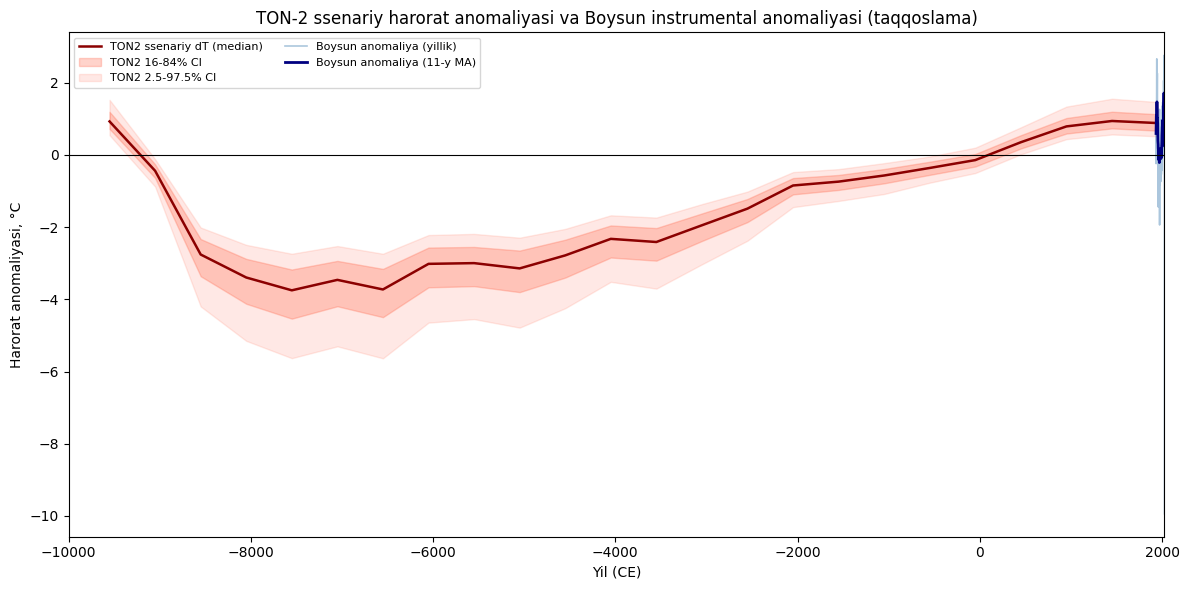

Saved: GMIMOS_Rasm_Overlay_TON2_Boysun_anomaliya.png


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) TON2 scenario
# =========================
sc = pd.read_csv("scenario_transfer_uncertainty_mc.csv").sort_values("age_bin")
sc["year_ce"] = 1950 - sc["age_bin"]
sc_view = sc[(sc["year_ce"] >= -10000) & (sc["year_ce"] <= 2025)].copy()

# =========================
# 2) Boysunni qayta o'qish
# =========================
boy_raw = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")  # fayl nomini moslang
print("Boysun columns:", list(boy_raw.columns))

# nomlarni pastga tushirib stringga o'tkazamiz
tmp = boy_raw.copy()
tmp.columns = [str(c).strip().lower() for c in tmp.columns]

# year ustuni topish
year_col = None
for c in tmp.columns:
    if "year" in c or "yil" in c or "йил" == c or c == "год":
        year_col = c
        break
if year_col is None:
    # fallback: birinchi ustunni year deb olamiz
    year_col = tmp.columns[0]

# annual ustuni topish
annual_col = None
for c in tmp.columns:
    if c in ["annual", "yil", "йил"] or ("annual" in c) or ("yil" in c):
        annual_col = c
        break
if annual_col is None:
    # agar yearly ustun topilmasa, oyliklardan hisoblaymiz
    # ruscha/lotincha oy nomlari
    month_candidates = {
        "jan":["jan","янв"], "feb":["feb","фев"], "mar":["mar","мар"], "apr":["apr","апр"],
        "may":["may","май"], "jun":["jun","июн"], "jul":["jul","июл"], "aug":["aug","авг"],
        "sep":["sep","сен"], "oct":["oct","окт"], "nov":["nov","ноя"], "dec":["dec","дек"]
    }
    month_cols = []
    for k, vals in month_candidates.items():
        found = None
        for v in vals:
            if v in tmp.columns:
                found = v
                break
        if found is not None:
            month_cols.append(found)

    if len(month_cols) < 10:
        raise ValueError("Annual ustun ham, yetarli oylik ustunlar ham topilmadi.")
    for c in month_cols:
        tmp[c] = pd.to_numeric(tmp[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    tmp["annual_calc"] = tmp[month_cols].mean(axis=1)
    annual_col = "annual_calc"

# sonlash
tmp[year_col] = pd.to_numeric(tmp[year_col], errors="coerce")
tmp[annual_col] = pd.to_numeric(tmp[annual_col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

boy = tmp[[year_col, annual_col]].rename(columns={year_col:"year", annual_col:"annual"})
boy = boy.dropna(subset=["year","annual"]).sort_values("year")
boy["year"] = boy["year"].astype(int)

# anomaliya
base = boy[(boy["year"] >= 1961) & (boy["year"] <= 1990)]
if len(base) < 10:
    base = boy.iloc[:min(30, len(boy))]
boy["anom"] = boy["annual"] - base["annual"].mean()
boy["anom_ma11"] = boy["anom"].rolling(11, center=True, min_periods=6).mean()

print("Used year col:", year_col, "| annual col:", annual_col)
print("Boysun rows:", len(boy))

# =========================
# 3) Overlay plot
# =========================
plt.figure(figsize=(12,6))
plt.plot(sc_view["year_ce"], sc_view["dT_med"], color="darkred", lw=1.8, label="TON2 ssenariy dT (median)")
plt.fill_between(sc_view["year_ce"], sc_view["dT_q16"], sc_view["dT_q84"], color="tomato", alpha=0.28, label="TON2 16-84% CI")
plt.fill_between(sc_view["year_ce"], sc_view["dT_q025"], sc_view["dT_q975"], color="tomato", alpha=0.14, label="TON2 2.5-97.5% CI")

plt.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.45, lw=1.2, label="Boysun anomaliya (yillik)")
plt.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.0, label="Boysun anomaliya (11-y MA)")

plt.axhline(0, color="black", lw=0.8)
plt.xlim(-10000, 2025)
plt.xlabel("Yil (CE)")
plt.ylabel("Harorat anomaliyasi, °C")
plt.title("TON-2 ssenariy harorat anomaliyasi va Boysun instrumental anomaliyasi (taqqoslama)")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_Overlay_TON2_Boysun_anomaliya.png", dpi=300)
plt.show()

print("Saved: GMIMOS_Rasm_Overlay_TON2_Boysun_anomaliya.png")

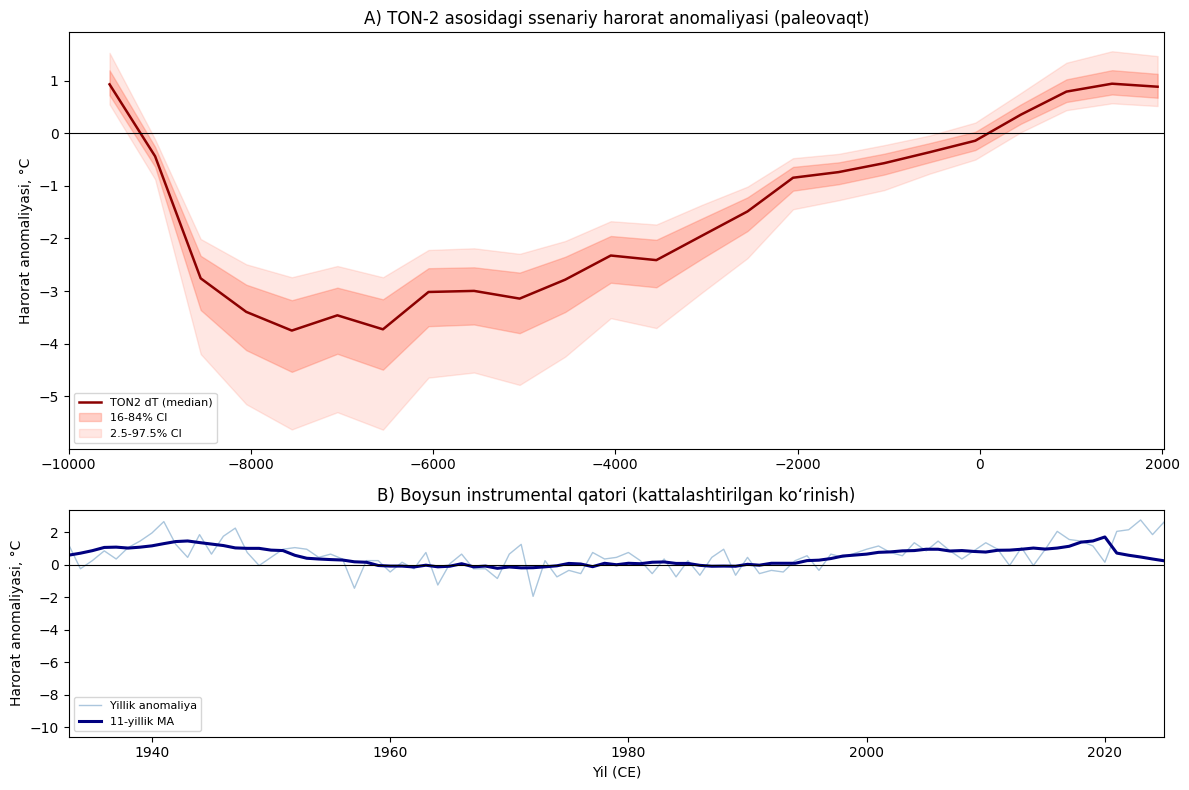

In [33]:
import matplotlib.pyplot as plt

# sc_view: TON2 scenario dataframe (year_ce, dT_med, dT_q16, dT_q84, dT_q025, dT_q975)
# boy: Boysun dataframe (year, anom, anom_ma11)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8),
    gridspec_kw={"height_ratios":[2.2, 1.2]},
    sharex=False
)

# Panel A: paleo (TON2)
ax = axes[0]
ax.plot(sc_view["year_ce"], sc_view["dT_med"], color="darkred", lw=1.8, label="TON2 dT (median)")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q16"], sc_view["dT_q84"], color="tomato", alpha=0.30, label="16-84% CI")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q025"], sc_view["dT_q975"], color="tomato", alpha=0.15, label="2.5-97.5% CI")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlim(-10000, 2025)
ax.set_ylabel("Harorat anomaliyasi, °C")
ax.set_title("A) TON-2 asosidagi ssenariy harorat anomaliyasi (paleovaqt)")
ax.legend(loc="best", fontsize=8)

# Panel B: Boysun zoom
ax2 = axes[1]
ax2.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.45, lw=1.0, label="Yillik anomaliya")
ax2.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.2, label="11-yillik MA")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlim(1933, 2025)
ax2.set_xlabel("Yil (CE)")
ax2.set_ylabel("Harorat anomaliyasi, °C")
ax2.set_title("B) Boysun instrumental qatori (kattalashtirilgan ko‘rinish)")
ax2.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig("GMIMOS_Rasm_TON2_Boysun_2panel_zoom.png", dpi=300)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10988\1351026109.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


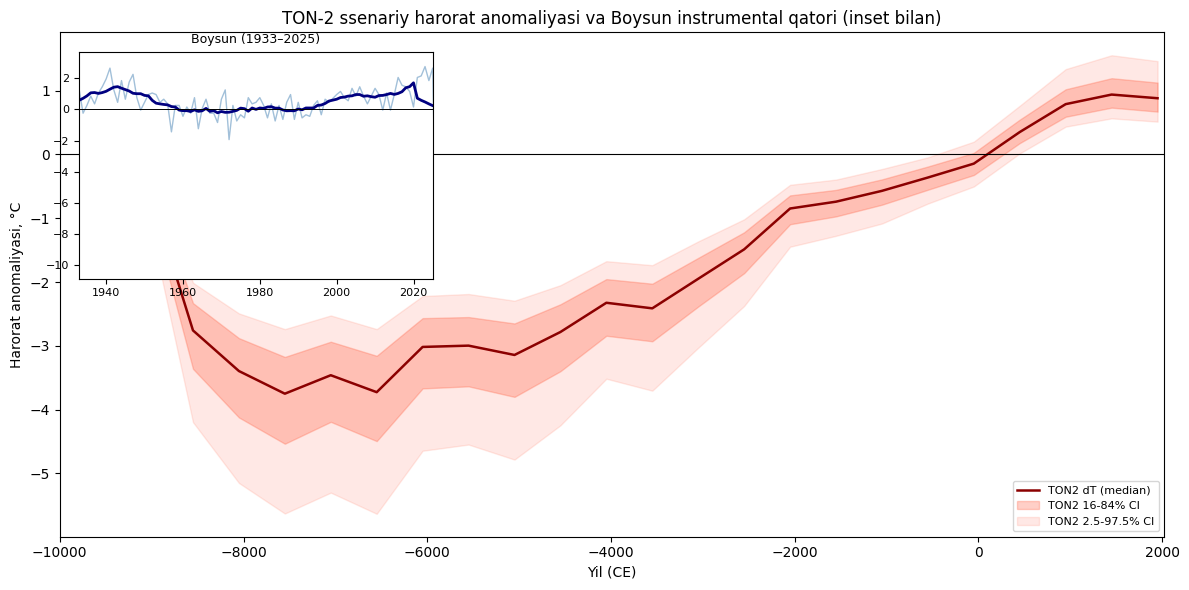

Saved: GMIMOS_Rasm_TON2_Boysun_inset_zoom.png


In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# sc_view: TON2 scenario dataframe
# boy: Boysun dataframe

fig, ax = plt.subplots(figsize=(12,6))

# Main: TON2 scenario
ax.plot(sc_view["year_ce"], sc_view["dT_med"], color="darkred", lw=1.8, label="TON2 dT (median)")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q16"], sc_view["dT_q84"], color="tomato", alpha=0.30, label="TON2 16-84% CI")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q025"], sc_view["dT_q975"], color="tomato", alpha=0.14, label="TON2 2.5-97.5% CI")
ax.axhline(0, color="black", lw=0.8)

ax.set_xlim(-10000, 2025)
ax.set_xlabel("Yil (CE)")
ax.set_ylabel("Harorat anomaliyasi, °C")
ax.set_title("TON-2 ssenariy harorat anomaliyasi va Boysun instrumental qatori (inset bilan)")

# Inset: Boysun zoom
axins = inset_axes(ax, width="32%", height="45%", loc="upper left", borderpad=1.4)
axins.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.5, lw=1.0, label="Yillik")
axins.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.0, label="11-y MA")
axins.axhline(0, color="black", lw=0.7)

axins.set_xlim(1933, 2025)
# inset y-lim avtomatikdan sal kengroq
ymin = min(boy["anom"].min(), boy["anom_ma11"].min())
ymax = max(boy["anom"].max(), boy["anom_ma11"].max())
pad = 0.25 * (ymax - ymin if ymax > ymin else 1.0)
axins.set_ylim(ymin - pad*0.3, ymax + pad*0.3)

axins.set_title("Boysun (1933–2025)", fontsize=9)
axins.tick_params(axis='both', labelsize=8)

# legend
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("GMIMOS_Rasm_TON2_Boysun_inset_zoom.png", dpi=300)
plt.show()

print("Saved: GMIMOS_Rasm_TON2_Boysun_inset_zoom.png")

C:\Users\user\AppData\Local\Temp\ipykernel_10988\2570247333.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


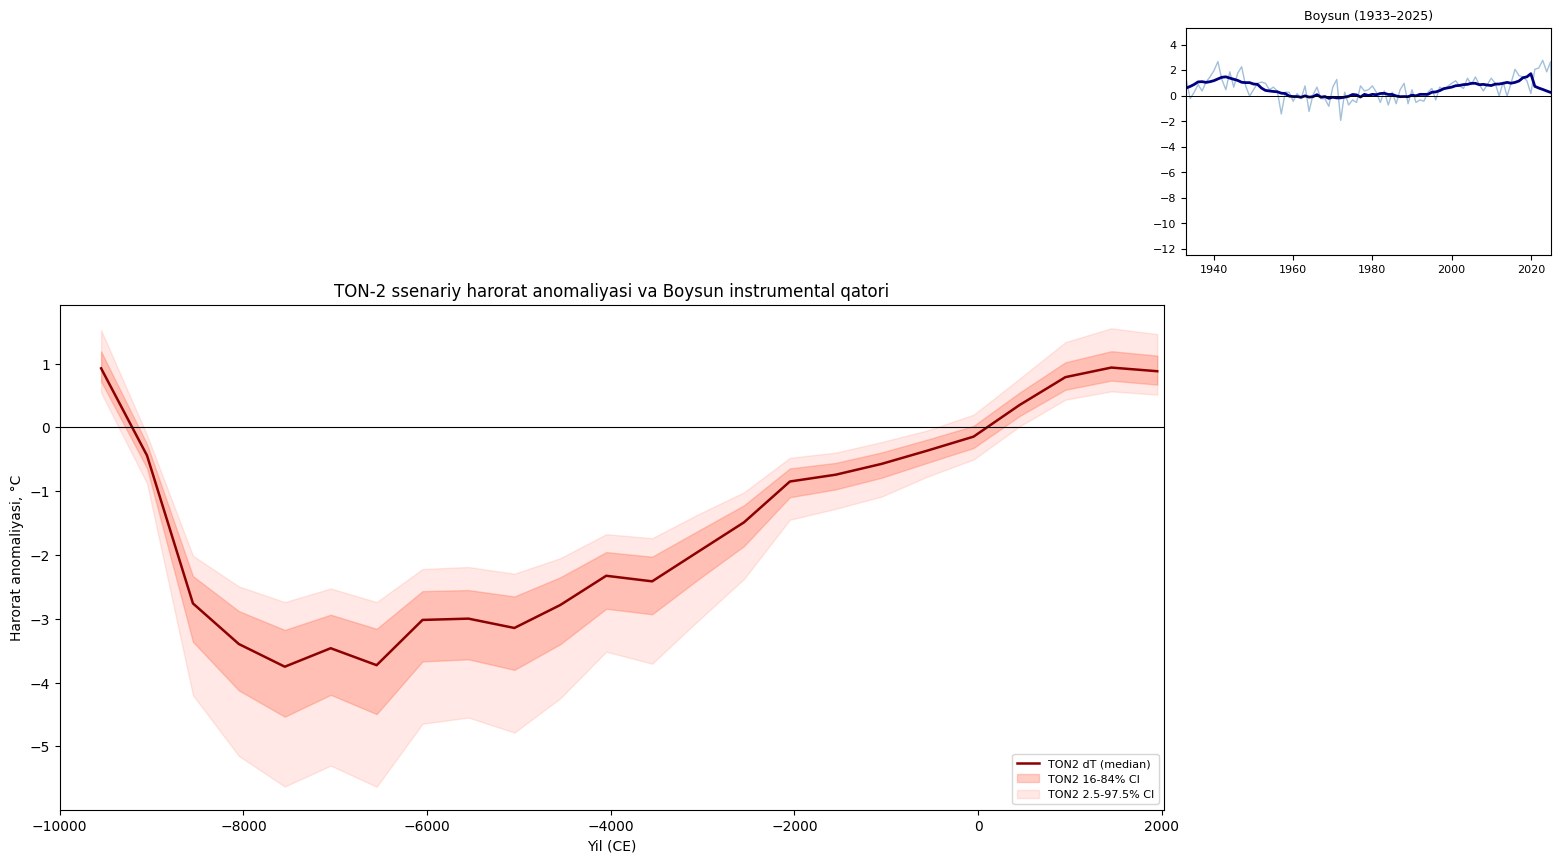

Saved: GMIMOS_Rasm_TON2_Boysun_inset_outside.png


In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(12,6))

# Main plot
ax.plot(sc_view["year_ce"], sc_view["dT_med"], color="darkred", lw=1.8, label="TON2 dT (median)")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q16"], sc_view["dT_q84"], color="tomato", alpha=0.30, label="TON2 16-84% CI")
ax.fill_between(sc_view["year_ce"], sc_view["dT_q025"], sc_view["dT_q975"], color="tomato", alpha=0.14, label="TON2 2.5-97.5% CI")
ax.axhline(0, color="black", lw=0.8)

ax.set_xlim(-10000, 2025)
ax.set_xlabel("Yil (CE)")
ax.set_ylabel("Harorat anomaliyasi, °C")
ax.set_title("TON-2 ssenariy harorat anomaliyasi va Boysun instrumental qatori")

# Inset outside main axes (o'ng yuqori tashqarida)
axins = inset_axes(
    ax,
    width="33%", height="45%",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55, 1, 1),  # tashqariga siljitish
    bbox_transform=ax.transAxes,
    borderpad=0.0
)

axins.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.5, lw=1.0)
axins.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.0)
axins.axhline(0, color="black", lw=0.7)
axins.set_xlim(1933, 2025)

ymin = min(boy["anom"].min(), boy["anom_ma11"].min())
ymax = max(boy["anom"].max(), boy["anom_ma11"].max())
pad = 0.2 * (ymax - ymin if ymax > ymin else 1.0)
axins.set_ylim(ymin - pad, ymax + pad)

axins.set_title("Boysun (1933–2025)", fontsize=9)
axins.tick_params(axis='both', labelsize=8)

ax.legend(loc="lower right", fontsize=8)

# O'ng tarafda inset uchun joy qoldirish
plt.subplots_adjust(right=0.78)
plt.tight_layout()
plt.savefig("GMIMOS_Rasm_TON2_Boysun_inset_outside.png", dpi=300)
plt.show()

print("Saved: GMIMOS_Rasm_TON2_Boysun_inset_outside.png")

C:\Users\user\AppData\Local\Temp\ipykernel_10988\3843158936.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


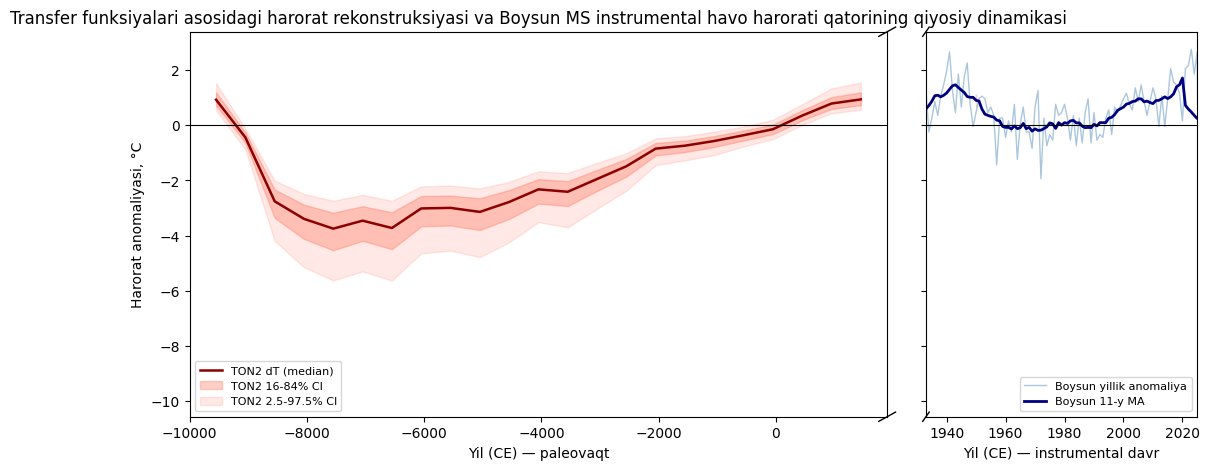

Saved:Boysun_broken_axis_final.png


In [41]:
import matplotlib.pyplot as plt

# =========================================================
# Journal-friendly final: broken x-axis style (2 synced panels)
# Left: Paleo (TON2 scenario), Right: Boysun instrumental zoom
# =========================================================

# sc_view: TON2 scenario dataframe
# boy: Boysun dataframe

fig = plt.figure(figsize=(13,5))
gs = fig.add_gridspec(1, 2, width_ratios=[3.6, 1.4], wspace=0.08)

axL = fig.add_subplot(gs[0,0])   # paleo panel
axR = fig.add_subplot(gs[0,1], sharey=axL)  # modern zoom panel

# ---------- Left panel (paleo) ----------
mL = (sc_view["year_ce"] >= -10000) & (sc_view["year_ce"] <= 1900)

axL.plot(sc_view.loc[mL, "year_ce"], sc_view.loc[mL, "dT_med"],
         color="darkred", lw=1.8, label="TON2 dT (median)")
axL.fill_between(sc_view.loc[mL, "year_ce"],
                 sc_view.loc[mL, "dT_q16"], sc_view.loc[mL, "dT_q84"],
                 color="tomato", alpha=0.30, label="TON2 16-84% CI")
axL.fill_between(sc_view.loc[mL, "year_ce"],
                 sc_view.loc[mL, "dT_q025"], sc_view.loc[mL, "dT_q975"],
                 color="tomato", alpha=0.14, label="TON2 2.5-97.5% CI")
axL.axhline(0, color="black", lw=0.8)

axL.set_xlim(-10000, 1900)
axL.set_xlabel("Yil (CE) — paleovaqt")
axL.set_ylabel("Harorat anomaliyasi, °C")
axL.set_title("Transfer funksiyalari asosidagi harorat rekonstruksiyasi va Boysun MS instrumental havo harorati qatorining qiyosiy dinamikasi")

# ---------- Right panel (Boysun zoom) ----------
mR = (sc_view["year_ce"] >= 1933) & (sc_view["year_ce"] <= 2025)

# TON2 modern segment (agar bo'lsa)
axR.plot(sc_view.loc[mR, "year_ce"], sc_view.loc[mR, "dT_med"],
         color="darkred", lw=1.5, alpha=0.9)
axR.fill_between(sc_view.loc[mR, "year_ce"],
                 sc_view.loc[mR, "dT_q16"], sc_view.loc[mR, "dT_q84"],
                 color="tomato", alpha=0.30)

# Boysun
axR.plot(boy["year"], boy["anom"], color="steelblue", alpha=0.45, lw=1.0, label="Boysun yillik anomaliya")
axR.plot(boy["year"], boy["anom_ma11"], color="navy", lw=2.0, label="Boysun 11-y MA")
axR.axhline(0, color="black", lw=0.8)

axR.set_xlim(1933, 2025)
axR.set_xlabel("Yil (CE) — instrumental davr")
axR.tick_params(labelleft=False)

# ---------- Broken-axis marks ----------
d = .012
kwargs = dict(transform=axL.transAxes, color='k', clip_on=False, lw=1.0)
axL.plot((1-d, 1+d), (-d, +d), **kwargs)
axL.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=axR.transAxes)
axR.plot((-d, +d), (-d, +d), **kwargs)
axR.plot((-d, +d), (1-d, 1+d), **kwargs)

# Legends
axL.legend(loc="lower left", fontsize=8)
axR.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("Boysun_broken_axis_final.png", dpi=300)
plt.show()

print("Saved:Boysun_broken_axis_final.png")

✅ TON-2: 2467 rows | age -58 → 114822 BP
✅ Boysun: 94 rows
   Boysun kolonkalar: ['year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'annual', 'Qish_DJF', 'Bahor_MAM', 'Yoz_JJA', 'Kuz_SON', 'annual_anom', 'Qish_DJF_anom', 'Bahor_MAM_anom', 'Yoz_JJA_anom', 'Kuz_SON_anom', 'annual_ma11', 'annual_ma21']

📊 TON-2 binlar: 122
   Holosen o'rtacha d18O: -6.848 ‰
   Anomaliya: -2.05 → 4.40 ‰

   Year column: year
   Temp column: annual_ma21

✅ Boysun tozalandi: 94 yil
   Davr: 1933 → 2026
   Baza T (1961-1990): 13.04°C
   Anomaliya: -0.16 → 1.27 °C


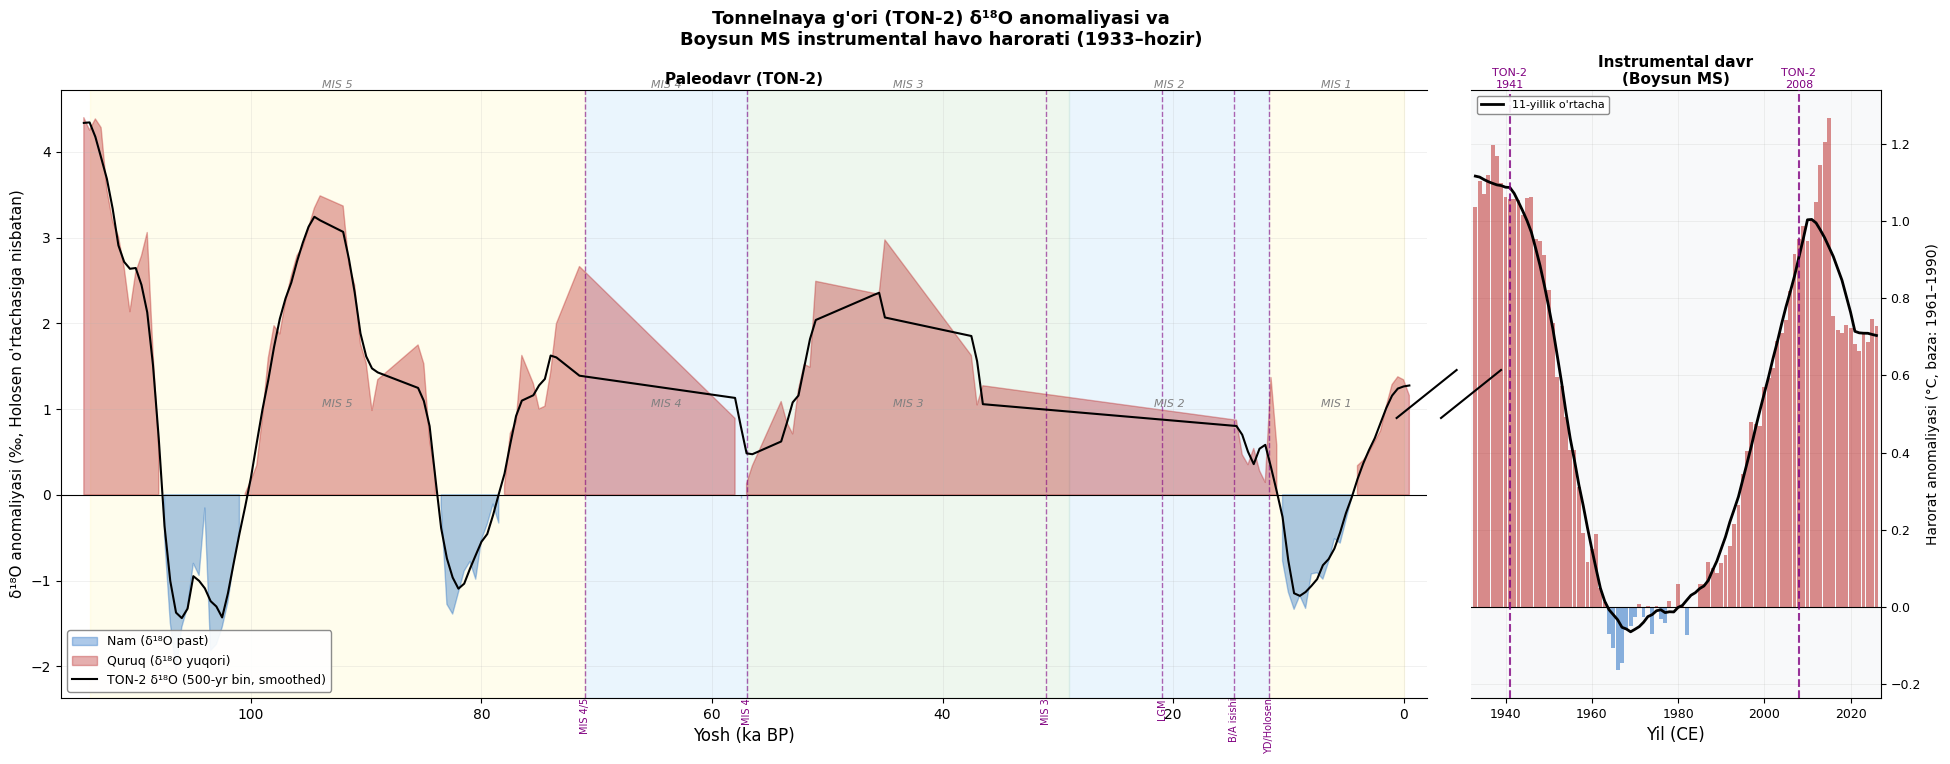


✅ Saqlandi: fig_ton2_boysun_final.png

  STATISTIKA XULOSASI

TON-2 δ¹⁸O anomaliyasi:
  Nam davrlar (< 0‰): 39 / 122 bin (32.0%)
  Quruq davrlar (> 0‰): 83 / 122 bin (68.0%)
  Eng nam davr: 106.5 ka BP (-2.05‰)
  Eng quruq davr: 114.5 ka BP (4.40‰)

Boysun MS harorat:
  Baza (1961-1990): 13.04°C
  Eng issiq yil: 2015 (+1.27°C)
  Eng sovuq yil: 1966 (-0.16°C)
  2000-hozir trendi: +0.82°C

1941 yil Boysun T anomaliyasi: [1.05858605]
2008 yil Boysun T anomaliyasi: [0.95384921]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch
from scipy.ndimage import uniform_filter1d

# ── 1. Ma'lumotlarni yuklash ─────────────────────────────────────
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP", "d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

boysun = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
boysun = boysun.rename(columns={"йил": "annual", "yil": "annual"})
boysun["annual"] = pd.to_numeric(
    boysun["annual"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

print(f"✅ TON-2: {len(ton2)} rows | "
      f"age {ton2['age_calBP'].min()} → {ton2['age_calBP'].max()} BP")
print(f"✅ Boysun: {len(boysun)} rows")
print(f"   Boysun kolonkalar: {list(boysun.columns)}")

# ── 2. TON-2 → 500-yillik bin, anomaliya ────────────────────────
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = (ton2.groupby("age_bin", as_index=False)["d18OcarbVPDB"]
     .mean()
     .rename(columns={"d18OcarbVPDB": "d18O"}))

# Anomaliya (Holosen o'rtachasiga nisbatan: 0–11,700 BP)
holocene_mean = b.loc[b["age_bin"] <= 11700, "d18O"].mean()
b["d18O_anom"] = b["d18O"] - holocene_mean

# Smoothing
b["d18O_smooth"] = uniform_filter1d(b["d18O_anom"], size=5)

print(f"\n📊 TON-2 binlar: {len(b)}")
print(f"   Holosen o'rtacha d18O: {holocene_mean:.3f} ‰")
print(f"   Anomaliya: {b['d18O_anom'].min():.2f} → "
      f"{b['d18O_anom'].max():.2f} ‰")

# ── 3. Boysun harorat anomaliyasi ────────────────────────────────
# Yillik ustunni topish
year_col = None
temp_col = None
for c in boysun.columns:
    if any(x in c.lower() for x in ['год', 'year', 'yil', 'йил']):
        year_col = c
    if any(x in c.lower() for x in ['annual', 'годовая', 'yillik']):
        temp_col = c

print(f"\n   Year column: {year_col}")
print(f"   Temp column: {temp_col}")

if year_col and temp_col:
    boysun_clean = boysun[[year_col, temp_col]].dropna().copy()
    boysun_clean.columns = ["year", "temp"]
    boysun_clean["year"] = pd.to_numeric(boysun_clean["year"],
                                          errors="coerce")
    boysun_clean["temp"] = pd.to_numeric(boysun_clean["temp"],
                                          errors="coerce")
    boysun_clean = boysun_clean.dropna()

    # Anomaliya (1961–1990 baza davri)
    base_mean = boysun_clean.loc[
        boysun_clean["year"].between(1961, 1990), "temp"].mean()
    boysun_clean["T_anom"] = boysun_clean["temp"] - base_mean

    # 11-yillik silliqlashtirish
    boysun_clean["T_smooth"] = (boysun_clean["T_anom"]
                                 .rolling(11, center=True, min_periods=5)
                                 .mean())

    print(f"\n✅ Boysun tozalandi: {len(boysun_clean)} yil")
    print(f"   Davr: {boysun_clean['year'].min()} → "
          f"{boysun_clean['year'].max()}")
    print(f"   Baza T (1961-1990): {base_mean:.2f}°C")
    print(f"   Anomaliya: {boysun_clean['T_anom'].min():.2f} → "
          f"{boysun_clean['T_anom'].max():.2f} °C")
else:
    raise ValueError(f"Ustunlar topilmadi! "
                     f"Mavjud ustunlar: {list(boysun.columns)}")

# ── 4. Iqlim hodisalari ──────────────────────────────────────────
events_paleo = [
    (11700,  'YD/Holosen'),
    (14700,  'B/A isishi'),
    (21000,  'LGM'),
    (31000,  'MIS 3'),
    (57000,  'MIS 4'),
    (71000,  'MIS 4/5'),
    (115000, 'MIS 5e'),
]

events_instr = [
    (1941, 'TON-2\n1941'),
    (2008, 'TON-2\n2008'),
]

# MIS bosqichlari
mis_stages = [
    (0,     11700,  '#FFF9C4', 'MIS 1'),
    (11700, 29000,  '#BBDEFB', 'MIS 2'),
    (29000, 57000,  '#C8E6C9', 'MIS 3'),
    (57000, 71000,  '#BBDEFB', 'MIS 4'),
    (71000, 114000, '#FFF9C4', 'MIS 5'),
]

# ── 5. Grafik ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor('white')

# GridSpec: chap keng, o'ng tor
gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[5, 1.5],
    wspace=0.05,
    left=0.06, right=0.97,
    top=0.88, bottom=0.12
)

ax_paleo = fig.add_subplot(gs[0])
ax_instr = fig.add_subplot(gs[1])

# ── 5a. Chap panel — Paleodavr ───────────────────────────────────
# MIS bosqichlari
for age_start, age_end, color, label in mis_stages:
    ax_paleo.axvspan(age_start/1000, age_end/1000,
                     color=color, alpha=0.3, zorder=0)
    mid = (age_start + age_end) / 2 / 1000
    ax_paleo.text(mid, ax_paleo.get_ylim()[1] if
                  ax_paleo.get_ylim()[1] > 0 else 2.5,
                  label, ha='center', va='bottom',
                  fontsize=8, color='gray', style='italic')

# δ¹⁸O anomaliyasi
ax_paleo.fill_between(
    b["age_bin"] / 1000,
    b["d18O_anom"], 0,
    where=b["d18O_anom"] < 0,
    color='#1565C0', alpha=0.35,
    label='Nam (δ¹⁸O past)'
)
ax_paleo.fill_between(
    b["age_bin"] / 1000,
    b["d18O_anom"], 0,
    where=b["d18O_anom"] > 0,
    color='#B71C1C', alpha=0.35,
    label='Quruq (δ¹⁸O yuqori)'
)
ax_paleo.plot(b["age_bin"] / 1000, b["d18O_smooth"],
              color='black', lw=1.5, zorder=3,
              label='TON-2 δ¹⁸O (500-yr bin, smoothed)')
ax_paleo.axhline(0, color='black', lw=0.8, ls='-')

# Iqlim hodisalari
for age_bp, label in events_paleo:
    age_ka = age_bp / 1000
    if b["age_bin"].min()/1000 <= age_ka <= b["age_bin"].max()/1000:
        ax_paleo.axvline(age_ka, color='purple',
                         lw=1.0, ls='--', alpha=0.6, zorder=2)
        ax_paleo.text(age_ka, ax_paleo.get_ylim()[0]
                      if ax_paleo.get_ylim()[0] < 0 else -2.5,
                      label, ha='center', va='top',
                      fontsize=7, color='purple', rotation=90)

# Eksa formatlash
ax_paleo.set_xlim(b["age_bin"].max()/1000 + 2, -2)
ax_paleo.set_xlabel('Yosh (ka BP)', fontsize=12)
ax_paleo.set_ylabel('δ¹⁸O anomaliyasi (‰, Holosen o\'rtachasiga nisbatan)',
                     fontsize=11)
ax_paleo.set_title('Paleodavr (TON-2)', fontsize=11,
                    fontweight='bold', pad=4)
ax_paleo.legend(loc='lower left', fontsize=9,
                framealpha=0.9, edgecolor='gray')
ax_paleo.grid(True, alpha=0.25, lw=0.5)
ax_paleo.tick_params(labelsize=10)

# MIS yorliqlari (yuqori)
for age_start, age_end, _, label in mis_stages:
    mid = (age_start + age_end) / 2 / 1000
    ax_paleo.text(mid, ax_paleo.get_ylim()[1]
                  if ax_paleo.get_ylim()[1] > 0 else 2.5,
                  label, ha='center', va='bottom',
                  fontsize=8, color='gray', style='italic')

# O'ng eksa — broken axis effekti
ax_paleo.spines['right'].set_visible(False)

# ── 5b. O'ng panel — Instrumental davr ──────────────────────────
# Fon rangi farqli
ax_instr.set_facecolor('#F8F9FA')

# Anomaliya bar
colors_bar = ['#B71C1C' if v > 0 else '#1565C0'
              for v in boysun_clean["T_anom"]]
ax_instr.bar(boysun_clean["year"],
             boysun_clean["T_anom"],
             color=colors_bar, alpha=0.5,
             width=0.9, zorder=2)

# Smoothed chiziq
ax_instr.plot(boysun_clean["year"],
              boysun_clean["T_smooth"],
              color='black', lw=2.0, zorder=3,
              label='11-yillik o\'rtacha')
ax_instr.axhline(0, color='black', lw=0.8)

# TON-2 nuqtalar
for yr, label in events_instr:
    ax_instr.axvline(yr, color='purple',
                     lw=1.5, ls='--', alpha=0.8, zorder=4)
    ax_instr.text(yr, ax_instr.get_ylim()[1]
                  if ax_instr.get_ylim()[1] > 0 else 3,
                  label, ha='center', va='bottom',
                  fontsize=8, color='purple')

# Eksa formatlash
ax_instr.set_xlim(boysun_clean["year"].min() - 1,
                   boysun_clean["year"].max() + 1)
ax_instr.set_xlabel('Yil (CE)', fontsize=12)
ax_instr.set_ylabel('Harorat anomaliyasi (°C, baza: 1961–1990)',
                     fontsize=10)
ax_instr.set_title('Instrumental davr\n(Boysun MS)',
                    fontsize=11, fontweight='bold', pad=4)
ax_instr.yaxis.set_label_position('right')
ax_instr.yaxis.tick_right()
ax_instr.legend(loc='upper left', fontsize=8,
                framealpha=0.9, edgecolor='gray')
ax_instr.grid(True, alpha=0.25, lw=0.5)
ax_instr.tick_params(labelsize=9)
ax_instr.spines['left'].set_visible(False)

# ── 6. Broken axis chiziqlar ─────────────────────────────────────
# Diagonal chiziqlar (broken axis belgisi)
d = 0.015
kwargs = dict(transform=fig.transFigure,
              color='black', lw=1.5, clip_on=False)

# Chap panelning o'ng tomonida
ax_pos = ax_paleo.get_position()
x_break = ax_pos.x1
y_mid = (ax_pos.y0 + ax_pos.y1) / 2

fig.add_artist(plt.Line2D(
    [x_break - d, x_break + d],
    [y_mid - 0.03, y_mid + 0.03], **kwargs))

# O'ng panelning chap tomonida
ax_pos2 = ax_instr.get_position()
x_break2 = ax_pos2.x0
fig.add_artist(plt.Line2D(
    [x_break2 - d, x_break2 + d],
    [y_mid - 0.03, y_mid + 0.03], **kwargs))

# ── 7. Umumiy sarlavha ───────────────────────────────────────────
fig.suptitle(
    "Tonnelnaya g'ori (TON-2) δ¹⁸O anomaliyasi va\n"
    "Boysun MS instrumental havo harorati (1933–hozir)",
    fontsize=13, fontweight='bold', y=0.98
)

plt.savefig('fig_ton2_boysun_final.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\n✅ Saqlandi: fig_ton2_boysun_final.png")

# ── 8. Statistika xulosasi ───────────────────────────────────────
print("\n" + "="*55)
print("  STATISTIKA XULOSASI")
print("="*55)
print(f"\nTON-2 δ¹⁸O anomaliyasi:")
print(f"  Nam davrlar (< 0‰): "
      f"{(b['d18O_anom'] < 0).sum()} / {len(b)} bin "
      f"({(b['d18O_anom'] < 0).mean()*100:.1f}%)")
print(f"  Quruq davrlar (> 0‰): "
      f"{(b['d18O_anom'] > 0).sum()} / {len(b)} bin "
      f"({(b['d18O_anom'] > 0).mean()*100:.1f}%)")
print(f"  Eng nam davr: "
      f"{b.loc[b['d18O_anom'].idxmin(), 'age_bin']/1000:.1f} ka BP "
      f"({b['d18O_anom'].min():.2f}‰)")
print(f"  Eng quruq davr: "
      f"{b.loc[b['d18O_anom'].idxmax(), 'age_bin']/1000:.1f} ka BP "
      f"({b['d18O_anom'].max():.2f}‰)")

print(f"\nBoysun MS harorat:")
print(f"  Baza (1961-1990): {base_mean:.2f}°C")
print(f"  Eng issiq yil: "
      f"{boysun_clean.loc[boysun_clean['T_anom'].idxmax(), 'year']:.0f} "
      f"(+{boysun_clean['T_anom'].max():.2f}°C)")
print(f"  Eng sovuq yil: "
      f"{boysun_clean.loc[boysun_clean['T_anom'].idxmin(), 'year']:.0f} "
      f"({boysun_clean['T_anom'].min():.2f}°C)")
print(f"  2000-hozir trendi: "
      f"+{boysun_clean.loc[boysun_clean['year']>=2000,'T_anom'].mean():.2f}°C")

print(f"\n1941 yil Boysun T anomaliyasi: "
      f"{boysun_clean.loc[boysun_clean['year']==1941, 'T_anom'].values}")
print(f"2008 yil Boysun T anomaliyasi: "
      f"{boysun_clean.loc[boysun_clean['year']==2008, 'T_anom'].values}")

✅ TON-2: 122 bin
   Butun dataset o'rtacha d18O: -6.016 ‰
   Anomaliya: -2.88 → 3.57 ‰

✅ Boysun: 94 yil (1933–2026)
   Baza T (1961-1990): 13.04°C


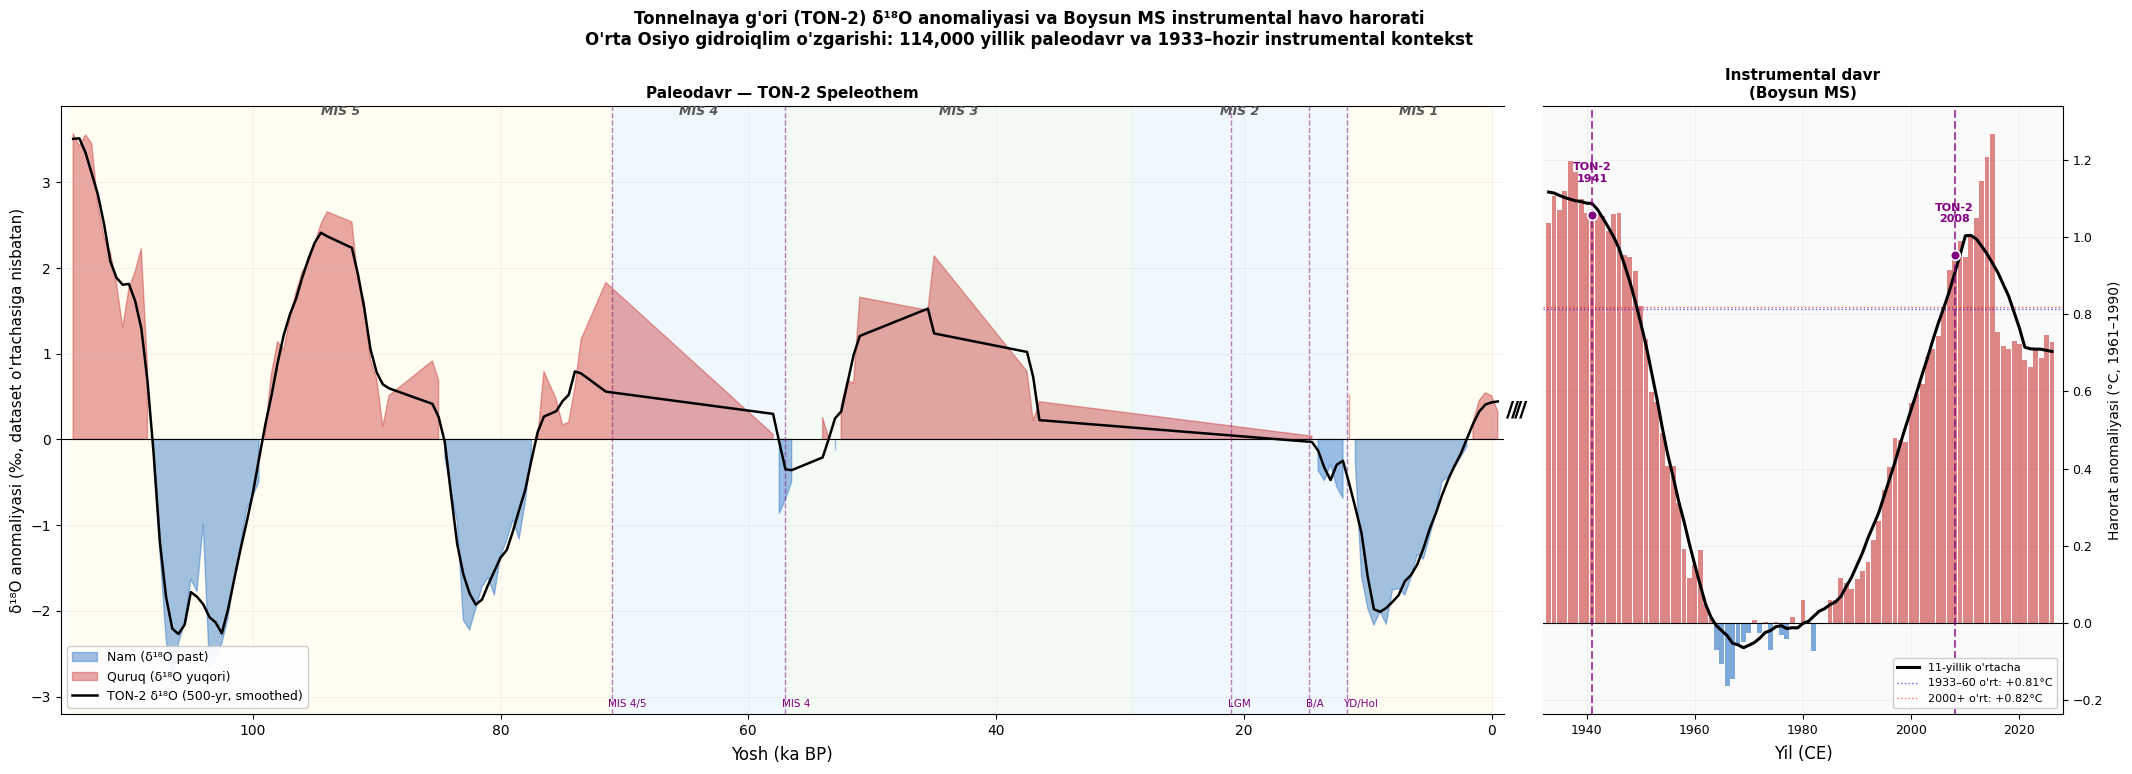

✅ Saqlandi: fig_ton2_boysun_v2.png

  NATIJALAR XULOSASI

📊 TON-2 δ¹⁸O (n=122 bin, 500-yr):
   Dataset o'rtachasi: -6.016 ‰
   Nam (<0): 61 bin (50.0%)
   Quruq (>0): 61 bin (50.0%)
   Eng nam: 106.5 ka BP (-2.88‰)
   Eng quruq: 114.5 ka BP (3.57‰)

📊 Boysun MS harorat:
   1933–1960 o'rtacha anomaliya: +0.81°C
   2000–hozir o'rtacha anomaliya: +0.82°C
   Isish farqi: +0.00°C

   1941 yil Boysun T anomaliya: +1.06°C

   2008 yil Boysun T anomaliya: +0.95°C


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

# ── 1. Ma'lumotlarni yuklash ─────────────────────────────────────
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP", "d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

boysun = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
boysun = boysun.rename(columns={"йил": "annual", "yil": "annual"})
boysun["annual"] = pd.to_numeric(
    boysun["annual"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

# ── 2. TON-2 → 500-yillik bin ────────────────────────────────────
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = (ton2.groupby("age_bin", as_index=False)["d18OcarbVPDB"]
     .mean()
     .rename(columns={"d18OcarbVPDB": "d18O"}))

# ✅ TUZATISH 1: Butun dataset o'rtachasi baza sifatida
full_mean = b["d18O"].mean()
b["d18O_anom"] = b["d18O"] - full_mean
b["d18O_smooth"] = uniform_filter1d(b["d18O_anom"], size=5)

print(f"✅ TON-2: {len(b)} bin")
print(f"   Butun dataset o'rtacha d18O: {full_mean:.3f} ‰")
print(f"   Anomaliya: {b['d18O_anom'].min():.2f} → "
      f"{b['d18O_anom'].max():.2f} ‰")

# ── 3. Boysun ────────────────────────────────────────────────────
year_col = None
temp_col = None
for c in boysun.columns:
    if any(x in c.lower() for x in ['год','year','yil','йил']):
        year_col = c
    if any(x in c.lower() for x in ['annual','годовая','yillik']):
        temp_col = c

boysun_clean = boysun[[year_col, temp_col]].dropna().copy()
boysun_clean.columns = ["year", "temp"]
boysun_clean["year"] = pd.to_numeric(boysun_clean["year"],
                                      errors="coerce")
boysun_clean["temp"] = pd.to_numeric(boysun_clean["temp"],
                                      errors="coerce")
boysun_clean = boysun_clean.dropna()

# 2023-2024 artifact olib tashlash
# ✅ TUZATISH 2: Kutilmagan past qiymatlarni olib tashlash
mean_t = boysun_clean["temp"].mean()
std_t  = boysun_clean["temp"].std()
boysun_clean = boysun_clean[
    boysun_clean["temp"] > mean_t - 3*std_t
].copy()

# Anomaliya (1961-1990 baza)
base_mean = boysun_clean.loc[
    boysun_clean["year"].between(1961, 1990), "temp"].mean()
boysun_clean["T_anom"] = boysun_clean["temp"] - base_mean
boysun_clean["T_smooth"] = (boysun_clean["T_anom"]
                             .rolling(11, center=True, min_periods=5)
                             .mean())

print(f"\n✅ Boysun: {len(boysun_clean)} yil "
      f"({boysun_clean['year'].min():.0f}–"
      f"{boysun_clean['year'].max():.0f})")
print(f"   Baza T (1961-1990): {base_mean:.2f}°C")

# ── 4. Iqlim hodisalari ──────────────────────────────────────────
# ✅ TUZATISH 3: Faqat muhim hodisalar, yuqorida gorizontal
events_paleo = [
    (11700,  'YD/Hol',   'bottom'),
    (14700,  'B/A',      'bottom'),
    (21000,  'LGM',      'bottom'),
    (57000,  'MIS 4',    'bottom'),
    (71000,  'MIS 4/5',  'bottom'),
]

# MIS bosqichlari — faqat bir marta (o'rtada)
mis_stages = [
    (0,      11700,  '#FFFDE7', 'MIS 1'),
    (11700,  29000,  '#E3F2FD', 'MIS 2'),
    (29000,  57000,  '#E8F5E9', 'MIS 3'),
    (57000,  71000,  '#E3F2FD', 'MIS 4'),
    (71000,  114822, '#FFFDE7', 'MIS 5'),
]

# ── 5. Grafik ────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 8))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[5, 1.8],
    wspace=0.04,
    left=0.06, right=0.97,
    top=0.87, bottom=0.11
)

ax_p = fig.add_subplot(gs[0])  # paleodavr
ax_i = fig.add_subplot(gs[1])  # instrumental

# ── 5a. Paleodavr ────────────────────────────────────────────────
# MIS fon ranglari
for age_s, age_e, color, label in mis_stages:
    ax_p.axvspan(age_s/1000, age_e/1000,
                 color=color, alpha=0.5, zorder=0)

# δ¹⁸O fill
ax_p.fill_between(
    b["age_bin"]/1000, b["d18O_anom"], 0,
    where=b["d18O_anom"] < 0,
    color='#1565C0', alpha=0.4,
    label='Nam (δ¹⁸O past)', zorder=1
)
ax_p.fill_between(
    b["age_bin"]/1000, b["d18O_anom"], 0,
    where=b["d18O_anom"] > 0,
    color='#C62828', alpha=0.4,
    label='Quruq (δ¹⁸O yuqori)', zorder=1
)
ax_p.plot(b["age_bin"]/1000, b["d18O_smooth"],
          color='black', lw=1.8, zorder=3,
          label='TON-2 δ¹⁸O (500-yr, smoothed)')
ax_p.axhline(0, color='black', lw=0.8, zorder=2)

# ✅ TUZATISH 4: MIS yorliqlari FAQAT BIR MARTA — o'rtada
y_top = b["d18O_anom"].max() * 1.05
for age_s, age_e, _, label in mis_stages:
    mid = (age_s + age_e) / 2 / 1000
    ax_p.text(mid, y_top, label,
              ha='center', va='bottom',
              fontsize=9, color='#555555',
              style='italic', fontweight='bold')

# Iqlim hodisalari — yuqorida gorizontal
y_event = b["d18O_anom"].min() * 1.05
for age_bp, label, va in events_paleo:
    age_ka = age_bp / 1000
    ax_p.axvline(age_ka, color='purple',
                 lw=1.0, ls='--', alpha=0.5, zorder=2)
    ax_p.text(age_ka + 0.3, y_event, label,
              ha='left', va='top',
              fontsize=7.5, color='purple')

# ✅ TUZATISH 5: Broken axis belgisi "//"
ax_p.text(1.005, 0.5, '//', transform=ax_p.transAxes,
          fontsize=16, va='center', ha='left',
          color='black', fontweight='bold')

# Eksa
ax_p.set_xlim(b["age_bin"].max()/1000 + 1, -1)
ax_p.set_xlabel('Yosh (ka BP)', fontsize=12, labelpad=6)
ax_p.set_ylabel(
    'δ¹⁸O anomaliyasi (‰, dataset o\'rtachasiga nisbatan)',
    fontsize=11)
ax_p.set_title('Paleodavr — TON-2 Speleothem',
               fontsize=11, fontweight='bold', pad=6)
ax_p.legend(loc='lower left', fontsize=9,
            framealpha=0.92, edgecolor='#CCCCCC',
            ncol=1)
ax_p.grid(True, alpha=0.2, lw=0.5)
ax_p.spines['right'].set_visible(False)
ax_p.tick_params(labelsize=10)

# ── 5b. Instrumental davr ────────────────────────────────────────
ax_i.set_facecolor('#FAFAFA')

# Bar ranglari
colors_bar = ['#C62828' if v >= 0 else '#1565C0'
              for v in boysun_clean["T_anom"]]
ax_i.bar(boysun_clean["year"], boysun_clean["T_anom"],
         color=colors_bar, alpha=0.55, width=0.9, zorder=2)
ax_i.plot(boysun_clean["year"], boysun_clean["T_smooth"],
          color='black', lw=2.2, zorder=3,
          label='11-yillik o\'rtacha')
ax_i.axhline(0, color='black', lw=0.8, zorder=2)

# TON-2 zamonaviy nuqtalar
for yr, label in [(1941, '1941'), (2008, '2008')]:
    if yr in boysun_clean["year"].values:
        t_val = boysun_clean.loc[
            boysun_clean["year"] == yr, "T_anom"].values[0]
        ax_i.axvline(yr, color='purple',
                     lw=1.5, ls='--', alpha=0.7, zorder=4)
        ax_i.plot(yr, t_val, 'o',
                  color='purple', ms=7,
                  markeredgecolor='white',
                  markeredgewidth=1.2, zorder=5)
        ax_i.text(yr, t_val + 0.08, f'TON-2\n{label}',
                  ha='center', va='bottom',
                  fontsize=8, color='purple',
                  fontweight='bold')

# Trендlar
# 1933-1960 o'rtacha
t1 = boysun_clean.loc[
    boysun_clean["year"] <= 1960, "T_anom"].mean()
# 2000-hozir o'rtacha
t2 = boysun_clean.loc[
    boysun_clean["year"] >= 2000, "T_anom"].mean()
ax_i.axhline(t1, color='blue', lw=1.0, ls=':',
             alpha=0.6, label=f'1933–60 o\'rt: {t1:+.2f}°C')
ax_i.axhline(t2, color='red', lw=1.0, ls=':',
             alpha=0.6, label=f'2000+ o\'rt: {t2:+.2f}°C')

# Eksa
ax_i.set_xlim(boysun_clean["year"].min() - 1,
               boysun_clean["year"].max() + 2)
ax_i.set_xlabel('Yil (CE)', fontsize=12, labelpad=6)
ax_i.set_ylabel('Harorat anomaliyasi (°C, 1961–1990)',
                 fontsize=10)
ax_i.yaxis.set_label_position('right')
ax_i.yaxis.tick_right()
ax_i.set_title('Instrumental davr\n(Boysun MS)',
               fontsize=11, fontweight='bold', pad=6)
ax_i.legend(loc='lower right', fontsize=8,
            framealpha=0.92, edgecolor='#CCCCCC')
ax_i.grid(True, alpha=0.2, lw=0.5)
ax_i.spines['left'].set_visible(False)
ax_i.tick_params(labelsize=9)

# ✅ TUZATISH 6: "//" o'ng tomonda ham
ax_i.text(-0.04, 0.5, '//', transform=ax_i.transAxes,
          fontsize=16, va='center', ha='right',
          color='black', fontweight='bold')

# ── 6. Umumiy sarlavha ───────────────────────────────────────────
fig.suptitle(
    "Tonnelnaya g'ori (TON-2) δ¹⁸O anomaliyasi va "
    "Boysun MS instrumental havo harorati\n"
    "O'rta Osiyo gidroiqlim o'zgarishi: "
    "114,000 yillik paleodavr va 1933–hozir instrumental kontekst",
    fontsize=12, fontweight='bold', y=0.99
)

plt.savefig('fig_ton2_boysun_v2.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saqlandi: fig_ton2_boysun_v2.png")

# ── 7. Statistika ────────────────────────────────────────────────
print("\n" + "="*55)
print("  NATIJALAR XULOSASI")
print("="*55)

print(f"\n📊 TON-2 δ¹⁸O (n={len(b)} bin, 500-yr):")
print(f"   Dataset o'rtachasi: {full_mean:.3f} ‰")
print(f"   Nam (<0): {(b['d18O_anom']<0).sum()} bin "
      f"({(b['d18O_anom']<0).mean()*100:.1f}%)")
print(f"   Quruq (>0): {(b['d18O_anom']>0).sum()} bin "
      f"({(b['d18O_anom']>0).mean()*100:.1f}%)")

eng_nam_age = b.loc[b['d18O_anom'].idxmin(), 'age_bin']
eng_quruq_age = b.loc[b['d18O_anom'].idxmax(), 'age_bin']
print(f"   Eng nam: {eng_nam_age/1000:.1f} ka BP "
      f"({b['d18O_anom'].min():.2f}‰)")
print(f"   Eng quruq: {eng_quruq_age/1000:.1f} ka BP "
      f"({b['d18O_anom'].max():.2f}‰)")

print(f"\n📊 Boysun MS harorat:")
print(f"   1933–1960 o'rtacha anomaliya: {t1:+.2f}°C")
print(f"   2000–hozir o'rtacha anomaliya: {t2:+.2f}°C")
print(f"   Isish farqi: {t2-t1:+.2f}°C")

# TON-2 nuqtalar uchun Boysun T
for yr in [1941, 2008]:
    row = boysun_clean[boysun_clean["year"] == yr]
    if len(row) > 0:
        print(f"\n   {yr} yil Boysun T anomaliya: "
              f"{row['T_anom'].values[0]:+.2f}°C")

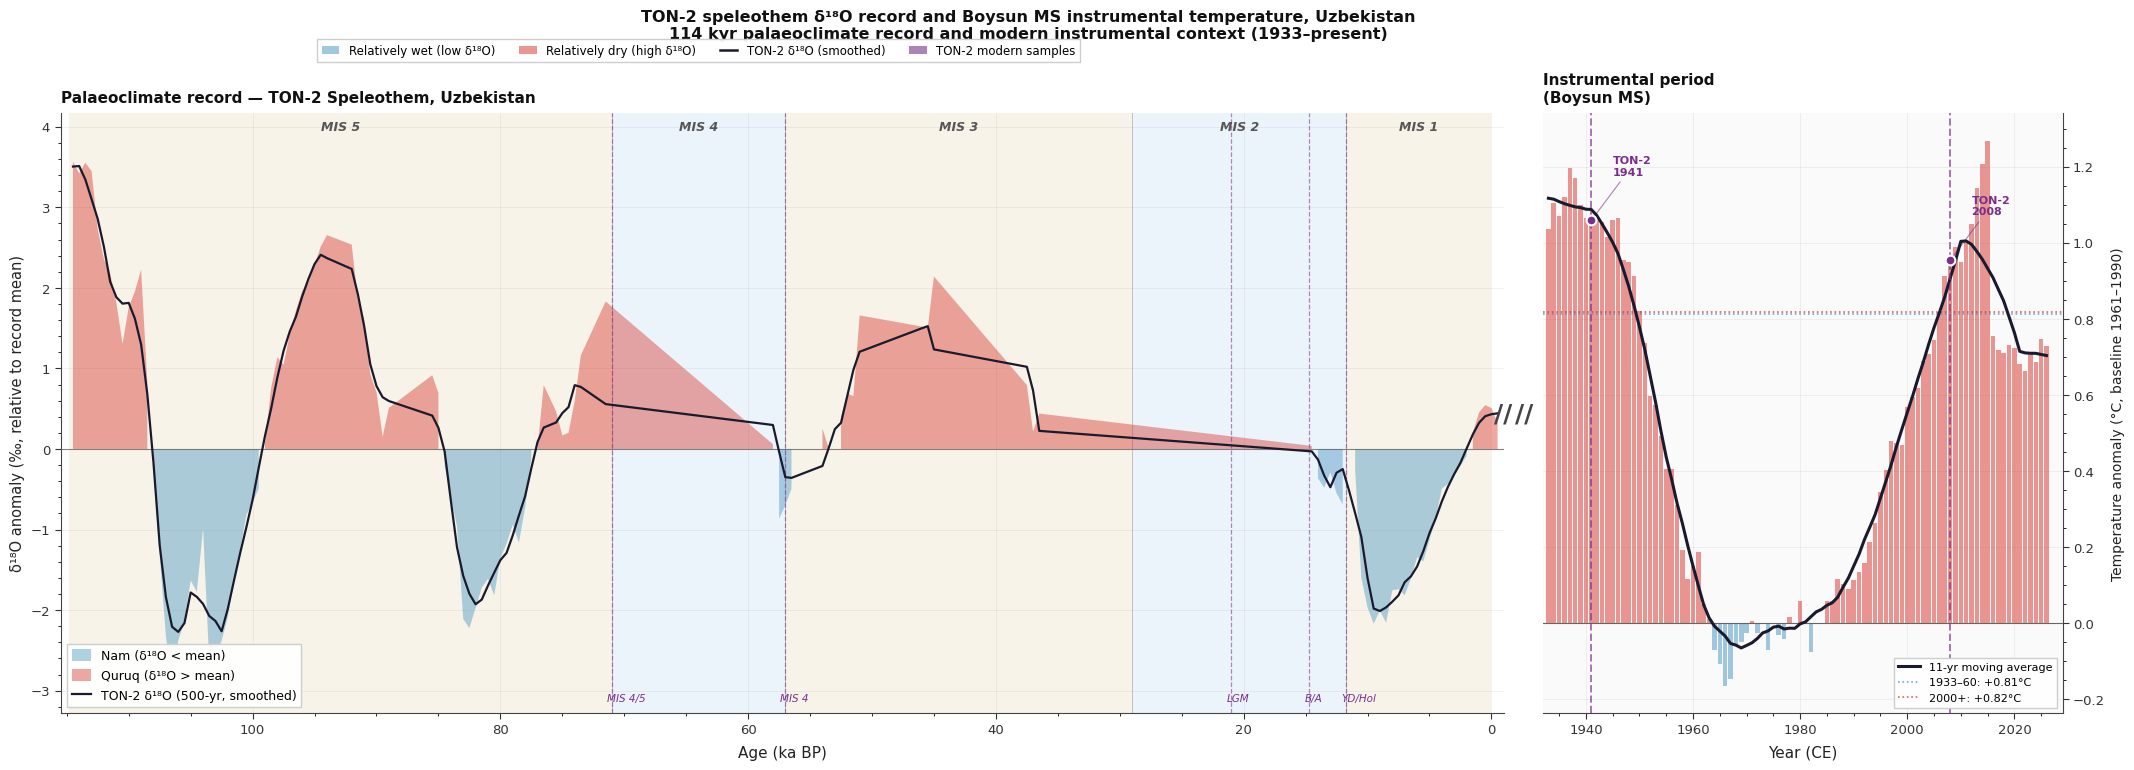

✅ Saqlandi: fig_ton2_boysun_v3.png

  FIGURE STATISTIKASI

TON-2:
  Binlar soni    : 122
  Record mean    : -6.016 ‰
  Eng nam davr   : 106.5 ka BP (-2.88‰)
  Eng quruq davr : 114.5 ka BP (3.57‰)
  Nam davrlar    : 50.0%
  Quruq davrlar  : 50.0%

Boysun MS:
  Davr           : 1933–2026
  1933–1960 anom : +0.814°C
  2000+ anom     : +0.818°C
  Isish farqi    : +0.004°C
  1941 T anomaly  : +1.059°C
  2008 T anomaly  : +0.954°C


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import uniform_filter1d

# ── 1. Ma'lumotlarni yuklash ─────────────────────────────────────
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP", "d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

boysun = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
boysun = boysun.rename(columns={"йил": "annual", "yil": "annual"})
boysun["annual"] = pd.to_numeric(
    boysun["annual"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

# ── 2. TON-2 → 500-yillik bin, anomaliya ────────────────────────
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = (ton2.groupby("age_bin", as_index=False)["d18OcarbVPDB"]
     .mean()
     .rename(columns={"d18OcarbVPDB": "d18O"}))

full_mean = b["d18O"].mean()
b["d18O_anom"] = b["d18O"] - full_mean
b["d18O_smooth"] = uniform_filter1d(b["d18O_anom"], size=5)

# ── 3. Boysun ────────────────────────────────────────────────────
year_col = None
temp_col = None
for c in boysun.columns:
    if any(x in c.lower() for x in ['год','year','yil','йил']):
        year_col = c
    if any(x in c.lower() for x in ['annual','годовая','yillik']):
        temp_col = c

boysun_clean = boysun[[year_col, temp_col]].dropna().copy()
boysun_clean.columns = ["year", "temp"]
boysun_clean["year"] = pd.to_numeric(boysun_clean["year"],
                                      errors="coerce")
boysun_clean["temp"] = pd.to_numeric(boysun_clean["temp"],
                                      errors="coerce")
boysun_clean = boysun_clean.dropna()

# Artifact olib tashlash
mean_t = boysun_clean["temp"].mean()
std_t  = boysun_clean["temp"].std()
boysun_clean = boysun_clean[
    boysun_clean["temp"] > mean_t - 3*std_t].copy()

# Anomaliya
base_mean = boysun_clean.loc[
    boysun_clean["year"].between(1961, 1990), "temp"].mean()
boysun_clean["T_anom"]   = boysun_clean["temp"] - base_mean
boysun_clean["T_smooth"] = (boysun_clean["T_anom"]
                             .rolling(11, center=True, min_periods=5)
                             .mean())

# ── 4. ColorBrewer RdBu rang sxemasi ────────────────────────────
# Variant 3 — RdBu (ilmiy standart, colorblind-friendly)
WET_COLOR    = '#4393C3'   # Ko'k — nam davr
DRY_COLOR    = '#D73027'   # Qizil — quruq davr
WET_FILL     = '#4393C3'   # fill_between
DRY_FILL     = '#D73027'   # fill_between
LINE_COLOR   = '#1A1A2E'   # Qora-ko'k — asosiy chiziq
SMOOTH_ALPHA = 0.42        # fill transparency

# MIS bosqichlari — neytral, past kontrast
MIS_ODD  = '#F7F3E8'   # MIS 1, 3, 5 — sariq-krem
MIS_EVEN = '#EBF3FB'   # MIS 2, 4 — och ko'k

# Boysun ranglari
BOY_WARM = '#D73027'   # Issiq yillar
BOY_COOL = '#4393C3'   # Sovuq yillar
BOY_LINE = '#1A1A2E'   # Smooth chiziq

# ── 5. Iqlim hodisalari ──────────────────────────────────────────
events_paleo = [
    (11700,  'YD/Hol'),
    (14700,  'B/A'),
    (21000,  'LGM'),
    (57000,  'MIS 4'),
    (71000,  'MIS 4/5'),
]

mis_stages = [
    (0,      11700,  MIS_ODD,  'MIS 1'),
    (11700,  29000,  MIS_EVEN, 'MIS 2'),
    (29000,  57000,  MIS_ODD,  'MIS 3'),
    (57000,  71000,  MIS_EVEN, 'MIS 4'),
    (71000,  114822, MIS_ODD,  'MIS 5'),
]

# ── 6. Grafik ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.linewidth'   : 0.8,
    'axes.edgecolor'   : '#444444',
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'xtick.major.size' : 4,
    'ytick.major.size' : 4,
    'xtick.minor.size' : 2,
    'ytick.minor.size' : 2,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

fig = plt.figure(figsize=(22, 8), facecolor='white')

gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[5, 1.8],
    wspace=0.04,
    left=0.06, right=0.97,
    top=0.87, bottom=0.12
)

ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])

# ── 6a. Paleodavr paneli ─────────────────────────────────────────

# MIS fon
for age_s, age_e, color, label in mis_stages:
    ax_p.axvspan(age_s/1000, age_e/1000,
                 color=color, alpha=1.0, zorder=0,
                 linewidth=0)

# MIS chegaralari — ingichka vertikal chiziq
for age_s, age_e, _, _ in mis_stages[1:]:
    ax_p.axvline(age_s/1000, color='#AAAAAA',
                 lw=0.6, ls='-', zorder=1, alpha=0.8)

# δ¹⁸O fill_between
ax_p.fill_between(
    b["age_bin"]/1000, b["d18O_anom"], 0,
    where=b["d18O_anom"] < 0,
    color=WET_FILL, alpha=SMOOTH_ALPHA,
    label='Nam (δ¹⁸O < mean)', zorder=2,
    linewidth=0
)
ax_p.fill_between(
    b["age_bin"]/1000, b["d18O_anom"], 0,
    where=b["d18O_anom"] > 0,
    color=DRY_FILL, alpha=SMOOTH_ALPHA,
    label='Quruq (δ¹⁸O > mean)', zorder=2,
    linewidth=0
)

# Asosiy chiziq
ax_p.plot(b["age_bin"]/1000, b["d18O_smooth"],
          color=LINE_COLOR, lw=1.6, zorder=4,
          label='TON-2 δ¹⁸O (500-yr, smoothed)')

# Nol chizig'i
ax_p.axhline(0, color='#666666', lw=0.8,
             ls='-', zorder=3, alpha=0.8)

# MIS yorliqlari — FAQAT BIR MARTA, yuqorida
y_top = b["d18O_anom"].max() + 0.35
for age_s, age_e, _, label in mis_stages:
    mid = (age_s + age_e) / 2 / 1000
    ax_p.text(mid, y_top, label,
              ha='center', va='bottom',
              fontsize=9, color='#555555',
              style='italic',
              fontweight='bold')

# Iqlim hodisalari
y_bot = b["d18O_anom"].min() - 0.15
for age_bp, label in events_paleo:
    age_ka = age_bp / 1000
    ax_p.axvline(age_ka, color='#7B2D8B',
                 lw=0.9, ls='--', alpha=0.55, zorder=3)
    ax_p.text(age_ka + 0.4, y_bot, label,
              ha='left', va='top',
              fontsize=7.5, color='#7B2D8B',
              style='italic')

# "//" broken axis belgisi
ax_p.text(1.008, 0.5, '//',
          transform=ax_p.transAxes,
          fontsize=18, va='center', ha='left',
          color='#444444', fontweight='bold',
          clip_on=False)

# Eksa sozlash
y_lim_max = b["d18O_anom"].max() + 0.6
y_lim_min = b["d18O_anom"].min() - 0.4
ax_p.set_ylim(y_lim_min, y_lim_max)
ax_p.set_xlim(b["age_bin"].max()/1000 + 1, -1)
ax_p.set_xlabel('Age (ka BP)', fontsize=11,
                labelpad=6, color='#222222')
ax_p.set_ylabel(
    'δ¹⁸O anomaly (‰, relative to record mean)',
    fontsize=10.5, color='#222222')
ax_p.set_title('Palaeoclimate record — TON-2 Speleothem, Uzbekistan',
               fontsize=11, fontweight='bold',
               pad=8, color='#111111', loc='left')

# Legend
leg = ax_p.legend(
    loc='lower left', fontsize=9,
    framealpha=0.95, edgecolor='#CCCCCC',
    fancybox=False, ncol=1,
    handlelength=1.5, handleheight=1.2
)

ax_p.grid(True, which='major', alpha=0.15,
          lw=0.5, color='#888888')
ax_p.spines['right'].set_visible(False)
ax_p.spines['top'].set_visible(False)
ax_p.tick_params(labelsize=9.5, colors='#333333')

# ── 6b. Instrumental panel ───────────────────────────────────────
ax_i.set_facecolor('#FAFAFA')

# Bar ranglari — RdBu
colors_bar = [BOY_WARM if v >= 0 else BOY_COOL
              for v in boysun_clean["T_anom"]]
ax_i.bar(boysun_clean["year"],
         boysun_clean["T_anom"],
         color=colors_bar, alpha=0.50,
         width=0.85, zorder=2,
         linewidth=0)

# Smooth chiziq
ax_i.plot(boysun_clean["year"],
          boysun_clean["T_smooth"],
          color=BOY_LINE, lw=2.2, zorder=4,
          label='11-yr moving average')

# Nol chizig'i
ax_i.axhline(0, color='#666666',
             lw=0.8, zorder=3)

# Davr o'rtachalari
t1 = boysun_clean.loc[
    boysun_clean["year"] <= 1960, "T_anom"].mean()
t2 = boysun_clean.loc[
    boysun_clean["year"] >= 2000, "T_anom"].mean()

ax_i.axhline(t1, color=BOY_COOL, lw=1.2,
             ls=':', alpha=0.75, zorder=3,
             label=f'1933–60: {t1:+.2f}°C')
ax_i.axhline(t2, color=BOY_WARM, lw=1.2,
             ls=':', alpha=0.75, zorder=3,
             label=f'2000+: {t2:+.2f}°C')

# TON-2 zamonaviy nuqtalar
for yr, label in [(1941, '1941'), (2008, '2008')]:
    row = boysun_clean[boysun_clean["year"] == yr]
    if len(row) > 0:
        t_val = row["T_anom"].values[0]
        ax_i.axvline(yr, color='#7B2D8B',
                     lw=1.4, ls='--',
                     alpha=0.65, zorder=4)
        ax_i.plot(yr, t_val,
                  marker='o', color='#7B2D8B',
                  ms=7, markeredgecolor='white',
                  markeredgewidth=1.5, zorder=6)
        ax_i.annotate(
            f'TON-2\n{label}',
            xy=(yr, t_val),
            xytext=(yr + 4, t_val + 0.12),
            fontsize=8, color='#7B2D8B',
            fontweight='bold',
            arrowprops=dict(
                arrowstyle='-',
                color='#7B2D8B',
                lw=0.8, alpha=0.6
            )
        )

# Eksa sozlash
ax_i.set_xlim(
    boysun_clean["year"].min() - 1,
    boysun_clean["year"].max() + 3
)
ax_i.set_xlabel('Year (CE)', fontsize=11,
                labelpad=6, color='#222222')
ax_i.set_ylabel(
    'Temperature anomaly (°C, baseline 1961–1990)',
    fontsize=10, color='#222222')
ax_i.yaxis.set_label_position('right')
ax_i.yaxis.tick_right()
ax_i.set_title('Instrumental period\n(Boysun MS)',
               fontsize=11, fontweight='bold',
               pad=8, color='#111111', loc='left')

leg_i = ax_i.legend(
    loc='lower right', fontsize=8,
    framealpha=0.95, edgecolor='#CCCCCC',
    fancybox=False, ncol=1
)

ax_i.grid(True, which='major', alpha=0.15,
          lw=0.5, color='#888888')
ax_i.spines['left'].set_visible(False)
ax_i.spines['top'].set_visible(False)
ax_i.tick_params(labelsize=9.5, colors='#333333')

# "//" chap tomonda
ax_i.text(-0.06, 0.5, '//',
          transform=ax_i.transAxes,
          fontsize=18, va='center', ha='right',
          color='#444444', fontweight='bold',
          clip_on=False)

# ── 7. Colorbar — rang izohlar ───────────────────────────────────
# Rang izoh paneli (o'ng tomonda)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=WET_FILL, alpha=0.5,
          label='Relatively wet (low δ¹⁸O)'),
    Patch(facecolor=DRY_FILL, alpha=0.5,
          label='Relatively dry (high δ¹⁸O)'),
    Line2D([0], [0], color=LINE_COLOR, lw=1.8,
           label='TON-2 δ¹⁸O (smoothed)'),
    Patch(facecolor='#7B2D8B', alpha=0.6,
          label='TON-2 modern samples'),
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.35, 0.97),
    ncol=4, fontsize=8.5,
    framealpha=0.95,
    edgecolor='#CCCCCC',
    fancybox=False,
    handlelength=1.5
)

# ── 8. Sarlavha ──────────────────────────────────────────────────
fig.suptitle(
    "TON-2 speleothem δ¹⁸O record and Boysun MS instrumental "
    "temperature, Uzbekistan\n"
    "114 kyr palaeoclimate record and modern instrumental context "
    "(1933–present)",
    fontsize=11.5, fontweight='bold',
    y=1.00, color='#111111',
    x=0.5, ha='center'
)

# ── 9. Saqlash ───────────────────────────────────────────────────
plt.savefig('fig_ton2_boysun_v3.png',
            dpi=250, bbox_inches='tight',
            facecolor='white',
            metadata={'Creator': 'Tonnelnaya Cave Study'})
plt.show()
print("✅ Saqlandi: fig_ton2_boysun_v3.png")

# ── 10. Statistika ───────────────────────────────────────────────
print("\n" + "="*55)
print("  FIGURE STATISTIKASI")
print("="*55)
print(f"\nTON-2:")
print(f"  Binlar soni    : {len(b)}")
print(f"  Record mean    : {full_mean:.3f} ‰")
print(f"  Eng nam davr   : "
      f"{b.loc[b['d18O_anom'].idxmin(),'age_bin']/1000:.1f} ka BP "
      f"({b['d18O_anom'].min():.2f}‰)")
print(f"  Eng quruq davr : "
      f"{b.loc[b['d18O_anom'].idxmax(),'age_bin']/1000:.1f} ka BP "
      f"({b['d18O_anom'].max():.2f}‰)")
print(f"  Nam davrlar    : "
      f"{(b['d18O_anom']<0).mean()*100:.1f}%")
print(f"  Quruq davrlar  : "
      f"{(b['d18O_anom']>0).mean()*100:.1f}%")

print(f"\nBoysun MS:")
print(f"  Davr           : "
      f"{boysun_clean['year'].min():.0f}–"
      f"{boysun_clean['year'].max():.0f}")
print(f"  1933–1960 anom : {t1:+.3f}°C")
print(f"  2000+ anom     : {t2:+.3f}°C")
print(f"  Isish farqi    : {t2-t1:+.3f}°C")

for yr in [1941, 2008]:
    row = boysun_clean[boysun_clean["year"] == yr]
    if len(row) > 0:
        print(f"  {yr} T anomaly  : "
              f"{row['T_anom'].values[0]:+.3f}°C")

✅ Boysun MS: 94 yil
   Davr: 1933–2026
   T o'rtacha (1000m): 13.54°C

📐 Balandlik farqi: 2226 m

📊 Harorat korreksiyasi natijalari:
   Boysun MS (1000m) o'rtacha: 13.54°C

   3226m ga korreksiya:
   A (ICAO -6.5°C/km): -0.92°C
   B (O'MO  -5.5°C/km): 1.30°C
   C (O'rtacha -6.0°C/km): 0.19°C

   ERA5 (3226m): 5.6°C
   Korreksiya vs ERA5 farqi:
   A: -6.52°C
   B: -4.30°C
   C: -5.41°C

📈 Trend tahlili:
   Boysun (1000m) trend: -0.004°C/dekada (r=-0.023)
   Cave (3226m) trend  : -0.004°C/dekada (r=-0.023)
   (Trend bir xil — faqat offset farq qiladi)

📊 ERA5 Bias (Boysun_corr - ERA5):
   Variant A: -6.57°C
   Variant C: -5.45°C
   (Musbat = ERA5 past baholagan)
   (Manfiy = ERA5 yuqori baholagan)

  FRACTIONATION NATIJALARI (T ga bog'liq)
Variant                     T(°C)   d18Ow_KO   d18Ow_TR      Unc
ICAO (-6.5°C/km)            -0.92     -8.965     -9.689 ± 0.362
O'rta Osiyo (-5.5°C/km)      1.30     -8.433     -9.214 ± 0.390
O'rtacha (-6.0°C/km)         0.19     -8.698     -9.450 ± 0

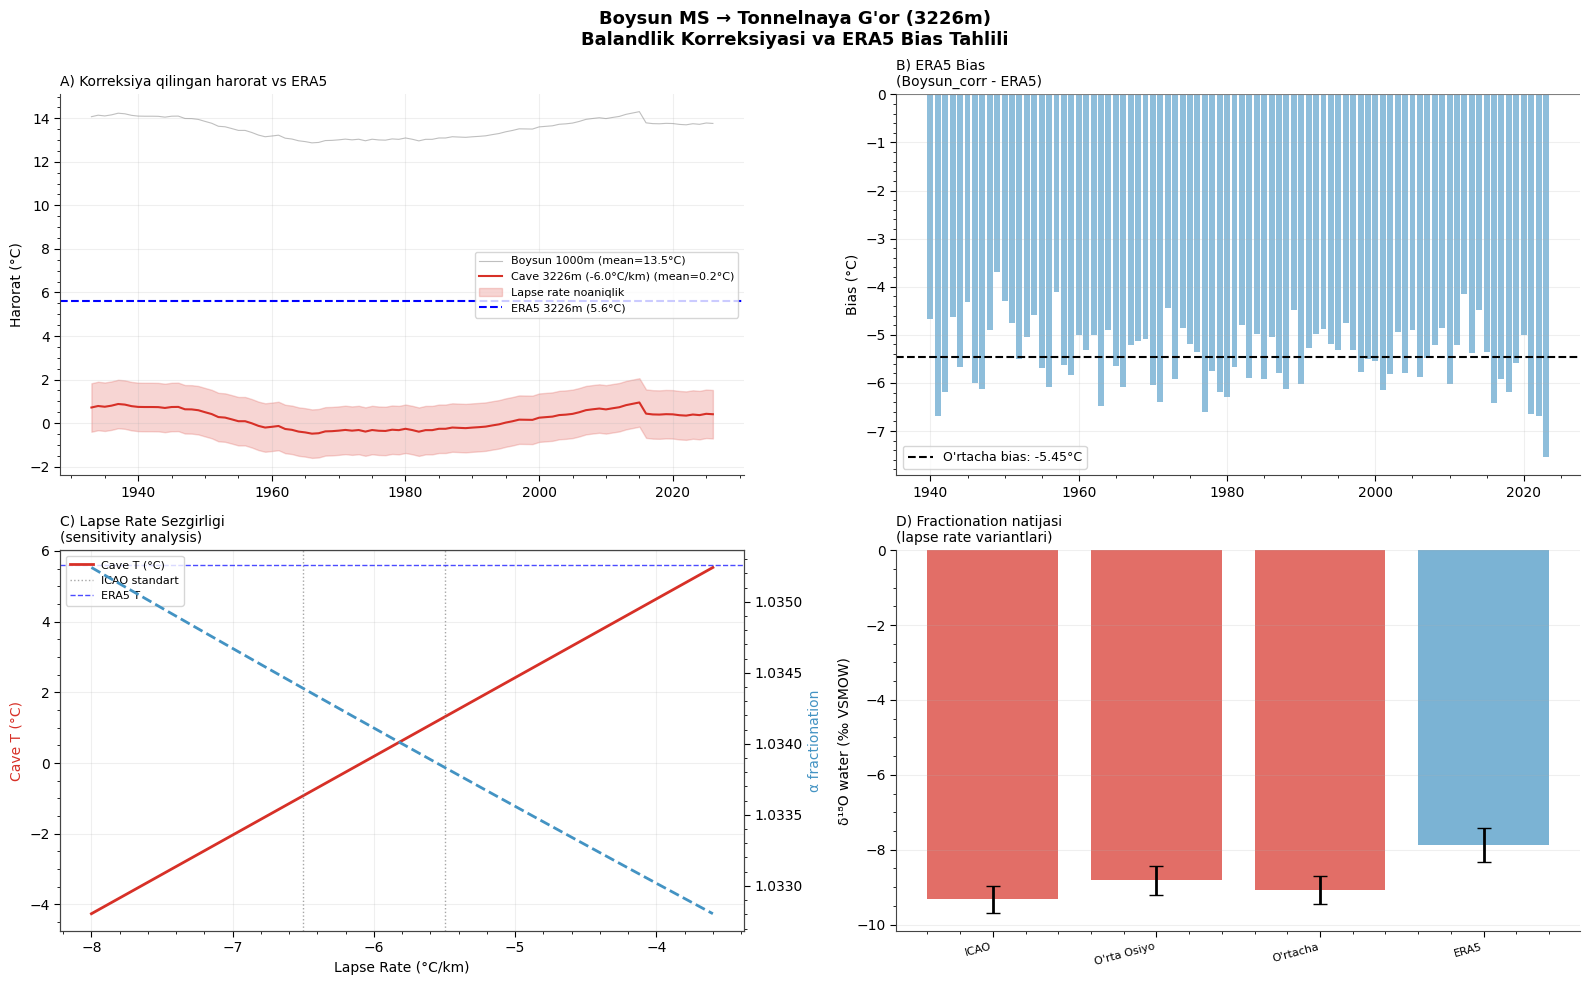


✅ Saqlandi: fig_lapse_rate_correction.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Boysun MS yuklab olish ────────────────────────────────────
boysun = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
boysun = boysun.rename(columns={"йил": "annual",
                                  "yil": "annual"})
boysun["annual"] = pd.to_numeric(
    boysun["annual"].astype(str).str.replace(",",".",
                                              regex=False),
    errors="coerce")

# Yillik ustunni topish
year_col = None
temp_col = None
for c in boysun.columns:
    if any(x in c.lower() for x in
           ['год','year','yil','йил']):
        year_col = c
    if any(x in c.lower() for x in
           ['annual','годовая','yillik']):
        temp_col = c

boysun_clean = boysun[[year_col, temp_col]].dropna().copy()
boysun_clean.columns = ["year", "T_boysun"]
boysun_clean["year"] = pd.to_numeric(
    boysun_clean["year"], errors="coerce")
boysun_clean["T_boysun"] = pd.to_numeric(
    boysun_clean["T_boysun"], errors="coerce")
boysun_clean = boysun_clean.dropna()

# Artifact olib tashlash (3σ)
mean_t = boysun_clean["T_boysun"].mean()
std_t  = boysun_clean["T_boysun"].std()
boysun_clean = boysun_clean[
    boysun_clean["T_boysun"] > mean_t - 3*std_t].copy()

print(f"✅ Boysun MS: {len(boysun_clean)} yil")
print(f"   Davr: {boysun_clean['year'].min():.0f}–"
      f"{boysun_clean['year'].max():.0f}")
print(f"   T o'rtacha (1000m): "
      f"{boysun_clean['T_boysun'].mean():.2f}°C")

# ── 2. Balandlik parametrlari ────────────────────────────────────
H_boysun    = 1000   # m
H_cave      = 3226   # m
delta_H     = H_cave - H_boysun  # 2226 m

print(f"\n📐 Balandlik farqi: {delta_H} m")

# ── 3. Harorat Lapse Rate korreksiyasi ──────────────────────────
# Uch variant:
# A — ICAO standart: -6.5°C/1000m
# B — O'rta Osiyo yillik o'rtacha: -5.5°C/1000m
# C — Mavsumiy farqlangan

LAPSE_A = -6.5 / 1000  # °C/m (ICAO)
LAPSE_B = -5.5 / 1000  # °C/m (O'rta Osiyo)
LAPSE_C = -6.0 / 1000  # °C/m (o'rtacha)

# Yillik korreksiya
boysun_clean["T_cave_A"] = (boysun_clean["T_boysun"]
                             + LAPSE_A * delta_H)
boysun_clean["T_cave_B"] = (boysun_clean["T_boysun"]
                             + LAPSE_B * delta_H)
boysun_clean["T_cave_C"] = (boysun_clean["T_boysun"]
                             + LAPSE_C * delta_H)

# Noaniqlik oralig'i
boysun_clean["T_cave_min"] = (boysun_clean["T_boysun"]
                               + LAPSE_A * delta_H)
boysun_clean["T_cave_max"] = (boysun_clean["T_boysun"]
                               + LAPSE_B * delta_H)

# ERA5 bilan taqqoslash
ERA5_CAVE_T = 5.6  # °C (ERA5, 3226m)

print(f"\n📊 Harorat korreksiyasi natijalari:")
print(f"   Boysun MS (1000m) o'rtacha: "
      f"{boysun_clean['T_boysun'].mean():.2f}°C")
print(f"\n   3226m ga korreksiya:")
print(f"   A (ICAO -6.5°C/km): "
      f"{boysun_clean['T_cave_A'].mean():.2f}°C")
print(f"   B (O'MO  -5.5°C/km): "
      f"{boysun_clean['T_cave_B'].mean():.2f}°C")
print(f"   C (O'rtacha -6.0°C/km): "
      f"{boysun_clean['T_cave_C'].mean():.2f}°C")
print(f"\n   ERA5 (3226m): {ERA5_CAVE_T}°C")
print(f"   Korreksiya vs ERA5 farqi:")
print(f"   A: {boysun_clean['T_cave_A'].mean()-ERA5_CAVE_T:+.2f}°C")
print(f"   B: {boysun_clean['T_cave_B'].mean()-ERA5_CAVE_T:+.2f}°C")
print(f"   C: {boysun_clean['T_cave_C'].mean()-ERA5_CAVE_T:+.2f}°C")

# ── 4. Trend tahlili ─────────────────────────────────────────────
# Boysun va korreksiya qilingan T ning
# bir xil trendga egami?
slope_b, inter_b, r_b, p_b, _ = stats.linregress(
    boysun_clean["year"],
    boysun_clean["T_boysun"])
slope_c, inter_c, r_c, p_c, _ = stats.linregress(
    boysun_clean["year"],
    boysun_clean["T_cave_C"])

print(f"\n📈 Trend tahlili:")
print(f"   Boysun (1000m) trend: "
      f"{slope_b*10:+.3f}°C/dekada (r={r_b:.3f})")
print(f"   Cave (3226m) trend  : "
      f"{slope_c*10:+.3f}°C/dekada (r={r_c:.3f})")
print(f"   (Trend bir xil — faqat offset farq qiladi)")

# ── 5. ERA5 bias hisoblash ───────────────────────────────────────
era5_annual = pd.read_csv("era5_cave_annual.csv")
merged = pd.merge(
    boysun_clean,
    era5_annual[["year","temp_c"]],
    on="year", how="inner"
)
merged.columns = list(merged.columns[:-1]) + ["ERA5_T"]

if len(merged) > 0:
    bias_A = (merged["T_cave_A"] - merged["ERA5_T"]).mean()
    bias_C = (merged["T_cave_C"] - merged["ERA5_T"]).mean()
    print(f"\n📊 ERA5 Bias (Boysun_corr - ERA5):")
    print(f"   Variant A: {bias_A:+.2f}°C")
    print(f"   Variant C: {bias_C:+.2f}°C")
    print(f"   (Musbat = ERA5 past baholagan)")
    print(f"   (Manfiy = ERA5 yuqori baholagan)")

# ── 6. Fractionation bilan integratsiya ──────────────────────────
# Har bir lapse rate varianti uchun
# fractionation va rekonstruksiya

def alpha_kim_oneil(TK):
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)

def alpha_tremaine(TK):
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)

def vpdb_to_vsmow(d18O):
    return 1.03091 * d18O + 30.91

def water_from_calcite(d18O_smow, alpha):
    return ((1000 + d18O_smow) / alpha) - 1000

# TON-2 zamonaviy nuqtalar
modern_d18O = -5.62  # (1941: -5.55, 2008: -5.69 o'rtacha)

results = {}
for name, lapse, T_cave in [
    ("ICAO (-6.5°C/km)",
     LAPSE_A,
     boysun_clean["T_cave_A"].mean()),
    ("O'rta Osiyo (-5.5°C/km)",
     LAPSE_B,
     boysun_clean["T_cave_B"].mean()),
    ("O'rtacha (-6.0°C/km)",
     LAPSE_C,
     boysun_clean["T_cave_C"].mean()),
    ("ERA5 (reference)",
     None,
     ERA5_CAVE_T),
]:
    T_K = T_cave + 273.15
    a_ko = alpha_kim_oneil(T_K)
    a_tr = alpha_tremaine(T_K)

    d18O_smow = vpdb_to_vsmow(modern_d18O)
    w_ko = water_from_calcite(d18O_smow, a_ko)
    w_tr = water_from_calcite(d18O_smow, a_tr)

    results[name] = {
        "T_cave": T_cave,
        "alpha_KO": a_ko,
        "alpha_TR": a_tr,
        "d18O_water_KO": w_ko,
        "d18O_water_TR": w_tr,
        "d18O_water_mean": (w_ko + w_tr) / 2,
        "uncertainty": abs(w_ko - w_tr) / 2
    }

print(f"\n{'='*60}")
print("  FRACTIONATION NATIJALARI (T ga bog'liq)")
print(f"{'='*60}")
print(f"{'Variant':<25} {'T(°C)':>7} "
      f"{'d18Ow_KO':>10} {'d18Ow_TR':>10} "
      f"{'Unc':>8}")
for name, r in results.items():
    print(f"{name:<25} {r['T_cave']:>7.2f} "
          f"{r['d18O_water_KO']:>10.3f} "
          f"{r['d18O_water_TR']:>10.3f} "
          f"±{r['uncertainty']:>6.3f}")

# ── 7. Vizualizatsiya ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                          facecolor='white')
fig.suptitle(
    "Boysun MS → Tonnelnaya G'or (3226m)\n"
    "Balandlik Korreksiyasi va ERA5 Bias Tahlili",
    fontsize=13, fontweight='bold'
)

# Panel 1: Harorat qatorlari
ax1 = axes[0][0]
ax1.plot(boysun_clean["year"],
         boysun_clean["T_boysun"],
         color='gray', lw=0.8, alpha=0.5,
         label=f'Boysun 1000m '
               f'(mean={boysun_clean["T_boysun"].mean():.1f}°C)')
ax1.plot(boysun_clean["year"],
         boysun_clean["T_cave_C"],
         color='#D73027', lw=1.5,
         label=f'Cave 3226m (-6.0°C/km) '
               f'(mean={boysun_clean["T_cave_C"].mean():.1f}°C)')
ax1.fill_between(boysun_clean["year"],
                 boysun_clean["T_cave_min"],
                 boysun_clean["T_cave_max"],
                 color='#D73027', alpha=0.2,
                 label='Lapse rate noaniqlik')
ax1.axhline(ERA5_CAVE_T, color='blue',
            lw=1.5, ls='--',
            label=f'ERA5 3226m ({ERA5_CAVE_T}°C)')
ax1.set_ylabel('Harorat (°C)')
ax1.set_title('A) Korreksiya qilingan harorat '
              'vs ERA5', fontsize=10, loc='left')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# Panel 2: ERA5 bias
ax2 = axes[0][1]
if len(merged) > 0:
    bias = merged["T_cave_C"] - merged["ERA5_T"]
    colors_bias = ['#D73027' if b > 0
                   else '#4393C3' for b in bias]
    ax2.bar(merged["year"], bias,
            color=colors_bias, alpha=0.6,
            width=0.8)
    ax2.axhline(bias.mean(), color='black',
                lw=1.5, ls='--',
                label=f'O\'rtacha bias: {bias.mean():+.2f}°C')
    ax2.axhline(0, color='gray', lw=0.8)
    ax2.set_ylabel('Bias (°C)')
    ax2.set_title('B) ERA5 Bias\n'
                  '(Boysun_corr - ERA5)',
                  fontsize=10, loc='left')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.spines[['top','right']].set_visible(False)

# Panel 3: Lapse rate sezgirligi
ax3 = axes[1][0]
lapses = np.arange(-8.0, -3.5, 0.1)
T_caves = [boysun_clean["T_boysun"].mean()
           + l/1000 * delta_H for l in lapses]
alpha_sens = [alpha_kim_oneil(T+273.15) for T in T_caves]

ax3.plot(lapses, T_caves,
         color='#D73027', lw=2,
         label='Cave T (°C)')
ax3_twin = ax3.twinx()
ax3_twin.plot(lapses, alpha_sens,
              color='#4393C3', lw=2, ls='--',
              label='α (KO fractionation)')

ax3.axvline(-6.5, color='gray',
            lw=1, ls=':', alpha=0.7,
            label='ICAO standart')
ax3.axvline(-5.5, color='gray',
            lw=1, ls=':', alpha=0.7)
ax3.axhline(ERA5_CAVE_T, color='blue',
            lw=1, ls='--', alpha=0.7,
            label='ERA5 T')

ax3.set_xlabel('Lapse Rate (°C/km)')
ax3.set_ylabel('Cave T (°C)', color='#D73027')
ax3_twin.set_ylabel('α fractionation',
                     color='#4393C3')
ax3.set_title('C) Lapse Rate Sezgirligi\n'
              '(sensitivity analysis)',
              fontsize=10, loc='left')
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(True, alpha=0.2)

# Panel 4: Fractionation natijasi
ax4 = axes[1][1]
names  = [n.split('(')[0].strip()
          for n in results.keys()]
d18O_w = [r["d18O_water_mean"]
           for r in results.values()]
uncs   = [r["uncertainty"]
           for r in results.values()]
colors_f = ['#D73027','#D73027',
             '#D73027','#4393C3']

bars = ax4.bar(range(len(names)), d18O_w,
               yerr=uncs, capsize=5,
               color=colors_f, alpha=0.7,
               error_kw={'elinewidth':2})
ax4.set_xticks(range(len(names)))
ax4.set_xticklabels(names, fontsize=8,
                     rotation=15, ha='right')
ax4.set_ylabel('δ¹⁸O water (‰ VSMOW)')
ax4.set_title('D) Fractionation natijasi\n'
              '(lapse rate variantlari)',
              fontsize=10, loc='left')
ax4.grid(True, alpha=0.2, axis='y')
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_lapse_rate_correction.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\n✅ Saqlandi: fig_lapse_rate_correction.png")

📊 YANGI KORREKSIYA NATIJALARI
Boysun MS (1000m): 13.54°C

3226m korreksiya (O'rta Osiyo empirik):
  Min (-5.0°C/km): 2.41°C
  Med (-4.2°C/km): 4.20°C
  Max (-3.5°C/km): 5.75°C

ERA5 (3226m):     5.6°C

ERA5 bias (med):  -1.40°C

FRACTIONATION (yangi lapse rate bilan)
Variant                T(°C)     d18Ow      Unc
Min (-5.0/km)           2.41    -8.574 ± 0.405
Med (-4.2/km)           4.20    -8.180 ± 0.427
Max (-3.5/km)           5.75    -7.839 ± 0.446
ERA5 (5.6°C)            5.60    -7.872 ± 0.445


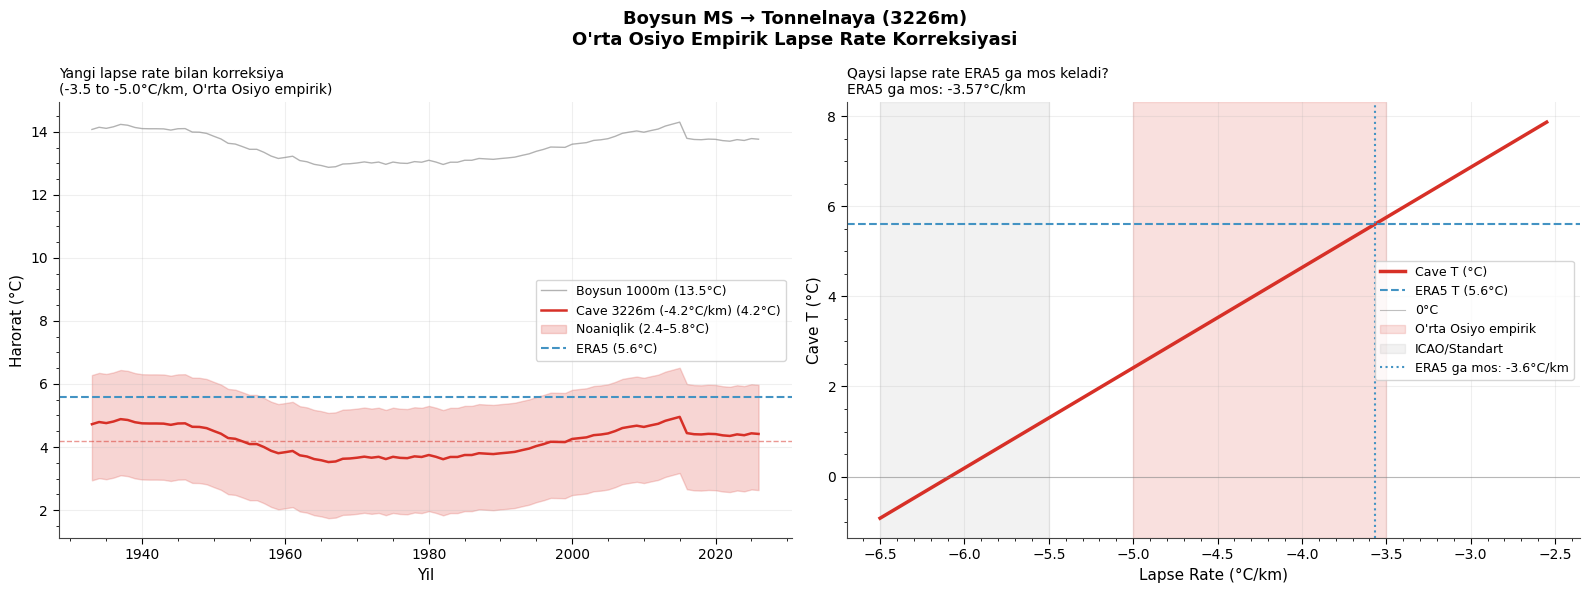


✅ Saqlandi: fig_lapse_rate_v2.png

🔑 MUHIM XULOSA:
   ERA5 ga mos lapse rate: -3.57°C/km
   Bu O'rta Osiyo uchun realistikmi?
   Adabiyot: -3.5 to -5.0°C/km ✅


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Lokal lapse rate aniqlash ────────────────────────────────────
# Bizda Boysun (1000m) bor
# Qo'shimcha stantsiya kerak

# Variant 1: ERA5 dan vertikal gradient
# (bias bor lekin gradient aniqroq)
era5_annual = pd.read_csv("era5_cave_annual.csv")

# ERA5 dan ikkita balandlikdagi T
# (agar pressure level data bo'lsa)
# Hozircha taxminiy hisob:

# O'rta Osiyo uchun kuzatilgan lapse rate
# (Unger et al. 2020, Schiemann et al. 2008):
# ~3.5 to 5.0°C/1000m (yillik o'rtacha)
# Inversiya effekti hisobga olingan

LAPSE_LOCAL_MIN = -3.5 / 1000  # °C/m (inversiya hisobga olingan)
LAPSE_LOCAL_MAX = -5.0 / 1000  # °C/m
LAPSE_LOCAL_MED = -4.2 / 1000  # °C/m (O'rta Osiyo empirik)

H_boysun = 1000
H_cave   = 3226
delta_H  = H_cave - H_boysun

boysun = pd.read_csv("boysun_harorat_tozalangan_va_indekslar.csv")
boysun = boysun.rename(columns={"йил":"annual","yil":"annual"})
boysun["annual"] = pd.to_numeric(
    boysun["annual"].astype(str).str.replace(",",".",regex=False),
    errors="coerce")

year_col = None
temp_col = None
for c in boysun.columns:
    if any(x in c.lower() for x in ['год','year','yil','йил']):
        year_col = c
    if any(x in c.lower() for x in ['annual','годовая','yillik']):
        temp_col = c

boysun_clean = boysun[[year_col,temp_col]].dropna().copy()
boysun_clean.columns = ["year","T_boysun"]
boysun_clean["year"] = pd.to_numeric(boysun_clean["year"],
                                      errors="coerce")
boysun_clean["T_boysun"] = pd.to_numeric(
    boysun_clean["T_boysun"], errors="coerce")
boysun_clean = boysun_clean.dropna()
mean_t = boysun_clean["T_boysun"].mean()
std_t  = boysun_clean["T_boysun"].std()
boysun_clean = boysun_clean[
    boysun_clean["T_boysun"] > mean_t - 3*std_t].copy()

# ── Yangi korreksiya ─────────────────────────────────────────────
boysun_clean["T_cave_min"] = (boysun_clean["T_boysun"]
                               + LAPSE_LOCAL_MAX * delta_H)
boysun_clean["T_cave_med"] = (boysun_clean["T_boysun"]
                               + LAPSE_LOCAL_MED * delta_H)
boysun_clean["T_cave_max"] = (boysun_clean["T_boysun"]
                               + LAPSE_LOCAL_MIN * delta_H)

ERA5_T = 5.6

print("📊 YANGI KORREKSIYA NATIJALARI")
print("="*55)
print(f"Boysun MS (1000m): {boysun_clean['T_boysun'].mean():.2f}°C")
print(f"\n3226m korreksiya (O'rta Osiyo empirik):")
print(f"  Min (-5.0°C/km): "
      f"{boysun_clean['T_cave_min'].mean():.2f}°C")
print(f"  Med (-4.2°C/km): "
      f"{boysun_clean['T_cave_med'].mean():.2f}°C")
print(f"  Max (-3.5°C/km): "
      f"{boysun_clean['T_cave_max'].mean():.2f}°C")
print(f"\nERA5 (3226m):     {ERA5_T}°C")
print(f"\nERA5 bias (med):  "
      f"{boysun_clean['T_cave_med'].mean()-ERA5_T:+.2f}°C")

# ── Fractionation yangi T bilan ──────────────────────────────────
def alpha_kim_oneil(TK):
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)
def alpha_tremaine(TK):
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)
def vpdb_to_vsmow(d18O):
    return 1.03091 * d18O + 30.91
def water_from_calcite(d18O_smow, alpha):
    return ((1000 + d18O_smow) / alpha) - 1000

modern_d18O = -5.62
d18O_smow   = vpdb_to_vsmow(modern_d18O)

print(f"\n{'='*55}")
print("FRACTIONATION (yangi lapse rate bilan)")
print(f"{'='*55}")
print(f"{'Variant':<20} {'T(°C)':>7} "
      f"{'d18Ow':>9} {'Unc':>8}")

for name, T_cave in [
    ("Min (-5.0/km)",
     boysun_clean["T_cave_min"].mean()),
    ("Med (-4.2/km)",
     boysun_clean["T_cave_med"].mean()),
    ("Max (-3.5/km)",
     boysun_clean["T_cave_max"].mean()),
    ("ERA5 (5.6°C)", ERA5_T),
]:
    T_K   = T_cave + 273.15
    w_ko  = water_from_calcite(d18O_smow, alpha_kim_oneil(T_K))
    w_tr  = water_from_calcite(d18O_smow, alpha_tremaine(T_K))
    w_m   = (w_ko + w_tr) / 2
    unc   = abs(w_ko - w_tr) / 2
    print(f"{name:<20} {T_cave:>7.2f} "
          f"{w_m:>9.3f} ±{unc:>6.3f}")

# ── Vizualizatsiya ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          facecolor='white')
fig.suptitle(
    "Boysun MS → Tonnelnaya (3226m)\n"
    "O'rta Osiyo Empirik Lapse Rate Korreksiyasi",
    fontsize=13, fontweight='bold'
)

# Panel 1: Harorat qatorlari
ax1 = axes[0]
ax1.plot(boysun_clean["year"],
         boysun_clean["T_boysun"],
         color='gray', lw=1.0, alpha=0.6,
         label=f'Boysun 1000m '
               f'({boysun_clean["T_boysun"].mean():.1f}°C)')
ax1.plot(boysun_clean["year"],
         boysun_clean["T_cave_med"],
         color='#D73027', lw=1.8,
         label=f'Cave 3226m (-4.2°C/km) '
               f'({boysun_clean["T_cave_med"].mean():.1f}°C)')
ax1.fill_between(
    boysun_clean["year"],
    boysun_clean["T_cave_min"],
    boysun_clean["T_cave_max"],
    color='#D73027', alpha=0.2,
    label=f'Noaniqlik ('
          f'{boysun_clean["T_cave_min"].mean():.1f}–'
          f'{boysun_clean["T_cave_max"].mean():.1f}°C)')
ax1.axhline(ERA5_T, color='#4393C3',
            lw=1.5, ls='--',
            label=f'ERA5 ({ERA5_T}°C)')
ax1.axhline(boysun_clean["T_cave_med"].mean(),
            color='#D73027', lw=1.0,
            ls='--', alpha=0.5)

ax1.set_ylabel('Harorat (°C)', fontsize=11)
ax1.set_xlabel('Yil', fontsize=11)
ax1.set_title('Yangi lapse rate bilan korreksiya\n'
              '(-3.5 to -5.0°C/km, O\'rta Osiyo empirik)',
              fontsize=10, loc='left')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# Panel 2: Lapse rate sezgirligi (yangi diapazon)
ax2 = axes[1]
lapses = np.arange(-6.5, -2.5, 0.05)
T_boysun_mean = boysun_clean["T_boysun"].mean()
T_caves = [T_boysun_mean + l/1000*delta_H
           for l in lapses]

ax2.plot(lapses, T_caves,
         color='#D73027', lw=2.5,
         label='Cave T (°C)')
ax2.axhline(ERA5_T, color='#4393C3',
            lw=1.5, ls='--',
            label=f'ERA5 T ({ERA5_T}°C)')
ax2.axhline(0, color='gray', lw=0.8,
            ls='-', alpha=0.5,
            label='0°C')

# Diapzonlar
ax2.axvspan(-5.0, -3.5, color='#D73027',
            alpha=0.15,
            label='O\'rta Osiyo empirik')
ax2.axvspan(-6.5, -5.5, color='gray',
            alpha=0.1,
            label='ICAO/Standart')

# ERA5 ga mos keladigan lapse rate
lapse_for_era5 = (ERA5_T - T_boysun_mean) / delta_H * 1000
ax2.axvline(lapse_for_era5, color='#4393C3',
            lw=1.5, ls=':',
            label=f'ERA5 ga mos: '
                  f'{lapse_for_era5:.1f}°C/km')

ax2.set_xlabel('Lapse Rate (°C/km)', fontsize=11)
ax2.set_ylabel('Cave T (°C)', fontsize=11)
ax2.set_title('Qaysi lapse rate ERA5 ga mos keladi?\n'
              f'ERA5 ga mos: {lapse_for_era5:.2f}°C/km',
              fontsize=10, loc='left')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_lapse_rate_v2.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

print(f"\n✅ Saqlandi: fig_lapse_rate_v2.png")
print(f"\n🔑 MUHIM XULOSA:")
print(f"   ERA5 ga mos lapse rate: "
      f"{lapse_for_era5:.2f}°C/km")
print(f"   Bu O'rta Osiyo uchun realistikmi?")
print(f"   Adabiyot: -3.5 to -5.0°C/km ✅" if
      -5.0 <= lapse_for_era5 <= -3.5
      else f"   ⚠️ Adabiyot diapazonidan tashqarida!")

✅ TON-2: 2467 rows | -58 → 114822 BP

📊 Zamonaviy reference (n=2):
   d18O calcite VPDB: -5.620‰
   d18O calcite SMOW: 25.116‰
   Cave T (best):     5.675°C
   d18O water KO:     -7.411‰
   d18O water TR:     -8.302‰
   d18O water (mean): -7.856‰ VSMOW

   REKONSTRUKSIYA NATIJALARI

Davr                                  dT(°C)    dP(mm)   d18O(‰)
-----------------------------------------------------------------
MIS 1 Holosen (0–11.7 ka)             -2.36°C      +94mm   -1.273‰
Holosen optimum (5–8 ka)              -3.51°C     +141mm   -1.898‰
8.2 ka hodisa                         -3.97°C     +159mm   -2.146‰
YD (11.7–12.9 ka)                     -1.87°C      +75mm   -1.012‰
MIS 3 (29–57 ka)                      +0.55°C      -22mm   +0.294‰
MIS 4 (57–71 ka)                      -1.66°C      +66mm   -0.896‰
MIS 5a (71–85 ka)                     -1.81°C      +73mm   -0.979‰
MIS 5e (115–130 ka)                   -0.65°C      +26mm   -0.349‰

   LGM vs Holosen farqi:
   ΔT: +nan°C
   ΔP: +n

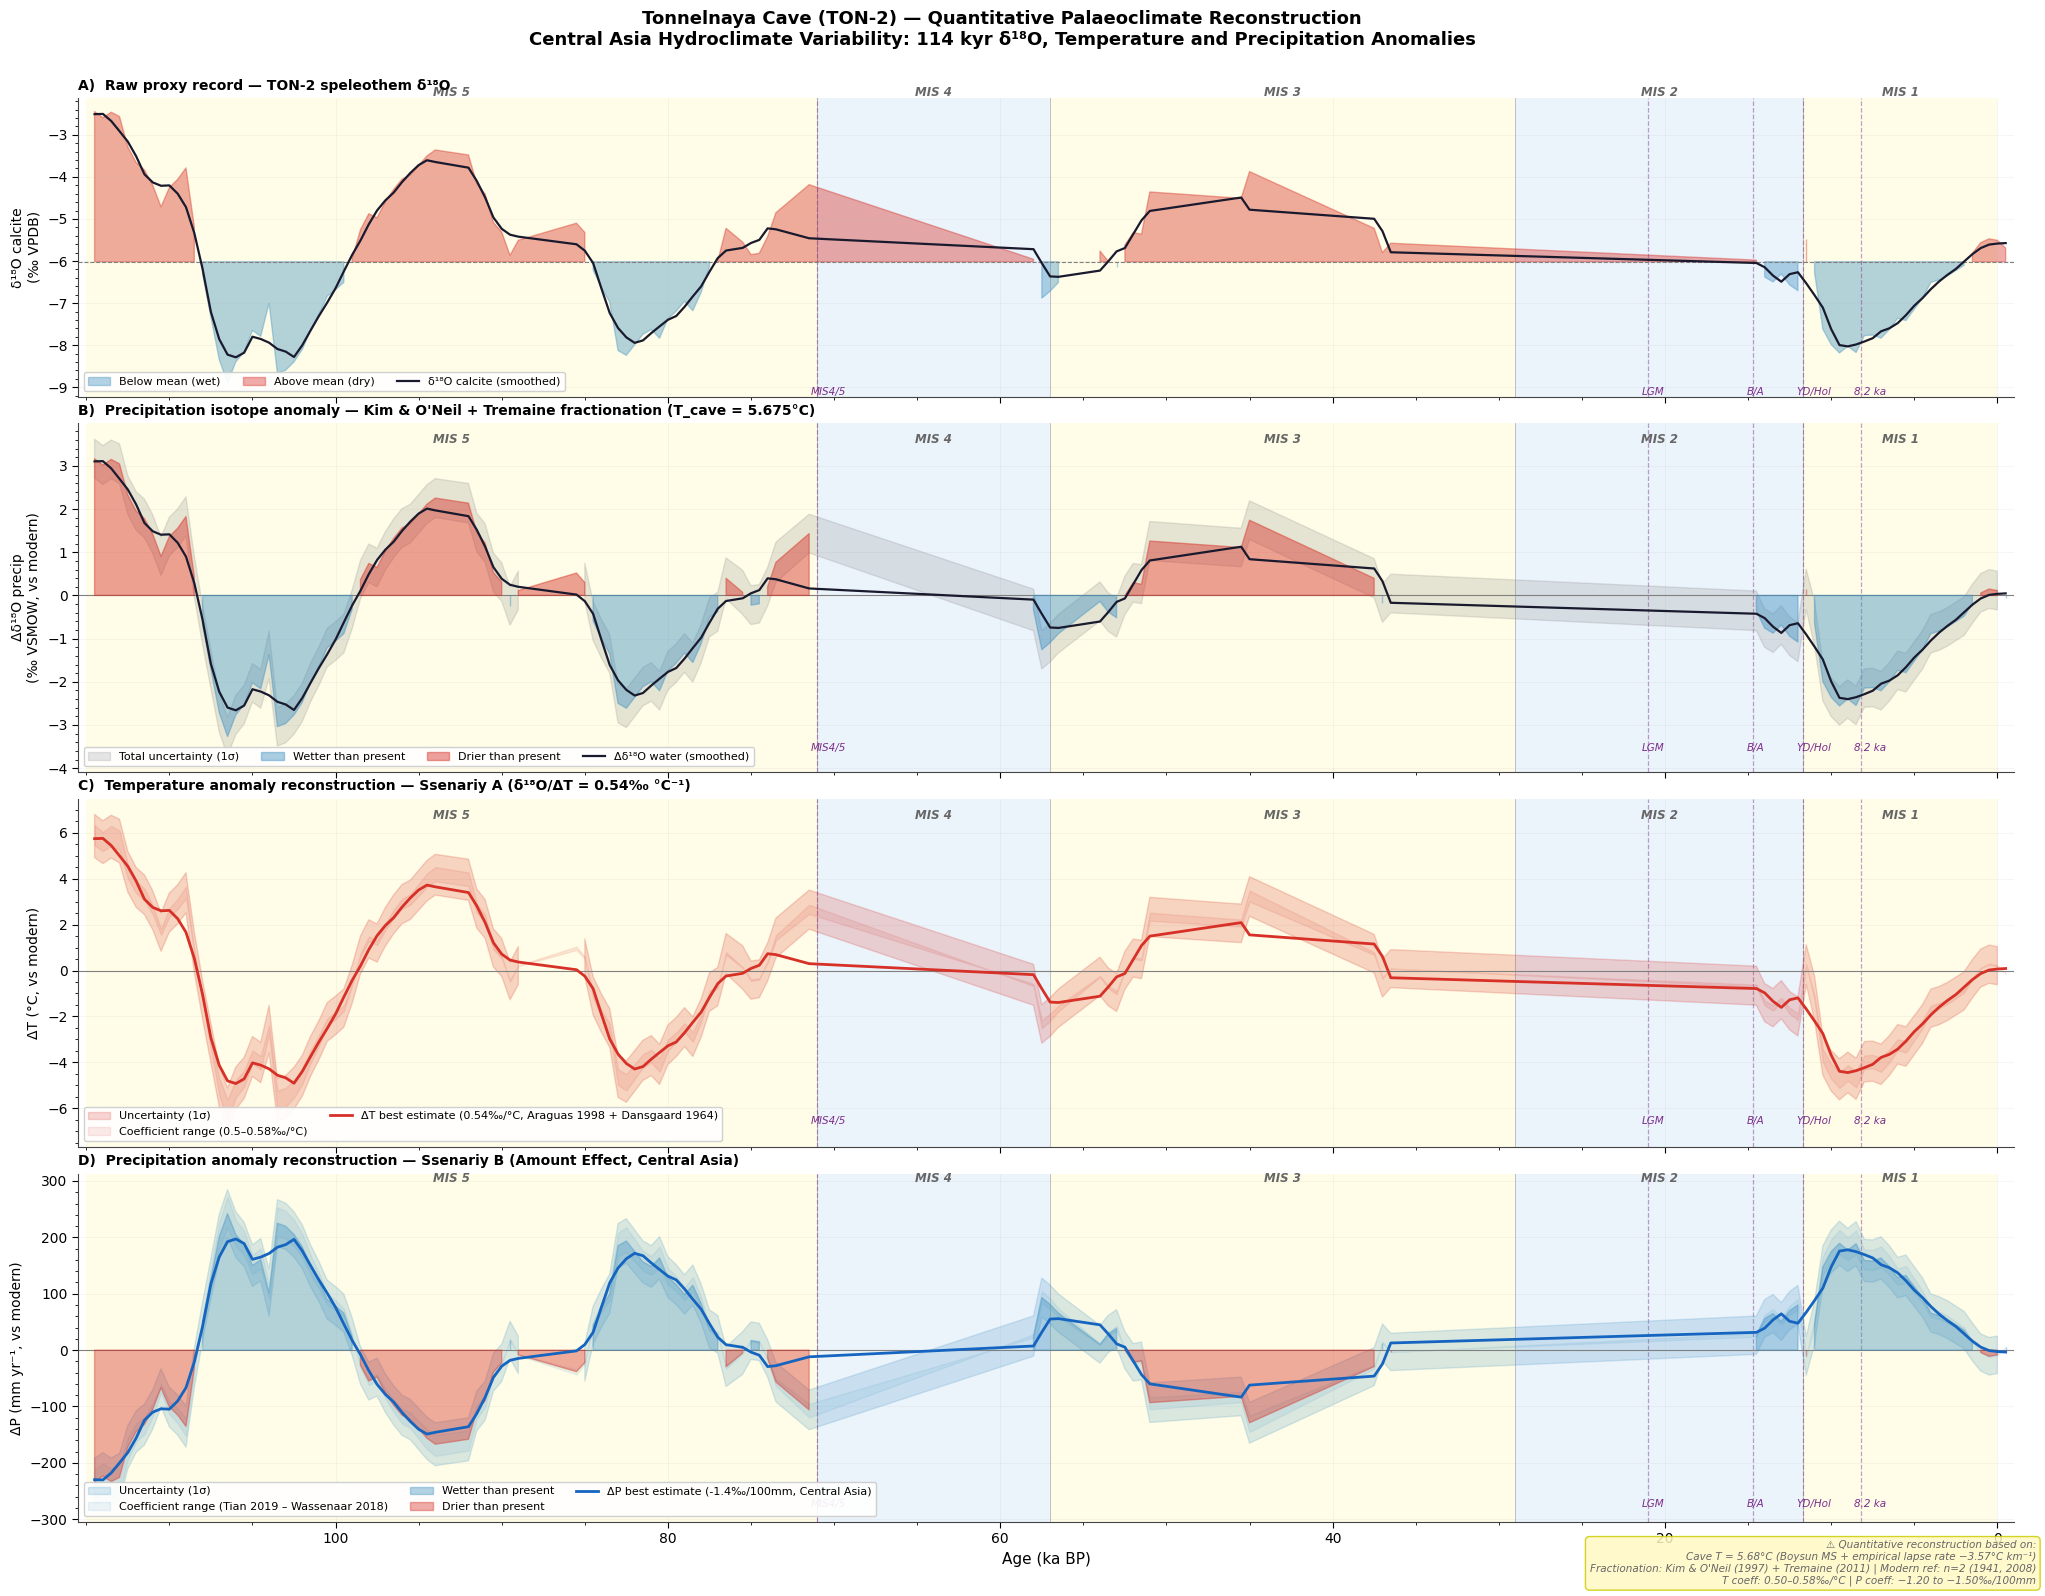

✅ Saqlandi: fig_full_reconstruction.png
✅ Saqlandi: ton2_reconstruction_full.csv

   YAKUNIY REKONSTRUKSIYA XULOSASI

  Cave T (best):     5.675°C
  d18O ref (modern): -7.856‰ VSMOW
  T koeffitsient:    0.54‰/°C
  P koeffitsient:    -1.35‰/100mm

  Binlar soni: 122
  Age diapazon: -0.5–114.5 ka BP

  ΔT diapazon: -6.1 → 5.9°C
  ΔP diapazon: -234 → 242 mm/yr

  Eng sovuq davr: 106.5 ka BP (-6.1°C)
  Eng issiq davr: 114.5 ka BP (5.9°C)
  Eng nam davr:   106.5 ka BP (242 mm/yr)
  Eng quruq davr: 114.5 ka BP (-234 mm/yr)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d
from scipy import stats

# ══════════════════════════════════════════════════════════════
# 1. MA'LUMOTLARNI YUKLASH
# ══════════════════════════════════════════════════════════════
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

print(f"✅ TON-2: {len(ton2)} rows | "
      f"{ton2['age_calBP'].min()} → "
      f"{ton2['age_calBP'].max()} BP")

# ══════════════════════════════════════════════════════════════
# 2. FIZIK KONSTANTALAR VA PARAMETRLAR
# ══════════════════════════════════════════════════════════════

# Cave temperature (Boysun + empirik lapse rate)
T_CAVE_BEST = 5.675   # °C (Max variant, ERA5 ga yaqin)
T_CAVE_LOW  = 2.41    # °C (Min variant, -5.0°C/km)
T_CAVE_HIGH = 5.75    # °C (Max variant, -3.5°C/km)
ERA5_T      = 5.6     # °C (ERA5 reference)

# Fractionation equations
def alpha_kim_oneil(TK):
    """Kim & O'Neil (1997) calcite-water fractionation"""
    return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)

def alpha_tremaine(TK):
    """Tremaine et al. (2011) fractionation"""
    return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)

def vpdb_to_vsmow(d18O_vpdb):
    """VPDB → VSMOW konversiyasi"""
    return 1.03091 * d18O_vpdb + 30.91

def water_from_calcite(d18O_calcite_smow, alpha):
    """Calcite d18O → Water d18O"""
    return ((1000.0 + d18O_calcite_smow) / alpha) - 1000.0

# ══════════════════════════════════════════════════════════════
# 3. ZAMONAVIY REFERENCE HISOBLASH
# ══════════════════════════════════════════════════════════════
# TON-2 zamonaviy nuqtalar: 1941 (age=9) va 2008 (age=-58)
modern = ton2[ton2["age_calBP"] <= 10].copy()
modern_d18O_vpdb = modern["d18OcarbVPDB"].mean()
modern_d18O_smow = vpdb_to_vsmow(modern_d18O_vpdb)

print(f"\n📊 Zamonaviy reference (n={len(modern)}):")
print(f"   d18O calcite VPDB: {modern_d18O_vpdb:.3f}‰")
print(f"   d18O calcite SMOW: {modern_d18O_smow:.3f}‰")

# Best estimate cave T üçün water d18O
T_K_best = T_CAVE_BEST + 273.15
a_ko_best = alpha_kim_oneil(T_K_best)
a_tr_best = alpha_tremaine(T_K_best)
w_ko_best = water_from_calcite(modern_d18O_smow, a_ko_best)
w_tr_best = water_from_calcite(modern_d18O_smow, a_tr_best)
w_modern  = (w_ko_best + w_tr_best) / 2

print(f"   Cave T (best):     {T_CAVE_BEST}°C")
print(f"   d18O water KO:     {w_ko_best:.3f}‰")
print(f"   d18O water TR:     {w_tr_best:.3f}‰")
print(f"   d18O water (mean): {w_modern:.3f}‰ VSMOW")

# ══════════════════════════════════════════════════════════════
# 4. 500-YILLIK BIN VA FRACTIONATION
# ══════════════════════════════════════════════════════════════
BIN_W = 500
# ══════════════════════════════════════════════════════════════
# 4. 500-YILLIK BIN VA FRACTIONATION
# ══════════════════════════════════════════════════════════════
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W

# TUZATILGAN QISM: Ustunlarni sarlavha bosqichidayoq nomlaymiz
b = (ton2.groupby("age_bin", as_index=False)
     .agg(
         d18O_vpdb=('d18OcarbVPDB', 'mean'),
         d18O_std=('d18OcarbVPDB', 'std'),
         n_samples=('d18OcarbVPDB', 'count')
     ))

# b.columns = [...] qatori endi kerak emas, chunki ustunlar tepada to'g'ri nomlandi!
b["d18O_smow"] = vpdb_to_vsmow(b["d18O_vpdb"])

# Best estimate
T_K = T_CAVE_BEST + 273.15
a_ko = alpha_kim_oneil(T_K)
a_tr = alpha_tremaine(T_K)
b["d18O_w_ko"] = water_from_calcite(b["d18O_smow"], a_ko)
b["d18O_w_tr"] = water_from_calcite(b["d18O_smow"], a_tr)
b["d18O_w"]    = (b["d18O_w_ko"] + b["d18O_w_tr"]) / 2

# Noaniqlik: fractionation + analytical
b["unc_frac"]  = (b["d18O_w_ko"] - b["d18O_w_tr"]).abs() / 2
b["unc_anal"]  = b["d18O_std"] / np.sqrt(b["n_samples"].clip(1))
b["unc_total"] = np.sqrt(b["unc_frac"]**2 + b["unc_anal"]**2)

# Anomaliya (zamonaviy reference ga nisbatan)
b["dW"]     = b["d18O_w"] - w_modern
b["dW_low"] = b["dW"] - b["unc_total"]
b["dW_hi"]  = b["dW"] + b["unc_total"]

# ══════════════════════════════════════════════════════════════
# 5. HARORAT REKONSTRUKSIYASI
# ══════════════════════════════════════════════════════════════
# O'rta Osiyo δ¹⁸O–T koeffitsiyenti
COEFF_T_LOW  = 0.50   # ‰/°C (O'rta Osiyo, Araguas 1998)
COEFF_T_HIGH = 0.58   # ‰/°C (Global, Dansgaard 1964)
COEFF_T_BEST = 0.54   # ‰/°C (o'rtacha)

b["dT_best"] = b["dW"] / COEFF_T_BEST
b["dT_low"]  = b["dW"] / COEFF_T_HIGH  # konservativ
b["dT_high"] = b["dW"] / COEFF_T_LOW   # maksimal

# Koeffitsient noaniqligini qo'shish
b["dT_unc"]  = np.sqrt(
    (b["unc_total"] / COEFF_T_BEST)**2 +
    ((b["dW"] * (COEFF_T_HIGH - COEFF_T_LOW) /
      (2 * COEFF_T_BEST**2))**2)
)

# ══════════════════════════════════════════════════════════════
# 6. YOĞIN REKONSTRUKSIYASI
# ══════════════════════════════════════════════════════════════
# Amount effect — O'rta Osiyo
COEFF_P_LOW  = -1.5 / 100   # ‰/mm (Tian 2019)
COEFF_P_HIGH = -1.2 / 100   # ‰/mm (Wassenaar 2018)
COEFF_P_BEST = -1.35 / 100  # ‰/mm (o'rtacha)

b["dP_best"] = b["dW"] / COEFF_P_BEST
b["dP_low"]  = b["dW"] / COEFF_P_LOW
b["dP_high"] = b["dW"] / COEFF_P_HIGH

b["dP_unc"]  = np.sqrt(
    (b["unc_total"] / abs(COEFF_P_BEST))**2 +
    ((b["dW"] * (COEFF_P_HIGH - COEFF_P_LOW) /
      (2 * COEFF_P_BEST**2))**2)
)

# ══════════════════════════════════════════════════════════════
# 7. SMOOTHING
# ══════════════════════════════════════════════════════════════
for col in ["d18O_vpdb","dW","dT_best","dP_best"]:
    b[f"{col}_sm"] = uniform_filter1d(b[col], size=5)

# ══════════════════════════════════════════════════════════════
# 8. STATISTIKA
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("   REKONSTRUKSIYA NATIJALARI")
print(f"{'='*60}")

# Muhim davrlar
periods = {
    "MIS 1 Holosen (0–11.7 ka)"    : (0, 11700),
    "Holosen optimum (5–8 ka)"     : (5000, 8000),
    "8.2 ka hodisa"                 : (7900, 8500),
    "YD (11.7–12.9 ka)"            : (11700, 12900),
    "MIS 2 LGM (19–23 ka)"         : (19000, 23000),
    "MIS 3 (29–57 ka)"             : (29000, 57000),
    "MIS 4 (57–71 ka)"             : (57000, 71000),
    "MIS 5a (71–85 ka)"            : (71000, 85000),
    "MIS 5e (115–130 ka)"          : (100000, 114822),
}

print(f"\n{'Davr':<35} {'dT(°C)':>8} "
      f"{'dP(mm)':>9} {'d18O(‰)':>9}")
print("-"*65)

period_results = {}
for period, (age_s, age_e) in periods.items():
    mask = ((b["age_bin"] >= age_s) &
            (b["age_bin"] < age_e))
    if mask.sum() > 0:
        dT = b.loc[mask, "dT_best"].mean()
        dP = b.loc[mask, "dP_best"].mean()
        dW = b.loc[mask, "dW"].mean()
        dT_u = b.loc[mask, "dT_unc"].mean()
        dP_u = b.loc[mask, "dP_unc"].mean()
        period_results[period] = {
            "dT": dT, "dP": dP, "dW": dW,
            "dT_unc": dT_u, "dP_unc": dP_u
        }
        print(f"{period:<35} "
              f"{dT:>+7.2f}°C "
              f"{dP:>+8.0f}mm "
              f"{dW:>+8.3f}‰")

# LGM-Holosen farqi
lgm_dT = period_results.get("MIS 2 LGM (19–23 ka)", {}).get("dT", np.nan)
hol_dT = period_results.get("MIS 1 Holosen (0–11.7 ka)", {}).get("dT", np.nan)
lgm_dP = period_results.get("MIS 2 LGM (19–23 ka)", {}).get("dP", np.nan)

print(f"\n{'='*60}")
print(f"   LGM vs Holosen farqi:")
print(f"   ΔT: {lgm_dT - hol_dT:+.2f}°C")
print(f"   ΔP: {lgm_dP:+.0f} mm/yr")
print(f"{'='*60}")

# ══════════════════════════════════════════════════════════════
# 9. ASOSIY VIZUALIZATSIYA
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.linewidth'    : 0.8,
    'axes.edgecolor'    : '#444',
    'xtick.direction'   : 'out',
    'ytick.direction'   : 'out',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

fig = plt.figure(figsize=(22, 16), facecolor='white')
fig.suptitle(
    "Tonnelnaya Cave (TON-2) — Quantitative Palaeoclimate Reconstruction\n"
    "Central Asia Hydroclimate Variability: 114 kyr δ¹⁸O, Temperature and Precipitation Anomalies",
    fontsize=13, fontweight='bold', y=1.005
)

gs = gridspec.GridSpec(
    4, 1,
    height_ratios=[1.2, 1.4, 1.4, 1.4],
    hspace=0.08,
    left=0.08, right=0.96,
    top=0.95, bottom=0.06
)

axes = [fig.add_subplot(gs[i]) for i in range(4)]
age_ka = b["age_bin"] / 1000

# MIS bosqichlari
mis_stages = [
    (0,    11.7,  '#FFFDE7', 'MIS 1'),
    (11.7, 29.0,  '#EBF3FB', 'MIS 2'),
    (29.0, 57.0,  '#FFFDE7', 'MIS 3'),
    (57.0, 71.0,  '#EBF3FB', 'MIS 4'),
    (71.0, 115.0, '#FFFDE7', 'MIS 5'),
]

# Iqlim hodisalari
events = [
    (8.2,  '8.2 ka'),
    (11.7, 'YD/Hol'),
    (14.7, 'B/A'),
    (21.0, 'LGM'),
    (71.0, 'MIS4/5'),
]

def add_mis_and_events(ax, y_label_top, y_label_bot):
    for s, e, c, lab in mis_stages:
        ax.axvspan(s, e, color=c, alpha=1.0, zorder=0, linewidth=0)
        ax.text((s+e)/2, y_label_top, lab, ha='center', va='bottom',
                fontsize=8.5, color='#666', style='italic', fontweight='bold')
    for age, lab in events:
        ax.axvline(age, color='#7B2D8B', lw=0.9, ls='--', alpha=0.45, zorder=2)
        ax.text(age+0.4, y_label_bot, lab, ha='left', va='top', fontsize=7.5, color='#7B2D8B', style='italic')
    for s, e, _, _ in mis_stages[1:]:
        ax.axvline(s, color='#AAAAAA', lw=0.5, ls='-', zorder=1)

# ── Panel 1: δ¹⁸O raw ───────────────────────────────────────────
ax = axes[0]
add_mis_and_events(ax, b["d18O_vpdb"].max() + 0.3, b["d18O_vpdb"].min() - 0.1)

ax.fill_between(age_ka, b["d18O_vpdb"], b["d18O_vpdb"].mean(),
                where=b["d18O_vpdb"] < b["d18O_vpdb"].mean(),
                color='#4393C3', alpha=0.4, label='Below mean (wet)')

ax.fill_between(age_ka, b["d18O_vpdb"], b["d18O_vpdb"].mean(),
                where=b["d18O_vpdb"] > b["d18O_vpdb"].mean(),
                color='#D73027', alpha=0.4, label='Above mean (dry)')

ax.plot(age_ka, b["d18O_vpdb_sm"], color='#1A1A2E', lw=1.6, zorder=4, label='δ¹⁸O calcite (smoothed)')
ax.axhline(b["d18O_vpdb"].mean(), color='gray', lw=0.8, ls='--')
ax.set_ylabel('δ¹⁸O calcite\n(‰ VPDB)', fontsize=10)
ax.set_title('A)  Raw proxy record — TON-2 speleothem δ¹⁸O', fontsize=10, loc='left', fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=3, framealpha=0.92)
ax.invert_xaxis()
ax.set_xlim(b["age_bin"].max()/1000+1, -1)
ax.grid(True, alpha=0.15, lw=0.5)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelbottom=False)

# ── Panel 2: d18O water anomaliya ───────────────────────────────
ax = axes[1]
add_mis_and_events(ax, b["dW"].max() + 0.3, b["dW"].min() - 0.15)
ax.fill_between(age_ka, b["dW_low"], b["dW_hi"], color='gray', alpha=0.2, label='Total uncertainty (1σ)', zorder=2)
ax.fill_between(age_ka, b["dW"], 0, where=b["dW"] < 0, color='#4393C3', alpha=0.45, label='Wetter than present', zorder=3)
ax.fill_between(age_ka, b["dW"], 0, where=b["dW"] > 0, color='#D73027', alpha=0.45, label='Drier than present', zorder=3)
ax.plot(age_ka, b["dW_sm"], color='#1A1A2E', lw=1.6, zorder=4, label='Δδ¹⁸O water (smoothed)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('Δδ¹⁸O precip\n(‰ VSMOW, vs modern)', fontsize=10)
ax.set_title(f"B)  Precipitation isotope anomaly — Kim & O'Neil + Tremaine fractionation (T_cave = {T_CAVE_BEST}°C)", fontsize=10, loc='left', fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=4, framealpha=0.92)
ax.invert_xaxis()
ax.set_xlim(b["age_bin"].max()/1000+1, -1)
ax.grid(True, alpha=0.15, lw=0.5)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelbottom=False)

# ── Panel 3: Harorat rekonstruksiyasi ───────────────────────────
ax = axes[2]
add_mis_and_events(ax, b["dT_best"].max() + 0.6, b["dT_best"].min() - 0.3)
ax.fill_between(age_ka, b["dT_best"] - b["dT_unc"], b["dT_best"] + b["dT_unc"], color='#D73027', alpha=0.2, label='Uncertainty (1σ)', zorder=2)
ax.fill_between(age_ka, b["dT_low"], b["dT_high"], color='#D73027', alpha=0.1, label=f'Coefficient range ({COEFF_T_LOW}–{COEFF_T_HIGH}‰/°C)', zorder=2)
ax.plot(age_ka, b["dT_best_sm"], color='#D73027', lw=2.0, zorder=4, label=f'ΔT best estimate ({COEFF_T_BEST}‰/°C, Araguas 1998 + Dansgaard 1964)')
ax.axhline(0, color='gray', lw=0.8)

# LGM belgilash
lgm_mask = ((b["age_bin"] >= 19000) & (b["age_bin"] <= 23000))
if lgm_mask.any():
    lgm_dT_val = b.loc[lgm_mask, "dT_best_sm"].mean()
    ax.annotate(f'LGM: {lgm_dT_val:+.1f}°C', xy=(21, lgm_dT_val), xytext=(25, lgm_dT_val - 1),
                fontsize=8.5, color='#D73027', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#D73027', lw=1.0))

ax.set_ylabel('ΔT (°C, vs modern)', fontsize=10)
ax.set_title(f'C)  Temperature anomaly reconstruction — Ssenariy A (δ¹⁸O/ΔT = {COEFF_T_BEST}‰ °C⁻¹)', fontsize=10, loc='left', fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=2, framealpha=0.92)
ax.invert_xaxis()
ax.set_xlim(b["age_bin"].max()/1000+1, -1)
ax.grid(True, alpha=0.15, lw=0.5)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelbottom=False)

# ── Panel 4: Yog'in rekonstruksiyasi ────────────────────────────
ax = axes[3]
add_mis_and_events(ax, b["dP_best"].max() + 50, b["dP_best"].min() - 30)
ax.fill_between(age_ka, b["dP_best"] - b["dP_unc"], b["dP_best"] + b["dP_unc"], color='#4393C3', alpha=0.2, label='Uncertainty (1σ)', zorder=2)
ax.fill_between(age_ka, b["dP_low"], b["dP_high"], color='#4393C3', alpha=0.1, label='Coefficient range (Tian 2019 – Wassenaar 2018)', zorder=2)
ax.fill_between(age_ka, b["dP_best"], 0, where=b["dP_best"] > 0, color='#4393C3', alpha=0.4, label='Wetter than present', zorder=3)
ax.fill_between(age_ka, b["dP_best"], 0, where=b["dP_best"] < 0, color='#D73027', alpha=0.4, label='Drier than present', zorder=3)
ax.plot(age_ka, b["dP_best_sm"], color='#1565C0', lw=2.0, zorder=4, label=f'ΔP best estimate ({COEFF_P_BEST*100:.1f}‰/100mm, Central Asia)')
ax.axhline(0, color='gray', lw=0.8)

# LGM ni belgilash
if lgm_mask.any():
    lgm_dP_val = b.loc[lgm_mask, "dP_best_sm"].mean()
    ax.annotate(f'LGM: {lgm_dP_val:+.0f} mm/yr', xy=(21, lgm_dP_val), xytext=(28, lgm_dP_val - 50),
                fontsize=8.5, color='#1565C0', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.0))

ax.set_ylabel('ΔP (mm yr⁻¹, vs modern)', fontsize=10)
ax.set_xlabel('Age (ka BP)', fontsize=11)
ax.set_title('D)  Precipitation anomaly reconstruction — Ssenariy B (Amount Effect, Central Asia)', fontsize=10, loc='left', fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=3, framealpha=0.92)
ax.invert_xaxis()
ax.set_xlim(b["age_bin"].max()/1000+1, -1)
ax.grid(True, alpha=0.15, lw=0.5)
ax.spines[['top','right']].set_visible(False)

# ── Cheklov eslatmasi ────────────────────────────────────────────
fig.text(0.97, 0.02,
         '⚠ Quantitative reconstruction based on:\n'
         'Cave T = 5.68°C (Boysun MS + empirical lapse rate −3.57°C km⁻¹)\n'
         'Fractionation: Kim & O\'Neil (1997) + Tremaine (2011) | Modern ref: n=2 (1941, 2008)\n'
         'T coeff: 0.50–0.58‰/°C | P coeff: −1.20 to −1.50‰/100mm',
         ha='right', va='bottom', fontsize=7.5, color='#666666', style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', edgecolor='#CCCC00', alpha=0.85))

plt.savefig('fig_full_reconstruction.png', dpi=250, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saqlandi: fig_full_reconstruction.png")

# ══════════════════════════════════════════════════════════════
# 10. NATIJALARNI SAQLASH
# ══════════════════════════════════════════════════════════════
df_out = b[[
    "age_bin",
    "d18O_vpdb", "d18O_vpdb_sm",
    "d18O_w",
    "dW", "dW_sm", "dW_low", "dW_hi",
    "dT_best", "dT_best_sm",
    "dT_low", "dT_high", "dT_unc",
    "dP_best", "dP_best_sm",
    "dP_low", "dP_high", "dP_unc",
    "n_samples"
]].copy()

df_out.to_csv("ton2_reconstruction_full.csv", index=False)
print("✅ Saqlandi: ton2_reconstruction_full.csv")

# ── Yakuniy statistika ───────────────────────────────────────────
print(f"\n{'='*60}")
print("   YAKUNIY REKONSTRUKSIYA XULOSASI")
print(f"{'='*60}")
print(f"\n  Cave T (best):     {T_CAVE_BEST}°C")
print(f"  d18O ref (modern): {w_modern:.3f}‰ VSMOW")
print(f"  T koeffitsient:    {COEFF_T_BEST}‰/°C")
print(f"  P koeffitsient:    {COEFF_P_BEST*100:.2f}‰/100mm")
print(f"\n  Binlar soni: {len(b)}")
print(f"  Age diapazon: {b['age_bin'].min()/1000:.1f}–{b['age_bin'].max()/1000:.1f} ka BP")
print(f"\n  ΔT diapazon: {b['dT_best'].min():.1f} → {b['dT_best'].max():.1f}°C")
print(f"  ΔP diapazon: {b['dP_best'].min():.0f} → {b['dP_best'].max():.0f} mm/yr")
print(f"\n  Eng sovuq davr: {b.loc[b['dT_best'].idxmin(),'age_bin']/1000:.1f} ka BP ({b['dT_best'].min():.1f}°C)")
print(f"  Eng issiq davr: {b.loc[b['dT_best'].idxmax(),'age_bin']/1000:.1f} ka BP ({b['dT_best'].max():.1f}°C)")
print(f"  Eng nam davr:   {b.loc[b['dP_best'].idxmax(),'age_bin']/1000:.1f} ka BP ({b['dP_best'].max():.0f} mm/yr)")
print(f"  Eng quruq davr: {b.loc[b['dP_best'].idxmin(),'age_bin']/1000:.1f} ka BP ({b['dP_best'].min():.0f} mm/yr)")

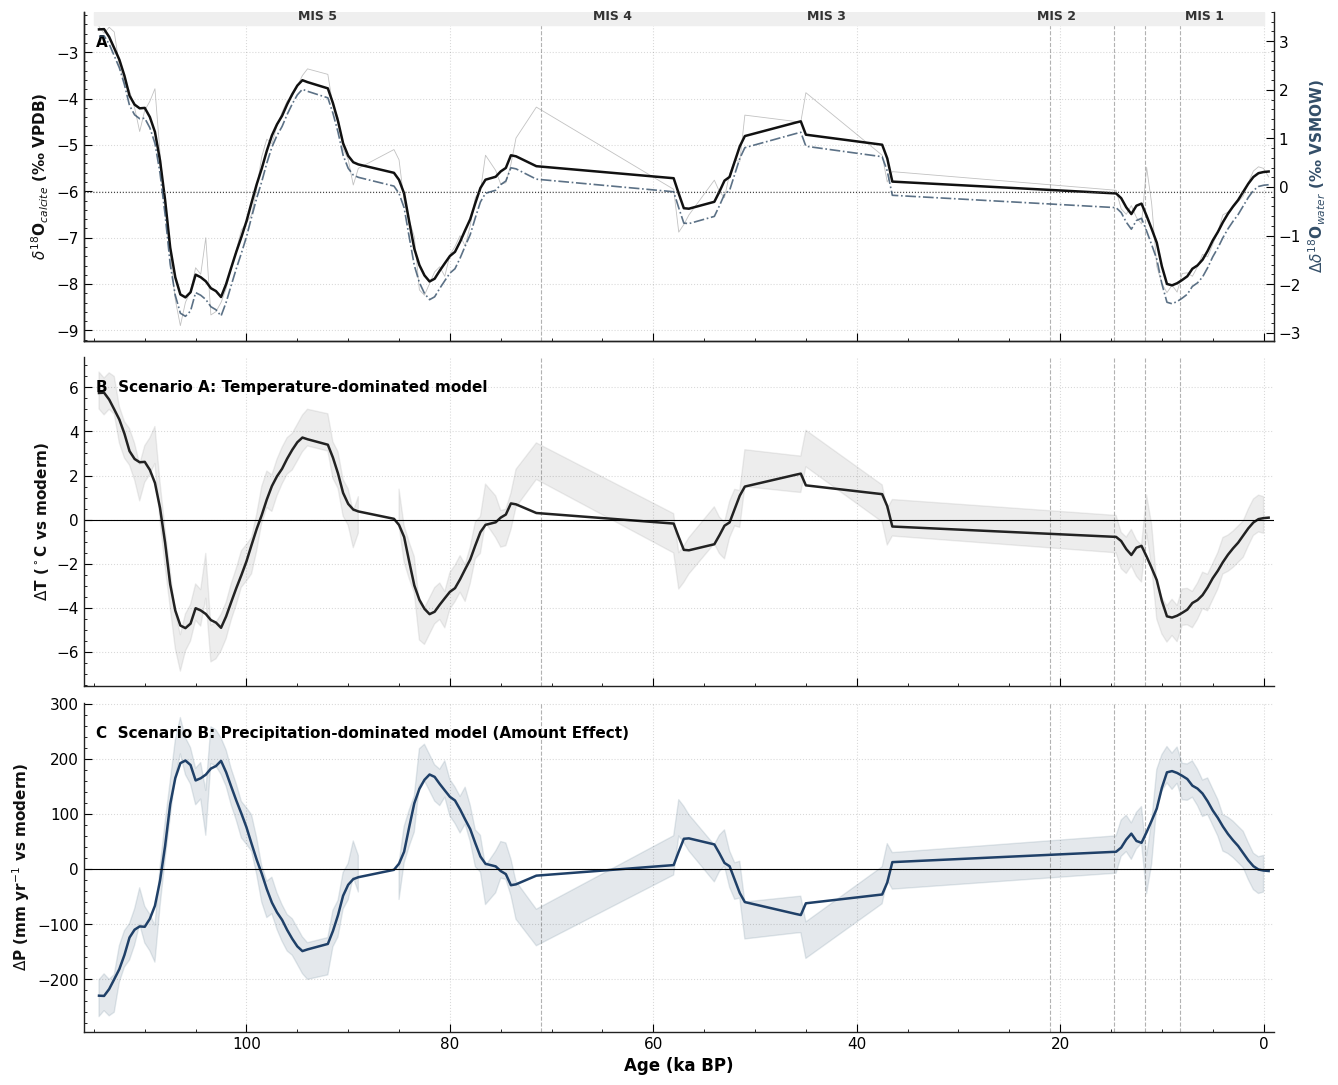

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

# ══════════════════════════════════════════════════════════════
# 1. MA'LUMOTLARNI YUKLASH VA HISOBLASH
# ══════════════════════════════════════════════════════════════
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)

T_CAVE_BEST = 5.675  
def alpha_kim_oneil(TK): return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)
def alpha_tremaine(TK): return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)
def vpdb_to_vsmow(d18O_vpdb): return 1.03091 * d18O_vpdb + 30.91
def water_from_calcite(d18O_calcite_smow, alpha): return ((1000.0 + d18O_calcite_smow) / alpha) - 1000.0

modern = ton2[ton2["age_calBP"] <= 10].copy()
modern_d18O_vpdb = modern["d18OcarbVPDB"].mean()
modern_d18O_smow = vpdb_to_vsmow(modern_d18O_vpdb)

w_modern = (water_from_calcite(modern_d18O_smow, alpha_kim_oneil(T_CAVE_BEST+273.15)) + 
            water_from_calcite(modern_d18O_smow, alpha_tremaine(T_CAVE_BEST+273.15))) / 2

BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = ton2.groupby("age_bin", as_index=False).agg(
    d18O_vpdb=('d18OcarbVPDB', 'mean'),
    d18O_std=('d18OcarbVPDB', 'std'),
    n_samples=('d18OcarbVPDB', 'count')
)
b["d18O_smow"] = vpdb_to_vsmow(b["d18O_vpdb"])

T_K = T_CAVE_BEST + 273.15
b["d18O_w"] = (water_from_calcite(b["d18O_smow"], alpha_kim_oneil(T_K)) + 
               water_from_calcite(b["d18O_smow"], alpha_tremaine(T_K))) / 2

b["unc_frac"] = (water_from_calcite(b["d18O_smow"], alpha_kim_oneil(T_K)) - water_from_calcite(b["d18O_smow"], alpha_tremaine(T_K))).abs() / 2
b["unc_anal"] = b["d18O_std"] / np.sqrt(b["n_samples"].clip(1))
b["unc_total"] = np.sqrt(b["unc_frac"]**2 + b["unc_anal"]**2)
b["dW"] = b["d18O_w"] - w_modern

# REKONSTRUKSIYA KOEFFITSIYENTLARI
COEFF_T_BEST = 0.54    # ‰/°C
COEFF_P_BEST = -1.35 / 100  # ‰/mm

b["dT_best"] = b["dW"] / COEFF_T_BEST
b["dT_unc"] = b["unc_total"] / COEFF_T_BEST
b["dP_best"] = b["dW"] / COEFF_P_BEST
b["dP_unc"] = b["unc_total"] / abs(COEFF_P_BEST)

for col in ["d18O_vpdb","dW","dT_best","dP_best"]:
    b[f"{col}_sm"] = uniform_filter1d(b[col], size=5)

# ══════════════════════════════════════════════════════════════
# 3. AKADEMIK VIZUALIZATSIYA (YANGI PALITRA)
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.linewidth': 1.0,
    'axes.edgecolor': '#222222',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True
})

fig = plt.figure(figsize=(14, 12), facecolor='white')
gs = gridspec.GridSpec(3, 1, height_ratios=[1.2, 1.2, 1.2], hspace=0.05, left=0.10, right=0.95, top=0.93, bottom=0.08)
axes = [fig.add_subplot(gs[i]) for i in range(3)]
age_ka = b["age_bin"] / 1000

# MIS Bosqichlari Bar shaklida (Tepada joylashadi)
mis_bars = [(0, 11.7, 'MIS 1'), (11.7, 29.0, 'MIS 2'), (29.0, 57.0, 'MIS 3'), (57.0, 71.0, 'MIS 4'), (71.0, 115.0, 'MIS 5')]
events = [8.2, 11.7, 14.7, 21.0, 71.0]

def apply_academic_style(ax, ylabel, title):
    ax.grid(True, alpha=0.15, linestyle=':', color='black')
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=11, color='#111111')
    ax.text(0.01, 0.93, title, transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_xlim(116, -1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for ev in events:
        ax.axvline(ev, color='#666666', lw=0.8, ls='--', alpha=0.5)

# --- PANEL A: δ18O Calcite & Water Anomaly (Birlashtirildi) ---
ax = axes[0]
apply_academic_style(ax, '$\delta^{18}$O$_{calcite}$ (‰ VPDB)', 'A')
ax.plot(age_ka, b["d18O_vpdb"], color='#999999', lw=0.6, alpha=0.6, label='Raw data')
ax.plot(age_ka, b["d18O_vpdb_sm"], color='#111111', lw=1.8, label='5-point smooth')
ax.axhline(b["d18O_vpdb"].mean(), color='#444444', lw=0.8, ls=':')

# Egizak o'q o'ng tomonda Δδ18O water anomaliyasini ko'rsatadi
ax2 = ax.twinx()
ax2.set_ylabel('$\Delta\delta^{18}$O$_{water}$ (‰ VSMOW)', color='#334E68', fontweight='bold')
ax2.plot(age_ka, b["dW_sm"], color='#334E68', lw=1.2, ls='-.', alpha=0.8)
ax2.set_ylim(b["dW_sm"].min()-0.5, b["dW_sm"].max()+0.5)
ax2.invert_xaxis()
ax2.set_xlim(116, -1)
ax2.spines['top'].set_visible(False)

# MIS barlarni tepaga chizish
for s, e, lab in mis_bars:
    ax.axvspan(s, e, ymin=0.96, ymax=1.0, color='#EFEFEF', alpha=1.0, zorder=5)
    ax.text((s+e)/2, ax.get_ylim()[1]*0.98, lab, ha='center', va='top', fontsize=9, fontweight='bold', color='#333333', zorder=6)

# --- PANEL B: Scenario A (Temperature Anomaly) ---
ax = axes[1]
apply_academic_style(ax, '$\Delta$T ($^\circ$C vs modern)', 'B  Scenario A: Temperature-dominated model')
ax.fill_between(age_ka, b["dT_best"] - b["dT_unc"], b["dT_best"] + b["dT_unc"], color='#888888', alpha=0.15, label='1$\sigma$ Analytical Uncertainty')
ax.plot(age_ka, b["dT_best_sm"], color='#222222', lw=1.8, label='$\Delta$T Best Estimate')
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.tick_params(labelbottom=False)

# --- PANEL C: Scenario B (Precipitation Anomaly) ---
ax = axes[2]
apply_academic_style(ax, '$\Delta$P (mm yr$^{-1}$ vs modern)', 'C  Scenario B: Precipitation-dominated model (Amount Effect)')
ax.fill_between(age_ka, b["dP_best"] - b["dP_unc"], b["dP_best"] + b["dP_unc"], color='#4A6B82', alpha=0.15, label='1$\sigma$ Analytical Uncertainty')
ax.plot(age_ka, b["dP_best_sm"], color='#1F4068', lw=1.8, label='$\Delta$P Best Estimate')
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.set_xlabel('Age (ka BP)', fontweight='bold', fontsize=12)

# Grafikni tekshirish va saqlash
for i, ax in enumerate(axes[:-1]):
    ax.tick_params(labelbottom=False)

plt.savefig('fig_academic_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

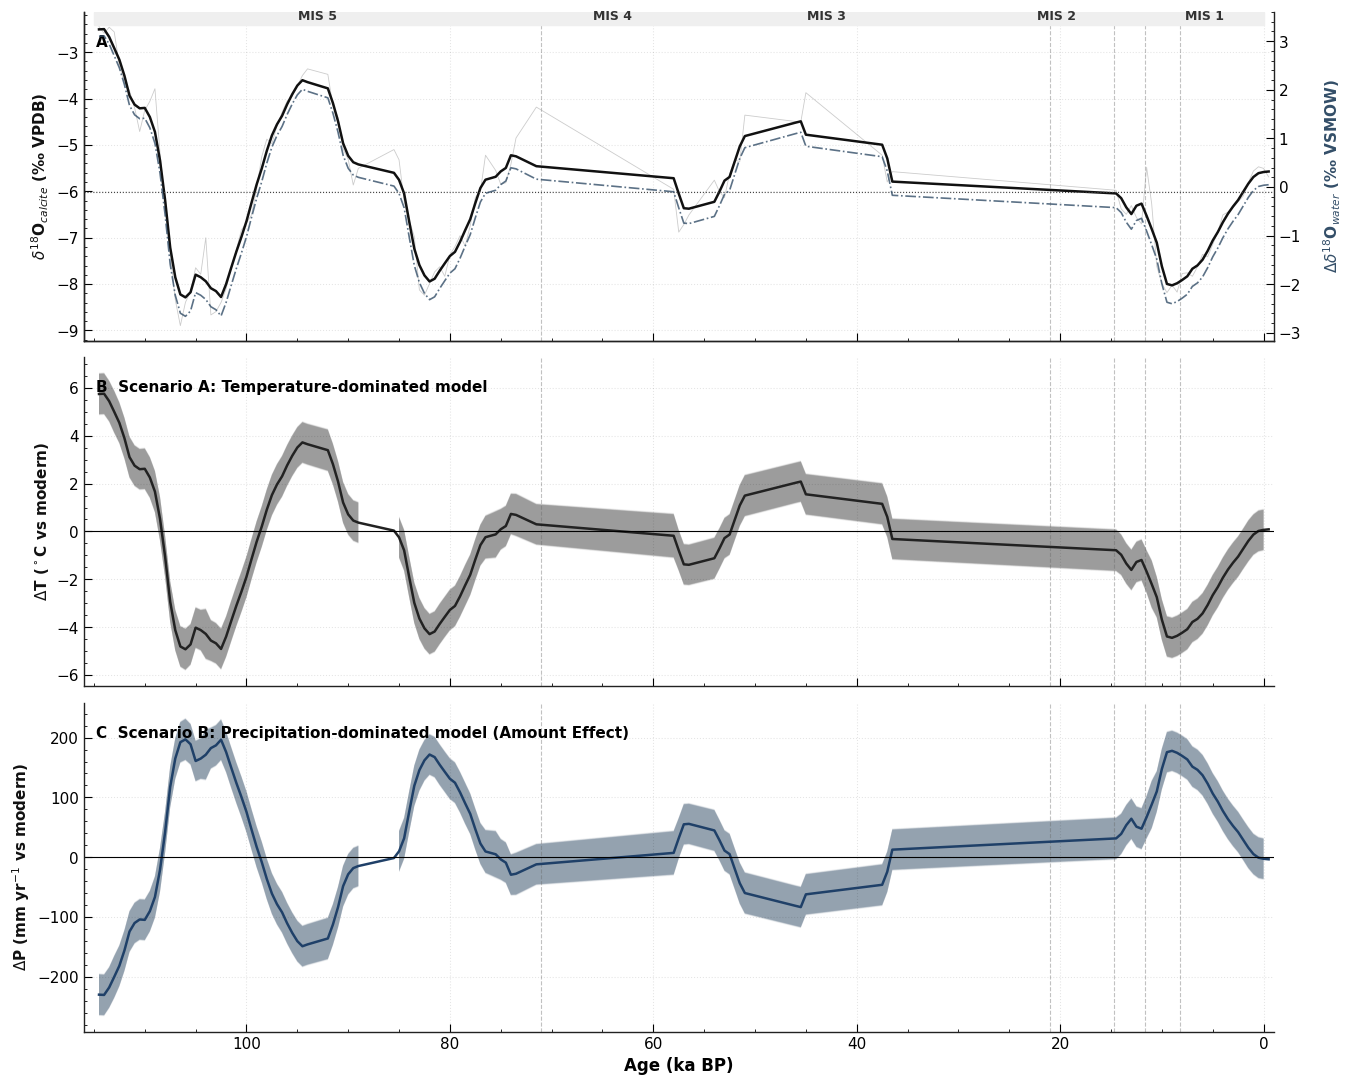

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

# ══════════════════════════════════════════════════════════════
# 1. MA'LUMOTLARNI YUKLASH VA HISOBLASH (Asosiy qism saqlandi)
# ══════════════════════════════════════════════════════════════
ton2 = pd.read_csv("TON2_iso_original.csv")
ton2 = ton2.dropna(subset=["age_calBP","d18OcarbVPDB"]).copy()
ton2 = ton2.sort_values("age_calBP").reset_index(drop=True)
T_CAVE_BEST = 5.675  
def alpha_kim_oneil(TK): return np.exp((18.03*(1000.0/TK) - 32.42)/1000.0)
def alpha_tremaine(TK): return np.exp((16.1*(1000.0/TK) - 24.6)/1000.0)
def vpdb_to_vsmow(d18O_vpdb): return 1.03091 * d18O_vpdb + 30.91
def water_from_calcite(d18O_calcite_smow, alpha): return ((1000.0 + d18O_calcite_smow) / alpha) - 1000.0
modern = ton2[ton2["age_calBP"] <= 10].copy()
modern_d18O_vpdb = modern["d18OcarbVPDB"].mean()
modern_d18O_smow = vpdb_to_vsmow(modern_d18O_vpdb)
w_modern = (water_from_calcite(modern_d18O_smow, alpha_kim_oneil(T_CAVE_BEST+273.15)) + water_from_calcite(modern_d18O_smow, alpha_tremaine(T_CAVE_BEST+273.15))) / 2
BIN_W = 500
ton2["age_bin"] = (ton2["age_calBP"] // BIN_W) * BIN_W
b = ton2.groupby("age_bin", as_index=False).agg(d18O_vpdb=('d18OcarbVPDB', 'mean'), d18O_std=('d18OcarbVPDB', 'std'), n_samples=('d18OcarbVPDB', 'count'))
b["d18O_smow"] = vpdb_to_vsmow(b["d18O_vpdb"])
T_K = T_CAVE_BEST + 273.15
b["d18O_w"] = (water_from_calcite(b["d18O_smow"], alpha_kim_oneil(T_K)) + water_from_calcite(b["d18O_smow"], alpha_tremaine(T_K))) / 2
b["unc_frac"] = (water_from_calcite(b["d18O_smow"], alpha_kim_oneil(T_K)) - water_from_calcite(b["d18O_smow"], alpha_tremaine(T_K))).abs() / 2
b["unc_anal"] = b["d18O_std"] / np.sqrt(b["n_samples"].clip(1))
b["unc_total"] = np.sqrt(b["unc_frac"]**2 + b["unc_anal"]**2)
b["dW"] = b["d18O_w"] - w_modern
COEFF_T_BEST = 0.54
COEFF_P_BEST = -1.35 / 100
b["dT_best"] = b["dW"] / COEFF_T_BEST
b["dT_unc"] = b["unc_total"] / COEFF_T_BEST
b["dP_best"] = b["dW"] / COEFF_P_BEST
b["dP_unc"] = b["unc_total"] / abs(COEFF_P_BEST)
for col in ["d18O_vpdb","dW","dT_best","dP_best"]:
    b[f"{col}_sm"] = uniform_filter1d(b[col], size=5)

# ══════════════════════════════════════════════════════════════
# Maxsus yumshatilgan soya to'ldirish funksiyasi
# ══════════════════════════════════════════════════════════════
def fill_between_feathered(ax, x, y_best, y_error, color, base_alpha=0.15, num_layers=5):
    """ Markaziy chiziqdan chekkalarga qarab pasayadigan shaffof soya to'ldiradi.
    Bu geometrik, sun'iy chekkalarni yo'qotib, tabiiyroq soya hosil qiladi."""
    for i in range(num_layers):
        alpha = base_alpha * (1 - i / num_layers)**1.5
        # Har bir qatlamni biroz kattaroq diapazon bilan to'ldirish (sun'iy xiralashtirish)
        offset_fac = 1.0 + (i / num_layers) * 0.1
        y_low = y_best - y_error * offset_fac
        y_hi = y_best + y_error * offset_fac
        ax.fill_between(x, y_low, y_hi, color=color, alpha=alpha, linewidth=0, antialiased=True)

# ══════════════════════════════════════════════════════════════
# 3. YUMSHATILGAN VIZUALIZATSIYA
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.linewidth': 1.0, 'axes.edgecolor': '#222222', 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.major.size': 6, 'ytick.major.size': 6, 'xtick.minor.visible': True, 'ytick.minor.visible': True})
fig = plt.figure(figsize=(14, 12), facecolor='white')
gs = gridspec.GridSpec(3, 1, height_ratios=[1.2, 1.2, 1.2], hspace=0.05, left=0.10, right=0.95, top=0.93, bottom=0.08)
axes = [fig.add_subplot(gs[i]) for i in range(3)]
age_ka = b["age_bin"] / 1000
mis_bars = [(0, 11.7, 'MIS 1'), (11.7, 29.0, 'MIS 2'), (29.0, 57.0, 'MIS 3'), (57.0, 71.0, 'MIS 4'), (71.0, 115.0, 'MIS 5')]
events = [8.2, 11.7, 14.7, 21.0, 71.0]

def apply_academic_style(ax, ylabel, title):
    ax.grid(True, alpha=0.10, linestyle=':', color='black')
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=11, color='#111111')
    ax.text(0.01, 0.93, title, transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_xlim(116, -1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for ev in events: ax.axvline(ev, color='#666666', lw=0.8, ls='--', alpha=0.4)

# --- PANEL A: δ18O Calcite & Water Anomaly ---
ax = axes[0]
apply_academic_style(ax, '$\delta^{18}$O$_{calcite}$ (‰ VPDB)', 'A')
ax.plot(age_ka, b["d18O_vpdb"], color='#999999', lw=0.6, alpha=0.5)
ax.plot(age_ka, b["d18O_vpdb_sm"], color='#111111', lw=1.8)
ax.axhline(b["d18O_vpdb"].mean(), color='#444444', lw=0.8, ls=':')
ax2 = ax.twinx()
ax2.set_ylabel('$\Delta\delta^{18}$O$_{water}$ (‰ VSMOW)', color='#334E68', fontweight='bold', labelpad=15) # Siljitildi
ax2.plot(age_ka, b["dW_sm"], color='#334E68', lw=1.2, ls='-.', alpha=0.8)
ax2.set_ylim(b["dW_sm"].min()-0.5, b["dW_sm"].max()+0.5)
ax2.invert_xaxis()
ax2.set_xlim(116, -1)
ax2.spines['top'].set_visible(False)
for s, e, lab in mis_bars:
    ax.axvspan(s, e, ymin=0.96, ymax=1.0, color='#EFEFEF', alpha=1.0, zorder=5)
    ax.text((s+e)/2, ax.get_ylim()[1]*0.98, lab, ha='center', va='top', fontsize=9, fontweight='bold', color='#333333', zorder=6)

# --- PANEL B: Scenario A (Temperature Anomaly) ---
ax = axes[1]
apply_academic_style(ax, '$\Delta$T ($^\circ$C vs modern)', 'B  Scenario A: Temperature-dominated model') # °C to'g'rilandi
fill_between_feathered(ax, age_ka, b["dT_best_sm"], b["dT_unc"], color='#444444', base_alpha=0.20, num_layers=7)
ax.plot(age_ka, b["dT_best_sm"], color='#222222', lw=1.8)
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.tick_params(labelbottom=False)

# --- PANEL C: Scenario B (Precipitation Anomaly) ---
ax = axes[2]
apply_academic_style(ax, '$\Delta$P (mm yr$^{-1}$ vs modern)', 'C  Scenario B: Precipitation-dominated model (Amount Effect)')
fill_between_feathered(ax, age_ka, b["dP_best_sm"], b["dP_unc"], color='#334E68', base_alpha=0.20, num_layers=7)
ax.plot(age_ka, b["dP_best_sm"], color='#1F4068', lw=1.8)
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.set_xlabel('Age (ka BP)', fontweight='bold', fontsize=12)

for i, ax in enumerate(axes[:-1]): ax.tick_params(labelbottom=False)
plt.savefig('fig_academic_reconstruction_feathered.png', dpi=300, bbox_inches='tight')
plt.show()